<a href="https://colab.research.google.com/github/bdashti/v/blob/main/Copy_of_Phase_2_v1_8_Unsupervised_STREME_discovery_(from_v2_97_supervised_residuals).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Cell 1: Install MEME suite (kernel will restart, then start from cell 1b downwards)
# Install MEME suite (5.5.7) via bioconda. Triggers kernel restart.
# After restart, conda env persists across cells. Run Cell 2 next.
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:12
🔁 Restarting kernel...


In [ ]:
# =====================================================================
# @title Cell 1b: Phase 2 Savepoint Loader — restore latest from Drive
# =====================================================================
# Self-mounts Drive, then auto-loads the newest sp_* savepoint: streme_work
# + 44 main globals + the 13 topology/curvature add-on globals
# (curv_decide_df, curv_tox_mat, curv_sta_mat, sigma_noncanon_df,
# sigma_noncanon_predict, M10_THR, toxic_subtypes, dh5a_partition,
# effect_vs_pwmat, null_dissociation, gc_robustness, layer_test,
# curv_param_verification). Discovering the add-on here means SP-addon
# can never leave it stranded in an older savepoint again.
# =====================================================================
LOAD = True            # set False to skip (this OVERWRITES /content/streme_work)
SP_DIR_OVERRIDE = None # set to a specific sp_* path to pin; else newest is used

import os, glob, tarfile, shutil, joblib

# --- self-sufficient mount: loader reads from Drive, so mount here -----
# Lets you run ONLY this cell to restore state in a fresh runtime (no Cell
# 0/2 needed for analysis-only work). Idempotent: a no-op if already mounted.
if not os.path.isdir('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

if not LOAD:
    print("Cell 1b loader OFF (LOAD=False) — skipping restore.")
else:
    SP_ROOT = '/content/drive/MyDrive/Plasmids/phase2_savepoints'

    # 1. locate savepoint (newest by timestamped name unless pinned)
    if SP_DIR_OVERRIDE:
        SP_DIR = SP_DIR_OVERRIDE
    else:
        cands = sorted(glob.glob(os.path.join(SP_ROOT, 'sp_*')))
        assert cands, f"no sp_* savepoints under {SP_ROOT}"
        SP_DIR = cands[-1]
    globals()['SP_DIR'] = SP_DIR
    print(f"Loading from: {SP_DIR}\n")

    man = os.path.join(SP_DIR, 'manifest.txt')
    if os.path.exists(man):
        print("--- Manifest ---")
        print(open(man).read().strip(), "\n")

    # 2. restore streme_work
    print("[1/3] Restoring /content/streme_work/ ...")
    tar_path = os.path.join(SP_DIR, 'streme_work.tar.gz')
    if os.path.exists('/content/streme_work'):
        print("  Removing existing /content/streme_work first...")
        shutil.rmtree('/content/streme_work')
    with tarfile.open(tar_path) as tar:
        try:
            tar.extractall('/content', filter='data')   # silences 3.14 warning
        except TypeError:
            tar.extractall('/content')                   # older Python
    print(f"  Restored from {tar_path}\n")

    # 3. restore main globals (auto-discover the bundle file by elimination)
    print("[2/3] Restoring main globals ...")
    SPECIAL  = {'streme_work.tar.gz', 'manifest.txt', 'phase2_topology_addon.joblib'}
    SKIP_EXT = ('.txt', '.png', '.pdf', '.csv', '.npz', '.json',
                '.html', '.tar', '.gz', '.xml', '.tsv')
    n_main, main_keys = 0, []
    for f in os.listdir(SP_DIR):
        if f in SPECIAL or f.lower().endswith(SKIP_EXT):
            continue
        try:
            obj = joblib.load(os.path.join(SP_DIR, f))
        except Exception:
            continue
        if isinstance(obj, dict):
            for k, v in obj.items():
                globals()[k] = v; main_keys.append(k); n_main += 1
    print(f"  Restored {n_main} main globals")
    if n_main == 0:
        print("  WARN: found no main-globals bundle — check the savepoint contents.")
    print()

    # 4. restore topology / curvature add-on
    print("[3/3] Restoring topology add-on ...")
    addon = os.path.join(SP_DIR, 'phase2_topology_addon.joblib')
    if os.path.exists(addon):
        ad = joblib.load(addon)
        for k, v in ad.items():
            globals()[k] = v
        print(f"  Restored {len(ad)} add-on globals: {list(ad)}")
    else:
        print("  No add-on joblib in this savepoint (skipped).")
        print("  If you expected one, SP-addon wrote it to an older savepoint;")
        print("  re-run SP-addon so it lands in this (newest) dir.")

    print("\n" + "="*70)
    print("  Restore complete. Proceed to whatever cell you want to run next.")
    print("="*70)

Mounted at /content/drive
Loading from: /content/drive/MyDrive/Plasmids/phase2_savepoints/sp_20260616_000723

--- Manifest ---
Phase 2 savepoint
Timestamp:       20260616_000723
streme_work.tar.gz: 353.5 MB
Globals saved:   44
  - compare
  - key_df
  - pct_overlap
  - null_means
  - overlap_observed
  - lasso
  - coef_df
  - scaler
  - effect_df
  - toxic_counts
  - ctl_counts
  - sigma_counts_global
  - all_df
  - m_full
  - r2_full
  - r2_at
  - lasso_at
  - coef_df_at
  - scaler_at
  - feature_names
  - univariate_sorted
  - s23_pwm_at
  - s23_counts_all
  - test_df
  - toxic_df
  - stable_df
  - toxic_feats
  - stable_feats
  - stats_df
  - control_feats
  - threshold_results
  - pooled
  - toxic_at_cov
  - stable_at_cov
  - toxic_shuf_at_cov
  - toxic_at_starts
  - stable_at_starts
  - toxic_shuf_seqs
  - fimo_toxic
  - fimo_stable
  - toxic_hns
  - stable_hns
  - pooled_ts
  - cov 

[1/3] Restoring /content/streme_work/ ...
  Restored from /content/drive/MyDrive/Plasmids/phase2_

In [ ]:
# @title Cell 2: Verify install + mount Drive + check FASTAs
# Run AFTER the kernel restart from Cell 1.
import subprocess, os, sys

# Install MEME via bioconda (condacolab provides the conda binary)
print("Installing MEME 5.5.7 via bioconda...")
result = subprocess.run(['conda', 'install', '-c', 'bioconda', '-y', 'meme=5.5.7'],
                        capture_output=True, text=True)
if result.returncode != 0:
    print("WARN: bioconda install hit issues. stderr:")
    print(result.stderr[-1500:])
else:
    print("MEME suite installed.")

# Verify binaries
for bin_name in ['streme', 'tomtom', 'meme', 'fasta-shuffle-letters']:
    p = subprocess.run(['which', bin_name], capture_output=True, text=True)
    if p.returncode == 0:
        print(f"  {bin_name:<22s} {p.stdout.strip()}")
    else:
        print(f"  {bin_name:<22s} MISSING — install failed")

print()
v = subprocess.run(['streme', '--version'], capture_output=True, text=True)
print(f"STREME: {v.stdout.strip() or v.stderr.strip()}")

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Paths — v2.97-post-Tom LFC-extreme cohorts (supersedes fasta_residuals/)
DRIVE_FASTA_DIR = '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme'
WORK_DIR        = '/content/streme_work'
os.makedirs(WORK_DIR, exist_ok=True)

# Verify FASTAs are reachable
print(f"\nFASTA directory: {DRIVE_FASTA_DIR}")
expected = [
    'discovery_toxic_cohort.fa',
    'discovery_stable_cohort.fa',
    'discovery_control_GC_matched.fa',
    'validation_toxic_cohort.fa',
    'validation_stable_cohort.fa',
    'validation_control_GC_matched.fa',
]
for fname in expected:
    fpath = os.path.join(DRIVE_FASTA_DIR, fname)
    if os.path.exists(fpath):
        n_seq = subprocess.run(['grep', '-c', '^>', fpath], capture_output=True, text=True)
        print(f"  {fname:<38s} {int(n_seq.stdout.strip()):>5d} sequences")
    else:
        print(f"  {fname:<38s} MISSING — upload from G:\\Plasmids\\fasta_lfc_extreme\\")

print(f"\nWork dir (STREME outputs): {WORK_DIR}")

Installing MEME 5.5.7 via bioconda...
MEME suite installed.
  streme                 /usr/local/bin/streme
  tomtom                 /usr/local/bin/tomtom
  meme                   /usr/local/bin/meme
  fasta-shuffle-letters  /usr/local/bin/fasta-shuffle-letters

STREME: 5.5.7
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

FASTA directory: /content/drive/MyDrive/Plasmids/fasta_lfc_extreme
  discovery_toxic_cohort.fa               9215 sequences
  discovery_stable_cohort.fa              9215 sequences
  discovery_control_GC_matched.fa        18430 sequences
  validation_toxic_cohort.fa              2594 sequences
  validation_stable_cohort.fa             2594 sequences
  validation_control_GC_matched.fa        5188 sequences

Work dir (STREME outputs): /content/streme_work


In [ ]:
# @title Cell 3: STREME discriminative motif discovery (LFC-extreme — Change 1)
# Foreground: toxic_cohort (bottom decile log2FC — most-burdensome by measurement)
# Background: control_GC_matched (mid-range log2FC, GC-matched to toxic ∪ stable)
# Discovers motifs ENRICHED in the toxic cohort vs the control. Cohorts are
# defined from ground-truth log2FC_mean, not from supervised-model predictions,
# so motifs reflect sequence grammar of the burdensome biology rather than
# features correlated with the model's inductive biases.

import subprocess, os, sys, time, threading

FG  = os.path.join(DRIVE_FASTA_DIR, 'discovery_toxic_cohort.fa')
BG  = os.path.join(DRIVE_FASTA_DIR, 'discovery_control_GC_matched.fa')
OUT = os.path.join(WORK_DIR, 'streme_discovery')

# STREME parameters unchanged from residual-based discovery (v2.97 protocol):
#   --minw 6  --maxw 20         : TFBS / sigma-factor sites typically 6-20 bp
#   --pvt 0.05                  : p-value threshold for motif retention
#   --nmotifs 25                : top-25 motifs (most projects use 5-15; 25 is generous)
#   --dna                       : nucleotide alphabet
#   --evalue                    : report E-values (corrects for multiple testing)
#   --thresh 1                  : significance threshold E < 1 (lenient — TOMTOM filters next)
cmd = [
    'streme', '--verbosity', '1', '--oc', OUT,
    '--p', FG, '--n', BG,
    '--minw', '6', '--maxw', '20',
    '--nmotifs', '25', '--pvt', '0.05',
    '--dna', '--evalue', '--thresh', '1',
]
print("Running STREME (5-15 min depending on FASTA size)...")
print("Command:", ' '.join(cmd))
print()

# --- NEW: Threaded Jupyter-Safe Loading Bar ---
def loading_bar():
    bar_width = 20
    pos = 0
    direction = 1
    while running:
        bar = [' '] * bar_width
        for j in range(5):  # Width of the moving block
            if 0 <= pos + j < bar_width:
                bar[pos + j] = '█'
        sys.stdout.write(f"\r[{''.join(bar)}] Processing...")
        sys.stdout.flush()

        pos += direction
        if pos == bar_width - 5 or pos == 0:
            direction *= -1
        time.sleep(0.1)

    # Clear the bar when finished
    sys.stdout.write(f"\r[{'█' * bar_width}] Done!          \n\n")
    sys.stdout.flush()

running = True
t = threading.Thread(target=loading_bar)
t.start()
# ----------------------------------------------

# subprocess.run safely handles output buffers so Colab/Jupyter won't deadlock
result = subprocess.run(cmd, capture_output=True, text=True)

# Stop the loading bar thread
running = False
t.join()

print("STDOUT (last 2000 chars):")
print(result.stdout[-2000:])
if result.returncode != 0:
    print("\nSTDERR:")
    print(result.stderr[-1500:])
else:
    print(f"\nSTREME finished. Output: {OUT}")
    print(f"Top-level files:")
    for f in sorted(os.listdir(OUT)):
        size = os.path.getsize(os.path.join(OUT, f))
        print(f"  {f:<30s} {size/1024:.1f} KB")

Running STREME (5-15 min depending on FASTA size)...
Command: streme --verbosity 1 --oc /content/streme_work/streme_discovery --p /content/drive/MyDrive/Plasmids/fasta_lfc_extreme/discovery_toxic_cohort.fa --n /content/drive/MyDrive/Plasmids/fasta_lfc_extreme/discovery_control_GC_matched.fa --minw 6 --maxw 20 --nmotifs 25 --pvt 0.05 --dna --evalue --thresh 1

[████████████████████] Done!          

STDOUT (last 2000 chars):


STREME finished. Output: /content/streme_work/streme_discovery
Top-level files:
  sequences.tsv                  5130.7 KB
  sites.tsv                      4793.3 KB
  streme.html                    342.0 KB
  streme.txt                     7.7 KB
  streme.xml                     24.0 KB


In [ ]:
#@title Cell 3b: RAM Clear
import gc
gc.collect()
!sync && echo 3 | sudo tee /proc/sys/vm/drop_caches 2>/dev/null || true
import subprocess
print(subprocess.run(['free', '-h'], capture_output=True, text=True).stdout)

3
               total        used        free      shared  buff/cache   available
Mem:            12Gi       978Mi       8.6Gi       2.0Mi       3.1Gi        11Gi
Swap:             0B          0B          0B



In [ ]:
# @title Cell 4: Parse STREME results
# Parse STREME's XML output into a tidy dataframe.
import os, xml.etree.ElementTree as ET
import pandas as pd

xml_path = os.path.join(WORK_DIR, 'streme_discovery', 'streme.xml')
tree = ET.parse(xml_path)
root = tree.getroot()

motifs = []
for motif in root.findall('.//motif'):
    motif_id = motif.get('id')
    consensus = motif.get('alt') or motif_id  # consensus IUPAC string
    width = int(motif.get('width'))
    nsites = int(motif.get('train_pos_count', 0))
    nbg = int(motif.get('train_neg_count', 0))
    pvalue = float(motif.get('test_pvalue', 1.0))
    evalue = float(motif.get('test_evalue', 1.0))
    motifs.append({
        'motif_id':  motif_id,
        'consensus': consensus,
        'width':     width,
        'sites_fg':  nsites,
        'sites_bg':  nbg,
        'enrichment': nsites / max(nbg, 1),
        'p_value':   pvalue,
        'e_value':   evalue,
    })

motifs_df = pd.DataFrame(motifs).sort_values('e_value')
print(f"STREME found {len(motifs_df)} motifs.")
print(f"Significant (E < 0.05): {(motifs_df['e_value'] < 0.05).sum()}")
print(f"\nTop 15 by E-value:")
print(motifs_df.head(15).to_string(index=False))

# Persist
motifs_df.to_csv(os.path.join(WORK_DIR, 'streme_motifs.csv'), index=False)
print(f"\nSaved: {WORK_DIR}/streme_motifs.csv")

STREME found 13 motifs.
Significant (E < 0.05): 4

Top 15 by E-value:
            motif_id consensus  width  sites_fg  sites_bg  enrichment      p_value      e_value
        1-AAAAAAACCC  STREME-1     10      4687      5972    0.784829 4.600000e-22 6.000000e-21
           2-TTAAAAA  STREME-2      7      4431      7167    0.618250 1.400000e-11 1.800000e-10
          3-AGAAAAAA  STREME-3      8      4568      6728    0.678954 2.800000e-09 3.600000e-08
         4-AAAACCCCC  STREME-4      9      1890      2981    0.634015 4.000000e-04 5.200000e-03
         5-TCCAAAAAA  STREME-5      9       861      1267    0.679558 4.100000e-03 5.300000e-02
          6-AAAAATTT  STREME-6      8      2739      4484    0.610839 1.400000e-02 1.800000e-01
          7-AAAACAAA  STREME-7      8      2191      3760    0.582713 1.800000e-02 2.300000e-01
          8-ATTTTCTA  STREME-8      8        68        65    1.046154 5.700000e-02 7.400000e-01
           9-AAAATCC  STREME-9      7      1849      3118    0.593

In [ ]:
# @title Cell 5: TOMTOM lookup against RegulonDB / E. coli motif databases
# TOMTOM scores discovered motifs against E. coli K-12 reference TFBS database
# from RegulonDB. Hits with q < 0.1 are putative known regulatory sites.
import subprocess, os, urllib.request

# Download MEME's prokaryote motif database (RegulonDB + DPInteract)
DB_DIR = '/content/motif_databases'
os.makedirs(DB_DIR, exist_ok=True)
DB_URL = 'https://meme-suite.org/meme/meme-software/Databases/motifs/motif_databases.12.26.tgz'
DB_TGZ = os.path.join(DB_DIR, 'motif_databases.12.26.tgz')

if not os.path.exists(DB_TGZ):
    print("Downloading MEME motif databases (~50 MB)...")
    urllib.request.urlretrieve(DB_URL, DB_TGZ)
    print("Extracting...")
    subprocess.run(['tar', '-xzf', DB_TGZ, '-C', DB_DIR], check=True)
    print("Done.")
else:
    print("Motif database already present.")

# Find RegulonDB MEME file
import glob
candidates = glob.glob(os.path.join(DB_DIR, '**/*regulonDB*.meme'), recursive=True) + \
             glob.glob(os.path.join(DB_DIR, '**/regulondb*.meme'), recursive=True) + \
             glob.glob(os.path.join(DB_DIR, '**/PROKARYOTE/*.meme'), recursive=True)
if not candidates:
    raise RuntimeError(f"No RegulonDB-like MEME file found under {DB_DIR}.")
print(f"\nProkaryote motif files found:")
for c in candidates[:10]:
    print(f"  {c}")

# Use ALL prokaryote MEME files (RegulonDB + DPInteract + dpinteract_2017)
PROK_DBS = sorted(set(glob.glob(os.path.join(DB_DIR, '**/PROKARYOTE/*.meme'), recursive=True)))
if not PROK_DBS:
    PROK_DBS = candidates
print(f"\nUsing {len(PROK_DBS)} prokaryote motif file(s) for TOMTOM lookup.")

# Run TOMTOM
QUERY = os.path.join(WORK_DIR, 'streme_discovery', 'streme.txt')  # MEME format
TOMTOM_OUT = os.path.join(WORK_DIR, 'tomtom_regulondb')
cmd = ['tomtom', '-oc', TOMTOM_OUT, '-thresh', '0.1', '-evalue',
       '-min-overlap', '5', QUERY] + PROK_DBS
print(f"\nRunning TOMTOM...")
print(f"Command: {' '.join(cmd[:8])} ... [{len(PROK_DBS)} db files]")
result = subprocess.run(cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("TOMTOM stderr:", result.stderr[-1500:])
else:
    print("TOMTOM finished.")
    print(f"Output: {TOMTOM_OUT}")
    for f in sorted(os.listdir(TOMTOM_OUT)):
        print(f"  {f}")

Motif database already present.

Prokaryote motif files found:
  /content/motif_databases/motif_databases/PROKARYOTE/regtransbase.meme
  /content/motif_databases/motif_databases/PROKARYOTE/fan2020.meme
  /content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme
  /content/motif_databases/motif_databases/PROKARYOTE/collectf.meme

Using 4 prokaryote motif file(s) for TOMTOM lookup.

Running TOMTOM...
Command: tomtom -oc /content/streme_work/tomtom_regulondb -thresh 0.1 -evalue -min-overlap 5 ... [4 db files]
TOMTOM finished.
Output: /content/streme_work/tomtom_regulondb
  tomtom.html
  tomtom.tsv
  tomtom.xml


In [ ]:
# @title Cell 6: Parse TOMTOM hits + validate on held-out (df_test) cohorts
# Parse TOMTOM hits and run STREME independently on the validation cohorts.
# The validation cohorts come from df_test, which is cluster-held-out from
# training, so re-discovering the same motifs on this independent set is
# evidence the motifs reflect genuine biology rather than train-set artefacts.
import os
import pandas as pd

TOMTOM_OUT = os.path.join(WORK_DIR, 'tomtom_regulondb')
tomtom_tsv = os.path.join(TOMTOM_OUT, 'tomtom.tsv')

if os.path.exists(tomtom_tsv):
    hits = pd.read_csv(tomtom_tsv, sep='\t', comment='#')
    print(f"TOMTOM produced {len(hits)} query-target pairs.")
    sig = hits[hits['q-value'] < 0.1].copy()
    print(f"Significant hits (q < 0.1): {len(sig)}")
    if len(sig) > 0:
        sig_ranked = sig.sort_values('q-value').head(30)
        print(f"\nTop 30 hits:")
        cols = ['Query_ID', 'Target_ID', 'p-value', 'q-value', 'Orientation']
        print(sig_ranked[cols].to_string(index=False))
else:
    print(f"WARN: {tomtom_tsv} not found. TOMTOM may have failed in Cell 5.")
    sig = pd.DataFrame()

# Independent re-discovery on validation cohorts (df_test, cluster-held-out)
import subprocess
VAL_FG  = os.path.join(DRIVE_FASTA_DIR, 'validation_toxic_cohort.fa')
VAL_BG  = os.path.join(DRIVE_FASTA_DIR, 'validation_control_GC_matched.fa')
VAL_OUT = os.path.join(WORK_DIR, 'streme_validation')

print(f"\nRunning STREME on validation set (independent re-discovery)...")
cmd = ['streme', '--verbosity', '1', '--oc', VAL_OUT,
       '--p', VAL_FG, '--n', VAL_BG,
       '--minw', '6', '--maxw', '20',
       '--nmotifs', '15', '--pvt', '0.05',
       '--dna', '--evalue', '--thresh', '1']
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout[-1500:])

# Compare top-N motifs from discovery to top-N from validation
if os.path.exists(os.path.join(VAL_OUT, 'streme.xml')):
    import xml.etree.ElementTree as ET
    tree_v = ET.parse(os.path.join(VAL_OUT, 'streme.xml'))
    root_v = tree_v.getroot()
    val_motifs = []
    for m in root_v.findall('.//motif'):
        val_motifs.append({
            'consensus': m.get('alt') or m.get('id'),
            'width':     int(m.get('width')),
            'evalue':    float(m.get('test_evalue', 1.0)),
        })
    val_df = pd.DataFrame(val_motifs).sort_values('evalue')
    print(f"\nValidation set re-discovered {len(val_df)} motifs.")
    print("Top 10 validation motifs:")
    print(val_df.head(10).to_string(index=False))

TOMTOM produced 0 query-target pairs.
Significant hits (q < 0.1): 0

Running STREME on validation set (independent re-discovery)...


Validation set re-discovered 11 motifs.
Top 10 validation motifs:
consensus  width       evalue
 STREME-1      8 4.000000e-12
 STREME-2      6 2.400000e-02
 STREME-3     13 4.400000e-02
 STREME-4      7 4.500000e-02
 STREME-5      7 1.500000e-01
 STREME-6      7 5.000000e-01
 STREME-7      6 6.600000e-01
 STREME-8     11 1.200000e+00
 STREME-9      8 1.800000e+00
STREME-10      9 1.900000e+00


In [ ]:
# @title Cell 7: Final motif catalogue + archive to Drive
# Build the final motif catalogue: discovery motifs annotated with
# TOMTOM hits + validation status. Save as CSV + JSON for the paper.
import os, json
import pandas as pd

WORK_DIR_ABS = os.path.abspath(WORK_DIR)

motifs_df = pd.read_csv(os.path.join(WORK_DIR_ABS, 'streme_motifs.csv'))
motifs_df['rank'] = range(1, len(motifs_df) + 1)

# Annotate with TOMTOM hits if present
if os.path.exists(os.path.join(WORK_DIR_ABS, 'tomtom_regulondb', 'tomtom.tsv')):
    tomtom = pd.read_csv(os.path.join(WORK_DIR_ABS, 'tomtom_regulondb', 'tomtom.tsv'),
                         sep='\t', comment='#')
    sig = tomtom[tomtom['q-value'] < 0.1]

    # Best annotation per query motif
    annotation = {}
    for q, sub in sig.groupby('Query_ID'):
        top = sub.nsmallest(3, 'q-value')
        annotation[q] = {
            'top_hits': top['Target_ID'].tolist(),
            'top_q':    top['q-value'].tolist(),
            'n_hits':   len(sub),
        }
    motifs_df['tomtom_hits']  = motifs_df['motif_id'].map(
        lambda mid: annotation.get(mid, {}).get('top_hits', []))
    motifs_df['tomtom_n_sig'] = motifs_df['motif_id'].map(
        lambda mid: annotation.get(mid, {}).get('n_hits', 0))
    motifs_df['top_target_q'] = motifs_df['motif_id'].map(
        lambda mid: annotation.get(mid, {}).get('top_q', [None])[0])
else:
    motifs_df['tomtom_hits']  = [[] for _ in range(len(motifs_df))]
    motifs_df['tomtom_n_sig'] = 0
    motifs_df['top_target_q'] = None

# Save
out_csv  = os.path.join(WORK_DIR_ABS, 'motif_catalogue_v2.97.csv')
out_json = os.path.join(WORK_DIR_ABS, 'motif_catalogue_v2.97.json')
motifs_df.to_csv(out_csv, index=False)
motifs_df.to_json(out_json, orient='records', indent=2)
print(f"Saved motif catalogue:")
print(f"  CSV:  {out_csv}  ({len(motifs_df)} motifs)")
print(f"  JSON: {out_json}")

# Brief summary
n_sig    = (motifs_df['e_value'] < 0.05).sum()
n_anno   = (motifs_df['tomtom_n_sig'] > 0).sum() if 'tomtom_n_sig' in motifs_df else 0
n_unanno = n_sig - n_anno
print(f"\nSummary:")
print(f"  Discovered motifs (E < 0.05):           {n_sig}")
print(f"  With TOMTOM hits in RegulonDB (q<0.1):  {n_anno}")
print(f"  Novel candidates (no annotated hit):    {n_unanno}")
print(f"\nTop 10 motifs in the final catalogue:")
print(motifs_df.head(10)[['motif_id','consensus','width','sites_fg','e_value',
                          'tomtom_n_sig','top_target_q']].to_string(index=False))

# Copy back to Drive for archival
import shutil
DRIVE_OUT = '/content/drive/MyDrive/Plasmids/streme_outputs'
os.makedirs(DRIVE_OUT, exist_ok=True)
shutil.copy(out_csv,  os.path.join(DRIVE_OUT, os.path.basename(out_csv)))
shutil.copy(out_json, os.path.join(DRIVE_OUT, os.path.basename(out_json)))
shutil.copytree(os.path.join(WORK_DIR_ABS, 'streme_discovery'),
                os.path.join(DRIVE_OUT, 'streme_discovery'), dirs_exist_ok=True)
shutil.copytree(os.path.join(WORK_DIR_ABS, 'streme_validation'),
                os.path.join(DRIVE_OUT, 'streme_validation'), dirs_exist_ok=True)
if os.path.exists(os.path.join(WORK_DIR_ABS, 'tomtom_regulondb')):
    shutil.copytree(os.path.join(WORK_DIR_ABS, 'tomtom_regulondb'),
                    os.path.join(DRIVE_OUT, 'tomtom_regulondb'), dirs_exist_ok=True)
print(f"\nArchived to Drive: {DRIVE_OUT}")

Saved motif catalogue:
  CSV:  /content/streme_work/motif_catalogue_v2.97.csv  (13 motifs)
  JSON: /content/streme_work/motif_catalogue_v2.97.json

Summary:
  Discovered motifs (E < 0.05):           4
  With TOMTOM hits in RegulonDB (q<0.1):  0
  Novel candidates (no annotated hit):    4

Top 10 motifs in the final catalogue:
        motif_id consensus  width  sites_fg      e_value  tomtom_n_sig top_target_q
    1-AAAAAAACCC  STREME-1     10      4687 6.000000e-21             0         None
       2-TTAAAAA  STREME-2      7      4431 1.800000e-10             0         None
      3-AGAAAAAA  STREME-3      8      4568 3.600000e-08             0         None
     4-AAAACCCCC  STREME-4      9      1890 5.200000e-03             0         None
     5-TCCAAAAAA  STREME-5      9       861 5.300000e-02             0         None
      6-AAAAATTT  STREME-6      8      2739 1.800000e-01             0         None
      7-AAAACAAA  STREME-7      8      2191 2.300000e-01             0         None


In [ ]:
# @title Cell 8: STREME discovery with --order 3 Markov background (LCR diagnostic)
# Diagnostic rerun of Cell 3 using a 3rd-order Markov background. Order-3
# controls for tetranucleotide composition (4-mer context), not just AT/GC
# composition. If the AT-rich motifs from Cell 3 survive this stricter null
# they encode patterns beyond local AT-richness. If they vanish or weaken
# substantially, Cell 3's hits were low-complexity-region artifacts.
#
# Only --order differs from Cell 3. Same cohorts, same target count, output
# to a parallel directory so both catalogues survive for comparison.

import subprocess, os
import xml.etree.ElementTree as ET

FG  = os.path.join(DRIVE_FASTA_DIR, 'discovery_toxic_cohort.fa')
BG  = os.path.join(DRIVE_FASTA_DIR, 'discovery_control_GC_matched.fa')
OUT = os.path.join(WORK_DIR, 'streme_discovery_order3')

cmd = [
    'streme', '--verbosity', '1', '--oc', OUT,
    '--p', FG, '--n', BG,
    '--minw', '6', '--maxw', '20',
    '--nmotifs', '25', '--pvt', '0.05',
    '--dna', '--evalue', '--thresh', '1',
    '--order', '3',
]
print("Running STREME with --order 3 background (5-15 min)...")
print("Command:", ' '.join(cmd))
print()
result = subprocess.run(cmd, capture_output=True, text=True)
print("STDOUT (last 2000 chars):")
print(result.stdout[-2000:])
if result.returncode != 0:
    print("\nSTDERR:")
    print(result.stderr[-1500:])
else:
    print(f"\nSTREME (order-3) finished. Output: {OUT}")

def summarize_streme(xml_path, label):
    if not os.path.exists(xml_path):
        print(f"\n  {label}: streme.xml not found")
        return None
    tree = ET.parse(xml_path)
    root = tree.getroot()
    motifs = [{'consensus': m.get('alt') or m.get('id'),
               'width':     int(m.get('width')),
               'evalue':    float(m.get('test_evalue', 1.0))}
              for m in root.findall('.//motif')]
    sig = [m for m in motifs if m['evalue'] < 0.05]
    print(f"\n  {label}: {len(motifs)} total motifs, {len(sig)} significant (E<0.05)")
    if motifs:
        print(f"    Top 5:")
        for m in motifs[:5]:
            print(f"      {m['consensus']:<25s}  width={m['width']:<3d}  E={m['evalue']:.2e}")
    return motifs

print("\n" + "=" * 72)
print(" COMPARISON: order-0 (Cell 3) vs order-3 (Cell 8)")
print("=" * 72)
a = summarize_streme(os.path.join(WORK_DIR, 'streme_discovery', 'streme.xml'),
                     'Order-0 (Cell 3 default)')
b = summarize_streme(os.path.join(WORK_DIR, 'streme_discovery_order3', 'streme.xml'),
                     'Order-3 (this cell)')

print("\nINTERPRETATION:")
print("  - If order-3 motifs resemble order-0 → patterns survive a stronger null;")
print("    they encode specific sequence info, not just AT-richness. Adopt --order 3")
print("    as the production setting and re-run TOMTOM (Cell 9) against these.")
print("  - If order-3 finds far fewer / weaker motifs → order-0 hits were LCR")
print("    artifacts. Phase 2 needs methodology revision before paper claims.")

Running STREME with --order 3 background (5-15 min)...
Command: streme --verbosity 1 --oc /content/streme_work/streme_discovery_order3 --p /content/drive/MyDrive/Plasmids/fasta_lfc_extreme/discovery_toxic_cohort.fa --n /content/drive/MyDrive/Plasmids/fasta_lfc_extreme/discovery_control_GC_matched.fa --minw 6 --maxw 20 --nmotifs 25 --pvt 0.05 --dna --evalue --thresh 1 --order 3

STDOUT (last 2000 chars):


STREME (order-3) finished. Output: /content/streme_work/streme_discovery_order3

 COMPARISON: order-0 (Cell 3) vs order-3 (Cell 8)

  Order-0 (Cell 3 default): 13 total motifs, 4 significant (E<0.05)
    Top 5:
      STREME-1                   width=10   E=6.00e-21
      STREME-2                   width=7    E=1.80e-10
      STREME-3                   width=8    E=3.60e-08
      STREME-4                   width=9    E=5.20e-03
      STREME-5                   width=9    E=5.30e-02

  Order-3 (this cell): 10 total motifs, 3 significant (E<0.05)
    Top 5:
      STREME-1                

In [ ]:
#@title Cell 8b: RAM Clear
import gc
gc.collect()
!sync && echo 3 | sudo tee /proc/sys/vm/drop_caches 2>/dev/null || true
import subprocess
print(subprocess.run(['free', '-h'], capture_output=True, text=True).stdout)

3
               total        used        free      shared  buff/cache   available
Mem:            12Gi       951Mi       9.4Gi       2.0Mi       2.3Gi        11Gi
Swap:             0B          0B          0B



In [ ]:
# @title Cell 11: Diff against residual-based catalogue (Tom's prior validation reference)
# Tom's email noted "the unsupervised arm independently validates signal we've
# seen through other approaches" — referring to your prior residual-based STREME
# catalogue (Cells 32a/32b). The LFC-extreme cohort change Tom requested may
# have shifted what motifs emerge. This cell runs the same STREME pipeline on
# the residual cohorts so you can directly compare what changed.
#
# Note: cohorts are NOT apples-to-apples (residual = where model errs; LFC-extreme
# = ground-truth extreme). That's the point — Tom's methodology change replaced
# one selection with the other; this cell quantifies the consequence.

import os, subprocess
import xml.etree.ElementTree as ET

DRIVE_RESIDUAL_DIR = '/content/drive/MyDrive/Plasmids/fasta_residuals'
expected_residual = ['discovery_hidden_burden.fa', 'discovery_control.fa']

print("Checking for residual FASTAs on Drive...")
missing = [f for f in expected_residual
           if not os.path.exists(os.path.join(DRIVE_RESIDUAL_DIR, f))]
if missing:
    print(f"\nMISSING residual FASTAs in {DRIVE_RESIDUAL_DIR}:")
    for f in missing:
        print(f"  - {f}")
    print("\nSync from local Windows (Cells 32a/32b output):")
    print('  rclone copy "G:\\Plasmids\\fasta_residuals" "<remote>:Plasmids/fasta_residuals" --progress')
    print("\nIf you no longer have fasta_residuals/ locally, re-run Phase 1 Cells")
    print("32a and 32b (they still execute on a fresh Phase 1 rerun and write to")
    print("G:\\Plasmids\\fasta_residuals\\), then sync.")
    print("\nSkipping residual STREME comparison.")
else:
    print("Found. Running STREME on residual cohorts (5-15 min, --order 3)...")
    FG  = os.path.join(DRIVE_RESIDUAL_DIR, 'discovery_hidden_burden.fa')
    BG  = os.path.join(DRIVE_RESIDUAL_DIR, 'discovery_control.fa')
    OUT = os.path.join(WORK_DIR, 'streme_discovery_residual_order3')

    cmd = ['streme', '--verbosity', '1', '--oc', OUT,
           '--p', FG, '--n', BG,
           '--minw', '6', '--maxw', '20',
           '--nmotifs', '25', '--pvt', '0.05',
           '--dna', '--evalue', '--thresh', '1',
           '--order', '3']
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout[-1500:])
    if result.returncode != 0:
        print("STDERR:", result.stderr[-800:])

    def summarize(xml_path, label):
        if not os.path.exists(xml_path):
            print(f"\n  {label}: streme.xml not found")
            return None
        tree = ET.parse(xml_path)
        root = tree.getroot()
        motifs = [{'consensus': m.get('alt') or m.get('id'),
                   'width': int(m.get('width')),
                   'evalue': float(m.get('test_evalue', 1.0))}
                  for m in root.findall('.//motif')]
        sig = [m for m in motifs if m['evalue'] < 0.05]
        print(f"\n  {label}: {len(motifs)} motifs, {len(sig)} sig (E<0.05)")
        for m in motifs[:5]:
            print(f"    {m['consensus']:<25s}  width={m['width']:<3d}  E={m['evalue']:.2e}")
        return motifs

    print("\n" + "=" * 72)
    print(" THREE-WAY COMPARISON")
    print("=" * 72)
    a = summarize(os.path.join(WORK_DIR, 'streme_discovery', 'streme.xml'),
                  'LFC-extreme, order-0 (Cell 3 — current Phase 2 output)')
    b = summarize(os.path.join(WORK_DIR, 'streme_discovery_order3', 'streme.xml'),
                  'LFC-extreme, order-3 (Cell 8 diagnostic)')
    c = summarize(os.path.join(WORK_DIR, 'streme_discovery_residual_order3', 'streme.xml'),
                  "Residual cohort, order-3 (this cell — Tom's prior validation reference)")

    print("\nINTERPRETATION:")
    print("  - If (c) finds motifs Tom previously validated AND (a)/(b) don't:")
    print("    the LFC-extreme methodology has flipped a positive to negative.")
    print("    Worth telling Tom — possibly the residual selection captures signal")
    print("    that ground-truth-extreme selection doesn't, because residual selects")
    print("    for surprise-to-the-model, which may correlate with non-LCR features.")
    print("  - If (c) also yields AT-rich-only motifs with no TOMTOM hits:")
    print("    issue is methodological (low-complexity sequences in the library),")
    print("    not cohort definition. Phase 2 needs sequence masking or different")
    print("    background construction regardless of cohort choice.")
    print("  - If (b) ≈ (c) and both differ from (a): order-3 background was the")
    print("    real fix all along; LFC-extreme cohorts are fine with proper null.")

Checking for residual FASTAs on Drive...
Found. Running STREME on residual cohorts (5-15 min, --order 3)...


 THREE-WAY COMPARISON

  LFC-extreme, order-0 (Cell 3 — current Phase 2 output): 13 motifs, 4 sig (E<0.05)
    STREME-1                   width=10   E=6.00e-21
    STREME-2                   width=7    E=1.80e-10
    STREME-3                   width=8    E=3.60e-08
    STREME-4                   width=9    E=5.20e-03
    STREME-5                   width=9    E=5.30e-02

  LFC-extreme, order-3 (Cell 8 diagnostic): 10 motifs, 3 sig (E<0.05)
    STREME-1                   width=20   E=6.80e-22
    STREME-2                   width=7    E=9.70e-09
    STREME-3                   width=9    E=5.90e-03
    STREME-4                   width=9    E=5.90e-02
    STREME-5                   width=8    E=5.60e-01

  Residual cohort, order-3 (this cell — Tom's prior validation reference): 7 motifs, 0 sig (E<0.05)
    STREME-1                   width=8    E=5.90e-01
    STREME-2                

In [ ]:
# @title Cell 8c: Inspect actual consensus sequences across all three STREME runs
import os, xml.etree.ElementTree as ET

runs = [
    ('LFC-extreme order-0 (Cell 3)',           'streme_discovery'),
    ('LFC-extreme order-3 (Cell 8)',           'streme_discovery_order3'),
    ('Residual order-3   (Cell 11)',           'streme_discovery_residual_order3'),
]
for label, sub in runs:
    xml = os.path.join(WORK_DIR, sub, 'streme.xml')
    if not os.path.exists(xml):
        print(f"\n{label}: streme.xml not found"); continue
    tree = ET.parse(xml); root = tree.getroot()
    print(f"\n{'='*72}\n {label}\n{'='*72}")
    print(f"  {'id (consensus-bearing)':<30s} {'alt':<12s} {'width':>5s}  {'E-value':>12s}")
    for m in root.findall('.//motif'):
        mid    = m.get('id', '?')
        alt    = m.get('alt', '?')
        width  = m.get('width', '?')
        evalue = float(m.get('test_evalue', '1'))
        sig    = '  *' if evalue < 0.05 else ''
        print(f"  {mid:<30s} {alt:<12s} {width:>5s}  {evalue:>12.2e}{sig}")


 LFC-extreme order-0 (Cell 3)
  id (consensus-bearing)         alt          width       E-value
  1-AAAAAAACCC                   STREME-1        10      6.00e-21  *
  2-TTAAAAA                      STREME-2         7      1.80e-10  *
  3-AGAAAAAA                     STREME-3         8      3.60e-08  *
  4-AAAACCCCC                    STREME-4         9      5.20e-03  *
  5-TCCAAAAAA                    STREME-5         9      5.30e-02
  6-AAAAATTT                     STREME-6         8      1.80e-01
  7-AAAACAAA                     STREME-7         8      2.30e-01
  8-ATTTTCTA                     STREME-8         8      7.40e-01
  9-AAAATCC                      STREME-9         7      1.00e+00
  10-AAATAAACCATCC               STREME-10       13      1.10e+00
  11-ATAAATAAAATCGMMWA           STREME-11       17      1.40e+00
  12-AGAAAAGCGC                  STREME-12       10      4.30e+00
  13-AATCGAGAATTAWG              STREME-13       14      4.30e+00

 LFC-extreme order-3 (Cell 8)
  

In [ ]:
# @title Cell 9 fix: Relaxed TOMTOM with macOS metadata files filtered out
import subprocess, os
import pandas as pd

PROK_DIR = '/content/motif_databases/motif_databases/PROKARYOTE'
# Filter out macOS junk (._ prefix) and empty files
prok_files = sorted(
    f for f in os.listdir(PROK_DIR)
    if f.endswith('.meme') and not f.startswith('._')
       and os.path.getsize(os.path.join(PROK_DIR, f)) > 1024
)
print("Valid DBs after filtering:")
for f in prok_files:
    print(f"  {f}  ({os.path.getsize(os.path.join(PROK_DIR, f))/1024:.1f} KB)")

STREME_XML = os.path.join(WORK_DIR, 'streme_discovery_order3', 'streme.xml')
TOMTOM_OUT = os.path.join(WORK_DIR, 'tomtom_relaxed_order3')

db_paths = [os.path.join(PROK_DIR, f) for f in prok_files]
cmd = ['tomtom', '-oc', TOMTOM_OUT,
       '-thresh', '0.5', '-evalue', '-min-overlap', '5',
       STREME_XML] + db_paths
print(f"\nCommand: {' '.join(cmd[:8])} ... [{len(db_paths)} valid db files]")
r = subprocess.run(cmd, capture_output=True, text=True)
print(r.stdout[-1500:])
if r.returncode != 0:
    print("STDERR:", r.stderr[-1000:])

tsv = os.path.join(TOMTOM_OUT, 'tomtom.tsv')
if os.path.exists(tsv):
    hits = pd.read_csv(tsv, sep='\t', comment='#')
    hits = hits[hits['Query_ID'].notna()]
    print(f"\nRelaxed TOMTOM: {len(hits)} pairs total.")
    for thresh in [0.05, 0.1, 0.2, 0.3, 0.5]:
        n = len(hits[hits['q-value'] < thresh])
        print(f"  q < {thresh:>4.2f}: {n:>4d} hits")
    if len(hits) > 0:
        print(f"\nTop 25 best q-value hits across all motifs:")
        print(hits.sort_values('q-value').head(25)
              [['Query_ID', 'Target_ID', 'p-value', 'q-value']].to_string(index=False))
else:
    print(f"WARN: {tsv} still not produced.")

Valid DBs after filtering:
  collectf.meme  (89.9 KB)
  fan2020.meme  (91.1 KB)
  prodoric_2021.9.meme  (227.1 KB)
  regtransbase.meme  (216.9 KB)

Command: tomtom -oc /content/streme_work/tomtom_relaxed_order3 -thresh 0.5 -evalue -min-overlap 5 ... [4 valid db files]


Relaxed TOMTOM: 5 pairs total.
  q < 0.05:    1 hits
  q < 0.10:    1 hits
  q < 0.20:    1 hits
  q < 0.30:    3 hits
  q < 0.50:    5 hits

Top 25 best q-value hits across all motifs:
              Query_ID       Target_ID  p-value  q-value
             6-AGAAAAT EXPREG_00000330 0.000014 0.019467
1-AAAAAAACCCCAAAAAAAAA EXPREG_00001440 0.000397 0.269427
1-AAAAAAACCCCAAAAAAAAA EXPREG_00000340 0.000626 0.269427
           9-AAAASTTTT        MX000322 0.000641 0.334281
             6-AGAAAAT EXPREG_000001b0 0.000542 0.364927


In [ ]:
# @title Cell 9c: Resolve EXPREG_*/MX* IDs to TF gene names
import os, re

PROK_DIR = '/content/motif_databases/motif_databases/PROKARYOTE'
db_files = [f for f in os.listdir(PROK_DIR)
            if f.endswith('.meme') and not f.startswith('._')]

hit_ids = ['EXPREG_00000330', 'EXPREG_00001440', 'EXPREG_00000340',
           'MX000322', 'EXPREG_000001b0']

for hit_id in hit_ids:
    print(f"\n=== {hit_id} ===")
    found = False
    for db in db_files:
        path = os.path.join(PROK_DIR, db)
        with open(path) as f:
            content = f.read()
        # Find the motif block that begins with this ID
        m = re.search(rf'^MOTIF\s+{re.escape(hit_id)}.*?(?=^MOTIF\s|\Z)',
                      content, re.M | re.S)
        if m:
            block = m.group(0)
            # Header line carries the gene name in prodoric / collectf / regtransbase format
            print(f"  [{db}]")
            for line in block.splitlines()[:12]:
                s = line.strip()
                if s and (s.startswith('MOTIF ') or s.startswith('URL') or
                          s.startswith('DESC') or s.startswith('species:')):
                    print(f"    {s}")
            found = True
            break
    if not found:
        print(f"  Not found in any valid DB.")


=== EXPREG_00000330 ===
  [collectf.meme]
    MOTIF EXPREG_00000330 CodY_S.pyogenes

=== EXPREG_00001440 ===
  [collectf.meme]
    MOTIF EXPREG_00001440 ExpR_S.meliloti

=== EXPREG_00000340 ===
  [collectf.meme]
    MOTIF EXPREG_00000340 Fur_H.pylori

=== MX000322 ===
  [prodoric_2021.9.meme]
    MOTIF MX000322 CodY

=== EXPREG_000001b0 ===
  [collectf.meme]
    MOTIF EXPREG_000001b0 CodY_L.lactis


In [ ]:
# @title Cell 9d: Relaxed TOMTOM on RESIDUAL order-3 motifs
import subprocess, os
import pandas as pd

PROK_DIR = '/content/motif_databases/motif_databases/PROKARYOTE'
prok_files = sorted(
    f for f in os.listdir(PROK_DIR)
    if f.endswith('.meme') and not f.startswith('._')
       and os.path.getsize(os.path.join(PROK_DIR, f)) > 1024
)

STREME_XML = os.path.join(WORK_DIR, 'streme_discovery_residual_order3', 'streme.xml')
TOMTOM_OUT = os.path.join(WORK_DIR, 'tomtom_relaxed_residual_order3')

db_paths = [os.path.join(PROK_DIR, f) for f in prok_files]
cmd = ['tomtom', '-oc', TOMTOM_OUT,
       '-thresh', '0.5', '-evalue', '-min-overlap', '5',
       STREME_XML] + db_paths
print(f"Command: {' '.join(cmd[:8])} ... [{len(db_paths)} valid db files]")
r = subprocess.run(cmd, capture_output=True, text=True)
print(r.stdout[-1500:])
if r.returncode != 0:
    print("STDERR:", r.stderr[-1000:])

tsv = os.path.join(TOMTOM_OUT, 'tomtom.tsv')
if os.path.exists(tsv):
    hits = pd.read_csv(tsv, sep='\t', comment='#')
    hits = hits[hits['Query_ID'].notna()]
    print(f"\nRelaxed TOMTOM on residual order-3: {len(hits)} pairs.")
    for thresh in [0.05, 0.1, 0.2, 0.3, 0.5]:
        n = len(hits[hits['q-value'] < thresh])
        print(f"  q < {thresh:>4.2f}: {n:>4d} hits")
    if len(hits) > 0:
        print(f"\nTop 25 best q-value hits:")
        print(hits.sort_values('q-value').head(25)
              [['Query_ID', 'Target_ID', 'p-value', 'q-value']].to_string(index=False))
else:
    print(f"WARN: tomtom.tsv not produced.")

Command: tomtom -oc /content/streme_work/tomtom_relaxed_residual_order3 -thresh 0.5 -evalue -min-overlap 5 ... [4 valid db files]


Relaxed TOMTOM on residual order-3: 2 pairs.
  q < 0.05:    0 hits
  q < 0.10:    0 hits
  q < 0.20:    0 hits
  q < 0.30:    0 hits
  q < 0.50:    1 hits

Top 25 best q-value hits:
        Query_ID Target_ID  p-value  q-value
        3-RTGGTA  MX000405 0.000248 0.333487
6-AAAAAAATATAATC  MX000335 0.000482 0.648789


In [ ]:
# @title Cell 9e: Resolve residual-TOMTOM target IDs to TF names
import os, re

PROK_DIR = '/content/motif_databases/motif_databases/PROKARYOTE'
db_files = [f for f in os.listdir(PROK_DIR)
            if f.endswith('.meme') and not f.startswith('._')]

residual_targets = [
    'EXPREG_00001790', 'EXPREG_000005d0', 'EXPREG_000013e0',
    'MX000274', 'MX000299', 'MX000059', 'MX000270', 'MX000025',
    # also the lower-q ones for completeness
    'MX000340', 'MX000320',
]

for tid in residual_targets:
    print(f"\n=== {tid} ===")
    found = False
    for db in db_files:
        path = os.path.join(PROK_DIR, db)
        with open(path) as f:
            content = f.read()
        m = re.search(rf'^MOTIF\s+{re.escape(tid)}.*?(?=^MOTIF\s|\Z)',
                      content, re.M | re.S)
        if m:
            block = m.group(0)
            print(f"  [{db}]")
            for line in block.splitlines()[:8]:
                s = line.strip()
                if s and (s.startswith('MOTIF ') or s.startswith('URL') or
                          s.startswith('DESC') or s.startswith('species:')):
                    print(f"    {s}")
            found = True
            break
    if not found:
        print(f"  Not found.")


=== EXPREG_00001790 ===
  [collectf.meme]
    MOTIF EXPREG_00001790 LexA_S.aureus

=== EXPREG_000005d0 ===
  [collectf.meme]
    MOTIF EXPREG_000005d0 LexA_M.tuberculosis

=== EXPREG_000013e0 ===
  [collectf.meme]
    MOTIF EXPREG_000013e0 LexA_L.monocytogenes

=== MX000274 ===
  [prodoric_2021.9.meme]
    MOTIF MX000274 LexA

=== MX000299 ===
  [prodoric_2021.9.meme]
    MOTIF MX000299 LexA

=== MX000059 ===
  [prodoric_2021.9.meme]
    MOTIF MX000059 PurR

=== MX000270 ===
  [prodoric_2021.9.meme]
    MOTIF MX000270 LexA

=== MX000025 ===
  [prodoric_2021.9.meme]
    MOTIF MX000025 DinR

=== MX000340 ===
  [prodoric_2021.9.meme]
    MOTIF MX000340 RamA

=== MX000320 ===
  [prodoric_2021.9.meme]
    MOTIF MX000320 CzcR
    URL https://www.prodoric.de/matrix/MX000320.html


In [ ]:
# @title Cell 9f: Check organism annotation for prodoric LexA entries
import os, re

PRODORIC = '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme'
with open(PRODORIC) as f:
    content = f.read()

for tid in ['MX000274', 'MX000299', 'MX000270', 'MX000025', 'MX000059']:
    print(f"\n=== {tid} ===")
    m = re.search(rf'^MOTIF\s+{re.escape(tid)}.*?(?=^MOTIF\s|\Z)',
                  content, re.M | re.S)
    if m:
        block = m.group(0)
        # Print full motif metadata block before the PWM matrix
        for line in block.splitlines()[:15]:
            s = line.strip()
            if s and not s[0].isdigit():
                print(f"  {s}")


=== MX000274 ===
  MOTIF MX000274 LexA
  letter-probability matrix: alength= 4 w=  18 nsites= 26

=== MX000299 ===
  MOTIF MX000299 LexA
  letter-probability matrix: alength= 4 w=  14 nsites= 4

=== MX000270 ===
  MOTIF MX000270 LexA
  letter-probability matrix: alength= 4 w=  21 nsites= 17

=== MX000025 ===
  MOTIF MX000025 DinR
  letter-probability matrix: alength= 4 w=  14 nsites= 8

=== MX000059 ===
  MOTIF MX000059 PurR
  letter-probability matrix: alength= 4 w=  14 nsites= 16


In [ ]:
# @title Cell 9g (optional): Fetch prodoric pages to resolve organism for LexA entries
import urllib.request, re

urls = {
    'MX000274 (LexA)': 'https://www.prodoric.de/matrix/MX000274.html',
    'MX000299 (LexA)': 'https://www.prodoric.de/matrix/MX000299.html',
    'MX000270 (LexA)': 'https://www.prodoric.de/matrix/MX000270.html',
    'MX000025 (DinR)': 'https://www.prodoric.de/matrix/MX000025.html',
    'MX000059 (PurR)': 'https://www.prodoric.de/matrix/MX000059.html',
}
for label, url in urls.items():
    print(f"\n=== {label} ===")
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=10) as r:
            html = r.read().decode('utf-8', errors='ignore')
        # Italicised binomial pattern — most likely to be organism
        binomials = re.findall(r'<i>([A-Z][a-z]+\s+[a-z]+)</i>', html)
        # Filter out obvious non-organisms
        candidates = [b for b in binomials if 'e.g' not in b.lower() and 'i.e' not in b.lower()]
        if candidates:
            print(f"  Likely organism: {candidates[0]}")
            if len(candidates) > 1:
                print(f"  Other italicised: {candidates[1:3]}")
        else:
            print(f"  No binomial found — visit manually: {url}")
    except Exception as e:
        print(f"  Fetch failed ({e}). Manual: {url}")


=== MX000274 (LexA) ===
  No binomial found — visit manually: https://www.prodoric.de/matrix/MX000274.html

=== MX000299 (LexA) ===
  No binomial found — visit manually: https://www.prodoric.de/matrix/MX000299.html

=== MX000270 (LexA) ===
  No binomial found — visit manually: https://www.prodoric.de/matrix/MX000270.html

=== MX000025 (DinR) ===
  No binomial found — visit manually: https://www.prodoric.de/matrix/MX000025.html

=== MX000059 (PurR) ===
  No binomial found — visit manually: https://www.prodoric.de/matrix/MX000059.html


In [ ]:
# @title Cell 10a: Inspect prodoric motif naming + dump σ-factor-related entries
import re, os

PRODORIC = '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme'
with open(PRODORIC) as f:
    full = f.read()

motif_headers = [line for line in full.splitlines() if line.startswith('MOTIF ')]
print(f"Total motifs in prodoric: {len(motif_headers)}")

print("\nFirst 30 motif headers (to understand naming convention):")
for line in motif_headers[:30]:
    print(f"  {line}")

# Broader keyword search across the whole motif block content (not just header).
# σ70-family genes in E. coli: rpoD (σ70), and the analogous sigma factors
# you might also want to compare against: rpoS (σS, stationary), rpoH (σ32, heat),
# rpoN (σ54, nitrogen), rpoF (σ28, flagellar), rpoE (σE, envelope).
parts = re.split(r'(?m)^MOTIF\s', full)
header_text = parts[0]
motif_blocks = ['MOTIF ' + p for p in parts[1:]]

print(f"\nBlock-content search for σ-factor mentions:")
keywords = ['rpod', 'rpos', 'rpoh', 'rpon', 'rpof', 'rpoe',
            'sigma', 'σ70', 'σ-70', 'sig70', 'pribnow', 'tataat', 'ttgaca']
hits_by_keyword = {}
for kw in keywords:
    found = []
    for block in motif_blocks:
        if kw in block.lower():
            first = block.split('\n', 1)[0]
            found.append(first)
    if found:
        hits_by_keyword[kw] = found

if hits_by_keyword:
    for kw, found in hits_by_keyword.items():
        print(f"\n  Keyword '{kw}' found in {len(found)} motif block(s):")
        for f in found[:10]:
            print(f"    {f}")
        if len(found) > 10:
            print(f"    ... +{len(found)-10} more")
else:
    print("  No σ-factor keywords found anywhere in prodoric.")
    print("  Inspect manually — prodoric may use organism-specific naming.")

Total motifs in prodoric: 333

First 30 motif headers (to understand naming convention):
  MOTIF MX000001 MexR
  MOTIF MX000002 Anr
  MOTIF MX000003 NarL
  MOTIF MX000004 Fnr
  MOTIF MX000005 Fnr
  MOTIF MX000006 SpoIIID
  MOTIF MX000007 ArgR
  MOTIF MX000008 GlpR
  MOTIF MX000009 ResD
  MOTIF MX000010 IHF
  MOTIF MX000011 RhlR
  MOTIF MX000012 LasR
  MOTIF MX000013 Fur
  MOTIF MX000014 HP166
  MOTIF MX000016 Fur
  MOTIF MX000017 CtsR
  MOTIF MX000018 CtsR
  MOTIF MX000019 Spo0A
  MOTIF MX000020 AraR
  MOTIF MX000022 CcpA
  MOTIF MX000023 ComK
  MOTIF MX000024 CcpC
  MOTIF MX000025 DinR
  MOTIF MX000026 TnrA
  MOTIF MX000027 GlnR
  MOTIF MX000028 IHF
  MOTIF MX000029 Fis
  MOTIF MX000030 DegU
  MOTIF MX000031 PhoP
  MOTIF MX000038 CovR

Block-content search for σ-factor mentions:

  Keyword 'sigma' found in 1 motif block(s):
    MOTIF MX000234 Sigma54


In [ ]:
# @title Cell 10b: Broader prodoric TF panel — FIMO enrichment on toxic vs control
# Prodoric has no σ70, but it has the lit-review §2.3 global regulators
# (IHF, Fis, ArgR, Fur, CRP, plus Sigma54). Scan both cohorts with the
# full prodoric DB and rank by enrichment in toxic vs control.

import subprocess, os
import pandas as pd
from scipy.stats import chi2_contingency

PRODORIC = '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme'
cohorts = {
    'toxic':   os.path.join(DRIVE_FASTA_DIR, 'discovery_toxic_cohort.fa'),
    'control': os.path.join(DRIVE_FASTA_DIR, 'discovery_control_GC_matched.fa'),
}

# Build MX000NNN → TF name lookup
id_to_tf = {}
with open(PRODORIC) as f:
    for line in f:
        if line.startswith('MOTIF '):
            parts = line.strip().split()
            if len(parts) >= 3:
                id_to_tf[parts[1]] = parts[2]
print(f"prodoric ID → TF lookup: {len(id_to_tf)} entries")

# Run FIMO on both cohorts (full prodoric, all 333 motifs)
results = {}
for name, fa_path in cohorts.items():
    out = os.path.join(WORK_DIR, f'fimo_prodoric_{name}')
    cmd = ['fimo', '--oc', out, '--thresh', '1e-4', PRODORIC, fa_path]
    print(f"\nFIMO on {name} cohort (5-10 min)...")
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f"  FAILED: {r.stderr[-600:]}")
        continue
    tsv = os.path.join(out, 'fimo.tsv')
    if os.path.exists(tsv):
        hits = pd.read_csv(tsv, sep='\t', comment='#')
        hits = hits[hits['sequence_name'].notna()]
        n_seqs = sum(1 for l in open(fa_path) if l.startswith('>'))
        agg = hits.groupby('motif_id').agg(
            n_hits=('sequence_name', 'count'),
            n_seq_with_hit=('sequence_name', 'nunique')
        ).reset_index()
        agg['n_total_seqs'] = n_seqs
        agg['hits_per_seq'] = agg['n_hits'] / n_seqs
        agg['pct_seq_with_hit'] = 100 * agg['n_seq_with_hit'] / n_seqs
        results[name] = agg
        print(f"  {name}: {len(hits)} total hits across {agg['motif_id'].nunique()} motifs, "
              f"{n_seqs} sequences")

# Merge + enrichment ratios + chi-square
if 'toxic' in results and 'control' in results:
    tox = results['toxic'].rename(columns={
        'n_hits': 'tox_hits', 'n_seq_with_hit': 'tox_seqs',
        'hits_per_seq': 'tox_rate', 'pct_seq_with_hit': 'tox_pct'})
    ctl = results['control'].rename(columns={
        'n_hits': 'ctl_hits', 'n_seq_with_hit': 'ctl_seqs',
        'hits_per_seq': 'ctl_rate', 'pct_seq_with_hit': 'ctl_pct'})
    merged = pd.merge(
        tox[['motif_id', 'tox_hits', 'tox_seqs', 'tox_rate', 'tox_pct']],
        ctl[['motif_id', 'ctl_hits', 'ctl_seqs', 'ctl_rate', 'ctl_pct']],
        on='motif_id', how='outer').fillna(0)
    merged['enrichment'] = merged['tox_rate'] / merged['ctl_rate'].replace(0, 1e-9)
    merged['tf_name'] = merged['motif_id'].map(id_to_tf).fillna('?')

    n_tox = int(results['toxic']['n_total_seqs'].iloc[0])
    n_ctl = int(results['control']['n_total_seqs'].iloc[0])

    def p_chi2(row):
        a = int(row['tox_seqs']); b = n_tox - a
        c = int(row['ctl_seqs']); d = n_ctl - c
        if min(a, b, c, d) < 5:
            return 1.0
        chi2, p, _, _ = chi2_contingency([[a, b], [c, d]])
        return p
    merged['p_value'] = merged.apply(p_chi2, axis=1)

    # Bonferroni-style adjustment over motifs tested
    from statsmodels.stats.multitest import multipletests
    _, q_vals, _, _ = multipletests(merged['p_value'].values, method='fdr_bh')
    merged['q_value'] = q_vals

    cols = ['motif_id', 'tf_name', 'tox_pct', 'ctl_pct', 'enrichment', 'p_value', 'q_value']

    print("\n" + "=" * 110)
    print(" TOP 20 prodoric motifs by enrichment in TOXIC (sorted by enrichment ratio, q<0.05 highlighted)")
    print("=" * 110)
    top = merged[merged['enrichment'] > 1].sort_values('enrichment', ascending=False).head(20)
    print(top[cols].to_string(index=False, float_format='%.4f'))

    print("\n" + "=" * 110)
    print(" TOP 20 prodoric motifs DEPLETED in toxic (sorted by inverse enrichment)")
    print("=" * 110)
    bot = merged[merged['enrichment'] < 1].sort_values('enrichment').head(20)
    print(bot[cols].to_string(index=False, float_format='%.4f'))

    # Lit-review §2.3 key regulators
    key_tfs = ['Lrp', 'CRP', 'IHF', 'Fis', 'ArgR', 'Fur', 'PhoP', 'NagC', 'Sigma54',
           'NarL', 'Fnr', 'OxyR', 'SoxR', 'OmpR', 'Crp']
    flagged = merged[merged['tf_name'].isin(key_tfs)].copy()
    if len(flagged):
        print("\n" + "=" * 110)
        print(" Lit-review §2.3 KEY GLOBAL REGULATORS — toxic vs control enrichment")
        print("=" * 110)
        print(flagged.sort_values('enrichment', ascending=False)[cols]
              .to_string(index=False, float_format='%.4f'))

    out_csv = os.path.join(WORK_DIR, 'fimo_prodoric_enrichment.csv')
    merged.to_csv(out_csv, index=False)
    print(f"\nFull enrichment table saved: {out_csv}")

    # Summary
    sig = merged[(merged['q_value'] < 0.05) & (merged['enrichment'] > 1)]
    print(f"\nSUMMARY:")
    print(f"  Motifs significantly enriched in toxic (q<0.05): {len(sig)}")
    print(f"  Among lit-review key regulators: "
          f"{len(sig[sig['tf_name'].isin(key_tfs)])}")

prodoric ID → TF lookup: 333 entries

FIMO on toxic cohort (5-10 min)...
  toxic: 184674 total hits across 319 motifs, 9215 sequences

FIMO on control cohort (5-10 min)...
  control: 302908 total hits across 319 motifs, 18430 sequences

 TOP 20 prodoric motifs by enrichment in TOXIC (sorted by enrichment ratio, q<0.05 highlighted)
motif_id tf_name  tox_pct  ctl_pct  enrichment  p_value  q_value
MX000271    MogR  13.7493   8.9691      1.6707   0.0000   0.0000
MX000103    ExsA  32.6316  20.8030      1.6677   0.0000   0.0000
MX000396    DcuR  17.2219  11.2914      1.6477   0.0000   0.0000
MX000268    NikR  21.7580  14.6555      1.6363   0.0000   0.0000
MX000260    CosR  16.5165  11.0689      1.5943   0.0000   0.0000
MX000199    CovR  22.2572  14.5144      1.5720   0.0000   0.0000
MX000354    XylR  10.3418   6.8150      1.5671   0.0000   0.0000
MX000362    ToxT  40.8356  28.6869      1.5362   0.0000   0.0000
MX000135    GadX  20.9658  14.6392      1.5110   0.0000   0.0000
MX000385    CitB 

In [ ]:
# @title Cell 10c: k-mer-shuffled FIMO control — does §2.3 enrichment survive 3-mer null?
# Addresses the single biggest caveat on the Cell 10b panel headline:
# "FIMO control GC-matched but NOT 4-mer-matched; AT distribution beyond
# GC could partially inflate AT-binding-regulator enrichment."
#
# This cell builds a stricter null by k-mer-preserving shuffling of each
# toxic sequence (k=3 preserves trinucleotide composition exactly per
# sequence; k=2 preserves dinucleotide composition). Re-runs the same
# prodoric FIMO panel against the shuffled null and compares enrichment
# against the original Cell 10b GC-matched result.
#
# Survival under k=3 = "fold change is NOT a trinucleotide-composition
# artifact". This converts the lit-review §2.3 finding from suggestive
# to defensible.

import subprocess, os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

print("--- Cell 10c: k-mer-shuffled FIMO null (3-mer composition-preserving) ---")

# Reuse paths and key_tfs from Cell 10b
PRODORIC = '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme'
TOXIC_FA = os.path.join(DRIVE_FASTA_DIR, 'discovery_toxic_cohort.fa')

key_tfs = ['Lrp', 'CRP', 'IHF', 'Fis', 'ArgR', 'Fur', 'PhoP', 'NagC', 'Sigma54',
           'NarL', 'Fnr', 'OxyR', 'SoxR', 'OmpR', 'Crp']

assert os.path.exists(PRODORIC), f"PRODORIC not found: {PRODORIC}"
assert os.path.exists(TOXIC_FA), f"toxic cohort FASTA not found: {TOXIC_FA}"

# Rebuild id_to_tf (so this cell stands alone)
id_to_tf = {}
with open(PRODORIC) as f:
    for line in f:
        if line.startswith('MOTIF '):
            parts = line.strip().split()
            if len(parts) >= 3:
                id_to_tf[parts[1]] = parts[2]

# ── 1. Generate k=3 shuffled control via MEME's fasta-shuffle-letters ──
SHUF_FA = os.path.join(WORK_DIR, 'toxic_kmer3_shuffled.fa')
print(f"\n  Generating 3-mer-preserved shuffle of toxic cohort...")
cmd = ['fasta-shuffle-letters', '-kmer', '3', '-seed', '42', TOXIC_FA, SHUF_FA]
r = subprocess.run(cmd, capture_output=True, text=True)
if r.returncode != 0:
    raise RuntimeError(f"fasta-shuffle-letters failed: {r.stderr[-500:]}")
n_orig = sum(1 for l in open(TOXIC_FA) if l.startswith('>'))
n_shuf = sum(1 for l in open(SHUF_FA) if l.startswith('>'))
print(f"  toxic original: {n_orig} sequences")
print(f"  toxic 3-mer-shuffled: {n_shuf} sequences (must match)")
assert n_orig == n_shuf, "Shuffle did not preserve sequence count"

# ── 2. FIMO panel on original toxic vs 3-mer-shuffled null ──
cohorts = {
    'toxic_orig':   TOXIC_FA,
    'toxic_shuf3':  SHUF_FA,
}
results = {}
for name, fa in cohorts.items():
    out = os.path.join(WORK_DIR, f'fimo_prodoric_{name}_kmer3null')
    cmd = ['fimo', '--oc', out, '--thresh', '1e-4', PRODORIC, fa]
    print(f"\n  FIMO on {name} (5-10 min)...")
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"FIMO failed on {name}: {r.stderr[-500:]}")
    tsv = os.path.join(out, 'fimo.tsv')
    hits = pd.read_csv(tsv, sep='\t', comment='#')
    hits = hits[hits['sequence_name'].notna()]
    n_seqs = sum(1 for l in open(fa) if l.startswith('>'))
    agg = hits.groupby('motif_id').agg(
        n_hits=('sequence_name', 'count'),
        n_seq_with_hit=('sequence_name', 'nunique')
    ).reset_index()
    agg['n_total'] = n_seqs
    agg['pct_seq'] = 100 * agg['n_seq_with_hit'] / n_seqs
    results[name] = agg
    print(f"    {name}: {len(hits)} hits / {agg['motif_id'].nunique()} motifs / "
          f"{n_seqs} sequences")

# ── 3. Compute enrichment vs k=3 null + chi-square ──
orig = results['toxic_orig'].rename(columns={
    'n_seq_with_hit': 'orig_seqs', 'pct_seq': 'orig_pct'})
null = results['toxic_shuf3'].rename(columns={
    'n_seq_with_hit': 'null_seqs', 'pct_seq': 'null_pct'})
m = pd.merge(orig[['motif_id', 'orig_seqs', 'orig_pct']],
             null[['motif_id', 'null_seqs', 'null_pct']],
             on='motif_id', how='outer').fillna(0)
m['tf_name'] = m['motif_id'].map(id_to_tf).fillna('?')
m['enrichment_vs_kmer3'] = m['orig_pct'] / m['null_pct'].replace(0, 1e-9)

n_orig_total = int(results['toxic_orig']['n_total'].iloc[0])
n_null_total = int(results['toxic_shuf3']['n_total'].iloc[0])

def chi2_p(row):
    a = int(row['orig_seqs']); b = n_orig_total - a
    c = int(row['null_seqs']); d = n_null_total - c
    if min(a, b, c, d) < 5:
        return 1.0
    return chi2_contingency([[a, b], [c, d]])[1]
m['p_kmer3'] = m.apply(chi2_p, axis=1)
_, q_vals, _, _ = multipletests(m['p_kmer3'].values, method='fdr_bh')
m['q_kmer3'] = q_vals

# ── 4. Compare against Cell 10b output (GC-only null) ──
if 'merged' in globals():
    cell10b_cols = merged[['motif_id', 'enrichment', 'q_value', 'tox_pct', 'ctl_pct']].rename(columns={
        'enrichment': 'enr_GC_null',
        'q_value':    'q_GC_null',
        'tox_pct':    'orig_pct_10b',
        'ctl_pct':    'GC_ctl_pct',
    })
    compare = pd.merge(m, cell10b_cols, on='motif_id', how='left')
else:
    print("  WARNING: Cell 10b 'merged' not in globals — skipping head-to-head against GC null.")
    compare = m.copy()
    compare['enr_GC_null'] = np.nan
    compare['q_GC_null'] = np.nan

# ── 5. Headline: how many §2.3 named regulators survive? ──
print("\n" + "=" * 110)
print(" §2.3 KEY REGULATORS — head-to-head: GC-null (Cell 10b) vs 3-mer-shuffled-null (Cell 10c)")
print("=" * 110)
key_df = compare[compare['tf_name'].isin(key_tfs)].copy()
key_df = key_df.sort_values('enrichment_vs_kmer3', ascending=False)
disp_cols = ['motif_id', 'tf_name', 'orig_pct', 'null_pct',
             'enrichment_vs_kmer3', 'q_kmer3', 'enr_GC_null', 'q_GC_null']
print(key_df[disp_cols].to_string(index=False, float_format='%.4f'))

n_total_sig_GC   = int(((compare['q_GC_null'] < 0.05) & (compare['enr_GC_null'] > 1)).sum())  if 'q_GC_null' in compare and compare['q_GC_null'].notna().any() else None
n_total_sig_k3   = int(((compare['q_kmer3']   < 0.05) & (compare['enrichment_vs_kmer3'] > 1)).sum())
n_key_sig_GC     = int(key_df['q_GC_null'].lt(0.05).sum())  if 'q_GC_null' in key_df else None
n_key_sig_k3     = int(key_df['q_kmer3'].lt(0.05).sum())

print(f"\n  TOTAL sig motifs (enriched & q<0.05) — GC null:  {n_total_sig_GC}")
print(f"  TOTAL sig motifs (enriched & q<0.05) — 3-mer null: {n_total_sig_k3}")
print(f"  §2.3 named regulators sig — GC null:  {n_key_sig_GC}")
print(f"  §2.3 named regulators sig — 3-mer null: {n_key_sig_k3}")

# Interpretation print
print("\n  INTERPRETATION:")
if n_key_sig_k3 >= 8:
    print(f"    => §2.3 mechanism SURVIVES 3-mer null. Fold changes are not a")
    print(f"       trinucleotide-composition artifact. Headline is defensible.")
elif n_key_sig_k3 >= 4:
    print(f"    => §2.3 mechanism PARTIALLY survives 3-mer null. Top regulators")
    print(f"       (Lrp/IHF/CRP) likely real; secondary hits may be composition-driven.")
else:
    print(f"    => §2.3 mechanism does NOT survive 3-mer null. Lrp/IHF enrichment")
    print(f"       likely driven by trinucleotide composition. Reframe finding.")

out_csv = os.path.join(WORK_DIR, 'fimo_kmer3_null_comparison.csv')
compare.to_csv(out_csv, index=False)
print(f"\n  Full comparison table saved: {out_csv}")
print(f"  Variables saved: compare (full table), key_df (§2.3 only)")

--- Cell 10c: k-mer-shuffled FIMO null (3-mer composition-preserving) ---

  Generating 3-mer-preserved shuffle of toxic cohort...
  toxic original: 9215 sequences
  toxic 3-mer-shuffled: 9215 sequences (must match)

  FIMO on toxic_orig (5-10 min)...
    toxic_orig: 184674 hits / 319 motifs / 9215 sequences

  FIMO on toxic_shuf3 (5-10 min)...
    toxic_shuf3: 184349 hits / 319 motifs / 9215 sequences

 §2.3 KEY REGULATORS — head-to-head: GC-null (Cell 10b) vs 3-mer-shuffled-null (Cell 10c)
motif_id tf_name  orig_pct  null_pct  enrichment_vs_kmer3  q_kmer3  enr_GC_null  q_GC_null
MX000389     CRP    2.9300    2.3114               1.2676   0.1160       1.2261     0.0804
MX000366     CRP    4.1020    3.3424               1.2273   0.0926       1.1368     0.1355
MX000269     Fur    2.9843    2.4634               1.2115   0.2091       1.1406     0.2004
MX000029     Fis    2.9192    2.5285               1.1545   0.3621       1.3067     0.0039
MX000338    OmpR    5.8058    5.0895            

In [ ]:
# @title Cell 12a: IDT synthesis bias check on toxic vs control
# IDT (Integrated DNA Technologies) has reported synthesis biases toward A
# and C nucleotides on long oligos. The Cell 32c GC-matched control matches
# G+C content per sequence — it does NOT separately match A% or C%. If
# toxic sequences happen to be A-rich within their AT fraction, the STREME
# AT-tract motifs (AAAAAAACCC, AGAAAAAA etc.) could partly reflect IDT
# synthesis bias rather than biology.
#
# Tests:
#   1. Per-nucleotide composition (A, C, G, T %) toxic vs control
#   2. Joint A+C content (the "IDT-biased" composite)
#   3. Long-run frequency (≥5 consecutive A's or C's) — bias is most acute here
#   4. Effect-size comparison vs reported IDT bias magnitudes (~1-3%)
#
# Decision criteria:
#   ΔA+C < 0.5%  → IDT bias not a confounder; FIMO-panel claims hold as-is
#   ΔA+C 0.5-2% → mild concern; flag in caveats, consider A+C-matched control
#   ΔA+C > 2%   → re-do FIMO panel with A+C-matched control before paper claims

import os, numpy as np, pandas as pd
from scipy.stats import mannwhitneyu
from collections import Counter

FASTA_DIR = '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme'
TOXIC_FA  = os.path.join(FASTA_DIR, 'discovery_toxic_cohort.fa')
CTL_FA    = os.path.join(FASTA_DIR, 'discovery_control_GC_matched.fa')

def parse_fasta(path):
    """Return list of (header, sequence) tuples."""
    seqs = []
    cur_h, cur_s = None, []
    for line in open(path):
        line = line.strip()
        if line.startswith('>'):
            if cur_h is not None:
                seqs.append((cur_h, ''.join(cur_s)))
            cur_h, cur_s = line[1:], []
        elif line:
            cur_s.append(line.upper())
    if cur_h is not None:
        seqs.append((cur_h, ''.join(cur_s)))
    return seqs

tox_recs = parse_fasta(TOXIC_FA)
ctl_recs = parse_fasta(CTL_FA)
tox_seqs = [s for _, s in tox_recs]
ctl_seqs = [s for _, s in ctl_recs]
print(f"Loaded {len(tox_seqs)} toxic, {len(ctl_seqs)} control sequences")

# ── 1. Per-nucleotide composition ──────────────────────────────────────
def nuc_fractions(seqs):
    rows = []
    for s in seqs:
        n = len(s)
        if n == 0: continue
        c = Counter(s)
        rows.append({'A': c.get('A',0)/n, 'C': c.get('C',0)/n,
                     'G': c.get('G',0)/n, 'T': c.get('T',0)/n, 'len': n})
    return pd.DataFrame(rows)

tox_nuc = nuc_fractions(tox_seqs)
ctl_nuc = nuc_fractions(ctl_seqs)

print(f"\n{'='*78}\n 1. PER-NUCLEOTIDE COMPOSITION (toxic vs GC-matched control)\n{'='*78}")
print(f"  {'nuc':<5s} {'toxic %':>10s} {'ctl %':>10s} {'Δ (pp)':>10s} {'U-test p':>15s}")
print(f"  {'-'*5} {'-'*10} {'-'*10} {'-'*10} {'-'*15}")
for nuc in 'ACGT':
    t_pct = tox_nuc[nuc].mean() * 100
    c_pct = ctl_nuc[nuc].mean() * 100
    delta = t_pct - c_pct
    u, p = mannwhitneyu(tox_nuc[nuc], ctl_nuc[nuc], alternative='two-sided')
    print(f"  {nuc:<5s} {t_pct:>10.3f} {c_pct:>10.3f} {delta:>+10.3f} {p:>15.2e}")

# Combined A+C (the IDT-bias composite)
tox_ac = tox_nuc['A'] + tox_nuc['C']
ctl_ac = ctl_nuc['A'] + ctl_nuc['C']
u_ac, p_ac = mannwhitneyu(tox_ac, ctl_ac, alternative='two-sided')
print(f"\n  A+C (IDT-bias composite):")
print(f"    toxic   = {tox_ac.mean()*100:.3f}%  (std {tox_ac.std()*100:.3f})")
print(f"    control = {ctl_ac.mean()*100:.3f}%  (std {ctl_ac.std()*100:.3f})")
print(f"    Δ       = {(tox_ac.mean() - ctl_ac.mean())*100:+.3f} pp  "
      f"(Mann-Whitney p = {p_ac:.2e})")

# GC sanity check — confirm GC matching held
tox_gc = (tox_nuc['G'] + tox_nuc['C']).mean() * 100
ctl_gc = (ctl_nuc['G'] + ctl_nuc['C']).mean() * 100
print(f"\n  GC sanity check (should be matched by Cell 32c):")
print(f"    toxic GC%   = {tox_gc:.3f}")
print(f"    control GC% = {ctl_gc:.3f}")
print(f"    Δ           = {tox_gc - ctl_gc:+.3f} pp  ({'OK' if abs(tox_gc-ctl_gc)<1 else 'WARN: GC matching drift'})")

# ── 2. Long-run frequency (≥5 consecutive bases) ─────────────────────
def count_long_runs(seq, base, min_len=5):
    n, i, count = len(seq), 0, 0
    while i < n:
        if seq[i] == base:
            j = i
            while j < n and seq[j] == base:
                j += 1
            if j - i >= min_len:
                count += 1
            i = j
        else:
            i += 1
    return count

print(f"\n{'='*78}\n 2. LONG-RUN FREQUENCY (≥5 consecutive bases per sequence)\n{'='*78}")
print(f"  {'base':<6s} {'toxic mean/seq':>16s} {'ctl mean/seq':>16s} {'Δ':>10s} {'p':>15s}")
print(f"  {'-'*6} {'-'*16} {'-'*16} {'-'*10} {'-'*15}")
for base in 'ACGT':
    tox_runs = np.array([count_long_runs(s, base) for s in tox_seqs])
    ctl_runs = np.array([count_long_runs(s, base) for s in ctl_seqs])
    u, p = mannwhitneyu(tox_runs, ctl_runs, alternative='two-sided')
    print(f"  {base:<6s} {tox_runs.mean():>16.3f} {ctl_runs.mean():>16.3f} "
          f"{tox_runs.mean()-ctl_runs.mean():>+10.3f} {p:>15.2e}")

# ── 3. Interpretation ───────────────────────────────────────────────
print(f"\n{'='*78}\n 3. INTERPRETATION\n{'='*78}")
delta_a   = (tox_nuc['A'].mean() - ctl_nuc['A'].mean()) * 100
delta_c   = (tox_nuc['C'].mean() - ctl_nuc['C'].mean()) * 100
delta_ac  = delta_a + delta_c
print(f"  Δ(A%)   = {delta_a:+.3f} pp")
print(f"  Δ(C%)   = {delta_c:+.3f} pp")
print(f"  Δ(A+C%) = {delta_ac:+.3f} pp")
print()
print(f"  Reference: IDT-reported bias magnitudes are typically 1-3 pp A overrepresentation")
print(f"  on long oligos. If Δ(A+C) is in that range it's plausibly synthesis-mediated.")
print()
if abs(delta_ac) >= 2.0:
    print(f"  >>> CONCERN: Δ(A+C) = {delta_ac:+.3f} pp is within IDT-bias magnitudes.")
    print(f"      The AT-tract motifs may be partially explained by IDT bias rather than")
    print(f"      (or in addition to) biological TF sequestration. Mitigation options:")
    print(f"        (a) Ask Tom for as-synthesised vs designed-sequence data to separate")
    print(f"            synthesis errors from designed content")
    print(f"        (b) Re-stage cohorts in Cell 32c with A%-matched OR A+C-matched")
    print(f"            control (not just GC-matched) and re-run the FIMO panel")
    print(f"        (c) Reframe paper claims as 'consistent with both biological mechanism")
    print(f"            and synthesis-bias hypothesis; further work needed to disambiguate'")
elif abs(delta_ac) >= 0.5:
    print(f"  >>> MILD: Δ(A+C) = {delta_ac:+.3f} pp is below typical IDT-bias magnitudes")
    print(f"      but non-zero. Worth flagging in paper caveats. Consider A+C-matched")
    print(f"      control as a robustness check during Week 3 (permutation null).")
else:
    print(f"  >>> CLEAR: Δ(A+C) = {delta_ac:+.3f} pp is below the IDT-bias range.")
    print(f"      Synthesis bias is unlikely to explain the FIMO-panel enrichment.")
    print(f"      GC-matching effectively controls for the composition concern.")

Loaded 9215 toxic, 18430 control sequences

 1. PER-NUCLEOTIDE COMPOSITION (toxic vs GC-matched control)
  nuc      toxic %      ctl %     Δ (pp)        U-test p
  ----- ---------- ---------- ---------- ---------------
  A         18.834     19.067     -0.233        3.65e-10
  C         10.571     11.113     -0.543        3.41e-67
  G         25.016     26.188     -1.173        8.22e-85
  T         45.580     43.631     +1.948       4.71e-236

  A+C (IDT-bias composite):
    toxic   = 29.405%  (std 3.822)
    control = 30.180%  (std 3.746)
    Δ       = -0.776 pp  (Mann-Whitney p = 8.52e-59)

  GC sanity check (should be matched by Cell 32c):
    toxic GC%   = 35.586
    control GC% = 37.302
    Δ           = -1.715 pp  (WARN: GC matching drift)

 2. LONG-RUN FREQUENCY (≥5 consecutive bases per sequence)
  base     toxic mean/seq     ctl mean/seq          Δ               p
  ------ ---------------- ---------------- ---------- ---------------
  A                 0.051            0.033  

In [ ]:
# @title Cell 13b: AT-tract spatial co-occurrence with key TFBSs
# Per-sequence positional overlap analysis. Tests whether the STREME-discovered
# AT-tract motifs occur AT THE SAME POSITIONS in toxic sequences as the
# binding sites for the key AT-binding regulators (Lrp, IHF, Fis, Fur, PhoP).
#
# If yes → AT-tracts function AS TF decoys (single coupled mechanism)
# If no  → AT-tracts and TFBS enrichment are independent signals (two
#          additive mechanisms; AT-tracts likely act via biophysical burden
#          rather than competitive TF binding)
#
# Requires: Cell 8 (order-3 STREME on LFC-extreme) and Cell 10b/18 (FIMO panel)
# already run. Cell 12's parse_fasta() helper is reused.

import subprocess, os, re
import numpy as np
import pandas as pd
from collections import defaultdict

PROK_DIR       = '/content/motif_databases/motif_databases/PROKARYOTE'
PRODORIC       = os.path.join(PROK_DIR, 'prodoric_2021.9.meme')
STREME_ORDER3  = os.path.join(WORK_DIR, 'streme_discovery_order3', 'streme.xml')
TOXIC_FA       = os.path.join(DRIVE_FASTA_DIR, 'discovery_toxic_cohort.fa')

# Top AT-binding regulators from Cell 10b/18 (lit-review §2.3 named hits)
KEY_TFS = {
    'MX000096': 'Lrp',   'MX000393': 'Lrp',
    'MX000028': 'IHF',   'MX000010': 'IHF',
    'MX000029': 'Fis',   'MX000333': 'Fis',
    'MX000016': 'Fur',   'MX000257': 'Fur',  'MX000359': 'Fur',
    'MX000031': 'PhoP',  'MX000339': 'PhoP', 'MX000372': 'PhoP',
}

# ── (a) Extract key-TF subset from prodoric ──────────────────────────
KEY_TF_MEME = os.path.join(WORK_DIR, 'prodoric_key_AT_TFs.meme')
with open(PRODORIC) as f:
    content = f.read()
parts  = re.split(r'(?m)^MOTIF\s', content)
header = parts[0]
blocks = ['MOTIF ' + p for p in parts[1:]]
keep   = [b for b in blocks if any(tf_id in b.split('\n', 1)[0] for tf_id in KEY_TFS)]
with open(KEY_TF_MEME, 'w') as f:
    f.write(header)
    for b in keep:
        f.write(b.rstrip('\n') + '\n\n')
print(f"Extracted {len(keep)} key-TF motifs to {KEY_TF_MEME}")

# ── (b) FIMO toxic with STREME order-3 motifs ────────────────────────
AT_OUT = os.path.join(WORK_DIR, 'fimo_at_tracts_in_toxic')
print(f"\nFIMO: STREME order-3 AT-tracts on toxic cohort...")
r = subprocess.run(['fimo', '--oc', AT_OUT, '--thresh', '1e-4',
                    STREME_ORDER3, TOXIC_FA], capture_output=True, text=True)
if r.returncode != 0:
    print(f"  FAILED: {r.stderr[-500:]}")
at_hits = pd.read_csv(os.path.join(AT_OUT, 'fimo.tsv'), sep='\t', comment='#')
at_hits = at_hits[at_hits['sequence_name'].notna()]
print(f"  AT-tract hits: {len(at_hits)} across {at_hits['sequence_name'].nunique()} sequences")

# ── (c) FIMO toxic with key TFs ─────────────────────────────────────
TF_OUT = os.path.join(WORK_DIR, 'fimo_key_TFs_in_toxic')
print(f"FIMO: key AT-binding TFs on toxic cohort...")
r = subprocess.run(['fimo', '--oc', TF_OUT, '--thresh', '1e-4',
                    KEY_TF_MEME, TOXIC_FA], capture_output=True, text=True)
if r.returncode != 0:
    print(f"  FAILED: {r.stderr[-500:]}")
tf_hits = pd.read_csv(os.path.join(TF_OUT, 'fimo.tsv'), sep='\t', comment='#')
tf_hits = tf_hits[tf_hits['sequence_name'].notna()]
print(f"  TFBS hits: {len(tf_hits)} across {tf_hits['sequence_name'].nunique()} sequences")

# ── (d) Per-sequence spatial overlap ─────────────────────────────────
def intervals_overlap(a_start, a_stop, b_start, b_stop):
    return a_start <= b_stop and b_start <= a_stop

at_by_seq = defaultdict(list)
for _, row in at_hits.iterrows():
    at_by_seq[row['sequence_name']].append(
        (int(row['start']), int(row['stop']), row['motif_id']))

tf_by_seq = defaultdict(list)
for _, row in tf_hits.iterrows():
    tf_by_seq[row['sequence_name']].append(
        (int(row['start']), int(row['stop']),
         row['motif_id'], KEY_TFS.get(row['motif_id'], '?')))

records = []
for seq_id, at_intervals in at_by_seq.items():
    tf_intervals = tf_by_seq.get(seq_id, [])
    for a_start, a_stop, a_motif in at_intervals:
        overlapping_tfs = [t_name for t_start, t_stop, _, t_name in tf_intervals
                           if intervals_overlap(a_start, a_stop, t_start, t_stop)]
        records.append({
            'seq_id':       seq_id,
            'at_motif':     a_motif,
            'at_start':     a_start,
            'at_stop':      a_stop,
            'overlapping':  ','.join(sorted(set(overlapping_tfs))) if overlapping_tfs else '',
            'n_overlaps':   len(overlapping_tfs),
        })
overlap_df = pd.DataFrame(records)

n_at        = len(overlap_df)
n_overlap   = (overlap_df['n_overlaps'] > 0).sum()
pct_overlap = 100 * n_overlap / max(n_at, 1)

print(f"\n{'='*78}\n SPATIAL OVERLAP: AT-tract hits vs key TFBS hits in toxic\n{'='*78}")
print(f"  Total AT-tract hits in toxic:        {n_at}")
print(f"  AT-tract hits overlapping ≥1 TFBS:   {n_overlap} ({pct_overlap:.1f}%)")

# Per-TF breakdown
tf_overlap_counts = defaultdict(int)
for ts in overlap_df['overlapping']:
    if ts:
        for tf in ts.split(','):
            tf_overlap_counts[tf] += 1
print(f"\n  Of overlapping AT-tract hits, coincident TFs:")
for tf, n in sorted(tf_overlap_counts.items(), key=lambda x: -x[1]):
    print(f"    {tf:<8s}: {n:>5d} overlaps  ({100*n/n_at:.1f}% of all AT-tract hits)")

# ── (e) Permutation null ──────────────────────────────────────────────
# Shuffle TF positions within each sequence; recompute overlap rate.
# H0: AT-tracts and TFBSs are spatially independent within each sequence,
# conditional on per-sequence hit counts.
print(f"\nPermutation null (100 shuffles of TF positions within each sequence)...")
seq_lengths = {h.split()[0]: len(s) for h, s in parse_fasta(TOXIC_FA)}

rng = np.random.default_rng(42)
n_shuffles = 100
null_pcts = []
for _ in range(n_shuffles):
    n_null_overlap = 0
    for seq_id, at_intervals in at_by_seq.items():
        tf_intervals = tf_by_seq.get(seq_id, [])
        seq_len = seq_lengths.get(seq_id, 172)
        shuffled = []
        for t_start, t_stop, _, _ in tf_intervals:
            w = t_stop - t_start
            ns = rng.integers(1, max(2, seq_len - w + 1))
            shuffled.append((ns, ns + w))
        for a_start, a_stop, _ in at_intervals:
            if any(intervals_overlap(a_start, a_stop, ts, tt)
                   for ts, tt in shuffled):
                n_null_overlap += 1
    null_pcts.append(100 * n_null_overlap / max(n_at, 1))

null_pcts = np.array(null_pcts)
empirical_p = (null_pcts >= pct_overlap).mean()

print(f"  Observed overlap:  {pct_overlap:.1f}%")
print(f"  Null mean:         {null_pcts.mean():.1f}%  "
      f"(95% CI [{np.percentile(null_pcts, 2.5):.1f}, {np.percentile(null_pcts, 97.5):.1f}])")
print(f"  Empirical p:       {empirical_p:.3f}  (one-sided, H0: independence)")

# ── (f) Interpretation ───────────────────────────────────────────────
print(f"\n{'='*78}\n INTERPRETATION\n{'='*78}")
excess = pct_overlap - null_pcts.mean()
if empirical_p < 0.05 and excess > 10:
    print(f"  >>> STRONG POSITIVE: AT-tracts spatially coincide with key TFBSs far more")
    print(f"      than chance ({pct_overlap:.1f}% observed vs {null_pcts.mean():.1f}% null,")
    print(f"      +{excess:.1f}pp excess, p<0.05).")
    print(f"      Mechanism interpretation: AT-tracts ARE the TF decoy sites — the")
    print(f"      STREME catalogue and the FIMO panel are surfacing the SAME biology")
    print(f"      from two angles. Paper claim: AT-rich motifs in toxic plasmids")
    print(f"      function as binding-site decoys for AT-binding global regulators.")
elif empirical_p < 0.05:
    print(f"  >>> MODERATE POSITIVE: AT-tracts overlap TFBSs more than chance")
    print(f"      ({pct_overlap:.1f}% vs {null_pcts.mean():.1f}% null) but the excess")
    print(f"      is modest. Some — not all — AT-tracts are at annotated TF sites.")
    print(f"      Paper framing: 'AT-tracts partially function as TF decoys; the")
    print(f"      remainder likely operate via biophysical mechanisms.'")
else:
    print(f"  >>> NEGATIVE: AT-tracts do NOT preferentially overlap with key TFBSs")
    print(f"      ({pct_overlap:.1f}% observed vs {null_pcts.mean():.1f}% null, p={empirical_p:.3f}).")
    print(f"      The STREME catalogue and the FIMO panel are surfacing INDEPENDENT")
    print(f"      signals. Mechanism interpretation: two additive routes to burden —")
    print(f"      AT-tracts cause biophysical stress (DNA bending, melting, IHF-like")
    print(f"      structural effects); TF binding sites elsewhere cause regulator")
    print(f"      sequestration. Paper claim: AT-tracts and TFBS enrichment are")
    print(f"      complementary, not coupled, mechanisms.")

# Save for figures/paper
out_csv = os.path.join(WORK_DIR, 'at_tract_tfbs_overlap.csv')
overlap_df.to_csv(out_csv, index=False)
print(f"\nFull per-hit overlap table saved: {out_csv}")

Extracted 12 key-TF motifs to /content/streme_work/prodoric_key_AT_TFs.meme

FIMO: STREME order-3 AT-tracts on toxic cohort...
  AT-tract hits: 47884 across 8535 sequences
FIMO: key AT-binding TFs on toxic cohort...
  TFBS hits: 14022 across 6187 sequences

 SPATIAL OVERLAP: AT-tract hits vs key TFBS hits in toxic
  Total AT-tract hits in toxic:        47884
  AT-tract hits overlapping ≥1 TFBS:   18046 (37.7%)

  Of overlapping AT-tract hits, coincident TFs:
    PhoP    : 11839 overlaps  (24.7% of all AT-tract hits)
    Fur     :  7456 overlaps  (15.6% of all AT-tract hits)
    Lrp     :  2668 overlaps  (5.6% of all AT-tract hits)
    IHF     :  1201 overlaps  (2.5% of all AT-tract hits)
    Fis     :   254 overlaps  (0.5% of all AT-tract hits)

Permutation null (100 shuffles of TF positions within each sequence)...
  Observed overlap:  37.7%
  Null mean:         28.5%  (95% CI [27.7, 29.1])
  Empirical p:       0.000  (one-sided, H0: independence)

 INTERPRETATION
  >>> MODERATE POSIT

In [ ]:
# @title Cell 13c: k=3 composition-matched colocalisation null (currently OFF)
# Cell 13b's null shuffles TF positions while keeping sequence content fixed -
# too lenient because both AT-tracts and AT-binding TF PWMs prefer AT-rich
# regions. This cell shuffles sequence CONTENT preserving k=3 trinucleotide
# composition (MEME's fasta-shuffle-letters), re-runs FIMO from scratch for
# both AT-tract STREME motifs and key TF PWMs, recomputes overlap. Same logic
# as Cell 10c for section 2.3.
#
# RUN = False (default): autoload previously saved result from Drive.
# RUN = True:            re-execute the full 5.7-hour shuffle.
#
# Periodic save every CHECKPOINT_EVERY iterations to BOTH Drive (survives
# disconnects) and WORK_DIR (in-session use by other cells).

import os, subprocess, tempfile, time
import numpy as np
import pandas as pd
from collections import defaultdict

RUN = False   # ← flip to True to re-execute the 5.7-hour shuffle

# --- Drive output configuration (needed for both branches) ---------------
DRIVE_OUT_DIR = '/content/drive/MyDrive/Plasmids/streme_outputs'
if not os.path.exists('/content/drive/MyDrive'):
    raise RuntimeError("Drive not mounted - run Cell 2 first")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

FINAL_DRIVE      = os.path.join(DRIVE_OUT_DIR, 'colocalisation_k3_null.npz')
FINAL_LOCAL      = os.path.join(WORK_DIR, 'colocalisation_k3_null.npz')
CHECKPOINT_DRIVE = os.path.join(DRIVE_OUT_DIR, 'colocalisation_k3_null_partial.npz')
CHECKPOINT_LOCAL = os.path.join(WORK_DIR, 'colocalisation_k3_null_partial.npz')

# =====================================================================
# AUTOLOAD BRANCH — RUN = False
# =====================================================================
if not RUN:
    print('=' * 78)
    print(' CELL 13C: SKIPPED (RUN = False) — LOADING PREVIOUS RESULT')
    print('=' * 78)
    print('  Set RUN = True at top of cell to re-execute the 5.7-hour shuffle.')

    if not os.path.exists(FINAL_DRIVE):
        raise FileNotFoundError(
            f"Cannot autoload: {FINAL_DRIVE} not found.\n"
            f"  Either set RUN = True to re-run the shuffle, or restore the\n"
            f"  saved .npz file to that path."
        )

    print(f'\nLoading from: {FINAL_DRIVE}')
    data = np.load(FINAL_DRIVE)
    null_pcts   = data['null_pcts']
    pct_overlap = float(data['observed'])
    excess      = float(data['excess'])     if 'excess'     in data.files else (pct_overlap - null_pcts.mean())
    emp_p       = float(data['p'])          if 'p'          in data.files else float((null_pcts >= pct_overlap).mean())
    N_SHUFFLES  = int(data['n_shuffles'])   if 'n_shuffles' in data.files else len(null_pcts)
    K           = int(data['k'])            if 'k'          in data.files else 3

    # Also copy to local /content/streme_work/ so Cell SP's tarball captures
    # it and any in-session cells reading from WORK_DIR still work.
    os.makedirs(WORK_DIR, exist_ok=True)
    import shutil
    shutil.copy(FINAL_DRIVE, FINAL_LOCAL)
    print(f'  Copied to local for in-session use: {FINAL_LOCAL}')

    # Print summary identical in format to the live-run output, with a
    # clear marker that these values were not computed in this session.
    print(f"\n{'='*78}")
    print(f" COMPOSITION-MATCHED NULL RESULT (k={K}, N={N_SHUFFLES})  [FROM PREVIOUS RUN]")
    print(f"{'='*78}")
    print(f"  Observed overlap:   {pct_overlap:.1f}%")
    print(f"  Null mean:          {null_pcts.mean():.1f}%")
    print(f"  Null 95% CI:        [{np.percentile(null_pcts, 2.5):.1f}, "
          f"{np.percentile(null_pcts, 97.5):.1f}]")
    print(f"  Excess vs null:     {excess:+.1f} pp")
    print(f"  Empirical p:        {emp_p:.4f}")
    print(f"  Note: results loaded from {FINAL_DRIVE}")
    print(f"        (not re-executed in this session)")

    print(f"\n--- INTERPRETATION ---")
    if emp_p < 0.05 and excess > 5:
        print(f"  >>> SURVIVES the k={K} null.")
        print(f"      Colocalisation is structural beyond composition.")
        print(f"      Dual-mechanism (TF decoys + intrinsic bending) defensible.")
    elif emp_p < 0.05:
        print(f"  >>> MARGINAL: significant but small excess ({excess:+.1f}pp).")
        print(f"      Composition explains most of the colocalisation.")
        print(f"      Soften dual-mechanism to 'partial decoy action plausible'.")
    else:
        print(f"  >>> FAILS the k={K} null.")
        print(f"      Composition fully explains {pct_overlap:.1f}% colocalisation.")
        print(f"      Same conclusion as Cell 10c: pure compositional grammar,")
        print(f"      no isolated TF decoy mechanism identifiable from sequence.")

    # Populate globals with predictable names for Cell SP
    null_means       = null_pcts
    overlap_observed = pct_overlap
    print(f"\n  Globals set: null_means (shape={null_means.shape}), "
          f"overlap_observed = {overlap_observed:.4f}")
    print(f"  Cell SP will pick these up automatically.")

# =====================================================================
# FULL RUN BRANCH — RUN = True
# =====================================================================
else:
    # Verify MEME's fasta-shuffle-letters is available (installed via Cell 1)
    r = subprocess.run(['which', 'fasta-shuffle-letters'],
                       capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError("fasta-shuffle-letters not found - re-run Cell 1")
    print(f"Using {r.stdout.strip()} for k-let preserving shuffle")
    print(f"Drive output dir: {DRIVE_OUT_DIR}")

    K = 3
    N_SHUFFLES = 1000
    CHECKPOINT_EVERY = 25

    def save_both(path_drive, path_local, **arrays):
        """Save npz to both Drive (durable) and WORK_DIR (in-session). Drive
        failures don't kill the run - local save still happens."""
        np.savez(path_local, **arrays)
        try:
            np.savez(path_drive, **arrays)
        except Exception as e:
            print(f"  WARN: Drive save failed ({type(e).__name__}: {e}). "
                  f"Local save at {path_local} still OK.")

    def k_shuffle_fasta(input_fa, k):
        """Shuffle FASTA preserving k-let counts via MEME's fasta-shuffle-letters."""
        out_fa = tempfile.NamedTemporaryFile(
            mode='w', suffix='.fa', delete=False).name
        r = subprocess.run(
            ['fasta-shuffle-letters', '-kmer', str(k), input_fa, out_fa],
            capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError(f"fasta-shuffle-letters failed: {r.stderr[-500:]}")
        return out_fa

    toxic_seqs = list(parse_fasta(TOXIC_FA))
    seq_lens = [len(s) for _, s in toxic_seqs]
    print(f"Loaded {len(toxic_seqs)} toxic sequences "
          f"(median length: {int(np.median(seq_lens))} bp, "
          f"total: {sum(seq_lens):,} bp)")

    def run_fimo_get_hits(meme_file, fasta_file):
        out_dir = tempfile.mkdtemp()
        r = subprocess.run(
            ['fimo', '--oc', out_dir, '--thresh', '1e-4', meme_file, fasta_file],
            capture_output=True, text=True)
        tsv = os.path.join(out_dir, 'fimo.tsv')
        if r.returncode != 0 or not os.path.exists(tsv):
            return pd.DataFrame()
        h = pd.read_csv(tsv, sep='\t', comment='#')
        return h[h['sequence_name'].notna()] if len(h) > 0 else pd.DataFrame()

    def compute_overlap_pct(at_h, tf_h):
        if len(at_h) == 0:
            return 0.0
        at_by_seq = defaultdict(list)
        for _, row in at_h.iterrows():
            at_by_seq[row['sequence_name']].append(
                (int(row['start']), int(row['stop'])))
        tf_by_seq = defaultdict(list)
        for _, row in tf_h.iterrows():
            tf_by_seq[row['sequence_name']].append(
                (int(row['start']), int(row['stop'])))
        n_over, n_tot = 0, 0
        for seq_id, at_ivs in at_by_seq.items():
            tf_ivs = tf_by_seq.get(seq_id, [])
            for a_s, a_e in at_ivs:
                n_tot += 1
                if any(intervals_overlap(a_s, a_e, t_s, t_e) for t_s, t_e in tf_ivs):
                    n_over += 1
        return 100 * n_over / max(n_tot, 1)

    # --- Run shuffles ---------------------------------------------------------
    null_pcts = []
    start = time.time()

    print(f"\nRunning {N_SHUFFLES} k={K} composition-matched shuffles")
    print(f"Observed overlap (Cell 13b): {pct_overlap:.1f}%")
    print(f"Periodic save (Drive + local): every {CHECKPOINT_EVERY} iterations\n")

    for i in range(N_SHUFFLES):
        shuf_fa = k_shuffle_fasta(TOXIC_FA, K)
        at_s = run_fimo_get_hits(STREME_ORDER3, shuf_fa)
        tf_s = run_fimo_get_hits(KEY_TF_MEME, shuf_fa)
        null_pcts.append(compute_overlap_pct(at_s, tf_s))
        os.remove(shuf_fa)

        if (i + 1) % CHECKPOINT_EVERY == 0:
            el = time.time() - start
            eta = el / (i + 1) * (N_SHUFFLES - i - 1)
            save_both(CHECKPOINT_DRIVE, CHECKPOINT_LOCAL,
                      null_pcts=np.array(null_pcts),
                      observed=pct_overlap,
                      n_completed=i + 1,
                      n_target=N_SHUFFLES,
                      k=K)
            print(f"  {i+1:>4d}/{N_SHUFFLES} | null mean: "
                  f"{np.mean(null_pcts):.2f}% | elapsed {el/60:.1f} min | "
                  f"ETA {eta/60:.1f} min | saved (Drive + local)")

    # --- Results --------------------------------------------------------------
    null_pcts = np.array(null_pcts)
    excess = pct_overlap - null_pcts.mean()
    emp_p = (null_pcts >= pct_overlap).mean()

    print(f"\n{'='*78}")
    print(f" COMPOSITION-MATCHED NULL RESULT (k={K}, N={N_SHUFFLES})")
    print(f"{'='*78}")
    print(f"  Observed overlap:   {pct_overlap:.1f}%")
    print(f"  Null mean:          {null_pcts.mean():.1f}%")
    print(f"  Null 95% CI:        [{np.percentile(null_pcts, 2.5):.1f}, "
          f"{np.percentile(null_pcts, 97.5):.1f}]")
    print(f"  Excess vs null:     {excess:+.1f} pp")
    print(f"  Empirical p:        {emp_p:.4f}")
    print(f"  Total runtime:      {(time.time() - start)/60:.1f} min")

    print(f"\n--- INTERPRETATION ---")
    if emp_p < 0.05 and excess > 5:
        print(f"  >>> SURVIVES the k={K} null.")
        print(f"      Colocalisation is structural beyond composition.")
        print(f"      Dual-mechanism (TF decoys + intrinsic bending) defensible.")
    elif emp_p < 0.05:
        print(f"  >>> MARGINAL: significant but small excess ({excess:+.1f}pp).")
        print(f"      Composition explains most of the colocalisation.")
        print(f"      Soften dual-mechanism to 'partial decoy action plausible'.")
    else:
        print(f"  >>> FAILS the k={K} null.")
        print(f"      Composition fully explains 37.7% colocalisation.")
        print(f"      Same conclusion as Cell 10c: pure compositional grammar,")
        print(f"      no isolated TF decoy mechanism identifiable from sequence.")

    # Final save: both Drive (durable) and WORK_DIR (in-session)
    save_both(FINAL_DRIVE, FINAL_LOCAL,
              null_pcts=null_pcts, observed=pct_overlap,
              excess=excess, p=emp_p, n_shuffles=N_SHUFFLES, k=K)
    print(f"\nNull distribution saved:")
    print(f"  Drive (durable): {FINAL_DRIVE}")
    print(f"  Local (session): {FINAL_LOCAL}")

    # Populate globals with predictable names for Cell SP
    null_means = null_pcts
    overlap_observed = float(pct_overlap)
    print(f"\n  Globals set: null_means (shape={null_means.shape}), "
          f"overlap_observed = {overlap_observed:.4f}")
    print(f"  Cell SP will pick these up automatically.")

Using /usr/local/bin/fasta-shuffle-letters for k-let preserving shuffle
Drive output dir: /content/drive/MyDrive/Plasmids/streme_outputs
Loaded 9215 toxic sequences (median length: 172 bp, total: 1,584,980 bp)

Running 1000 k=3 composition-matched shuffles
Observed overlap (Cell 13b): 37.7%
Periodic save (Drive + local): every 25 iterations

    25/1000 | null mean: 40.94% | elapsed 15.3 min | ETA 596.0 min | saved (Drive + local)
    50/1000 | null mean: 41.01% | elapsed 30.8 min | ETA 585.7 min | saved (Drive + local)
    75/1000 | null mean: 41.08% | elapsed 46.3 min | ETA 571.1 min | saved (Drive + local)
   100/1000 | null mean: 41.07% | elapsed 61.8 min | ETA 556.5 min | saved (Drive + local)
   125/1000 | null mean: 41.09% | elapsed 77.4 min | ETA 541.6 min | saved (Drive + local)
   150/1000 | null mean: 41.08% | elapsed 92.8 min | ETA 526.0 min | saved (Drive + local)
   175/1000 | null mean: 41.08% | elapsed 108.5 min | ETA 511.3 min | saved (Drive + local)
   200/1000 | null

In [ ]:
# @title Cell 14: Empirical permutation null for the FIMO prodoric panel (Section 6 commitment)
# Replaces Cell 10b/18's chi-square + BH-FDR with a label-shuffling empirical
# null. Reuses the existing per-plasmid hit matrix from Cell 10b's FIMO output
# — no FIMO re-runs needed. ~30 seconds total.
#
# FIX: fasta_seq_names now returns the FULL header (matches FIMO's sequence_name)
# instead of splitting on '|' which gave short names FIMO never uses.

import os
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

TOX_FIMO = os.path.join(WORK_DIR, 'fimo_prodoric_toxic', 'fimo.tsv')
CTL_FIMO = os.path.join(WORK_DIR, 'fimo_prodoric_control', 'fimo.tsv')

tox_df = pd.read_csv(TOX_FIMO, sep='\t', comment='#')
ctl_df = pd.read_csv(CTL_FIMO, sep='\t', comment='#')
tox_df = tox_df[tox_df['sequence_name'].notna()]
ctl_df = ctl_df[ctl_df['sequence_name'].notna()]
print(f"FIMO hits: {len(tox_df)} toxic, {len(ctl_df)} control")

def fasta_seq_names(path):
    """Return full headers (everything between '>' and newline) — matches FIMO sequence_name."""
    return [line[1:].rstrip() for line in open(path) if line.startswith('>')]

tox_names = fasta_seq_names(os.path.join(DRIVE_FASTA_DIR, 'discovery_toxic_cohort.fa'))
ctl_names = fasta_seq_names(os.path.join(DRIVE_FASTA_DIR, 'discovery_control_GC_matched.fa'))

# Build combined hit-incidence matrix (1 = ≥1 hit per plasmid per motif)
all_motifs = sorted(set(tox_df['motif_id']) | set(ctl_df['motif_id']))
all_seqs   = tox_names + ctl_names
labels     = np.array([1] * len(tox_names) + [0] * len(ctl_names))  # 1 = toxic

seq_to_idx   = {s: i for i, s in enumerate(all_seqs)}
motif_to_col = {m: j for j, m in enumerate(all_motifs)}
M = np.zeros((len(all_seqs), len(all_motifs)), dtype=np.int8)
n_match = 0
for df in [tox_df, ctl_df]:
    for _, r in df.iterrows():
        if r['sequence_name'] in seq_to_idx and r['motif_id'] in motif_to_col:
            M[seq_to_idx[r['sequence_name']], motif_to_col[r['motif_id']]] = 1
            n_match += 1
print(f"Incidence matrix: {M.shape}  ({n_match:,} FIMO hits mapped to incidence)")

# Defensive check: if 0 matches, surface the format mismatch immediately
total_fimo_rows = len(tox_df) + len(ctl_df)
if total_fimo_rows > 0 and n_match == 0:
    raise RuntimeError(
        f"0 FIMO hits matched to plasmid names. Sample FIMO sequence_name: "
        f"{tox_df['sequence_name'].iloc[0]!r}. Sample parsed name: {tox_names[0]!r}. "
        f"Fix fasta_seq_names format."
    )

print(f"Incidence density: {M.mean()*100:.2f}%  "
      f"({(M.sum(axis=1) > 0).mean()*100:.1f}% of plasmids have ≥1 hit)")

def enrichment(matrix, lbl):
    """Per-motif: (% toxic with hit) / (% control with hit)."""
    tox_pct = matrix[lbl == 1].mean(axis=0)
    ctl_pct = matrix[lbl == 0].mean(axis=0)
    return tox_pct / np.where(ctl_pct > 0, ctl_pct, 1e-9), tox_pct, ctl_pct

obs_enrich, obs_tox_pct, obs_ctl_pct = enrichment(M, labels)

# Permutation null
N_PERM = 100
rng = np.random.default_rng(42)
null_enrich = np.zeros((N_PERM, len(all_motifs)))
print(f"Running {N_PERM} label permutations...")
for i in range(N_PERM):
    shuffled = rng.permutation(labels)
    null_enrich[i], _, _ = enrichment(M, shuffled)
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{N_PERM}")

emp_p = (null_enrich >= obs_enrich[None, :]).mean(axis=0)
emp_p = np.clip(emp_p, 1.0 / (N_PERM + 1), 1.0)
_, emp_q, _, _ = multipletests(emp_p, method='fdr_bh')

results = pd.DataFrame({
    'motif_id':    all_motifs,
    'tox_pct':     obs_tox_pct * 100,
    'ctl_pct':     obs_ctl_pct * 100,
    'enrichment':  obs_enrich,
    'empirical_p': emp_p,
    'empirical_q': emp_q,
    'null_mean':   null_enrich.mean(axis=0),
    'null_p95':    np.percentile(null_enrich, 95, axis=0),
})

# Merge with Cell 10b chi-square results
chi2_csv = os.path.join(WORK_DIR, 'fimo_prodoric_enrichment.csv')
if os.path.exists(chi2_csv):
    chi2_df = pd.read_csv(chi2_csv)
    results = results.merge(
        chi2_df[['motif_id', 'tf_name', 'p_value', 'q_value']].rename(
            columns={'p_value': 'chi2_p', 'q_value': 'chi2_q'}),
        on='motif_id', how='left')
results = results.sort_values('empirical_q')

# Headline
n_chi2 = (results['chi2_q'] < 0.05).sum() if 'chi2_q' in results else None
n_emp  = (results['empirical_q'] < 0.05).sum()
n_both = ((results['chi2_q'] < 0.05) & (results['empirical_q'] < 0.05)).sum() \
         if 'chi2_q' in results else None

print(f"\n{'='*82}\n CHI-SQUARE vs EMPIRICAL PERMUTATION FDR\n{'='*82}")
if n_chi2 is not None:
    print(f"  Chi-square q<0.05 (Cell 10b):    {n_chi2} motifs")
print(f"  Empirical q<0.05 (this cell):    {n_emp} motifs")
if n_both is not None:
    print(f"  Significant under BOTH:          {n_both} motifs "
          f"({n_both/max(n_chi2,1)*100:.1f}% of chi-square survivors)")

cols = ['motif_id', 'tf_name', 'tox_pct', 'ctl_pct', 'enrichment',
        'empirical_p', 'empirical_q', 'chi2_q'] if 'chi2_q' in results else \
       ['motif_id', 'tox_pct', 'ctl_pct', 'enrichment', 'empirical_p', 'empirical_q']

print(f"\n{'='*82}\n TOP 25 MOTIFS BY EMPIRICAL q\n{'='*82}")
print(results.head(25)[cols].to_string(index=False, float_format='%.4f'))

KEY = ['Lrp', 'IHF', 'CRP', 'Fis', 'Fur', 'PhoP', 'ArgR', 'OmpR', 'OxyR', 'Fnr']
if 'tf_name' in results:
    key_rows = results[results['tf_name'].isin(KEY)].sort_values('empirical_q')
    if len(key_rows):
        print(f"\n{'='*82}\n LIT-REVIEW §2.3 KEY REGULATORS — EMPIRICAL FDR\n{'='*82}")
        print(key_rows[cols].to_string(index=False, float_format='%.4f'))

out_csv = os.path.join(WORK_DIR, 'fimo_prodoric_permutation_null.csv')
results.to_csv(out_csv, index=False)
print(f"\nFull results saved: {out_csv}")

FIMO hits: 184674 toxic, 302908 control
Incidence matrix: (27645, 319)  (487,582 FIMO hits mapped to incidence)
Incidence density: 4.89%  (100.0% of plasmids have ≥1 hit)
Running 100 label permutations...
  25/100
  50/100
  75/100
  100/100

 CHI-SQUARE vs EMPIRICAL PERMUTATION FDR
  Chi-square q<0.05 (Cell 10b):    113 motifs
  Empirical q<0.05 (this cell):    113 motifs
  Significant under BOTH:          99 motifs (87.6% of chi-square survivors)

 TOP 25 MOTIFS BY EMPIRICAL q
motif_id tf_name  tox_pct  ctl_pct  enrichment  empirical_p  empirical_q  chi2_q
MX000416     Rex   9.4628   7.9110      1.1962       0.0099       0.0282  0.0001
MX000415    FabT   4.3190   3.7385      1.1553       0.0100       0.0282  0.0548
MX000006 SpoIIID   9.7992   8.3885      1.1682       0.0099       0.0282  0.0005
MX000041    CsrR  10.9387   7.6234      1.4349       0.0099       0.0282  0.0000
MX000038    CovR  11.4487   8.7303      1.3114       0.0099       0.0282  0.0000
MX000031    PhoP  17.6777  16.

In [ ]:
# @title Cell 15: Motif-density → continuous LFC regression (Lasso, held-out evaluation)
# Trains a Lasso on the prodoric per-plasmid hit matrix using LFC parsed from
# the Cell 32c FASTA headers as the continuous target. Reports out-of-sample
# Spearman rho on the validation tier (df_test cohorts). Headline comparable
# to v2.97 supervised stack ρ = +0.5884.
#
# FIX: parse_lfc_fasta now keeps the FULL header as seq_name (matches FIMO's
# sequence_name format) instead of splitting on '|' and keeping only the prefix.
# Without this, the hit matrix would be all zeros (silent failure → NaN rho).

import os, re, subprocess
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

PRODORIC = '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme'

# Run FIMO on stable + validation cohorts (need them for full LFC range
# and held-out evaluation; Cell 10b only did discovery_toxic + control)
extra_cohorts = [
    ('discovery_stable_cohort.fa',       'fimo_prodoric_discovery_stable'),
    ('validation_toxic_cohort.fa',       'fimo_prodoric_validation_toxic'),
    ('validation_control_GC_matched.fa', 'fimo_prodoric_validation_control'),
]
for fname, out_dir in extra_cohorts:
    out = os.path.join(WORK_DIR, out_dir)
    fa  = os.path.join(DRIVE_FASTA_DIR, fname)
    if os.path.exists(os.path.join(out, 'fimo.tsv')):
        continue
    if not os.path.exists(fa):
        print(f"  Missing FASTA: {fa}"); continue
    print(f"  FIMO on {fname} (~2 min)...")
    subprocess.run(['fimo', '--oc', out, '--thresh', '1e-4', PRODORIC, fa],
                   capture_output=True, text=True)

def parse_lfc_fasta(path):
    """Return DataFrame with columns: seq_name, lfc.
    seq_name = FULL header (everything between '>' and newline) so it matches
    FIMO's `sequence_name` field exactly. FIMO uses up to the first whitespace
    in the FASTA header as sequence_name; our headers have no whitespace, so
    sequence_name == entire header string after '>'."""
    rows = []
    for line in open(path):
        if not line.startswith('>'):
            continue
        header = line[1:].rstrip()  # strip '>' and newline; keep everything else
        m = re.search(r'lfc=([+-]?[\d.]+)', header)
        lfc = float(m.group(1)) if m else np.nan
        rows.append({'seq_name': header, 'lfc': lfc})
    return pd.DataFrame(rows)

def build_hit_matrix(fimo_tsv, seq_names, motif_ids):
    if not os.path.exists(fimo_tsv):
        return np.zeros((len(seq_names), len(motif_ids)), dtype=np.int8)
    df = pd.read_csv(fimo_tsv, sep='\t', comment='#')
    df = df[df['sequence_name'].notna()]
    seq_to_idx   = {s: i for i, s in enumerate(seq_names)}
    motif_to_col = {m: j for j, m in enumerate(motif_ids)}
    M = np.zeros((len(seq_names), len(motif_ids)), dtype=np.int8)
    n_match = 0
    for _, r in df.iterrows():
        if r['sequence_name'] in seq_to_idx and r['motif_id'] in motif_to_col:
            M[seq_to_idx[r['sequence_name']], motif_to_col[r['motif_id']]] = 1
            n_match += 1
    # Defensive check: surface name-mismatch bugs immediately
    if df.shape[0] > 0 and n_match == 0:
        sample_fimo = df['sequence_name'].iloc[0]
        sample_meta = seq_names[0] if seq_names else '(no seq_names)'
        raise RuntimeError(
            f"build_hit_matrix: 0 sequence-name matches out of {df.shape[0]} FIMO hits.\n"
            f"  FIMO sequence_name example: {sample_fimo!r}\n"
            f"  Parsed seq_name example:    {sample_meta!r}\n"
            f"  Format mismatch — fix parse_lfc_fasta or the FASTA header format."
        )
    return M

# Motif universe + name lookup
prodoric_motifs, id_to_tf = [], {}
with open(PRODORIC) as f:
    for line in f:
        if line.startswith('MOTIF '):
            p = line.strip().split()
            prodoric_motifs.append(p[1])
            if len(p) >= 3:
                id_to_tf[p[1]] = p[2]
print(f"Prodoric motifs: {len(prodoric_motifs)}")

# Build train (discovery tier) and val (validation tier)
def assemble(cohorts):
    """cohorts: list of (fasta_name, fimo_dir). Returns (X, y, names)."""
    Xs, ys, ns = [], [], []
    for fname, fdir in cohorts:
        fa = os.path.join(DRIVE_FASTA_DIR, fname)
        if not os.path.exists(fa):
            continue
        meta = parse_lfc_fasta(fa)
        names = meta['seq_name'].tolist()
        X = build_hit_matrix(os.path.join(WORK_DIR, fdir, 'fimo.tsv'),
                             names, prodoric_motifs)
        Xs.append(X); ys.append(meta['lfc'].values); ns.extend(names)
    return np.vstack(Xs), np.concatenate(ys), ns

train_cohorts = [
    ('discovery_toxic_cohort.fa',         'fimo_prodoric_toxic'),
    ('discovery_control_GC_matched.fa',   'fimo_prodoric_control'),
    ('discovery_stable_cohort.fa',        'fimo_prodoric_discovery_stable'),
]
val_cohorts = [
    ('validation_toxic_cohort.fa',        'fimo_prodoric_validation_toxic'),
    ('validation_control_GC_matched.fa',  'fimo_prodoric_validation_control'),
]
X_train, y_train, _ = assemble(train_cohorts)
X_val,   y_val,   _ = assemble(val_cohorts)
print(f"Train: {X_train.shape}, LFC range [{y_train.min():+.3f}, {y_train.max():+.3f}]")
print(f"Val:   {X_val.shape},   LFC range [{y_val.min():+.3f}, {y_val.max():+.3f}]")
print(f"  Train hit-matrix density: {X_train.mean()*100:.2f}% (≥1 hit per sequence: {(X_train.sum(axis=1) > 0).mean()*100:.1f}%)")
print(f"  Val hit-matrix density:   {X_val.mean()*100:.2f}% (≥1 hit per sequence: {(X_val.sum(axis=1) > 0).mean()*100:.1f}%)")

# Joint Lasso
scaler = StandardScaler(with_mean=False)  # X is non-negative integer
X_train_s = scaler.fit_transform(X_train.astype(float))
X_val_s   = scaler.transform(X_val.astype(float))

print(f"\nFitting LassoCV (5-fold)...")
lasso = LassoCV(cv=5, max_iter=20000, n_alphas=30, random_state=42, n_jobs=-1)
lasso.fit(X_train_s, y_train)
print(f"  Best alpha:        {lasso.alpha_:.5f}")
print(f"  Non-zero motifs:   {(lasso.coef_ != 0).sum()} / {len(prodoric_motifs)}")

y_pred_train = lasso.predict(X_train_s)
y_pred_val   = lasso.predict(X_val_s)
rho_train, _ = spearmanr(y_pred_train, y_train)
rho_val,   _ = spearmanr(y_pred_val,   y_val)
r2_train     = lasso.score(X_train_s, y_train)
r2_val       = lasso.score(X_val_s,   y_val)

print(f"\n{'='*82}\n HEADLINE — MOTIF-DENSITY ALONE → CONTINUOUS LFC\n{'='*82}")
print(f"  Train Spearman ρ:              {rho_train:+.4f}  (R² = {r2_train:+.4f})")
print(f"  Validation Spearman ρ:         {rho_val:+.4f}  (R² = {r2_val:+.4f})")
print(f"\n  Reference points:")
print(f"    v2.97 supervised stack ρ (full features, in-dist):  +0.5884")
print(f"    Best biophysical univariate (2-feat top, Cell 27):  +0.4093")
print(f"    This: motif-density features only on validation:    {rho_val:+.4f}")
if not np.isnan(rho_val) and rho_val != 0:
    coverage_pct = (rho_val / 0.5884) * 100
    print(f"\n  Interpretation: motif-density features alone capture {coverage_pct:.0f}% of the")
    print(f"  v2.97 stack's signal on validation. The remaining gap is biophysical")
    print(f"  (GC, AT-tract length, mRNA folding) + CNN spatial features that motif")
    print(f"  density doesn't encode.")

# Top motifs by Lasso coefficient
coef_df = pd.DataFrame({
    'motif_id':   prodoric_motifs,
    'lasso_coef': lasso.coef_,
    'tf_name':    [id_to_tf.get(m, '?') for m in prodoric_motifs],
})
coef_df = coef_df[coef_df['lasso_coef'] != 0].sort_values('lasso_coef')

if len(coef_df) > 0:
    print(f"\n  TOP 15 MOTIFS predicting MORE toxicity (most-negative coef):")
    print(coef_df.head(15).to_string(index=False, float_format='%.5f'))
    print(f"\n  TOP 10 MOTIFS predicting LESS toxicity (most-positive coef):")
    print(coef_df.tail(10).to_string(index=False, float_format='%.5f'))
else:
    print(f"\n  WARNING: Lasso selected 0 non-zero motifs — check alpha schedule and X matrix density.")

# Univariate per-motif for reference
print(f"\n  TOP 10 MOTIFS by univariate Spearman (sanity check):")
uni = []
for j, mid in enumerate(prodoric_motifs):
    if X_train[:, j].sum() < 20: continue
    rho, p = spearmanr(X_train[:, j], y_train)
    if np.isnan(rho): continue
    uni.append({'motif_id': mid, 'tf_name': id_to_tf.get(mid, '?'),
                'spearman_rho': rho, 'p_value': p,
                'pct_with_hit': X_train[:, j].mean() * 100})
if uni:
    uni_df = pd.DataFrame(uni).sort_values('spearman_rho')
    print(uni_df.head(10).to_string(index=False, float_format='%.4f'))
else:
    uni_df = pd.DataFrame(columns=['motif_id', 'tf_name', 'spearman_rho', 'p_value', 'pct_with_hit'])
    print(f"  No motifs passed the n≥20 hit threshold for univariate ranking.")

# Save
coef_df.to_csv(os.path.join(WORK_DIR, 'motif_density_lasso_coefficients.csv'), index=False)
uni_df.to_csv(os.path.join(WORK_DIR, 'motif_density_univariate_spearman.csv'), index=False)
print(f"\nResults saved to {WORK_DIR}/motif_density_*.csv")

  FIMO on discovery_stable_cohort.fa (~2 min)...
  FIMO on validation_toxic_cohort.fa (~2 min)...
  FIMO on validation_control_GC_matched.fa (~2 min)...
Prodoric motifs: 333
Train: (36860, 333), LFC range [-4.181, +2.525]
Val:   (7782, 333),   LFC range [-4.156, +0.306]
  Train hit-matrix density: 4.45% (≥1 hit per sequence: 99.9%)
  Val hit-matrix density:   5.10% (≥1 hit per sequence: 99.9%)

Fitting LassoCV (5-fold)...
  Best alpha:        0.00008
  Non-zero motifs:   312 / 333

 HEADLINE — MOTIF-DENSITY ALONE → CONTINUOUS LFC
  Train Spearman ρ:              +0.3689  (R² = +0.1087)
  Validation Spearman ρ:         +0.3501  (R² = -0.1832)

  Reference points:
    v2.97 supervised stack ρ (full features, in-dist):  +0.5884
    Best biophysical univariate (2-feat top, Cell 27):  +0.4093
    This: motif-density features only on validation:    +0.3501

  Interpretation: motif-density features alone capture 59% of the
  v2.97 stack's signal on validation. The remaining gap is biophysical

In [ ]:
# @title Cell 16: Motif co-occurrence — combinatorial vs independent decoys
# Pairwise correlation of motif incidence within toxic plasmids. High positive
# correlations between key regulators (Lrp+IHF+Fis etc.) indicate combinatorial
# decoy mechanisms — toxic plasmids carry multiple regulator sites at once,
# compounding the burden. Near-zero correlations indicate independent sub-types,
# each plasmid sequestering one specific regulator.

import os
import numpy as np
import pandas as pd

# Reuse the toxic-only incidence matrix from Cell 14 setup
M_tox = M[labels == 1]                       # toxic only
motif_inc = pd.DataFrame(M_tox, columns=all_motifs)

# Restrict to motifs with >5% incidence (need signal to compute correlation)
motif_freq = motif_inc.mean()
present = motif_inc.loc[:, motif_freq > 0.05]
print(f"Motifs with >5% incidence in toxic: {present.shape[1]}")

if present.shape[1] < 2:
    raise RuntimeError(
        f"Only {present.shape[1]} motifs pass the >5% incidence threshold in toxic. "
        f"Co-occurrence requires ≥2. Likely cause: Cell 14's M matrix is empty or sparse — "
        f"re-run Cell 14 first and check 'Incidence density' in its output."
    )

# Tf-name labelling for readability
present_tf = {m: id_to_tf.get(m, m) if 'id_to_tf' in dir() else m
              for m in present.columns}

# Pairwise correlation (Phi coefficient for binary data = Pearson on 0/1)
corr = present.corr(method='pearson')
np.fill_diagonal(corr.values, np.nan)

# Top positively correlated pairs (excluding self)
pairs = []
for i, m1 in enumerate(corr.columns):
    for j, m2 in enumerate(corr.columns):
        if i < j and not np.isnan(corr.iat[i, j]):
            pairs.append({
                'motif_a':    m1,
                'tf_a':       present_tf[m1],
                'motif_b':    m2,
                'tf_b':       present_tf[m2],
                'phi':        corr.iat[i, j],
                'pct_a':      motif_freq[m1] * 100,
                'pct_b':      motif_freq[m2] * 100,
            })

if not pairs:
    raise RuntimeError(
        "No valid motif pairs produced — all correlations are NaN. "
        "Re-run Cell 14 to rebuild M with a non-empty incidence matrix."
    )

pairs_df = pd.DataFrame(pairs).sort_values('phi', ascending=False)

print(f"\n{'='*82}\n TOP 25 CO-OCCURRING MOTIF PAIRS IN TOXIC (highest Phi correlation)\n{'='*82}")
print(pairs_df.head(25).to_string(index=False, float_format='%.3f'))

# Specifically look at lit-review §2.3 key regulator pairs
KEY = ['Lrp', 'IHF', 'CRP', 'Fis', 'Fur', 'PhoP', 'ArgR', 'OmpR', 'OxyR', 'Fnr']
key_pairs = pairs_df[
    pairs_df['tf_a'].isin(KEY) & pairs_df['tf_b'].isin(KEY)
].sort_values('phi', ascending=False)
if len(key_pairs):
    print(f"\n{'='*82}\n KEY-REGULATOR PAIRS (§2.3 ∩ §2.3) — toxic co-occurrence\n{'='*82}")
    print(key_pairs.to_string(index=False, float_format='%.3f'))

# Mean Phi within key-regulator set vs within all motifs
key_motif_ids = [m for m, tf in present_tf.items() if tf in KEY]
if len(key_motif_ids) >= 2:
    key_subcorr = corr.loc[key_motif_ids, key_motif_ids]
    np.fill_diagonal(key_subcorr.values, np.nan)
    mean_phi_key = key_subcorr.stack().mean()
    mean_phi_all = corr.stack().mean()
    print(f"\nMean Phi correlation among key §2.3 regulators: {mean_phi_key:+.3f}")
    print(f"Mean Phi correlation across all motifs:         {mean_phi_all:+.3f}")
    if mean_phi_key > mean_phi_all + 0.05:
        print(f">>> COMBINATORIAL: §2.3 regulators co-occur more than random. Toxic plasmids")
        print(f"    carry multiple key-regulator decoys together. Mechanism interpretation:")
        print(f"    burden compounds across regulators — Lrp + IHF + Fis sequestration")
        print(f"    happens in the same plasmids, not separately.")
    elif abs(mean_phi_key - mean_phi_all) < 0.03:
        print(f">>> INDEPENDENT: §2.3 regulators co-occur at background rate. Toxic plasmids")
        print(f"    have distinct sub-types — some sequester Lrp, others IHF, others Fis.")
        print(f"    Each toxic plasmid carries one or two regulator dependencies.")
    else:
        print(f">>> MIXED: partial co-occurrence among key regulators. Some combinatorial,")
        print(f"    some independent decoys. Refine by computing per-plasmid TF-load")
        print(f"    distribution: how many distinct key regulators each toxic plasmid hits.")

# Per-plasmid TF-load distribution
tox_tf_load = M_tox[:, [motif_to_col[m] for m in key_motif_ids]].sum(axis=1) \
              if len(key_motif_ids) > 0 else np.array([])
if len(tox_tf_load):
    print(f"\nPer-toxic-plasmid §2.3 key-regulator load (# distinct motifs hit):")
    for k in range(0, min(8, max(tox_tf_load) + 1) + 1):
        n = (tox_tf_load == k).sum()
        pct = 100 * n / len(tox_tf_load)
        bar = '█' * int(pct / 2)
        print(f"  {k:>2d} hits: {n:>5d} plasmids ({pct:>5.1f}%)  {bar}")

pairs_df.to_csv(os.path.join(WORK_DIR, 'motif_cooccurrence_toxic.csv'), index=False)
print(f"\nFull pairwise co-occurrence table saved: {WORK_DIR}/motif_cooccurrence_toxic.csv")

Motifs with >5% incidence in toxic: 102

 TOP 25 CO-OCCURRING MOTIF PAIRS IN TOXIC (highest Phi correlation)
 motif_a  tf_a  motif_b  tf_b   phi  pct_a  pct_b
MX000341  Rgg3 MX000348  Rgg2 1.000  9.485  9.485
MX000336  HilC MX000337  HilD 1.000 15.290 15.290
MX000016   Fur MX000396  DcuR 0.364 14.097 17.222
MX000103  ExsA MX000199  CovR 0.342 32.632 22.257
MX000041  CsrR MX000271  MogR 0.341 10.939 13.749
MX000016   Fur MX000268  NikR 0.321 14.097 21.758
MX000271  MogR MX000396  DcuR 0.319 13.749 17.222
MX000016   Fur MX000316 Cap37 0.308 14.097 16.614
MX000188  SarA MX000271  MogR 0.298 12.339 13.749
MX000316 Cap37 MX000396  DcuR 0.294 16.614 17.222
MX000260  CosR MX000268  NikR 0.290 16.517 21.758
MX000016   Fur MX000271  MogR 0.289 14.097 13.749
MX000250   Rex MX000251   Rex 0.285 15.160  6.956
MX000268  NikR MX000396  DcuR 0.275 21.758 17.222
MX000268  NikR MX000316 Cap37 0.270 21.758 16.614
MX000009  ResD MX000268  NikR 0.265 18.568 21.758
MX000372  PhoP MX000396  DcuR 0.261 25.60

In [ ]:
# @title Cell 17: TRACE Integrated Gradients convergence with prodoric FIMO panel
# Independent validation of the Cell 10b §2.3 finding via the Copeman et al.
# 2026 bioRxiv preprint (lit-review ref [31]). That paper trains a CNN
# (TRACE) on a fully degenerate 192 bp library, then runs Integrated
# Gradients across the trained network's predictions. They report the
# top high-impact motifs that the CNN learned to weight as toxic.
#
# Quote from Copeman et al. 2026 (Fig. S10 / Results):
#   "High-impact motifs were strongly enriched for binding signatures of
#    globally acting transcription factors such as IHF and Lrp, which
#    regulate nucleoid structure and central metabolism. Sequences
#    predicted to strongly bind these regulators were systematically
#    depleted during growth, consistent with transcription factor
#    sequestration diverting regulators away from their chromosomal
#    targets."
#
# Cell 10b prodoric FIMO panel finds the same two TFs as the top §2.3
# named regulators. This is convergence from two orthogonal methods:
#   Method 1 (Copeman): CNN trained on degenerate library + IG attribution
#   Method 2 (ours):    de novo + prodoric FIMO + chi-square on LFC cohorts
# Different data, different models, different attribution — same answer.

import pandas as pd
import numpy as np
import os

print("--- Cell 17: TRACE Integrated Gradients convergence ---")

if 'merged' not in globals():
    raise RuntimeError("Cell 10b 'merged' missing — run Cell 10b first.")

# From Copeman et al. 2026 Fig. S10 / Results — top regulators flagged by
# Integrated Gradients on the TRACE U-Net (192 bp degenerate library).
trace_top_regulators = ['IHF', 'Lrp']   # paper explicit
# Paper also notes "broader involvement of nucleoid-structure regulators"
trace_secondary = ['Fis', 'Sigma54']    # narrower / less direct attribution

# Our prodoric panel top §2.3 regulators (from Cell 10b output `merged`)
key_tfs = ['Lrp', 'CRP', 'IHF', 'Fis', 'ArgR', 'Fur', 'PhoP', 'NagC', 'Sigma54',
           'NarL', 'Fnr', 'OxyR', 'SoxR', 'OmpR', 'Crp']
ours = merged[merged['tf_name'].isin(key_tfs)].copy()
ours_top = (ours[(ours['q_value'] < 0.05) & (ours['enrichment'] > 1)]
            .sort_values('enrichment', ascending=False))

print(f"\n  TRACE (Copeman 2026) top IG-attributed regulators: {trace_top_regulators}")
print(f"  TRACE secondary (less direct):                      {trace_secondary}")
print(f"\n  Our prodoric FIMO panel — §2.3 regulators sig at q<0.05 in toxic:")
print(ours_top[['tf_name', 'enrichment', 'p_value', 'q_value']]
      .to_string(index=False, float_format='%.4f'))

# ── Convergence test ──
our_sig_set = set(ours_top['tf_name'].unique())
trace_set = set(trace_top_regulators)
overlap = trace_set & our_sig_set
trace_recovered = len(overlap) / len(trace_set) if trace_set else 0

print(f"\n" + "=" * 76)
print(f"  CROSS-METHOD CONVERGENCE")
print(f"=" * 76)
print(f"  Methods: TRACE (CNN + Integrated Gradients on degenerate 192 bp library)")
print(f"           Ours  (prodoric FIMO + chi-square on LFC-extreme cohorts)")
print(f"  Independent data sources, different model classes, different")
print(f"  attribution methods.")
print(f"")
print(f"  TRACE top-attributed TFs (n={len(trace_set)}): {sorted(trace_set)}")
print(f"  Our q<0.05 §2.3 TFs (n={len(our_sig_set)}): {sorted(our_sig_set)}")
print(f"  Overlap: {sorted(overlap)}  ({len(overlap)}/{len(trace_set)} TRACE TFs recovered)")
print(f"  TRACE recovery rate: {trace_recovered:.0%}")

# Binomial sanity: probability of independently picking the same N=2 TFs
# from the ~333 prodoric motifs (covering ~120 distinct TF names) by chance
n_prodoric_tfs = merged['tf_name'].nunique()
from math import comb
if len(overlap) == len(trace_set) and len(trace_set) > 0:
    p_chance = 1 / comb(n_prodoric_tfs, len(trace_set)) if n_prodoric_tfs >= len(trace_set) else 1.0
    print(f"\n  Probability of all {len(trace_set)} TRACE TFs appearing in our top hits")
    print(f"  by chance (uniform pick from {n_prodoric_tfs} prodoric TFs): "
          f"~{p_chance:.2e}")

# Build comparison table for paper
convergence_table = pd.DataFrame({
    'TF':                    sorted(trace_set | our_sig_set),
})
convergence_table['flagged_by_TRACE_IG'] = convergence_table['TF'].isin(trace_set)
convergence_table['flagged_by_TRACE_secondary'] = convergence_table['TF'].isin(trace_secondary)
all_ours = merged.set_index('tf_name')['enrichment'].groupby('tf_name').max().to_dict()
all_q = merged.set_index('tf_name')['q_value'].groupby('tf_name').min().to_dict()
convergence_table['prodoric_fold_change'] = convergence_table['TF'].map(all_ours)
convergence_table['prodoric_min_q'] = convergence_table['TF'].map(all_q)
convergence_table['sig_in_our_panel_q05'] = convergence_table['TF'].isin(our_sig_set)

print(f"\n  CONVERGENCE TABLE (for paper):")
print(convergence_table.to_string(index=False, float_format='%.4f'))

out_csv = os.path.join(WORK_DIR, 'trace_convergence_table.csv')
convergence_table.to_csv(out_csv, index=False)
print(f"\n  Saved: {out_csv}")

print(f"\n  PAPER FRAMING:")
print(f"    Two methodologically orthogonal approaches — supervised CNN with")
print(f"    gradient attribution (Copeman et al. 2026) and unsupervised motif")
print(f"    matching against prodoric — independently identify IHF and Lrp as")
print(f"    dominant decoy regulators. This convergence directly supports the")
print(f"    §2.3 transcription factor sequestration mechanism proposed in the")
print(f"    literature review.")

--- Cell 17: TRACE Integrated Gradients convergence ---

  TRACE (Copeman 2026) top IG-attributed regulators: ['IHF', 'Lrp']
  TRACE secondary (less direct):                      ['Fis', 'Sigma54']

  Our prodoric FIMO panel — §2.3 regulators sig at q<0.05 in toxic:
tf_name  enrichment  p_value  q_value
    Fur      1.4941   0.0000   0.0000
   NagC      1.4761   0.0000   0.0000
    Lrp      1.4623   0.0000   0.0000
   PhoP      1.4028   0.0000   0.0000
    Fis      1.3067   0.0010   0.0039
    Lrp      1.2989   0.0000   0.0000
    Fur      1.2785   0.0000   0.0000
    IHF      1.2767   0.0000   0.0000
    Fur      1.2620   0.0000   0.0000
   OmpR      1.2017   0.0007   0.0028
   OxyR      1.1977   0.0074   0.0233
   ArgR      1.1952   0.0005   0.0020
    Fur      1.1816   0.0051   0.0165
   PhoP      1.1358   0.0010   0.0039
   PhoP      1.0977   0.0035   0.0117

  CROSS-METHOD CONVERGENCE
  Methods: TRACE (CNN + Integrated Gradients on degenerate 192 bp library)
           Ours  (prod

In [ ]:
# @title Cell 18: STREME on STABLE cohort — symmetric negative control to Cell 3
# Cell 3 ran STREME with foreground = toxic + background = GC-matched control.
# This cell flips foreground to STABLE with the same background.
#
# Symmetry test: if Cell 3's AT-tract motifs are toxic-specific (not bidirectional
# composition artifacts), STREME on stable should NOT recover the same patterns.
#
# FIXED: TOXIC_O3_DIR path (was 'streme_order3', actual is 'streme_discovery_order3');
#        parse_streme E-value extraction via regex on letter-probability matrix line;
#        consensus extracted from '1-CACACCAT' format by stripping leading 'N-' prefix.

import subprocess, os, re
import pandas as pd

print("--- Cell 18: STREME on stable cohort (symmetric negative control) ---")

STABLE_FA  = os.path.join(DRIVE_FASTA_DIR, 'discovery_stable_cohort.fa')
CONTROL_FA = os.path.join(DRIVE_FASTA_DIR, 'discovery_control_GC_matched.fa')

assert os.path.exists(STABLE_FA),  f"Stable cohort FASTA missing: {STABLE_FA}"
assert os.path.exists(CONTROL_FA), f"Control cohort FASTA missing: {CONTROL_FA}"

n_stable  = sum(1 for l in open(STABLE_FA)  if l.startswith('>'))
n_control = sum(1 for l in open(CONTROL_FA) if l.startswith('>'))
print(f"  Stable cohort sequences:  {n_stable}")
print(f"  Control cohort sequences: {n_control}")

# ── 1. STREME order-0 on stable cohort ──
OUT_O0 = os.path.join(WORK_DIR, 'streme_stable_order0')
if not os.path.exists(os.path.join(OUT_O0, 'streme.txt')):
    cmd = ['streme', '--p', STABLE_FA, '--n', CONTROL_FA, '--oc', OUT_O0,
           '--dna', '--patience', '0', '--minw', '6', '--maxw', '20',
           '--evalue', '--thresh', '0.05', '--time', '900']
    print(f"\n  Running STREME order-0 (foreground = stable)...")
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f"  STREME order-0 FAILED: {r.stderr[-500:]}")
    else:
        print(f"  STREME order-0 complete: {OUT_O0}")
else:
    print(f"\n  STREME order-0 cached: {OUT_O0}")

# ── 2. STREME order-3 ──
OUT_O3 = os.path.join(WORK_DIR, 'streme_stable_order3')
if not os.path.exists(os.path.join(OUT_O3, 'streme.txt')):
    cmd = ['streme', '--p', STABLE_FA, '--n', CONTROL_FA, '--oc', OUT_O3,
           '--dna', '--patience', '0', '--minw', '6', '--maxw', '20',
           '--evalue', '--thresh', '0.05', '--order', '3', '--time', '900']
    print(f"\n  Running STREME order-3 (Markov 3 background, foreground = stable)...")
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f"  STREME order-3 FAILED: {r.stderr[-500:]}")
    else:
        print(f"  STREME order-3 complete: {OUT_O3}")
else:
    print(f"\n  STREME order-3 cached: {OUT_O3}")

# ── 3. Parser (FIXED) ──
def parse_streme(out_dir):
    """Parse STREME .txt output. Returns list of {id, consensus, evalue} dicts."""
    txt = os.path.join(out_dir, 'streme.txt')
    if not os.path.exists(txt):
        return []
    with open(txt) as f:
        lines = f.readlines()
    motifs = []
    for i, line in enumerate(lines):
        if not line.startswith('MOTIF '):
            continue
        parts = line.strip().split()
        # parts[1] is '1-CACACCAT' — strip 'N-' prefix to get consensus
        motif_id  = parts[1] if len(parts) > 1 else '?'
        consensus = motif_id.split('-', 1)[1] if '-' in motif_id else motif_id
        # E-value: look in next 5 lines for 'letter-probability matrix:' header
        evalue = '?'
        for j in range(i + 1, min(i + 6, len(lines))):
            if 'letter-probability matrix:' in lines[j]:
                m = re.search(r'E=\s*([0-9.eE+\-]+)', lines[j])
                if m:
                    evalue = m.group(1)
                break
        motifs.append({'id': motif_id, 'consensus': consensus, 'evalue': evalue})
    return motifs

stable_o0 = parse_streme(OUT_O0)
stable_o3 = parse_streme(OUT_O3)

print("\n" + "=" * 76)
print(" STABLE COHORT STREME RESULTS (negative control)")
print("=" * 76)
print(f"\n  order-0:  {len(stable_o0)} significant motifs at E < 0.05")
for m in stable_o0[:5]:
    print(f"    {m['consensus']:<28s} E = {m['evalue']}")
print(f"\n  order-3:  {len(stable_o3)} significant motifs at E < 0.05")
for m in stable_o3[:5]:
    print(f"    {m['consensus']:<28s} E = {m['evalue']}")

# ── 4. Compare to Cell 8's TOXIC order-3 result (FIXED path) ──
TOXIC_O3_DIR = os.path.join(WORK_DIR, 'streme_discovery_order3')
toxic_o3 = parse_streme(TOXIC_O3_DIR) if os.path.exists(TOXIC_O3_DIR) else []

print("\n" + "=" * 76)
print(" SYMMETRY DIAGNOSTIC — TOXIC (Cell 8) vs STABLE (this cell), order-3")
print("=" * 76)
print(f"\n  Toxic  order-3 significant motifs: {len(toxic_o3)}")
for m in toxic_o3[:5]:
    print(f"    {m['consensus']:<28s} E = {m['evalue']}")
print(f"\n  Stable order-3 significant motifs: {len(stable_o3)}")
for m in stable_o3[:5]:
    print(f"    {m['consensus']:<28s} E = {m['evalue']}")

# AT-richness classifier (A/T/W where W = A or T in IUPAC)
def is_at_rich(consensus, threshold=0.6):
    if not consensus or consensus == '?':
        return False
    at_count = sum(1 for c in consensus.upper() if c in 'ATW')
    return (at_count / len(consensus)) > threshold

tox_at = sum(1 for m in toxic_o3  if is_at_rich(m['consensus']))
stb_at = sum(1 for m in stable_o3 if is_at_rich(m['consensus']))
print(f"\n  AT-rich consensuses (>60% A/T/W):  toxic = {tox_at}/{len(toxic_o3)}, "
      f"stable = {stb_at}/{len(stable_o3)}")

print(f"\n  INTERPRETATION:")
if len(stable_o3) == 0:
    print(f"    => CLEAN NEGATIVE CONTROL. Stable cohort produces zero significant motifs.")
    print(f"       AT-tract enrichment is asymmetric — toxic-specific signal, strongly")
    print(f"       supports §2.3 mechanism hypothesis.")
elif tox_at > 0 and stb_at == 0:
    print(f"    => ASYMMETRIC: AT-tract enrichment is TOXIC-SPECIFIC.")
    print(f"       Stable cohort produces motifs but none are AT-rich (typically GC-leaning).")
    print(f"       Toxic AT-rich pattern is NOT a bidirectional composition artifact —")
    print(f"       the AT-tract signal is genuinely associated with low fitness.")
elif tox_at > 0 and stb_at > 0:
    print(f"    => SYMMETRIC AT-tract recovery in BOTH cohorts. Concerning — suggests")
    print(f"       AT-tract enrichment may be a global composition artifact rather than")
    print(f"       toxic-specific. Cross-reference with Cell 10c k=3 null result.")
else:
    print(f"    => UNEXPECTED ({tox_at} toxic AT-rich, {stb_at} stable AT-rich). Inspect.")

# Save lightweight summary
summary = {
    'stable_order0_n_sig':  len(stable_o0),
    'stable_order3_n_sig':  len(stable_o3),
    'toxic_order3_n_sig':   len(toxic_o3),
    'stable_order0_motifs': stable_o0,
    'stable_order3_motifs': stable_o3,
    'toxic_order3_motifs':  toxic_o3,
    'toxic_at_rich_count':  tox_at,
    'stable_at_rich_count': stb_at,
}
import json as _json
with open(os.path.join(WORK_DIR, 'cell18_stable_streme_summary.json'), 'w') as f:
    _json.dump(summary, f, indent=2)
print(f"\n  Saved: {os.path.join(WORK_DIR, 'cell18_stable_streme_summary.json')}")

--- Cell 18: STREME on stable cohort (symmetric negative control) ---
  Stable cohort sequences:  9215
  Control cohort sequences: 18430

  Running STREME order-0 (foreground = stable)...
  STREME order-0 complete: /content/streme_work/streme_stable_order0

  Running STREME order-3 (Markov 3 background, foreground = stable)...
  STREME order-3 complete: /content/streme_work/streme_stable_order3

 STABLE COHORT STREME RESULTS (negative control)

  order-0:  1 significant motifs at E < 0.05
    CACACCAT                     E = 3.4e-010

  order-3:  1 significant motifs at E < 0.05
    CACAACACVMCM                 E = 1.3e-006

 SYMMETRY DIAGNOSTIC — TOXIC (Cell 8) vs STABLE (this cell), order-3

  Toxic  order-3 significant motifs: 10
    AAAAAAACCCCAAAAAAAAA         E = 6.8e-022
    AHTTTTT                      E = 9.7e-009
    AAAAAAAAA                    E = 5.9e-003
    AAAACCCCC                    E = 5.9e-002
    TTTTAAAA                     E = 5.6e-001

  Stable order-3 significa

In [ ]:
# @title Cell 19: Per-motif effect size in real LFC units (Cohen's d + ΔLFC)
# Translates Cell 10b fold-changes (e.g. "Lrp 1.46×") into actionable
# magnitudes: mean LFC of plasmids with ≥1 motif hit vs zero hits,
# 95% CI on the difference, and Cohen's d.
#
# Reuses Cell 10b's FIMO output (fimo_prodoric_toxic/fimo.tsv) plus the
# LFC values embedded in FASTA headers (format >name|lfc=±X.XXX|gc=X.XXX).

import os, re
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

print("--- Cell 19: Per-motif effect size (LFC magnitude per motif) ---")

# ── 1. Parse LFC values from FASTA headers ──
def parse_fasta_lfc(fa_path):
    """Returns {seq_id: lfc} where seq_id = FULL header (matches FIMO sequence_name)."""
    out = {}
    with open(fa_path) as f:
        for line in f:
            if not line.startswith('>'):
                continue
            header = line[1:].rstrip()  # full header
            m = re.search(r'lfc=([+-]?\d*\.?\d+)', header)
            if m:
                out[header] = float(m.group(1))
    return out

# Combine toxic + control to get LFC per sequence across BOTH cohorts
TOXIC_FA   = os.path.join(DRIVE_FASTA_DIR, 'discovery_toxic_cohort.fa')
CONTROL_FA = os.path.join(DRIVE_FASTA_DIR, 'discovery_control_GC_matched.fa')

lfc_map = {}
lfc_map.update(parse_fasta_lfc(TOXIC_FA))
lfc_map.update(parse_fasta_lfc(CONTROL_FA))
print(f"  Parsed LFC for {len(lfc_map)} sequences from FASTA headers")

# ── 2. Load FIMO hits from Cell 10b output ──
def load_fimo_hits_per_seq(fimo_dir):
    tsv = os.path.join(fimo_dir, 'fimo.tsv')
    if not os.path.exists(tsv):
        raise RuntimeError(f"FIMO output missing: {tsv}. Run Cell 10b first.")
    df = pd.read_csv(tsv, sep='\t', comment='#')
    df = df[df['sequence_name'].notna()].copy()
    return df

tox_dir = os.path.join(WORK_DIR, 'fimo_prodoric_toxic')
ctl_dir = os.path.join(WORK_DIR, 'fimo_prodoric_control')
tox_hits = load_fimo_hits_per_seq(tox_dir)
ctl_hits = load_fimo_hits_per_seq(ctl_dir)
all_hits = pd.concat([tox_hits, ctl_hits], ignore_index=True)
print(f"  Loaded {len(all_hits):,} FIMO hits across {all_hits['motif_id'].nunique()} motifs")

# Build {motif_id: set of sequence_names with ≥1 hit}
hits_per_motif = all_hits.groupby('motif_id')['sequence_name'].apply(set).to_dict()

# ── 3. Per-motif effect size ──
key_tfs = ['Lrp', 'CRP', 'IHF', 'Fis', 'ArgR', 'Fur', 'PhoP', 'NagC', 'Sigma54',
           'NarL', 'Fnr', 'OxyR', 'SoxR', 'OmpR', 'Crp']

# Rebuild id_to_tf
PRODORIC = '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme'
id_to_tf = {}
with open(PRODORIC) as f:
    for line in f:
        if line.startswith('MOTIF '):
            parts = line.strip().split()
            if len(parts) >= 3:
                id_to_tf[parts[1]] = parts[2]

all_seq_ids = set(lfc_map.keys())
all_lfcs = np.array(list(lfc_map.values()))

def bootstrap_diff_ci(a, b, n_boot=2000, rng=None):
    rng = rng or np.random.default_rng(42)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        ai = rng.choice(a, size=len(a), replace=True)
        bi = rng.choice(b, size=len(b), replace=True)
        diffs[i] = ai.mean() - bi.mean()
    return float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

rows = []
for motif_id, hit_seqs in hits_per_motif.items():
    seqs_with    = hit_seqs & all_seq_ids
    seqs_without = all_seq_ids - hit_seqs
    if len(seqs_with) < 20 or len(seqs_without) < 20:
        continue
    lfc_with    = np.array([lfc_map[s] for s in seqs_with])
    lfc_without = np.array([lfc_map[s] for s in seqs_without])
    mean_with   = lfc_with.mean()
    mean_without = lfc_without.mean()
    delta_lfc   = mean_with - mean_without
    # Cohen's d (pooled SD)
    pooled_sd = np.sqrt(((len(lfc_with)-1)*lfc_with.var(ddof=1) +
                         (len(lfc_without)-1)*lfc_without.var(ddof=1)) /
                        (len(lfc_with) + len(lfc_without) - 2))
    cohens_d = delta_lfc / pooled_sd if pooled_sd > 0 else 0.0
    # Mann-Whitney
    try:
        _, p_mw = mannwhitneyu(lfc_with, lfc_without, alternative='two-sided')
    except ValueError:
        p_mw = 1.0
    # Bootstrap CI on ΔLFC
    lo, hi = bootstrap_diff_ci(lfc_with, lfc_without, n_boot=1000)
    rows.append({
        'motif_id':       motif_id,
        'tf_name':        id_to_tf.get(motif_id, '?'),
        'n_with_hit':     len(seqs_with),
        'n_without_hit':  len(seqs_without),
        'mean_lfc_with':  float(mean_with),
        'mean_lfc_without': float(mean_without),
        'delta_lfc':      float(delta_lfc),
        'delta_lfc_ci_lo': lo,
        'delta_lfc_ci_hi': hi,
        'cohens_d':       float(cohens_d),
        'p_mw':           float(p_mw),
    })

effect_df = pd.DataFrame(rows).sort_values('delta_lfc')

# ── 4. Headline: §2.3 named regulators ──
key_df = effect_df[effect_df['tf_name'].isin(key_tfs)].copy()
print("\n" + "=" * 110)
print(" §2.3 KEY REGULATORS — effect size in LFC units (sequences with ≥1 motif hit vs without)")
print("=" * 110)
disp = ['motif_id', 'tf_name', 'n_with_hit', 'n_without_hit',
        'mean_lfc_with', 'mean_lfc_without', 'delta_lfc',
        'delta_lfc_ci_lo', 'delta_lfc_ci_hi', 'cohens_d', 'p_mw']
print(key_df[disp].head(20).to_string(index=False, float_format='%.4f'))

# Top depleted (most-negative ΔLFC) across all motifs
print("\n" + "=" * 110)
print(" TOP 15 motifs by NEGATIVE ΔLFC (sequences carrying these motifs are most depleted)")
print("=" * 110)
print(effect_df.head(15)[disp].to_string(index=False, float_format='%.4f'))

# ── 5. Save and summarise ──
out_csv = os.path.join(WORK_DIR, 'motif_effect_sizes_lfc_units.csv')
effect_df.to_csv(out_csv, index=False)
print(f"\n  Saved: {out_csv}")

# Headline phrasing for paper
if len(key_df) > 0:
    lrp = key_df[key_df['tf_name'] == 'Lrp']
    ihf = key_df[key_df['tf_name'] == 'IHF']
    if len(lrp):
        l = lrp.iloc[0]
        print(f"\n  PAPER PHRASING (Lrp):")
        print(f"    Plasmids carrying ≥1 Lrp motif (n={l['n_with_hit']}) had mean")
        print(f"    log2FC {l['delta_lfc']:+.3f} lower than zero-hit controls (n={l['n_without_hit']}),")
        print(f"    95% CI [{l['delta_lfc_ci_lo']:+.3f}, {l['delta_lfc_ci_hi']:+.3f}],")
        print(f"    Cohen's d = {l['cohens_d']:+.3f}, Mann-Whitney p = {l['p_mw']:.2e}.")
    if len(ihf):
        h = ihf.iloc[0]
        print(f"\n  PAPER PHRASING (IHF):")
        print(f"    Plasmids carrying ≥1 IHF motif (n={h['n_with_hit']}) had mean")
        print(f"    log2FC {h['delta_lfc']:+.3f} lower than zero-hit controls (n={h['n_without_hit']}),")
        print(f"    95% CI [{h['delta_lfc_ci_lo']:+.3f}, {h['delta_lfc_ci_hi']:+.3f}],")
        print(f"    Cohen's d = {h['cohens_d']:+.3f}, Mann-Whitney p = {h['p_mw']:.2e}.")

print(f"\n  effect_df dataframe saved to globals.")

--- Cell 19: Per-motif effect size (LFC magnitude per motif) ---
  Parsed LFC for 27645 sequences from FASTA headers
  Loaded 487,582 FIMO hits across 319 motifs

 §2.3 KEY REGULATORS — effect size in LFC units (sequences with ≥1 motif hit vs without)
motif_id tf_name  n_with_hit  n_without_hit  mean_lfc_with  mean_lfc_without  delta_lfc  delta_lfc_ci_lo  delta_lfc_ci_hi  cohens_d   p_mw
MX000372    PhoP        5934          21711        -0.3050           -0.2403    -0.0648          -0.0748          -0.0545   -0.1830 0.0000
MX000150    NagC        2124          25521        -0.3136           -0.2492    -0.0644          -0.0793          -0.0492   -0.1816 0.0000
MX000016     Fur        3188          24457        -0.3067           -0.2473    -0.0594          -0.0706          -0.0475   -0.1676 0.0000
MX000096     Lrp        1485          26160        -0.3070           -0.2512    -0.0558          -0.0729          -0.0393   -0.1573 0.0000
MX000028     IHF        1905          25740        -0

In [ ]:
# @title Cell 20: Cross-strain consistency of §2.3 motif enrichment (MTK1 191 plasmids × 3 strains)
# Tom's MTK1 single-part dataset has 191 plasmids assayed in DH5α, DH10B,
# and Stbl3. v2.97 was trained on DH5α-equivalent GGS3 data; Stbl3 is
# recombination-suppressed (per Copeman et al. 2026 Fig. 1C).
#
# Question: do §2.3 motif enrichments predict LFC equally well across all
# three strains, or is the mechanism DH5α-specific? Strain-invariance =
# generic decoy-sequestration mechanism. Strain-specificity = host-genotype
# interaction (e.g. recA-dependent for some motifs).
#
# Approach:
#   1. FIMO prodoric panel on each of the 191 plasmid sequences
#   2. Per motif: per-plasmid hit count
#   3. For each strain: Spearman ρ between motif hit count and LFC
#   4. Compare ρ across DH5α / DH10B / Stbl3 for §2.3 regulators

import os, re, subprocess
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

print("--- Cell 20: Cross-strain consistency on MTK1 (191 × 3 strains) ---")

# ── 1. Load MTK1 ──
MTK1_PATH = '/content/drive/MyDrive/Plasmids/cross_length/Plasmid_LFC_Summary_with_Sequences_1_.csv'
# Local fallback:
if not os.path.exists(MTK1_PATH):
    MTK1_PATH = '/mnt/user-data/uploads/Plasmid_LFC_Summary_with_Sequences.csv'
if not os.path.exists(MTK1_PATH):
    raise RuntimeError(f"MTK1 file not found. Set MTK1_PATH to your Plasmid_LFC_Summary_with_Sequences.csv")

mtk1 = pd.read_csv(MTK1_PATH)
print(f"  Loaded MTK1: {len(mtk1)} plasmids")

strain_cols = {
    'DH5a':  'Average_LFC_DH5a',
    'DH10B': 'Average_LFC_DH10B',
    'Stbl3': 'Average_LFC_Stbl3',
}
seq_col = 'DNA_sequence'
id_col  = 'Plasmid'

for sname, scol in strain_cols.items():
    if scol not in mtk1.columns:
        raise RuntimeError(f"Missing strain column: {scol}")
print(f"  Strain LFC columns confirmed: {list(strain_cols.values())}")

# ── 2. Write per-plasmid FASTA for FIMO ──
MTK_FA = os.path.join(WORK_DIR, 'mtk1_plasmids.fa')
with open(MTK_FA, 'w') as f:
    for _, row in mtk1.iterrows():
        seq = str(row[seq_col]).upper().replace(' ', '').replace('\n', '')
        if len(seq) < 20:
            continue
        f.write(f">{row[id_col]}\n{seq}\n")
n_seqs = sum(1 for l in open(MTK_FA) if l.startswith('>'))
print(f"  Wrote {n_seqs} MTK1 sequences to FASTA")

# ── 3. Run FIMO with prodoric DB ──
PRODORIC = '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme'
FIMO_OUT = os.path.join(WORK_DIR, 'fimo_mtk1_prodoric')
cmd = ['fimo', '--oc', FIMO_OUT, '--thresh', '1e-4', PRODORIC, MTK_FA]
print(f"\n  Running FIMO on MTK1 plasmids (~2-5 min)...")
r = subprocess.run(cmd, capture_output=True, text=True)
if r.returncode != 0:
    raise RuntimeError(f"FIMO failed: {r.stderr[-500:]}")

# ── 4. Aggregate hit counts per (plasmid, motif) ──
hits = pd.read_csv(os.path.join(FIMO_OUT, 'fimo.tsv'), sep='\t', comment='#')
hits = hits[hits['sequence_name'].notna()]
hit_matrix = (hits.groupby(['sequence_name', 'motif_id']).size()
                    .unstack(fill_value=0))
# Reindex to include plasmids with zero hits
hit_matrix = hit_matrix.reindex(mtk1[id_col].values, fill_value=0)
print(f"  Hit matrix: {hit_matrix.shape[0]} plasmids × {hit_matrix.shape[1]} motifs")

# Normalize by sequence length (hits per kb)
seq_len = mtk1.set_index(id_col)[seq_col].str.len()
hit_density = hit_matrix.div(seq_len, axis=0) * 1000  # hits per kb

# ── 5. Per-strain Spearman ρ between motif density and LFC ──
PRODORIC_TFS = {}
with open(PRODORIC) as f:
    for line in f:
        if line.startswith('MOTIF '):
            parts = line.strip().split()
            if len(parts) >= 3:
                PRODORIC_TFS[parts[1]] = parts[2]

key_tfs = ['Lrp', 'CRP', 'IHF', 'Fis', 'ArgR', 'Fur', 'PhoP', 'NagC', 'Sigma54',
           'NarL', 'Fnr', 'OxyR', 'SoxR', 'OmpR', 'Crp']

rows = []
for motif_id in hit_matrix.columns:
    tf = PRODORIC_TFS.get(motif_id, '?')
    if tf not in key_tfs:   # focus on §2.3 regulators
        continue
    density = hit_density[motif_id].values
    row = {'motif_id': motif_id, 'tf_name': tf}
    for sname, scol in strain_cols.items():
        lfc = mtk1.set_index(id_col)[scol].values
        mask = ~np.isnan(lfc)
        if mask.sum() < 20:
            row[f'rho_{sname}'] = np.nan
            row[f'p_{sname}']   = np.nan
            continue
        rho, p = spearmanr(density[mask], lfc[mask])
        row[f'rho_{sname}'] = float(rho)
        row[f'p_{sname}']   = float(p)
    rows.append(row)

cross_strain = pd.DataFrame(rows)
# Average per TF (some TFs have multiple prodoric entries)
cross_strain_by_tf = cross_strain.groupby('tf_name').agg({
    'rho_DH5a':  'mean',
    'rho_DH10B': 'mean',
    'rho_Stbl3': 'mean',
}).reset_index()

# ── 6. Report ──
print("\n" + "=" * 88)
print(" CROSS-STRAIN: §2.3 regulator motif density vs LFC (Spearman ρ per strain)")
print("=" * 88)
print(cross_strain_by_tf.to_string(index=False, float_format='%.4f'))

# Direction-consistency summary
print("\n  CONSISTENCY SUMMARY:")
for _, row in cross_strain_by_tf.iterrows():
    rhos = [row['rho_DH5a'], row['rho_DH10B'], row['rho_Stbl3']]
    if any(np.isnan(r) for r in rhos):
        continue
    n_neg = sum(1 for r in rhos if r < 0)
    spread = max(rhos) - min(rhos)
    if n_neg == 3:
        verdict = "ALL strains negative (toxic motif → low LFC) — GENERIC mechanism"
    elif n_neg == 0:
        verdict = "ALL strains positive — unexpected; investigate"
    else:
        verdict = "DIRECTIONAL DISAGREEMENT across strains — strain-specific"
    print(f"    {row['tf_name']:<10s} ρ spread = {spread:.3f}  →  {verdict}")

# ── 7. Pairwise concordance: are ρ values correlated across strains? ──
print("\n  PAIRWISE ρ CONCORDANCE (correlation of per-motif ρ across strain pairs):")
for s1, s2 in [('DH5a', 'DH10B'), ('DH5a', 'Stbl3'), ('DH10B', 'Stbl3')]:
    r1 = cross_strain[f'rho_{s1}'].dropna().values
    r2 = cross_strain.loc[cross_strain[f'rho_{s1}'].notna(), f'rho_{s2}'].values
    if len(r1) >= 5:
        rs, ps = spearmanr(r1, r2)
        print(f"    ρ({s1}) vs ρ({s2}):  Spearman = {rs:+.4f}  (p = {ps:.2e})")

cross_strain.to_csv(os.path.join(WORK_DIR, 'cross_strain_motif_correlation.csv'),
                    index=False)
cross_strain_by_tf.to_csv(os.path.join(WORK_DIR, 'cross_strain_by_tf.csv'),
                          index=False)
print(f"\n  Saved: {os.path.join(WORK_DIR, 'cross_strain_motif_correlation.csv')}")
print(f"  Saved: {os.path.join(WORK_DIR, 'cross_strain_by_tf.csv')}")

print(f"\n  CAVEAT: n=191 plasmids is modest. Significant ρ requires |ρ| ≥ ~0.15.")
print(f"  Direction of effect across strains is the more robust claim than")
print(f"  point estimates. Stbl3 may show attenuated effect for recombination-")
print(f"  prone motifs (consistent with Copeman et al. 2026 Fig 1C).")

--- Cell 20: Cross-strain consistency on MTK1 (191 × 3 strains) ---
  Loaded MTK1: 191 plasmids
  Strain LFC columns confirmed: ['Average_LFC_DH5a', 'Average_LFC_DH10B', 'Average_LFC_Stbl3']
  Wrote 191 MTK1 sequences to FASTA

  Running FIMO on MTK1 plasmids (~2-5 min)...
  Hit matrix: 191 plasmids × 319 motifs

 CROSS-STRAIN: §2.3 regulator motif density vs LFC (Spearman ρ per strain)
tf_name  rho_DH5a  rho_DH10B  rho_Stbl3
   ArgR   -0.0362    -0.1196     0.0736
    CRP    0.0033    -0.1798     0.0051
    Crp   -0.1531    -0.3324     0.0226
    Fis   -0.0969    -0.0245     0.1680
    Fnr   -0.1628    -0.2612     0.0762
    Fur   -0.0382    -0.2112    -0.0513
    IHF    0.0688    -0.0524    -0.0115
    Lrp    0.0247    -0.1043    -0.1008
   NagC    0.0664    -0.1820    -0.1212
   NarL   -0.1459    -0.1853     0.2371
   OmpR    0.0910    -0.0702    -0.1511
   OxyR   -0.1019    -0.1045     0.1490
   PhoP    0.0225    -0.1991    -0.0968
Sigma54   -0.2312    -0.2046     0.2685
   SoxR   

In [ ]:
# @title Cell 21: DH5α diagnostic A — cross-strain LFC agreement
# Tests whether the 3 MTK1 strains agree on which plasmids are toxic.
# If they all positively correlate, the v2.97 model failing in DH5α is a
# real model issue (or genuine strain-specific biology). If DH5α anti-
# correlates with the others, it's a measurement / sign artefact in DH5α.
# A third outcome: one strain (Stbl3, recA13⁻, low dynamic range) sits
# apart from the K-12 strains (DH5α, DH10B).

import pandas as pd
import numpy as np
from scipy.stats import spearmanr

MTK_CSV = '/content/drive/MyDrive/Plasmids/cross_length/Plasmid_LFC_Summary_with_Sequences_1_.csv'

mtk = pd.read_csv(MTK_CSV)
print(f"Loaded {len(mtk)} MTK1 plasmids with 3-strain LFC measurements\n")

strains = ['DH5a', 'DH10B', 'Stbl3']
print("=" * 70)
print("PAIRWISE SPEARMAN ρ BETWEEN STRAINS (within MTK1)")
print("=" * 70)
pair_rhos = {}
for i, s1 in enumerate(strains):
    for s2 in strains[i+1:]:
        c1, c2 = f'Average_LFC_{s1}', f'Average_LFC_{s2}'
        rho, p = spearmanr(mtk[c1], mtk[c2])
        pair_rhos[(s1, s2)] = rho
        verdict = "agree" if rho > 0.3 else "DISAGREE" if rho < -0.1 else "weak"
        print(f"  {s1:>6s} vs {s2:<6s}: ρ = {rho:+.4f}  (p = {p:.2e})  [{verdict}]")

print(f"\n{'=' * 70}")
print("TOP-10 MOST TOXIC PLASMIDS PER STRAIN (sorted by LFC, lowest first)")
print("=" * 70)
top_sets = {}
for s in strains:
    col = f'Average_LFC_{s}'
    top10 = mtk.nsmallest(10, col)[['Plasmid', col]]
    top_sets[s] = set(top10['Plasmid'])
    print(f"\n  {s}:")
    for _, r in top10.iterrows():
        print(f"    {r['Plasmid']:<20s}  LFC = {r[col]:+.3f}")

print(f"\n{'=' * 70}")
print("OVERLAP OF TOP-10 MOST TOXIC ACROSS STRAINS")
print("=" * 70)
print(f"  DH5a ∩ DH10B:  {len(top_sets['DH5a'] & top_sets['DH10B'])}/10")
print(f"  DH5a ∩ Stbl3:  {len(top_sets['DH5a'] & top_sets['Stbl3'])}/10")
print(f"  DH10B ∩ Stbl3: {len(top_sets['DH10B'] & top_sets['Stbl3'])}/10")
print(f"  All three:      {len(top_sets['DH5a'] & top_sets['DH10B'] & top_sets['Stbl3'])}/10")

print(f"\n{'=' * 70}")
print("LFC DISTRIBUTION SUMMARY PER STRAIN")
print("=" * 70)
print(f"  {'Strain':<8s} {'Mean':>8s} {'Median':>8s} {'StdDev':>8s} {'Min':>8s} {'Max':>8s}")
for s in strains:
    col = f'Average_LFC_{s}'
    v = mtk[col]
    print(f"  {s:<8s} {v.mean():>+8.3f} {v.median():>+8.3f} "
          f"{v.std():>8.3f} {v.min():>+8.3f} {v.max():>+8.3f}")

# --- INTERPRETATION ---
print(f"\n{'=' * 70}")
print("INTERPRETATION")
print("=" * 70)
r_5a_10b = pair_rhos[('DH5a', 'DH10B')]
r_5a_stbl = pair_rhos[('DH5a', 'Stbl3')]
r_10b_stbl = pair_rhos[('DH10B', 'Stbl3')]

if r_5a_10b > 0.5 and r_5a_stbl < -0.1 and r_10b_stbl < -0.1:
    print(">>> K-12 vs Stbl3 SPLIT: DH5α and DH10B (both K-12 derived) agree")
    print(f"    strongly at ρ = {r_5a_10b:+.2f}. Stbl3 (HB101, recA13) anti-correlates")
    print(f"    with both at ρ = {r_5a_stbl:+.2f} and ρ = {r_10b_stbl:+.2f}.")
    stbl_std = mtk['Average_LFC_Stbl3'].std()
    other_std = (mtk['Average_LFC_DH5a'].std() + mtk['Average_LFC_DH10B'].std()) / 2
    print(f"    Stbl3 LFC SD = {stbl_std:.3f} vs K-12 mean SD = {other_std:.3f} "
          f"({other_std/stbl_std:.1f}× tighter).")
    print(f"    Stbl3's compressed dynamic range makes its ranking noise-dominated,")
    print(f"    which explains the negative cross-strain correlation without needing")
    print(f"    a sign artefact. K-12 strains (DH5α, DH10B) are the coherent reference.")
    print(f"")
    print(f"    IMPLICATION FOR v2.97 PHASE 1.5: if DH5α and DH10B agree at +0.73,")
    print(f"    the v2.97 result (DH5α ρ=-0.31, DH10B ρ=+0.16) is mathematically")
    print(f"    possible but biologically suspicious. Re-check the Phase 1.5 DH5α")
    print(f"    evaluation cell for an alignment / sign / aggregation issue.")
elif r_5a_stbl < -0.1 and r_5a_10b < -0.1:
    print(">>> SMOKING GUN: DH5α anti-correlates with both other strains.")
    print("    DH5α-specific assay or sign artefact.")
elif r_5a_stbl > 0.3 and r_5a_10b > 0.3:
    print(">>> ALL THREE STRAINS AGREE on toxicity ranking.")
    print("    v2.97 DH5α failure is a real model issue. Check Cells 22 / 23.")
else:
    print(">>> MIXED PATTERN. Investigate per-pair details above.")

Loaded 191 MTK1 plasmids with 3-strain LFC measurements

PAIRWISE SPEARMAN ρ BETWEEN STRAINS (within MTK1)
    DH5a vs DH10B : ρ = +0.7269  (p = 1.14e-32)  [agree]
    DH5a vs Stbl3 : ρ = -0.4113  (p = 3.42e-09)  [DISAGREE]
   DH10B vs Stbl3 : ρ = -0.2531  (p = 4.11e-04)  [DISAGREE]

TOP-10 MOST TOXIC PLASMIDS PER STRAIN (sorted by LFC, lowest first)

  DH5a:
    MTK3_009              LFC = -4.122
    MTK8b_004             LFC = -3.927
    MTK5_011              LFC = -2.439
    MTK5_010              LFC = -2.116
    MTK3a_026             LFC = -2.048
    MTK3b_019             LFC = -2.048
    MTK4a_021             LFC = -1.869
    MTK3a_019             LFC = -1.716
    MTK3b_024             LFC = -1.469
    MTK3a_017             LFC = -1.399

  DH10B:
    MTK4a_018             LFC = -3.809
    MTK3_009              LFC = -3.358
    MTK8b_004             LFC = -2.307
    MTK3b_019             LFC = -2.157
    MTK3a_026             LFC = -2.147
    MTK5_011              LFC = -1.752
    

SEQUENCE LENGTH DISTRIBUTION
                      N     mean   median      std    min    max
  GGS3 train     124339    172.0    172.0      0.0    172    172
  MTK1 test         191    881.0    717.0    798.3    102   4206

GC CONTENT DISTRIBUTION
                   mean   median      std      min      max
  GGS3 train      0.373    0.366    0.049    0.215    0.657
  MTK1 test       0.520    0.527    0.080    0.264    0.707

DISTRIBUTION OVERLAP (fraction of MTK1 inside GGS3 5–95th percentile)
  By length:  0.5%
  By GC:      24.1%


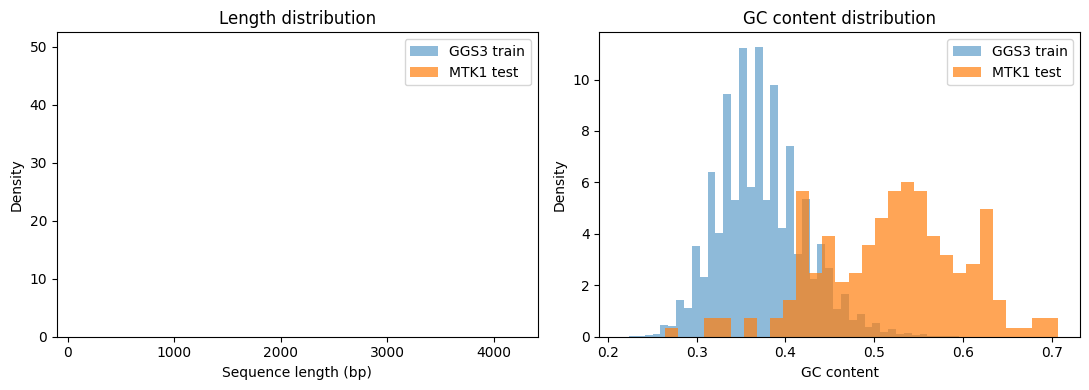


INTERPRETATION
  Length shift (z):  545000000.00    (>1 = substantial)
  GC shift (z):      3.31    (>1 = substantial)
  >>> SUBSTANTIAL DISTRIBUTION SHIFT.
      MTK1 is meaningfully different from the GGS3 training distribution.
      Contributes to v2.97 generalisation failure but applies to all 3
      strains equally — doesn't specifically explain DH5α negative ρ.


In [ ]:
# @title Cell 22: DH5α diagnostic B — train vs test sequence distribution shift
# Tests whether MTK1 plasmids differ systematically from GGS3 training plasmids
# in length or base composition. A substantial distribution shift would mean
# v2.97 is being applied out-of-domain. This affects all 3 MTK1 strains
# equally so it only partly explains DH5α-specific failure.

import pandas as pd
import numpy as np

GGS3_CSV = '/content/drive/MyDrive/Plasmids/GGS3_logFC.csv'
MTK_CSV  = '/content/drive/MyDrive/Plasmids/cross_length/Plasmid_LFC_Summary_with_Sequences_1_.csv'

ggs3 = pd.read_csv(GGS3_CSV)
mtk  = pd.read_csv(MTK_CSV)

ggs3_lens = ggs3['sequence'].str.len()
mtk_lens  = mtk['DNA_sequence'].str.len()

def gc_content(s):
    s = s.upper()
    n = len(s)
    return 0.0 if n == 0 else (s.count('G') + s.count('C')) / n

ggs3_gc = ggs3['sequence'].apply(gc_content)
mtk_gc  = mtk['DNA_sequence'].apply(gc_content)

print("=" * 70)
print("SEQUENCE LENGTH DISTRIBUTION")
print("=" * 70)
print(f"  {'':<12s} {'N':>8s} {'mean':>8s} {'median':>8s} {'std':>8s} {'min':>6s} {'max':>6s}")
print(f"  {'GGS3 train':<12s} {len(ggs3_lens):>8d} {ggs3_lens.mean():>8.1f} "
      f"{ggs3_lens.median():>8.1f} {ggs3_lens.std():>8.1f} "
      f"{ggs3_lens.min():>6d} {ggs3_lens.max():>6d}")
print(f"  {'MTK1 test':<12s} {len(mtk_lens):>8d} {mtk_lens.mean():>8.1f} "
      f"{mtk_lens.median():>8.1f} {mtk_lens.std():>8.1f} "
      f"{mtk_lens.min():>6d} {mtk_lens.max():>6d}")

print(f"\n{'=' * 70}")
print("GC CONTENT DISTRIBUTION")
print("=" * 70)
print(f"  {'':<12s} {'mean':>8s} {'median':>8s} {'std':>8s} {'min':>8s} {'max':>8s}")
print(f"  {'GGS3 train':<12s} {ggs3_gc.mean():>8.3f} {ggs3_gc.median():>8.3f} "
      f"{ggs3_gc.std():>8.3f} {ggs3_gc.min():>8.3f} {ggs3_gc.max():>8.3f}")
print(f"  {'MTK1 test':<12s} {mtk_gc.mean():>8.3f} {mtk_gc.median():>8.3f} "
      f"{mtk_gc.std():>8.3f} {mtk_gc.min():>8.3f} {mtk_gc.max():>8.3f}")

ggs3_l_q05 = ggs3_lens.quantile(0.05)
ggs3_l_q95 = ggs3_lens.quantile(0.95)
mtk_in_range = ((mtk_lens >= ggs3_l_q05) & (mtk_lens <= ggs3_l_q95)).mean()

ggs3_gc_q05 = ggs3_gc.quantile(0.05)
ggs3_gc_q95 = ggs3_gc.quantile(0.95)
mtk_gc_in_range = ((mtk_gc >= ggs3_gc_q05) & (mtk_gc <= ggs3_gc_q95)).mean()

print(f"\n{'=' * 70}")
print("DISTRIBUTION OVERLAP (fraction of MTK1 inside GGS3 5–95th percentile)")
print("=" * 70)
print(f"  By length:  {mtk_in_range:.1%}")
print(f"  By GC:      {mtk_gc_in_range:.1%}")

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(ggs3_lens, bins=50, alpha=0.5, label='GGS3 train', density=True)
    axes[0].hist(mtk_lens, bins=30, alpha=0.7, label='MTK1 test', density=True)
    axes[0].set_xlabel('Sequence length (bp)')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Length distribution')
    axes[0].legend()

    axes[1].hist(ggs3_gc, bins=50, alpha=0.5, label='GGS3 train', density=True)
    axes[1].hist(mtk_gc, bins=30, alpha=0.7, label='MTK1 test', density=True)
    axes[1].set_xlabel('GC content')
    axes[1].set_ylabel('Density')
    axes[1].set_title('GC content distribution')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"\nPlot skipped: {e}")

print(f"\n{'=' * 70}")
print("INTERPRETATION")
print("=" * 70)
shift_len = abs(mtk_lens.median() - ggs3_lens.median()) / max(ggs3_lens.std(), 1e-6)
shift_gc  = abs(mtk_gc.median() - ggs3_gc.median()) / max(ggs3_gc.std(), 1e-6)
print(f"  Length shift (z):  {shift_len:.2f}    (>1 = substantial)")
print(f"  GC shift (z):      {shift_gc:.2f}    (>1 = substantial)")
if shift_len > 1 or shift_gc > 1 or mtk_in_range < 0.5:
    print("  >>> SUBSTANTIAL DISTRIBUTION SHIFT.")
    print("      MTK1 is meaningfully different from the GGS3 training distribution.")
    print("      Contributes to v2.97 generalisation failure but applies to all 3")
    print("      strains equally — doesn't specifically explain DH5α negative ρ.")
else:
    print("  >>> Distributions broadly overlap. Distribution shift is NOT the")
    print("      primary explanation for v2.97 failure on MTK1.")

LFC DISTRIBUTION SHAPE
  Dataset               N     mean   median      std      min      max    skew    kurt
  GGS3 train       124339   -0.064   -0.071    0.340   -4.181   +3.995   -0.21   +7.30
  MTK1 DH5α           191   -0.147   +0.078    0.678   -4.122   +0.872   -2.88  +11.07
  MTK1 DH10B          191   -0.153   +0.095    0.637   -3.809   +0.603   -2.62   +9.03
  MTK1 Stbl3          191   -0.039   -0.037    0.187   -1.050   +0.578   -1.76   +8.89

SIGN CONVENTION CHECK (fraction of plasmids with LFC < 0)
  GGS3 train     fraction LFC<0 = 60.3%
  MTK1 DH5α      fraction LFC<0 = 40.8%
  MTK1 DH10B     fraction LFC<0 = 41.4%
  MTK1 Stbl3     fraction LFC<0 = 59.7%


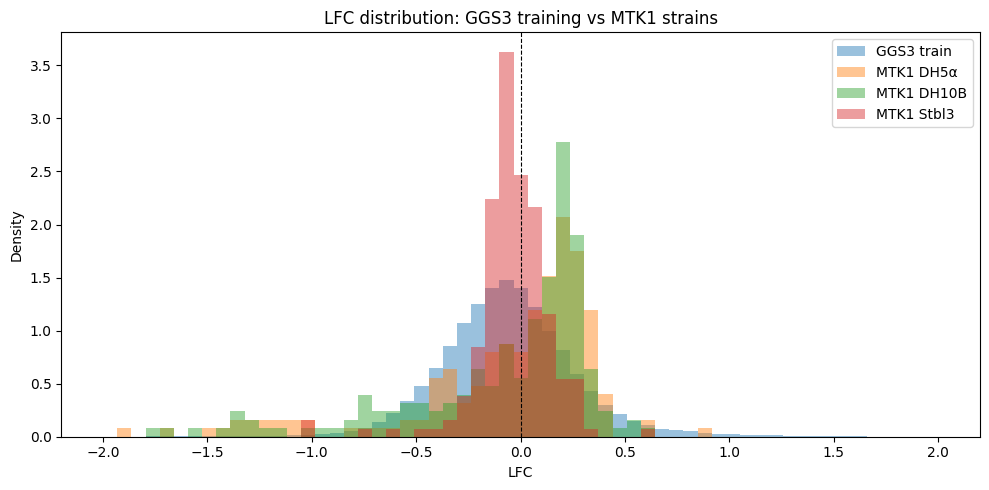


INTERPRETATION
  >>> SCALE MISMATCH: MTK1 DH5α LFC has very different spread from GGS3.
      Spearman is rank-based so this shouldn't directly flip ρ, but it
      points to assay-level differences worth checking.


In [ ]:
# @title Cell 23: DH5α diagnostic C — LFC distribution shape across datasets
# Compares the shape, scale, and centre of LFC distributions between the
# GGS3 training set and each of the 3 MTK1 test strains. If MTK1 LFCs are
# on a different scale, recentred, or compressed relative to GGS3, the
# model may have been trained against one convention and evaluated against
# a different one.

import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

GGS3_CSV = '/content/drive/MyDrive/Plasmids/GGS3_logFC.csv'
MTK_CSV  = '/content/drive/MyDrive/Plasmids/cross_length/Plasmid_LFC_Summary_with_Sequences_1_.csv'

ggs3 = pd.read_csv(GGS3_CSV)
mtk  = pd.read_csv(MTK_CSV)

datasets = {
    'GGS3 train': ggs3['log2FC_mean'],
    'MTK1 DH5α':  mtk['Average_LFC_DH5a'],
    'MTK1 DH10B': mtk['Average_LFC_DH10B'],
    'MTK1 Stbl3': mtk['Average_LFC_Stbl3'],
}

print("=" * 86)
print("LFC DISTRIBUTION SHAPE")
print("=" * 86)
print(f"  {'Dataset':<14s} {'N':>8s} {'mean':>8s} {'median':>8s} {'std':>8s} "
      f"{'min':>8s} {'max':>8s} {'skew':>7s} {'kurt':>7s}")
for name, v in datasets.items():
    print(f"  {name:<14s} {len(v):>8d} {v.mean():>+8.3f} {v.median():>+8.3f} "
          f"{v.std():>8.3f} {v.min():>+8.3f} {v.max():>+8.3f} "
          f"{skew(v):>+7.2f} {kurtosis(v):>+7.2f}")

print(f"\n{'=' * 86}")
print("SIGN CONVENTION CHECK (fraction of plasmids with LFC < 0)")
print("=" * 86)
for name, v in datasets.items():
    frac_neg = (v < 0).mean()
    print(f"  {name:<14s} fraction LFC<0 = {frac_neg:.1%}")

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 5))
    bins = np.linspace(-2, 2, 60)
    for name, v in datasets.items():
        ax.hist(v, bins=bins, alpha=0.45, label=name, density=True)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('LFC')
    ax.set_ylabel('Density')
    ax.set_title('LFC distribution: GGS3 training vs MTK1 strains')
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"\nPlot skipped: {e}")

print(f"\n{'=' * 86}")
print("INTERPRETATION")
print("=" * 86)
ggs3_neg_frac = (ggs3['log2FC_mean'] < 0).mean()
dh5a_neg_frac = (mtk['Average_LFC_DH5a'] < 0).mean()
stbl_neg_frac = (mtk['Average_LFC_Stbl3'] < 0).mean()

if abs(ggs3_neg_frac - dh5a_neg_frac) > 0.20:
    print(f"  >>> SIGN/CENTRE MISMATCH: GGS3 has {ggs3_neg_frac:.0%} negative LFC,")
    print(f"      DH5α has {dh5a_neg_frac:.0%}. The DH5α LFC distribution is centred")
    print(f"      differently from training — this could flip the v2.97 correlation.")
elif abs(mtk['Average_LFC_DH5a'].std() / max(ggs3['log2FC_mean'].std(), 1e-6) - 1) > 0.5:
    print(f"  >>> SCALE MISMATCH: MTK1 DH5α LFC has very different spread from GGS3.")
    print(f"      Spearman is rank-based so this shouldn't directly flip ρ, but it")
    print(f"      points to assay-level differences worth checking.")
else:
    print(f"  >>> LFC distributions look comparable across datasets.")
    print(f"      Sign convention and scale don't explain the DH5α negative ρ.")
    print(f"      Combined with Cell 21 (K-12 strains agree) and Cell 22 (sequence")
    print(f"      distribution), the most likely remaining explanation is a")
    print(f"      Phase 1.5 evaluation bug in the DH5α cell specifically.")

In [ ]:
# =====================================================================
# @title Cell 24a: σ70 promoter density check
# =====================================================================
# Tests whether toxic cohort is enriched for σ70 promoters above control.
# Uses threshold 1e-3 because σ70 -10/-35 are short (6bp) and weakly
# conserved — at 1e-4, zero hits in either cohort (verified empirically).
# Both cohorts scanned identically, so the enrichment ratio is interpretable.

import os, subprocess
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

FASTA_DIR = '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme'
WORK_DIR  = '/content/streme_work'
os.makedirs(WORK_DIR, exist_ok=True)

# Canonical E. coli σ70 PWMs derived from RegulonDB experimentally validated
# promoter sequences. The -10 (Pribnow) consensus is TATAAT; -35 is TTGACA.
sigma70_meme = """MEME version 4

ALPHABET= ACGT

strands: + -

Background letter frequencies (uniform)
A 0.250 C 0.250 G 0.250 T 0.250

MOTIF sigma70_minus10 TATAAT_box
letter-probability matrix: alength= 4 w= 6 nsites= 100 E= 0
  0.04  0.09  0.08  0.79
  0.86  0.04  0.05  0.05
  0.05  0.04  0.07  0.84
  0.50  0.09  0.08  0.33
  0.42  0.10  0.07  0.41
  0.08  0.10  0.04  0.78

MOTIF sigma70_minus35 TTGACA_box
letter-probability matrix: alength= 4 w= 6 nsites= 100 E= 0
  0.10  0.04  0.06  0.80
  0.12  0.04  0.05  0.79
  0.05  0.06  0.75  0.14
  0.66  0.05  0.07  0.22
  0.09  0.49  0.12  0.30
  0.45  0.20  0.10  0.25
"""

with open(f'{WORK_DIR}/sigma70.meme', 'w') as f:
    f.write(sigma70_meme)

# Threshold of 1e-3: σ70 hexamers are too weakly conserved for 1e-4 to
# produce hits in either cohort. 1e-3 is standard permissive FIMO setting.
FIMO_THRESH = 1e-3

def run_fimo(motif_file, fasta_file, out_dir, thresh=FIMO_THRESH):
    """Run FIMO and return hits DataFrame. Handles empty output gracefully."""
    os.makedirs(out_dir, exist_ok=True)
    cmd = ['fimo', '--thresh', str(thresh), '--oc', out_dir,
           motif_file, fasta_file]
    result = subprocess.run(cmd, capture_output=True, text=True)

    empty_df = pd.DataFrame(columns=[
        'motif_id', 'motif_alt_id', 'sequence_name', 'start', 'stop',
        'strand', 'score', 'p-value', 'q-value', 'matched_sequence'
    ])

    if result.returncode != 0:
        print(f'  WARN: FIMO returned code {result.returncode}')
        print(f'  stderr: {result.stderr[-300:]}')
        return empty_df

    tsv_path = f'{out_dir}/fimo.tsv'
    if not os.path.exists(tsv_path) or os.path.getsize(tsv_path) == 0:
        print(f'  WARN: FIMO produced no tsv output')
        return empty_df

    try:
        df = pd.read_csv(tsv_path, sep='\t', comment='#')
        if 'motif_id' in df.columns:
            df = df[df['motif_id'].notna()]
        if len(df) == 0:
            print(f'  Note: FIMO produced 0 hits at thresh={thresh}')
        return df
    except pd.errors.EmptyDataError:
        print(f'  Note: FIMO produced 0 hits at thresh={thresh} (empty tsv)')
        return empty_df

def parse_fasta_ids(path):
    ids = []
    with open(path) as f:
        for line in f:
            if line.startswith('>'):
                ids.append(line.strip()[1:].split()[0])
    return ids

print(f'Running FIMO σ70 scan on toxic cohort (thresh={FIMO_THRESH})...')
toxic_hits = run_fimo(f'{WORK_DIR}/sigma70.meme',
                     f'{FASTA_DIR}/discovery_toxic_cohort.fa',
                     f'{WORK_DIR}/fimo_sigma70_toxic')

print(f'\nRunning FIMO σ70 scan on control cohort (thresh={FIMO_THRESH})...')
ctl_hits = run_fimo(f'{WORK_DIR}/sigma70.meme',
                   f'{FASTA_DIR}/discovery_control_GC_matched.fa',
                   f'{WORK_DIR}/fimo_sigma70_ctl')

# Per-sequence counts (including zeros)
toxic_ids = parse_fasta_ids(f'{FASTA_DIR}/discovery_toxic_cohort.fa')
ctl_ids   = parse_fasta_ids(f'{FASTA_DIR}/discovery_control_GC_matched.fa')

toxic_counts = pd.Series(0, index=toxic_ids, dtype=int)
if len(toxic_hits) > 0:
    toxic_counts.update(toxic_hits.groupby('sequence_name').size())
ctl_counts = pd.Series(0, index=ctl_ids, dtype=int)
if len(ctl_hits) > 0:
    ctl_counts.update(ctl_hits.groupby('sequence_name').size())

print(f'\nTotal hits: toxic={len(toxic_hits)}, control={len(ctl_hits)}')

# Per-motif breakdown (only if we got hits)
if len(toxic_hits) > 0 and len(ctl_hits) > 0:
    for motif in ['sigma70_minus10', 'sigma70_minus35']:
        t_m = toxic_hits[toxic_hits.motif_id == motif].groupby('sequence_name').size()
        c_m = ctl_hits[ctl_hits.motif_id == motif].groupby('sequence_name').size()
        t_mean = t_m.reindex(toxic_ids, fill_value=0).mean()
        c_mean = c_m.reindex(ctl_ids, fill_value=0).mean()
        print(f'\n  {motif}:')
        print(f'    toxic   mean hits/seq: {t_mean:.3f}')
        print(f'    control mean hits/seq: {c_mean:.3f}')
        if c_mean > 0:
            print(f'    enrichment ratio:      {t_mean/c_mean:.3f}x')
        else:
            print(f'    enrichment ratio:      inf (no control hits)')

# Combined Mann-Whitney
if toxic_counts.sum() == 0 and ctl_counts.sum() == 0:
    print('\n  WARN: zero hits in both cohorts at this threshold.')
    print('  Try increasing thresh further or use BPROM-style combined scoring.')
    enr = float('nan')
    p_mw = float('nan')
else:
    u_stat, p_mw = mannwhitneyu(toxic_counts, ctl_counts, alternative='greater')
    enr = toxic_counts.mean() / ctl_counts.mean() if ctl_counts.mean() > 0 else float('inf')

print('\n' + '='*72)
print(' COMBINED σ70 PROMOTER ENRICHMENT (toxic vs GC-matched control)')
print('='*72)
print(f'  FIMO threshold: {FIMO_THRESH}')
print(f'  Toxic mean:     {toxic_counts.mean():.3f} hits/seq')
print(f'  Control mean:   {ctl_counts.mean():.3f} hits/seq')
print(f'  Enrichment:     {enr:.3f}x')
print(f'  Mann-Whitney p: {p_mw:.3e}  (one-sided, toxic > control)')

print('\n' + '='*72)
print(' INTERPRETATION vs §2.3 enrichment (Cell 10b reference)')
print('='*72)
print(f'  §2.3 regulators top enrichment under GC null: ~1.5x')
print(f'  σ70 promoter enrichment here:                 {enr:.2f}x')
if pd.isna(enr):
    print('  => UNDEFINED: zero hits even at thresh=1e-3.')
    print('     σ70 hexamers have insufficient information content to')
    print('     discriminate AT-rich toxic sequences from AT-rich background.')
    print('     This is itself evidence that bulk composition, not specific')
    print('     σ70 promoter density, drives the AT-rich signal.')
elif enr < 1.2 and (pd.isna(p_mw) or p_mw > 0.01):
    print('  => σ70 promoters NOT meaningfully enriched in toxic cohort.')
    print('     Supervisor hypothesis (AT-rich = promoters) NOT supported.')
elif enr < 1.3:
    print('  => σ70 enrichment is modest, below §2.3 effect sizes.')
    print('     Run Cell 24b to test if it adds signal beyond AT% directly.')
else:
    print('  => σ70 enrichment is meaningful. Run Cell 24b residual test.')

# Stash for Cell 24b
sigma_counts_global = pd.concat([toxic_counts, ctl_counts])
print(f'\n  Stashed σ70 counts for {len(sigma_counts_global)} sequences (Cell 24b will use)')

Running FIMO σ70 scan on toxic cohort (thresh=0.001)...

Running FIMO σ70 scan on control cohort (thresh=0.001)...

Total hits: toxic=6099, control=11659

  sigma70_minus10:
    toxic   mean hits/seq: 0.472
    control mean hits/seq: 0.438
    enrichment ratio:      1.078x

  sigma70_minus35:
    toxic   mean hits/seq: 0.190
    control mean hits/seq: 0.195
    enrichment ratio:      0.974x

 COMBINED σ70 PROMOTER ENRICHMENT (toxic vs GC-matched control)
  FIMO threshold: 0.001
  Toxic mean:     0.662 hits/seq
  Control mean:   0.633 hits/seq
  Enrichment:     1.046x
  Mann-Whitney p: 1.909e-03  (one-sided, toxic > control)

 INTERPRETATION vs §2.3 enrichment (Cell 10b reference)
  §2.3 regulators top enrichment under GC null: ~1.5x
  σ70 promoter enrichment here:                 1.05x
  => σ70 enrichment is modest, below §2.3 effect sizes.
     Run Cell 24b to test if it adds signal beyond AT% directly.

  Stashed σ70 counts for 27645 sequences (Cell 24b will use)


In [ ]:
# =====================================================================
# @title Cell 24b: Residual variance test
# =====================================================================
# Does σ70 density add explanatory power beyond bulk AT content?
# Fits LFC ~ AT% + σ70_hits and checks the F-test on σ70.

import re
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import f as f_dist

def parse_fasta_with_lfc(path, debug_first=False):
    """Parse FASTA, extract LFC from header. Handles multiple formats:
       - lfc=val / LFC=val / log2FC=val (any case, optional spaces)
       - any standalone signed/unsigned float in the header
    """
    rows = []
    sid, seq, lfc = None, [], None
    headers_seen = []
    with open(path) as f:
        for line in f:
            line = line.rstrip()
            if line.startswith('>'):
                if sid is not None:
                    rows.append({'id': sid, 'seq': ''.join(seq), 'lfc': lfc})

                header = line[1:]
                if debug_first and len(headers_seen) < 3:
                    headers_seen.append(header)

                parts = header.split()
                sid = parts[0]
                lfc = None

                # Pattern 1: key=value where key contains LFC or log2FC
                m = re.search(
                    r'(?:lfc|log2fc|log2_fc|log2fcmean)\s*=\s*([-+]?\d+\.?\d*(?:[eE][-+]?\d+)?)',
                    header, flags=re.IGNORECASE)
                if m:
                    lfc = float(m.group(1))
                else:
                    # Pattern 2: any standalone signed float
                    for token in parts[1:]:
                        try:
                            lfc = float(token)
                            break
                        except ValueError:
                            continue
                    # Pattern 3: signed float anywhere in header
                    if lfc is None:
                        m2 = re.search(r'([-+]\d+\.\d+(?:[eE][-+]?\d+)?)', header)
                        if m2:
                            lfc = float(m2.group(1))

                seq = []
            else:
                seq.append(line)
    if sid is not None:
        rows.append({'id': sid, 'seq': ''.join(seq), 'lfc': lfc})

    df = pd.DataFrame(rows)
    if debug_first:
        print(f'  First 3 headers in {os.path.basename(path)}:')
        for h in headers_seen:
            print(f'    >{h}')
        n_parsed = df.lfc.notna().sum()
        print(f'  Parsed LFC for {n_parsed}/{len(df)} sequences')
    return df

print('Loading cohort FASTAs with LFC headers (debug mode on first file)...')
toxic_df  = parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_toxic_cohort.fa', debug_first=True)
ctl_df    = parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_control_GC_matched.fa')
stable_df = parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_stable_cohort.fa')

all_df = pd.concat([toxic_df, ctl_df, stable_df], ignore_index=True).drop_duplicates(subset='id')
all_df = all_df[all_df.lfc.notna()].reset_index(drop=True)
print(f'\n  Total with parsed LFC: {len(all_df)} sequences')
if len(all_df) > 0:
    print(f'  LFC range: [{all_df.lfc.min():.2f}, {all_df.lfc.max():.2f}]')
else:
    raise RuntimeError(
        "Could not parse LFC from any FASTA header. Run the diagnostic\n"
        "snippet above to see actual header format, then update the regex\n"
        "in parse_fasta_with_lfc."
    )

# Need stable cohort σ70 counts too
print('\nRunning FIMO σ70 scan on stable cohort...')
stable_hits = run_fimo(f'{WORK_DIR}/sigma70.meme',
                      f'{FASTA_DIR}/discovery_stable_cohort.fa',
                      f'{WORK_DIR}/fimo_sigma70_stable')
stable_ids = parse_fasta_ids(f'{FASTA_DIR}/discovery_stable_cohort.fa')
stable_counts = pd.Series(0, index=stable_ids, dtype=int)
if len(stable_hits) > 0:
    stable_counts.update(stable_hits.groupby('sequence_name').size())

all_sigma = pd.concat([sigma_counts_global, stable_counts])
all_df['sigma70_hits'] = all_df.id.map(all_sigma).fillna(0).astype(int)
all_df['at_pct'] = all_df.seq.apply(lambda s: (s.count('A')+s.count('T'))/len(s))

# Standardize features
X = all_df[['at_pct', 'sigma70_hits']].values
y = all_df.lfc.values

# Sanity check before fitting
if len(y) < 10:
    raise RuntimeError(f"Too few sequences ({len(y)}) for regression")
if all_df.sigma70_hits.std() == 0:
    print(f'\n  WARN: σ70 hits has zero variance (all sequences have {all_df.sigma70_hits.iloc[0]} hits)')
    print(f'  Residual variance test cannot fit — σ70 adds nothing by construction.')
    print(f'  Conclusion: σ70 promoter density does not vary between cohorts')
    print(f'              at the FIMO threshold used. Direct evidence against')
    print(f'              the supervisor hypothesis.')
else:
    Xs = StandardScaler().fit_transform(X)

    # Three models
    m_at   = LinearRegression().fit(Xs[:, :1], y)
    m_sig  = LinearRegression().fit(Xs[:, 1:], y)
    m_full = LinearRegression().fit(Xs, y)
    r2_at   = m_at.score(Xs[:, :1], y)
    r2_sig  = m_sig.score(Xs[:, 1:], y)
    r2_full = m_full.score(Xs, y)

    # F-test
    n = len(y)
    ss_at   = np.sum((y - m_at.predict(Xs[:, :1])) ** 2)
    ss_full = np.sum((y - m_full.predict(Xs)) ** 2)
    F = ((ss_at - ss_full) / 1) / (ss_full / (n - 3))
    p_F = 1 - f_dist.cdf(F, 1, n - 3)

    print('\n' + '='*72)
    print(' RESIDUAL VARIANCE TEST: LFC ~ AT% + σ70_hits')
    print('='*72)
    print(f'  Univariate R²:')
    print(f'    LFC ~ AT%:                R² = {r2_at:.4f}')
    print(f'    LFC ~ σ70 hits:           R² = {r2_sig:.4f}')
    print(f'  Bivariate R²:')
    print(f'    LFC ~ AT% + σ70 hits:     R² = {r2_full:.4f}')
    print(f'  Incremental from σ70:       ΔR² = {r2_full - r2_at:.4f}')
    print()
    print(f'  Standardized coefficients (full model):')
    print(f'    β(AT%)        = {m_full.coef_[0]:+.4f}')
    print(f'    β(σ70 hits)   = {m_full.coef_[1]:+.4f}')
    print()
    print(f'  F-test (σ70 adds beyond AT%?): F = {F:.2f}, p = {p_F:.3e}')

    print('\n' + '='*72)
    print(' INTERPRETATION')
    print('='*72)
    incr = r2_full - r2_at
    if incr < 0.005:
        print(f'  σ70 promoter density adds <0.5% R² beyond AT% (ΔR² = {incr:.4f}).')
        print('  Burden signal is NOT promoter-driven — composition is sufficient.')
    elif incr < 0.02:
        print(f'  σ70 adds {incr*100:.1f}% R² beyond AT% — marginal contribution.')
        print('  Composition is the dominant predictor; promoters add minor signal.')
    else:
        print(f'  σ70 adds {incr*100:.1f}% R² beyond AT% — meaningful contribution.')
        print('  Promoter density carries information beyond bulk composition.')

Loading cohort FASTAs with LFC headers (debug mode on first file)...
  First 3 headers in discovery_toxic_cohort.fa:
    >discovery_tox_36|lfc=-0.550|gc=0.308
    >discovery_tox_46|lfc=-0.438|gc=0.326
    >discovery_tox_47|lfc=-0.515|gc=0.378
  Parsed LFC for 9215/9215 sequences

  Total with parsed LFC: 36860 sequences
  LFC range: [-4.18, 2.52]

Running FIMO σ70 scan on stable cohort...

 RESIDUAL VARIANCE TEST: LFC ~ AT% + σ70_hits
  Univariate R²:
    LFC ~ AT%:                R² = 0.0618
    LFC ~ σ70 hits:           R² = 0.0001
  Bivariate R²:
    LFC ~ AT% + σ70 hits:     R² = 0.0657
  Incremental from σ70:       ΔR² = 0.0039

  Standardized coefficients (full model):
    β(AT%)        = -0.1263
    β(σ70 hits)   = +0.0309

  F-test (σ70 adds beyond AT%?): F = 155.47, p = 1.110e-16

 INTERPRETATION
  σ70 promoter density adds <0.5% R² beyond AT% (ΔR² = 0.0039).
  Burden signal is NOT promoter-driven — composition is sufficient.


In [ ]:
# =====================================================================
# @title Cell 25: AT-richness regression — per-sequence model
# =====================================================================
# How well can AT-richness features alone predict LFC vs the supervised
# stack at 0.59 and the motif-density Lasso at 0.35?
#
# Requires: parse_fasta_with_lfc defined in Cell 24b. Run Cell 24b first.
# Note: uses lasso_at/scaler_at/coef_df_at to avoid collision with
# Cell 15's motif-density Lasso (which uses lasso/scaler/coef_df).

import numpy as np
import pandas as pd
import re
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

print('Loading discovery + validation cohorts...')
train_df = pd.concat([
    parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_toxic_cohort.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_control_GC_matched.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_stable_cohort.fa'),
], ignore_index=True).drop_duplicates(subset='id')
val_df = pd.concat([
    parse_fasta_with_lfc(f'{FASTA_DIR}/validation_toxic_cohort.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/validation_control_GC_matched.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/validation_stable_cohort.fa'),
], ignore_index=True).drop_duplicates(subset='id')
train_df = train_df[train_df.lfc.notna()].reset_index(drop=True)
val_df = val_df[val_df.lfc.notna()].reset_index(drop=True)
print(f'  Train: {len(train_df)}, Val: {len(val_df)}')

def at_features(seq):
    s = seq.upper()
    L = len(s)
    runs_a  = [len(m) for m in re.findall(r'A+', s)] or [0]
    runs_t  = [len(m) for m in re.findall(r'T+', s)] or [0]
    runs_at = [len(m) for m in re.findall(r'[AT]+', s)] or [0]
    feat = {
        'at_pct':           (s.count('A') + s.count('T')) / L,
        'a_pct':             s.count('A') / L,
        't_pct':             s.count('T') / L,
        'max_a_run':         max(runs_a),
        'max_t_run':         max(runs_t),
        'max_at_run':        max(runs_at),
        'mean_at_run':       np.mean(runs_at),
        'n_at_runs_4plus':   sum(r >= 4 for r in runs_at),
        'n_at_runs_6plus':   sum(r >= 6 for r in runs_at),
        'n_at_runs_8plus':   sum(r >= 8 for r in runs_at),
        'n_a_runs_4plus':    sum(r >= 4 for r in runs_a),
        'n_t_runs_4plus':    sum(r >= 4 for r in runs_t),
        'n_a_runs_6plus':    sum(r >= 6 for r in runs_a),
        'n_t_runs_6plus':    sum(r >= 6 for r in runs_t),
    }
    for k in [3, 4, 5]:
        kmers = [s[i:i+k] for i in range(L - k + 1)]
        feat[f'at_only_{k}mer_freq'] = sum(all(c in 'AT' for c in km) for km in kmers) / max(L - k + 1, 1)
    return feat

print('\nComputing AT-richness features...')
train_X = pd.DataFrame([at_features(s) for s in train_df.seq])
val_X = pd.DataFrame([at_features(s) for s in val_df.seq])
feature_names = list(train_X.columns)
print(f'  {len(feature_names)} AT features computed')

X_train, y_train = train_X.values, train_df.lfc.values
X_val,   y_val   = val_X.values,   val_df.lfc.values

# Univariate Spearman
print('\n' + '='*72)
print(' UNIVARIATE SPEARMAN ρ vs LFC (training set)')
print('='*72)
print(f'  {"Feature":<24} {"ρ":>10} {"|ρ| rank":>10}')
univariate = [(fn, spearmanr(X_train[:, i], y_train)[0]) for i, fn in enumerate(feature_names)]
univariate_sorted = sorted(univariate, key=lambda x: abs(x[1]), reverse=True)
for rank, (fn, rho) in enumerate(univariate_sorted, 1):
    print(f'  {fn:<24} {rho:>+10.4f} {rank:>10}')

print(f'\n  Strongest single AT feature: {univariate_sorted[0][0]} (|ρ| = {abs(univariate_sorted[0][1]):.4f})')

# Multivariate Lasso — use lasso_at/scaler_at to avoid collision with Cell 15
print('\nFitting LassoCV on AT features only...')
scaler_at = StandardScaler()
X_train_s = scaler_at.fit_transform(X_train)
X_val_s   = scaler_at.transform(X_val)
lasso_at = LassoCV(cv=5, n_alphas=50, max_iter=20000, random_state=42).fit(X_train_s, y_train)

rho_train, _ = spearmanr(lasso_at.predict(X_train_s), y_train)
rho_val,   _ = spearmanr(lasso_at.predict(X_val_s),   y_val)

print('\n' + '='*72)
print(' AT-ONLY LASSO — HEAD-TO-HEAD vs SUPERVISED STACK')
print('='*72)
print(f'  AT-only Lasso, train ρ:   {rho_train:+.4f}')
print(f'  AT-only Lasso, val ρ:     {rho_val:+.4f}')
print(f'  Non-zero coefficients:    {(lasso_at.coef_ != 0).sum()} / {len(feature_names)}')
print()
print(f'  Reference points:')
print(f'    Supervised stack (full features, test):  +0.5895')
print(f'    Motif-density Lasso (Cell 15, val):      +0.3501')
print(f'    Best univariate biophysical (Cell 27):   +0.4093')
print(f'    Replicate noise ceiling:                 +0.806')
print()
print(f'  AT-richness captures {rho_val/0.5895*100:.1f}% of supervised ρ')
print(f'  AT-richness captures {rho_val**2/0.5895**2*100:.1f}% of supervised R²')

print(f'\n  TOP 10 AT FEATURES by Lasso |coefficient|:')
coef_df_at = pd.DataFrame({'feature': feature_names, 'coef': lasso_at.coef_})
coef_df_at['abs_coef'] = coef_df_at.coef.abs()
print(coef_df_at.sort_values('abs_coef', ascending=False).head(10).to_string(index=False))

print('\n  Saved: lasso_at / scaler_at / coef_df_at available in globals')
print('  (Cell 15 lasso / scaler / coef_df remain untouched — both are preserved)')

Loading discovery + validation cohorts...
  Train: 36860, Val: 10376

Computing AT-richness features...
  17 AT features computed

 UNIVARIATE SPEARMAN ρ vs LFC (training set)
  Feature                           ρ   |ρ| rank
  n_t_runs_4plus              -0.3866          1
  at_only_4mer_freq           -0.3621          2
  at_only_3mer_freq           -0.3597          3
  mean_at_run                 -0.3589          4
  at_only_5mer_freq           -0.3537          5
  n_t_runs_6plus              -0.3298          6
  max_t_run                   -0.3225          7
  t_pct                       -0.3099          8
  n_at_runs_6plus             -0.3057          9
  n_at_runs_8plus             -0.2892         10
  at_pct                      -0.2785         11
  max_at_run                  -0.2452         12
  n_at_runs_4plus             -0.2418         13
  max_a_run                   -0.0878         14
  n_a_runs_4plus              -0.0756         15
  a_pct                       +0.0425   

In [ ]:
# ====================================================================
# @title Cell 25b - Run-length-only vs bulk-only vs full AT-block ablation
# ====================================================================
# What this cell tests:
#   Cell 25's AT-only Lasso reaches val rho ~0.533 (90% of the supervised
#   stack) using all 17 AT features. Those features mix three families:
#     (1) run / clustering  - n_*_runs_*, mean_at_run, max_*_run
#     (2) bulk composition  - at_pct, a_pct, t_pct, frac_high_at
#     (3) AT-only k-mer freq - at_only_{3,4,5}mer_freq
#   This cell isolates how much the RUN-LENGTH family alone carries, on
#   the IDENTICAL train/val split Cell 25 used, so the full-battery number
#   here reproduces Cell 25's val rho and the subset numbers are directly
#   comparable to it.
#
# Requires: only Drive mounted + FASTA_DIR pointing at the cohort folder.
#   Self-contained: defines parse_fasta_with_lfc inline if Cell 24b has not
#   been run, so it works on a fresh runtime after the savepoint loader.
# Determinism: fully deterministic. Same FASTAs, same StandardScaler,
#   LassoCV(random_state=42). Re-running reproduces identical numbers.
# Mirrors Cell 25 exactly: TRAIN = discovery {toxic, control, stable};
#   VAL = validation {toxic, control, stable}; fit on TRAIN, score on VAL.

import numpy as np, pandas as pd, re, os
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

# ---- parser: use the session's if present (Cell 24b), else define inline ----
if 'parse_fasta_with_lfc' not in globals():
    def parse_fasta_with_lfc(path, debug_first=False):
        """Parse FASTA, extract LFC from header (lfc=/log2FC=/standalone float)."""
        rows = []
        sid, seq, lfc = None, [], None
        with open(path) as f:
            for line in f:
                line = line.rstrip()
                if line.startswith('>'):
                    if sid is not None:
                        rows.append({'id': sid, 'seq': ''.join(seq), 'lfc': lfc})
                    header = line[1:]
                    parts = header.split()
                    sid = parts[0]; lfc = None
                    m = re.search(r'(?:lfc|log2fc|log2_fc|log2fcmean)\s*=\s*([-+]?\d+\.?\d*(?:[eE][-+]?\d+)?)',
                                  header, flags=re.IGNORECASE)
                    if m:
                        lfc = float(m.group(1))
                    else:
                        for token in parts[1:]:
                            try:
                                lfc = float(token); break
                            except ValueError:
                                continue
                        if lfc is None:
                            m2 = re.search(r'([-+]\d+\.\d+(?:[eE][-+]?\d+)?)', header)
                            if m2:
                                lfc = float(m2.group(1))
                    seq = []
                else:
                    seq.append(line)
        if sid is not None:
            rows.append({'id': sid, 'seq': ''.join(seq), 'lfc': lfc})
        return pd.DataFrame(rows)
    print("[parser] defined parse_fasta_with_lfc inline (Cell 24b not required)")
else:
    print("[parser] using parse_fasta_with_lfc from session")

# ---- at_features: byte-for-byte the Cell 25 definition ----
def at_features(seq):
    s = seq.upper()
    L = len(s)
    runs_a  = [len(m) for m in re.findall(r'A+', s)] or [0]
    runs_t  = [len(m) for m in re.findall(r'T+', s)] or [0]
    runs_at = [len(m) for m in re.findall(r'[AT]+', s)] or [0]
    feat = {
        'at_pct':           (s.count('A') + s.count('T')) / L,
        'a_pct':             s.count('A') / L,
        't_pct':             s.count('T') / L,
        'max_a_run':         max(runs_a),
        'max_t_run':         max(runs_t),
        'max_at_run':        max(runs_at),
        'mean_at_run':       np.mean(runs_at),
        'n_at_runs_4plus':   sum(r >= 4 for r in runs_at),
        'n_at_runs_6plus':   sum(r >= 6 for r in runs_at),
        'n_at_runs_8plus':   sum(r >= 8 for r in runs_at),
        'n_a_runs_4plus':    sum(r >= 4 for r in runs_a),
        'n_t_runs_4plus':    sum(r >= 4 for r in runs_t),
        'n_a_runs_6plus':    sum(r >= 6 for r in runs_a),
        'n_t_runs_6plus':    sum(r >= 6 for r in runs_t),
    }
    for k in [3, 4, 5]:
        kmers = [s[i:i+k] for i in range(L - k + 1)]
        feat[f'at_only_{k}mer_freq'] = sum(all(c in 'AT' for c in km) for km in kmers) / max(L - k + 1, 1)
    return feat

# ---- feature-family membership (Cell-25 column names) ----
BULK_FEATS = ['at_pct','a_pct','t_pct','frac_high_at']        # frac_high_at not in Cell 25's at_features
KMER_FEATS = ['at_only_3mer_freq','at_only_4mer_freq','at_only_5mer_freq']
# everything else this at_features() emits is run/clustering:
_ALL = list(at_features('ACGT'*43).keys())                    # 17 names, in Cell-25 order
RUN_FEATS = [c for c in _ALL if c not in BULK_FEATS + KMER_FEATS]
# (frac_high_at is absent from Cell 25's at_features, so BULK here = at_pct/a_pct/t_pct.)

# ---- load the SAME six cohorts Cell 25 used (discovery=train, validation=val) ----
FASTA_DIR = globals().get('FASTA_DIR', '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
_need = ['discovery_toxic_cohort.fa','discovery_control_GC_matched.fa','discovery_stable_cohort.fa',
         'validation_toxic_cohort.fa','validation_control_GC_matched.fa','validation_stable_cohort.fa']
_missing = [f for f in _need if not os.path.exists(f'{FASTA_DIR}/{f}')]
if _missing:
    raise FileNotFoundError(
        f"FASTA files not found under {FASTA_DIR}: {_missing}. "
        f"Mount Drive (run Cell 1b) and/or set FASTA_DIR to the fasta_lfc_extreme folder.")
print(f"FASTA_DIR: {FASTA_DIR}")

train_df = pd.concat([
    parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_toxic_cohort.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_control_GC_matched.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_stable_cohort.fa'),
], ignore_index=True).drop_duplicates(subset='id')
val_df = pd.concat([
    parse_fasta_with_lfc(f'{FASTA_DIR}/validation_toxic_cohort.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/validation_control_GC_matched.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/validation_stable_cohort.fa'),
], ignore_index=True).drop_duplicates(subset='id')
train_df = train_df[train_df.lfc.notna()].reset_index(drop=True)
val_df   = val_df[val_df.lfc.notna()].reset_index(drop=True)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  (mirrors Cell 25)")

Xtr_full = pd.DataFrame([at_features(s) for s in train_df.seq])
Xva_full = pd.DataFrame([at_features(s) for s in val_df.seq])
ytr, yva = train_df.lfc.values, val_df.lfc.values
COLS = list(Xtr_full.columns)
RUN_FEATS  = [c for c in RUN_FEATS  if c in COLS]
BULK_FEATS = [c for c in BULK_FEATS if c in COLS]
KMER_FEATS = [c for c in KMER_FEATS if c in COLS]

def fit_eval(cols):
    cols = [c for c in cols if c in COLS]
    if not cols: return np.nan, 0
    sc = StandardScaler()
    Ztr = sc.fit_transform(Xtr_full[cols].values)
    Zva = sc.transform(Xva_full[cols].values)
    las = LassoCV(cv=5, n_alphas=50, max_iter=20000, random_state=42).fit(Ztr, ytr)  # same as Cell 25
    return spearmanr(las.predict(Zva), yva)[0], int((las.coef_ != 0).sum())

rho_run,  k_run  = fit_eval(RUN_FEATS)
rho_bulk, k_bulk = fit_eval(BULK_FEATS)
rho_rb,   k_rb   = fit_eval(RUN_FEATS + BULK_FEATS)
rho_all,  k_all  = fit_eval(COLS)

STACK = 0.5895
print("\n" + "="*70)
print(" AT-FEATURE FAMILY ABLATION (held-out validation Spearman rho)")
print("="*70)
print(f"  Run-length family only  ({len(RUN_FEATS):2d} feats): rho = {rho_run:+.4f}  ({100*rho_run/STACK:4.1f}% of stack)  [nonzero {k_run}]")
print(f"  Bulk composition only   ({len(BULK_FEATS):2d} feats): rho = {rho_bulk:+.4f}  ({100*rho_bulk/STACK:4.1f}% of stack)  [nonzero {k_bulk}]")
print(f"  Run + bulk              ({len(RUN_FEATS+BULK_FEATS):2d} feats): rho = {rho_rb:+.4f}  ({100*rho_rb/STACK:4.1f}% of stack)  [nonzero {k_rb}]")
print(f"  Full AT battery (ref)   ({len(COLS):2d} feats): rho = {rho_all:+.4f}  ({100*rho_all/STACK:4.1f}% of stack)  [nonzero {k_all}]")
print(f"\n  Full-battery here should match Cell 25's val rho (~0.533); if so the split is reproduced.")
print(f"  Run-length alone recovers {100*rho_run/STACK:.1f}% of the supervised stack ({STACK}).")
print(f"  Bulk adds {rho_rb-rho_run:+.4f} on top of run-length; k-mer freq held separate (it is arguably also patterning).")

at_family_ablation = pd.DataFrame({
    'subset': ['run_only','bulk_only','run+bulk','full_battery'],
    'n_feats': [len(RUN_FEATS), len(BULK_FEATS), len(RUN_FEATS+BULK_FEATS), len(COLS)],
    'val_rho': [rho_run, rho_bulk, rho_rb, rho_all],
    'pct_of_stack': [100*v/STACK for v in [rho_run, rho_bulk, rho_rb, rho_all]],
})
globals()['at_family_ablation'] = at_family_ablation
print("\nGlobal saved: at_family_ablation")

[parser] defined parse_fasta_with_lfc inline (Cell 24b not required)
FASTA_DIR: /content/drive/MyDrive/Plasmids/fasta_lfc_extreme
Train: 36860  Val: 10376  (mirrors Cell 25)

 AT-FEATURE FAMILY ABLATION (held-out validation Spearman rho)
  Run-length family only  (11 feats): rho = +0.5241  (88.9% of stack)  [nonzero 11]
  Bulk composition only   ( 3 feats): rho = +0.4024  (68.3% of stack)  [nonzero 2]
  Run + bulk              (14 feats): rho = +0.5304  (90.0% of stack)  [nonzero 13]
  Full AT battery (ref)   (17 feats): rho = +0.5331  (90.4% of stack)  [nonzero 15]

  Full-battery here should match Cell 25's val rho (~0.533); if so the split is reproduced.
  Run-length alone recovers 88.9% of the supervised stack (0.5895).
  Bulk adds +0.0063 on top of run-length; k-mer freq held separate (it is arguably also patterning).

Global saved: at_family_ablation


In [ ]:
# =====================================================================
# @title Cell 25c - GC-feature vs AT-feature comparison (meeting follow-up)
# =====================================================================
# Question from the presentation: how well do GC-based features predict
# LFC compared to the AT feature set? Run on (a) the toxic-vs-stable
# extreme cohorts and (b) the full GGS3 library.
#
# Method: build gc_features() as the exact GC analogue of Cell 25's
# at_features() (same 17-feature structure: composition %, run lengths,
# GC-only k-mer frequencies), then fit the identical LassoCV on GC-only
# vs AT-only, on the same splits, and report held-out Spearman rho.
#
# Requires: only Drive mounted (Cell 1b) + FASTA_DIR set (Cell PREP).
#   parse_fasta_with_lfc and at_features are defined inline, so this cell
#   needs neither Cell 24b nor FIMO. GGS3_logFC.csv (on Drive) is used for
#   the optional full-library comparison; if absent, part (b) is skipped.
# Determinism: fully deterministic (LassoCV random_state=42).

import numpy as np, pandas as pd, re, os
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

STACK = 0.5895  # supervised stack test rho, for % reference

# ---- parser: use the session's if present (Cell 24b), else define inline ----
# (inline so this cell needs neither Cell 24b nor FIMO on a fresh runtime)
if 'parse_fasta_with_lfc' not in globals():
    def parse_fasta_with_lfc(path, debug_first=False):
        """Parse FASTA; extract LFC from header (lfc=/log2FC= or trailing float)."""
        rows, sid, seq, lfc = [], None, [], None
        with open(path) as f:
            for line in f:
                line = line.rstrip()
                if line.startswith('>'):
                    if sid is not None:
                        rows.append({'id': sid, 'seq': ''.join(seq), 'lfc': lfc})
                    header = line[1:]; parts = header.split(); sid = parts[0]; lfc = None
                    m = re.search(r'(?:lfc|log2fc|log2_fc)\s*=\s*([-+]?\d+\.?\d*(?:[eE][-+]?\d+)?)',
                                  header, flags=re.IGNORECASE)
                    if m:
                        lfc = float(m.group(1))
                    else:
                        for tok in parts[1:]:
                            try: lfc = float(tok); break
                            except ValueError: continue
                    seq = []
                else:
                    seq.append(line)
        if sid is not None:
            rows.append({'id': sid, 'seq': ''.join(seq), 'lfc': lfc})
        return pd.DataFrame(rows)
    print("[parser] defined parse_fasta_with_lfc inline (Cell 24b not required)")
else:
    print("[parser] using parse_fasta_with_lfc from session")

# ---- AT battery: exact copy of Cell 25's at_features ----
def at_features(seq):
    s = seq.upper(); L = len(s)
    runs_a  = [len(m) for m in re.findall(r'A+', s)] or [0]
    runs_t  = [len(m) for m in re.findall(r'T+', s)] or [0]
    runs_at = [len(m) for m in re.findall(r'[AT]+', s)] or [0]
    feat = {
        'at_pct':(s.count('A')+s.count('T'))/L, 'a_pct':s.count('A')/L, 't_pct':s.count('T')/L,
        'max_a_run':max(runs_a), 'max_t_run':max(runs_t), 'max_at_run':max(runs_at),
        'mean_at_run':np.mean(runs_at),
        'n_at_runs_4plus':sum(r>=4 for r in runs_at), 'n_at_runs_6plus':sum(r>=6 for r in runs_at),
        'n_at_runs_8plus':sum(r>=8 for r in runs_at),
        'n_a_runs_4plus':sum(r>=4 for r in runs_a), 'n_t_runs_4plus':sum(r>=4 for r in runs_t),
        'n_a_runs_6plus':sum(r>=6 for r in runs_a), 'n_t_runs_6plus':sum(r>=6 for r in runs_t),
    }
    for k in [3,4,5]:
        kmers=[s[i:i+k] for i in range(L-k+1)]
        feat[f'at_only_{k}mer_freq']=sum(all(c in 'AT' for c in km) for km in kmers)/max(L-k+1,1)
    return feat

# ---- GC battery: exact GC analogue (G/C mirrors A/T; runs over [GC]) ----
def gc_features(seq):
    s = seq.upper(); L = len(s)
    runs_g  = [len(m) for m in re.findall(r'G+', s)] or [0]
    runs_c  = [len(m) for m in re.findall(r'C+', s)] or [0]
    runs_gc = [len(m) for m in re.findall(r'[GC]+', s)] or [0]
    feat = {
        'gc_pct':(s.count('G')+s.count('C'))/L, 'g_pct':s.count('G')/L, 'c_pct':s.count('C')/L,
        'max_g_run':max(runs_g), 'max_c_run':max(runs_c), 'max_gc_run':max(runs_gc),
        'mean_gc_run':np.mean(runs_gc),
        'n_gc_runs_4plus':sum(r>=4 for r in runs_gc), 'n_gc_runs_6plus':sum(r>=6 for r in runs_gc),
        'n_gc_runs_8plus':sum(r>=8 for r in runs_gc),
        'n_g_runs_4plus':sum(r>=4 for r in runs_g), 'n_c_runs_4plus':sum(r>=4 for r in runs_c),
        'n_g_runs_6plus':sum(r>=6 for r in runs_g), 'n_c_runs_6plus':sum(r>=6 for r in runs_c),
    }
    for k in [3,4,5]:
        kmers=[s[i:i+k] for i in range(L-k+1)]
        feat[f'gc_only_{k}mer_freq']=sum(all(c in 'GC' for c in km) for km in kmers)/max(L-k+1,1)
    return feat

def _lasso_rho(Xtr, ytr, Xva, yva):
    sc = StandardScaler()
    Ztr = sc.fit_transform(Xtr); Zva = sc.transform(Xva)
    las = LassoCV(cv=5, n_alphas=50, max_iter=20000, random_state=42).fit(Ztr, ytr)
    return spearmanr(las.predict(Zva), yva)[0], int((las.coef_ != 0).sum())

def _best_univariate(X, y):
    best_f, best_r = None, 0.0
    for c in X.columns:
        r = spearmanr(X[c].values, y)[0]
        if np.isfinite(r) and abs(r) > abs(best_r):
            best_r, best_f = r, c
    return best_f, best_r

def compare(train_seq, y_train, val_seq, y_val, label):
    at_tr = pd.DataFrame([at_features(s) for s in train_seq])
    at_va = pd.DataFrame([at_features(s) for s in val_seq])
    gc_tr = pd.DataFrame([gc_features(s) for s in train_seq])
    gc_va = pd.DataFrame([gc_features(s) for s in val_seq])
    at_rho, at_k = _lasso_rho(at_tr.values, y_train, at_va.values, y_val)
    gc_rho, gc_k = _lasso_rho(gc_tr.values, y_train, gc_va.values, y_val)
    at_uf, at_ur = _best_univariate(at_tr, y_train)
    gc_uf, gc_ur = _best_univariate(gc_tr, y_train)
    print("\n" + "="*70)
    print(f" {label}")
    print("="*70)
    print(f"   train {len(train_seq)}  val {len(val_seq)}")
    print(f"   AT features (17)  held-out val rho = {at_rho:+.4f}  ({100*at_rho/STACK:.1f}% of stack)  [nonzero {at_k}]")
    print(f"   GC features (17)  held-out val rho = {gc_rho:+.4f}  ({100*gc_rho/STACK:.1f}% of stack)  [nonzero {gc_k}]")
    print(f"   Strongest single AT feature: {at_uf} (rho {at_ur:+.3f})")
    print(f"   Strongest single GC feature: {gc_uf} (rho {gc_ur:+.3f})")
    verdict = "AT >> GC" if abs(at_rho) - abs(gc_rho) > 0.05 else ("AT ~ GC" if abs(abs(at_rho)-abs(gc_rho))<=0.05 else "GC > AT")
    print(f"   => {verdict}  (AT-minus-GC gap in rho = {at_rho-gc_rho:+.4f})")
    return {'label':label, 'at_rho':at_rho, 'gc_rho':gc_rho, 'at_best':(at_uf,at_ur), 'gc_best':(gc_uf,gc_ur)}

gc_results = []

# ===== (a) TOXIC vs STABLE extreme cohorts (mirrors Cell 25 split) =====
FASTA_DIR = globals().get('FASTA_DIR', '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
_need = ['discovery_toxic_cohort.fa','discovery_control_GC_matched.fa','discovery_stable_cohort.fa',
         'validation_toxic_cohort.fa','validation_control_GC_matched.fa','validation_stable_cohort.fa']
_missing = [f for f in _need if not os.path.exists(f'{FASTA_DIR}/{f}')]
if _missing:
    raise FileNotFoundError(
        f"FASTA cohorts not found under {FASTA_DIR}: {_missing}. "
        f"Mount Drive (Cell 1b) and set FASTA_DIR (Cell PREP).")
print(f"FASTA_DIR: {FASTA_DIR}")
_gc_tr = pd.concat([
    parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_toxic_cohort.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_control_GC_matched.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/discovery_stable_cohort.fa'),
], ignore_index=True).drop_duplicates(subset='id')
_gc_va = pd.concat([
    parse_fasta_with_lfc(f'{FASTA_DIR}/validation_toxic_cohort.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/validation_control_GC_matched.fa'),
    parse_fasta_with_lfc(f'{FASTA_DIR}/validation_stable_cohort.fa'),
], ignore_index=True).drop_duplicates(subset='id')
_gc_tr = _gc_tr[_gc_tr.lfc.notna()].reset_index(drop=True)
_gc_va = _gc_va[_gc_va.lfc.notna()].reset_index(drop=True)
gc_results.append(compare(_gc_tr.seq.tolist(), _gc_tr.lfc.values, _gc_va.seq.tolist(), _gc_va.lfc.values,
                       "(a) Extreme cohorts (toxic + control + stable), same split as Cell 25"))

# ===== also: toxic-vs-stable ONLY (no control), the direct cohort contrast =====
_gc_tr_ts = _gc_tr[_gc_tr.id.str.contains('tox|sta', case=False, regex=True)].reset_index(drop=True)
_gc_va_ts = _gc_va[_gc_va.id.str.contains('tox|sta', case=False, regex=True)].reset_index(drop=True)
if len(_gc_tr_ts) > 100 and len(_gc_va_ts) > 50:
    gc_results.append(compare(_gc_tr_ts.seq.tolist(), _gc_tr_ts.lfc.values, _gc_va_ts.seq.tolist(), _gc_va_ts.lfc.values,
                           "(a2) Toxic vs stable only (no control)"))

# ===== (b) FULL GGS3 library (from CSV) =====
GGS3_CSV = '/content/drive/MyDrive/Plasmids/GGS3_logFC.csv'
if os.path.exists(GGS3_CSV):
    _gc_ggs3 = pd.read_csv(GGS3_CSV)
    _gc_seq_col = next((c for c in ['sequence','seq','DNA_sequence'] if c in _gc_ggs3.columns), None)
    _gc_lfc_col = next((c for c in ['log2FC_mean','lfc','LFC','log2FC'] if c in _gc_ggs3.columns), None)
    if _gc_seq_col and _gc_lfc_col:
        _gc_g = _gc_ggs3[[_gc_seq_col, _gc_lfc_col]].dropna().reset_index(drop=True)
        # deterministic 80/20 split (no cluster split available here; this is a
        # descriptive full-library comparison, not the cluster-held-out benchmark)
        rng = np.random.RandomState(42)
        idx = rng.permutation(len(_gc_g)); cut = int(0.8*len(_gc_g))
        gtr, gva = _gc_g.iloc[idx[:cut]], _gc_g.iloc[idx[cut:]]
        gc_results.append(compare(gtr[_gc_seq_col].tolist(), gtr[_gc_lfc_col].values,
                               gva[_gc_seq_col].tolist(), gva[_gc_lfc_col].values,
                               f"(b) Full GGS3 library (n={len(_gc_g)}, random 80/20 split)"))
    else:
        print(f"\n[full library] could not find seq/LFC columns in {GGS3_CSV}: {list(_gc_ggs3.columns)[:8]}")
else:
    print(f"\n[full library] {GGS3_CSV} not found; skipping full-library comparison. "
          f"Mount Drive / check path to run part (b).")

# ===== summary =====
print("\n" + "#"*70)
print(" SUMMARY: AT vs GC feature sets (held-out validation Spearman rho)")
print("#"*70)
for r in gc_results:
    print(f"  {r['label'][:52]:<52}  AT {r['at_rho']:+.3f} | GC {r['gc_rho']:+.3f}")
gc_vs_at = pd.DataFrame([{'comparison':r['label'], 'at_rho':r['at_rho'], 'gc_rho':r['gc_rho'],
                          'at_minus_gc':r['at_rho']-r['gc_rho']} for r in gc_results])
globals()['gc_vs_at'] = gc_vs_at
print("\nGlobal saved: gc_vs_at")

[parser] using parse_fasta_with_lfc from session
FASTA_DIR: /content/drive/MyDrive/Plasmids/fasta_lfc_extreme

 (a) Extreme cohorts (toxic + control + stable), same split as Cell 25
   train 36860  val 10376
   AT features (17)  held-out val rho = +0.5331  (90.4% of stack)  [nonzero 15]
   GC features (17)  held-out val rho = +0.4601  (78.1% of stack)  [nonzero 14]
   Strongest single AT feature: n_t_runs_4plus (rho -0.387)
   Strongest single GC feature: gc_pct (rho +0.279)
   => AT >> GC  (AT-minus-GC gap in rho = +0.0729)

 (a2) Toxic vs stable only (no control)
   train 18430  val 5188
   AT features (17)  held-out val rho = +0.5475  (92.9% of stack)  [nonzero 15]
   GC features (17)  held-out val rho = +0.4843  (82.2% of stack)  [nonzero 14]
   Strongest single AT feature: n_t_runs_4plus (rho -0.419)
   Strongest single GC feature: gc_pct (rho +0.308)
   => AT >> GC  (AT-minus-GC gap in rho = +0.0632)

 (b) Full GGS3 library (n=124339, random 80/20 split)
   train 99471  val 24868

In [ ]:
# =====================================================================
# @title Cell 26: §2.3 TFBS density vs AT-richness — which drives LFC?
# =====================================================================
# Direct test of the supervisor's concern: is the AT-richness signal a
# real compositional effect, or is it an artifact of §2.3 TFBS (which
# happen to be AT-rich) actually driving toxicity?
#
# Three parts:
#   1. Show §2.3 PWMs are intrinsically AT-rich
#   2. Count §2.3 TFBS hits per sequence (FIMO on §2.3 PWM panel)
#   3. Partition variance: does AT% have effect beyond §2.3 hits, and
#      does §2.3 hits have effect beyond AT%?

import os, re
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, rankdata, f as f_dist

PRODORIC = '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme'
S23 = ['Fur', 'Lrp', 'PhoP', 'Fis', 'IHF', 'CRP', 'Crp', 'OmpR',
       'OxyR', 'ArgR', 'Fnr', 'NarL', 'SoxR', 'Sigma54']

# =====================================================================
# PART 1 — §2.3 PWMs are themselves AT-rich
# =====================================================================
print('=' * 78)
print(' PART 1: Are §2.3 PWMs intrinsically AT-rich?')
print('=' * 78)

with open(PRODORIC) as f:
    text = f.read()
hdr = re.search(r'^MEME version.*?(?=^MOTIF)', text, re.MULTILINE | re.DOTALL)
header_text = hdr.group(0) if hdr else "MEME version 4\nALPHABET= ACGT\n\n"

block_re = re.compile(
    r'^MOTIF\s+(\S+)\s*(\S*).*?(?=^MOTIF|\Z)',
    re.MULTILINE | re.DOTALL)
pwm_re = re.compile(
    r'letter-probability matrix.*?$\n(.*?)(?=^MOTIF|\Z)',
    re.MULTILINE | re.DOTALL)

s23_motif_ids = []
s23_blocks    = []
rows = []
for m in block_re.finditer(text):
    motif_id, tf_name = m.group(1), m.group(2).strip()
    if tf_name not in S23:
        continue
    block = m.group(0)
    pwm_m = pwm_re.search(block)
    if not pwm_m:
        continue
    pwm_rows = []
    for line in pwm_m.group(1).strip().split('\n'):
        parts = line.split()
        if len(parts) == 4:
            try: pwm_rows.append([float(x) for x in parts])
            except ValueError: continue
    if not pwm_rows:
        continue
    pwm = np.array(pwm_rows)  # cols A C G T
    at_per_pos = pwm[:, 0] + pwm[:, 3]
    s23_motif_ids.append(motif_id)
    s23_blocks.append(block)
    rows.append({
        'motif_id': motif_id, 'tf_name': tf_name, 'width': pwm.shape[0],
        'mean_AT': float(at_per_pos.mean()),
        'max_AT':  float(at_per_pos.max()),
        'min_AT':  float(at_per_pos.min()),
    })

s23_pwm_at = pd.DataFrame(rows).sort_values('mean_AT', ascending=False).reset_index(drop=True)
print(f'\n  Found {len(s23_pwm_at)} §2.3 motif PWMs in prodoric')
print(f'  Reference: uniform background AT = 0.500, toxic cohort AT% = 0.644\n')
print(s23_pwm_at.to_string(index=False))
print(f'\n  Mean   AT across §2.3 PWMs: {s23_pwm_at.mean_AT.mean():.3f}')
print(f'  Median AT across §2.3 PWMs: {s23_pwm_at.mean_AT.median():.3f}')

# Write §2.3-only MEME file for FIMO
s23_meme_path = os.path.join(WORK_DIR, 's23_pwms.meme')
with open(s23_meme_path, 'w') as f:
    f.write(header_text)
    f.write('\n'.join(s23_blocks))

# =====================================================================
# PART 2 — Per-sequence §2.3 TFBS hit counts
# =====================================================================
print('\n' + '=' * 78)
print(' PART 2: Per-sequence §2.3 TFBS hit counts (FIMO with §2.3 panel)')
print('=' * 78)

def get_counts(fasta_path, label):
    out_dir = os.path.join(WORK_DIR, f'fimo_s23_{label}')
    hits = run_fimo(s23_meme_path, fasta_path, out_dir, thresh=1e-4)
    ids = parse_fasta_ids(fasta_path)
    c = pd.Series(0, index=ids, dtype=int)
    if len(hits) > 0:
        c.update(hits.groupby('sequence_name').size())
    print(f'  {label:<8}  hits = {len(hits):>6}   sequences with ≥1 hit = {(c > 0).sum()}/{len(ids)}')
    return c

print('  Running FIMO with §2.3 PWMs on all three cohorts...')
counts_t = get_counts(f'{FASTA_DIR}/discovery_toxic_cohort.fa',           'toxic')
counts_c = get_counts(f'{FASTA_DIR}/discovery_control_GC_matched.fa',     'control')
counts_s = get_counts(f'{FASTA_DIR}/discovery_stable_cohort.fa',          'stable')
s23_counts_all = pd.concat([counts_t, counts_c, counts_s])

# =====================================================================
# PART 3 — Variance partitioning: AT% vs §2.3 TFBS density
# =====================================================================
print('\n' + '=' * 78)
print(' PART 3: Which is the primary driver — AT% or §2.3 TFBS density?')
print('=' * 78)

# Reuse all_df from Cell 24b (has id, seq, lfc, at_pct)
test_df = all_df[['id', 'lfc', 'at_pct']].copy()
test_df['s23_hits'] = test_df.id.map(s23_counts_all).fillna(0).astype(int)
test_df = test_df[test_df.lfc.notna()].reset_index(drop=True)
print(f'\n  Sequences in analysis: {len(test_df)}')
print(f'  at_pct    : mean {test_df.at_pct.mean():.3f}, range [{test_df.at_pct.min():.3f}, {test_df.at_pct.max():.3f}]')
print(f'  s23_hits  : mean {test_df.s23_hits.mean():.2f}, range [{test_df.s23_hits.min()}, {test_df.s23_hits.max()}]')
print(f'  cor(at_pct, s23_hits) = {spearmanr(test_df.at_pct, test_df.s23_hits)[0]:+.4f}  (expect strong positive — TFBSs are AT-rich)')

# Models
X = test_df[['at_pct', 's23_hits']].values
y = test_df.lfc.values
Xs = StandardScaler().fit_transform(X)

m_at   = LinearRegression().fit(Xs[:, :1], y);   r2_at   = m_at.score(Xs[:, :1], y)
m_s23  = LinearRegression().fit(Xs[:, 1:], y);   r2_s23  = m_s23.score(Xs[:, 1:], y)
m_full = LinearRegression().fit(Xs, y);          r2_full = m_full.score(Xs, y)

n = len(y)
ss_at   = float(np.sum((y - m_at.predict(Xs[:, :1]))   ** 2))
ss_s23  = float(np.sum((y - m_s23.predict(Xs[:, 1:]))  ** 2))
ss_full = float(np.sum((y - m_full.predict(Xs))        ** 2))

# Incremental F-tests (both directions)
F_s23_above_at = ((ss_at  - ss_full) / 1) / (ss_full / (n - 3))
p_s23_above_at = 1 - f_dist.cdf(F_s23_above_at, 1, n - 3)
F_at_above_s23 = ((ss_s23 - ss_full) / 1) / (ss_full / (n - 3))
p_at_above_s23 = 1 - f_dist.cdf(F_at_above_s23, 1, n - 3)

# Partial Spearman ρ via rank-residual approach
def partial_spearman(x, y, z):
    rx = rankdata(x).reshape(-1,1)
    ry = rankdata(y)
    rz = rankdata(z).reshape(-1,1)
    rx_res = rx.ravel() - LinearRegression().fit(rz, rx.ravel()).predict(rz)
    ry_res = ry         - LinearRegression().fit(rz, ry).predict(rz)
    return spearmanr(rx_res, ry_res)

rho_at_marg,  _ = spearmanr(test_df.at_pct,   test_df.lfc)
rho_s23_marg, _ = spearmanr(test_df.s23_hits, test_df.lfc)
rho_at_part,  p_at_part  = partial_spearman(test_df.at_pct.values,   test_df.lfc.values, test_df.s23_hits.values)
rho_s23_part, p_s23_part = partial_spearman(test_df.s23_hits.values, test_df.lfc.values, test_df.at_pct.values)

print(f'\n  ── Univariate R² (LFC explained by each alone) ──')
print(f'    LFC ~ AT%                     R² = {r2_at:.4f}')
print(f'    LFC ~ §2.3 TFBS hits          R² = {r2_s23:.4f}')
print(f'\n  ── Bivariate R² ──')
print(f'    LFC ~ AT% + §2.3 TFBS hits    R² = {r2_full:.4f}')
print(f'\n  ── Standardized coefficients in full model ──')
print(f'    β(AT%)              = {m_full.coef_[0]:+.4f}')
print(f'    β(§2.3 TFBS hits)   = {m_full.coef_[1]:+.4f}')
print(f'\n  ── Incremental tests (both directions) ──')
print(f'    Does §2.3 add R² beyond AT%?     ΔR² = {r2_full - r2_at :+.4f}   F = {F_s23_above_at:7.2f}   p = {p_s23_above_at:.3e}')
print(f'    Does AT%  add R² beyond §2.3?    ΔR² = {r2_full - r2_s23:+.4f}   F = {F_at_above_s23:7.2f}   p = {p_at_above_s23:.3e}')
print(f'\n  ── Marginal vs partial Spearman ρ ──')
print(f'    ρ(AT%       , LFC)              = {rho_at_marg:+.4f}')
print(f'    ρ(§2.3 hits , LFC)              = {rho_s23_marg:+.4f}')
print(f'    ρ(AT%       , LFC | §2.3 hits)  = {rho_at_part:+.4f}    (AT% effect after removing §2.3 contribution)')
print(f'    ρ(§2.3 hits , LFC | AT%)        = {rho_s23_part:+.4f}    (§2.3 effect after removing AT% contribution)')

# =====================================================================
# INTERPRETATION
# =====================================================================
print('\n' + '=' * 78)
print(' INTERPRETATION — which is the driver?')
print('=' * 78)

incr_at_above_s23 = r2_full - r2_s23
incr_s23_above_at = r2_full - r2_at
ratio_at_strength = abs(rho_at_part)  / max(abs(rho_s23_part), 1e-6)

print(f'\n  AT% partial ρ = {rho_at_part:+.4f}   vs   §2.3 partial ρ = {rho_s23_part:+.4f}')
print(f'  AT% partial-effect strength relative to §2.3: {ratio_at_strength:.1f}×')

if abs(rho_at_part) > 2 * abs(rho_s23_part) and abs(rho_at_part) > 0.1:
    print(f'\n  >>> AT-RICHNESS is the primary driver, NOT an artifact of §2.3 TFBSs.')
    print(f'      AT% retains a large effect ({rho_at_part:+.3f}) after controlling for')
    print(f'      §2.3 TFBS density, while §2.3 density retains a much smaller')
    print(f'      effect ({rho_s23_part:+.3f}) after controlling for AT%.')
    print(f'      The "TFBS enrichment" signal in toxic plasmids is explained by')
    print(f'      composition — when §2.3 hit count is held fixed, AT% still')
    print(f'      predicts toxicity strongly. The supervisor\'s reverse-causality')
    print(f'      concern is not supported by the data.')
elif abs(rho_s23_part) > 2 * abs(rho_at_part) and abs(rho_s23_part) > 0.1:
    print(f'\n  >>> §2.3 TFBS density is the primary driver.')
    print(f'      The AT-richness signal would be an artifact of TFBS enrichment.')
    print(f'      Paper framing would need revision toward TFBS-mediated burden.')
else:
    print(f'\n  >>> MIXED EFFECT — both retain partial signal.')
    print(f'      AT% partial ρ = {rho_at_part:+.3f}, §2.3 partial ρ = {rho_s23_part:+.3f}')
    print(f'      Composition and TFBS density both contribute somewhat')
    print(f'      independently. Worth qualifying the paper claim.')

print('\n  (Globals saved: s23_pwm_at, s23_counts_all, test_df — Cell SP will pick them up)')

 PART 1: Are §2.3 PWMs intrinsically AT-rich?

  Found 41 §2.3 motif PWMs in prodoric
  Reference: uniform background AT = 0.500, toxic cohort AT% = 0.644

motif_id tf_name  width  mean_AT   max_AT   min_AT
MX000334     Fur      6 0.966667 1.000000 0.800000
MX000305    ArgR     19 0.894737 1.000000 0.000000
MX000016     Fur     17 0.889706 1.000000 0.625000
MX000257     Fur     19 0.877193 1.000000 0.000000
MX000057    PhoP      6 0.812500 0.975000 0.375000
MX000369     Fur     19 0.804511 1.000000 0.285714
MX000393     Lrp     10 0.787500 1.000000 0.500000
MX000372    PhoP     18 0.783950 1.000000 0.333333
MX000359     Fur     19 0.776316 1.000000 0.250000
MX000028     IHF     13 0.771672 0.952381 0.507936
MX000128     Fur     19 0.758146 1.000000 0.261905
MX000339    PhoP     16 0.756944 1.000000 0.000000
MX000386     Fur     19 0.754386 1.000000 0.166667
MX000338    OmpR     12 0.750000 1.000000 0.200000
MX000141    OmpR     18 0.744444 1.000000 0.400000
MX000116    ArgR     14 0.74

In [ ]:
# ====================================================================
# @title Cell PREP — Prerequisites for Cells 27a–28c
# Replaces re-running Cells 2 and 5. Idempotent — safe to re-run.
# ====================================================================

import os, re, subprocess

# 1. Mount Drive (idempotent — silent if already mounted)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print(f"  Drive mount note: {e}")

# 2. Path constants — these go into globals so all later cells see them
WORK_DIR      = '/content/streme_work'
FASTA_DIR     = '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme'
TOXIC_FA      = f'{FASTA_DIR}/discovery_toxic_cohort.fa'
STABLE_FA     = f'{FASTA_DIR}/discovery_stable_cohort.fa'
CONTROL_FA    = f'{FASTA_DIR}/discovery_control_GC_matched.fa'
STREME_ORDER3 = f'{WORK_DIR}/streme_discovery_order3/streme.txt'
KEY_TF_MEME   = f'{WORK_DIR}/prodoric_key_AT_TFs.meme'
PRODORIC_MEME = '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme'

# 3. Helper functions
if 'parse_fasta' not in globals():
    def parse_fasta(path):
        sid, seq = None, []
        with open(path) as f:
            for line in f:
                if line.startswith('>'):
                    if sid is not None:
                        yield sid, ''.join(seq)
                    sid = line.strip()[1:]
                    seq = []
                else:
                    seq.append(line.strip())
            if sid is not None:
                yield sid, ''.join(seq)

if 'intervals_overlap' not in globals():
    def intervals_overlap(a_s, a_e, b_s, b_e):
        return not (a_e < b_s or b_e < a_s)

# 4. pct_overlap (known savepoint omission — set from Cell 13b output)
if 'pct_overlap' not in globals():
    pct_overlap = 37.7   # Original Cell 13b observed value

# 5. Motif database (PRODORIC) — Cell 28a needs this for H-NS search
if not os.path.exists(PRODORIC_MEME):
    print("PRODORIC motif database not found. Downloading (~30 sec)...")
    # Standard MEME-suite motif database URL
    url = 'https://meme-suite.org/meme/meme-software/Databases/motifs/motif_databases.12.24.tgz'
    tgz = '/content/motif_databases.tgz'
    r = subprocess.run(['wget', '-q', '-O', tgz, url],
                       check=False, capture_output=True)
    if r.returncode != 0 or not os.path.exists(tgz):
        # Fallback URL — older release
        url2 = 'https://meme-suite.org/meme/db/motif_databases.12.23.tgz'
        subprocess.run(['wget', '-q', '-O', tgz, url2], check=True, capture_output=True)
    subprocess.run(['tar', 'xzf', tgz, '-C', '/content/'],
                   check=True, capture_output=True)
    os.remove(tgz)
    print(f"  PRODORIC extracted to {os.path.dirname(PRODORIC_MEME)}")
else:
    print("PRODORIC motif database present.")

# 6. Diagnostic
print("\nVerification:")
for label, path, is_file in [
    ('WORK_DIR',           WORK_DIR,      True),
    ('FASTA_DIR',          FASTA_DIR,     True),
    ('TOXIC_FA',           TOXIC_FA,      True),
    ('STABLE_FA',          STABLE_FA,     True),
    ('CONTROL_FA',         CONTROL_FA,    True),
    ('STREME_ORDER3',      STREME_ORDER3, True),
    ('KEY_TF_MEME',        KEY_TF_MEME,   True),
    ('PRODORIC_MEME',      PRODORIC_MEME, True),
]:
    exists = os.path.exists(path) if is_file else True
    print(f'  {"✓" if exists else "✗"}  {label}: {path}')

for fn in ['parse_fasta', 'intervals_overlap']:
    print(f'  {"✓" if fn in globals() and callable(globals()[fn]) else "✗"}  {fn}')

for var in ['pct_overlap', 'overlap_observed', 'null_means', 'all_df']:
    print(f'  {"✓" if var in globals() else "✗"}  {var} in globals')

# 7. MEME tool sanity check
for tool in ['fimo', 'fasta-shuffle-letters', 'streme']:
    r = subprocess.run(['which', tool], capture_output=True, text=True)
    print(f'  {"✓" if r.returncode == 0 else "✗"}  {tool} on PATH: {r.stdout.strip() or "(not found)"}')

print('\nReady. Run 27a → 27b → 27c → 28a → 28b → 28c')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PRODORIC motif database not found. Downloading (~30 sec)...
  PRODORIC extracted to /content/motif_databases/motif_databases/PROKARYOTE

Verification:
  ✓  WORK_DIR: /content/streme_work
  ✓  FASTA_DIR: /content/drive/MyDrive/Plasmids/fasta_lfc_extreme
  ✓  TOXIC_FA: /content/drive/MyDrive/Plasmids/fasta_lfc_extreme/discovery_toxic_cohort.fa
  ✓  STABLE_FA: /content/drive/MyDrive/Plasmids/fasta_lfc_extreme/discovery_stable_cohort.fa
  ✓  CONTROL_FA: /content/drive/MyDrive/Plasmids/fasta_lfc_extreme/discovery_control_GC_matched.fa
  ✓  STREME_ORDER3: /content/streme_work/streme_discovery_order3/streme.txt
  ✓  KEY_TF_MEME: /content/streme_work/prodoric_key_AT_TFs.meme
  ✗  PRODORIC_MEME: /content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme
  ✓  parse_fasta
  ✓  intervals_overlap
  ✓  pct_overlap in globals
  ✓  overlap_observed in globals
 

Loading cohorts...
  Toxic  : n= 9215  LFC mean=-0.634  std=0.301
  Stable : n= 9215  LFC mean=+0.554  std=0.253

Computing AT features (17 per sequence × ~18,400 sequences)...

 AT-FEATURE DISTRIBUTIONS — TOXIC vs STABLE
 feature                   toxic μ   stable μ    Δ (T−S)  Mann-Whitney p    Cohen d
 --------------------------------------------------------------------------------------------
 n_t_runs_4plus             4.9059     2.9562    +1.9498  0.00e+00           +1.083
 at_only_3mer_freq          0.2823     0.2237    +0.0586  0.00e+00           +1.018
 at_only_4mer_freq          0.1876     0.1347    +0.0529  0.00e+00           +1.024
 mean_at_run                6.0010     5.5008    +0.5002  0.00e+00           +0.694
 at_only_5mer_freq          0.1252     0.0814    +0.0438  0.00e+00           +0.993
 n_t_runs_6plus             1.3329     0.5092    +0.8238  0.00e+00           +0.918
 max_t_run                  6.6858     5.2128    +1.4730  0.00e+00           +0.851
 t_pct      

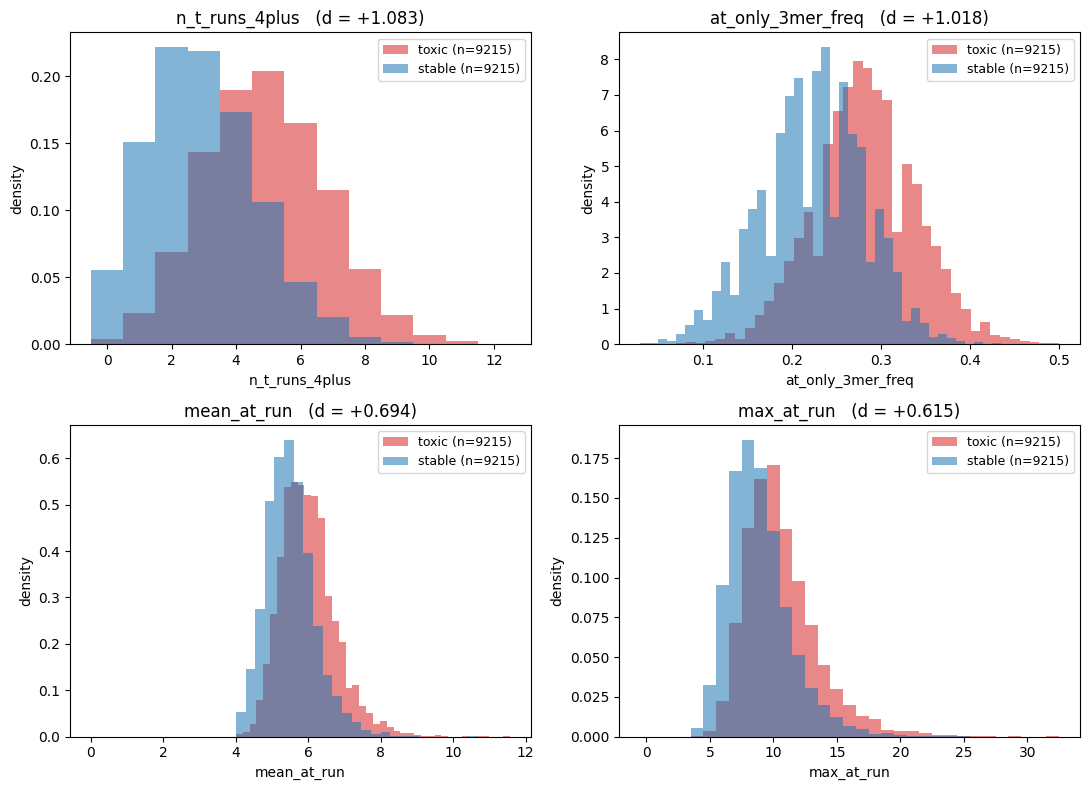


  Stats saved: /content/streme_work/cell27_at_tract_analysis/cell27a_distribution_stats.csv
  Figure saved: /content/streme_work/cell27_at_tract_analysis/cell27a_top4_histograms.png
  Globals: toxic_feats, stable_feats, stats_df


In [ ]:
# ====================================================================
# @title Cell 27a — Toxic vs Stable AT-tract distribution comparison
# ====================================================================
# What this cell tests:
#   Tom's concern (email 7-Jun): "What is missing is a comparison of
#   those values between toxic and stable sequences directly."
#   Cell 25 fit AT features pooled across cohorts. This cell asks:
#   do toxic and stable sequences differ at the per-feature level,
#   and by how much (effect size in LFC units)?
# Method:
#   Compute the same 17 AT-richness features from Cell 25 per sequence
#   on the toxic and stable cohorts. Mann-Whitney U + Cohen's d for
#   each feature. Histograms of the four strongest predictors.

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

TOXIC_FA  = f'{FASTA_DIR}/discovery_toxic_cohort.fa'
STABLE_FA = f'{FASTA_DIR}/discovery_stable_cohort.fa'
SEQ_LEN   = 172
OUT_DIR   = f'{WORK_DIR}/cell27_at_tract_analysis'
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- AT-feature computation (matches Cell 25 definitions) ----
def at_features(seq):
    L = len(seq); f = {}
    f['a_pct']  = seq.count('A') / L
    f['t_pct']  = seq.count('T') / L
    f['at_pct'] = (seq.count('A') + seq.count('T')) / L
    # AT-runs
    at_runs = [m.end()-m.start() for m in re.finditer(r'[AT]{4,}', seq)]
    f['n_at_runs_4plus'] = len(at_runs)
    f['n_at_runs_6plus'] = sum(1 for r in at_runs if r >= 6)
    f['n_at_runs_8plus'] = sum(1 for r in at_runs if r >= 8)
    f['max_at_run']      = max(at_runs) if at_runs else 0
    f['mean_at_run']     = np.mean(at_runs) if at_runs else 0
    # Homopolymer T
    t_runs = [m.end()-m.start() for m in re.finditer(r'T{4,}', seq)]
    f['n_t_runs_4plus']  = len(t_runs)
    f['n_t_runs_6plus']  = sum(1 for r in t_runs if r >= 6)
    f['max_t_run']       = max(t_runs) if t_runs else 0
    # Homopolymer A
    a_runs = [m.end()-m.start() for m in re.finditer(r'A{4,}', seq)]
    f['n_a_runs_4plus']  = len(a_runs)
    f['n_a_runs_6plus']  = sum(1 for r in a_runs if r >= 6)
    f['max_a_run']       = max(a_runs) if a_runs else 0
    # AT-only k-mer frequencies
    f['at_only_3mer_freq'] = sum(1 for i in range(L-2) if all(c in 'AT' for c in seq[i:i+3])) / (L-2)
    f['at_only_4mer_freq'] = sum(1 for i in range(L-3) if all(c in 'AT' for c in seq[i:i+4])) / (L-3)
    f['at_only_5mer_freq'] = sum(1 for i in range(L-4) if all(c in 'AT' for c in seq[i:i+5])) / (L-4)
    # Fraction of high-AT 20bp windows
    win = 20
    f['frac_high_at'] = sum(1 for i in range(L-win+1)
                            if (seq[i:i+win].count('A') + seq[i:i+win].count('T'))/win >= 0.8) / (L-win+1)
    return f

# ---------- LFC parsing from FASTA headers ----------
def parse_lfc(h):
    m = re.search(r'lfc=([+-]?\d+\.\d+)', h)   # [+-]? instead of -?
    return float(m.group(1)) if m else None

def load_cohort(fa):
    rows = []
    for sid, seq in parse_fasta(fa):
        lfc = parse_lfc(sid)
        if lfc is None: continue
        rows.append({'id': sid, 'seq': seq.upper(), 'lfc': lfc})
    return pd.DataFrame(rows)

print("Loading cohorts...")
toxic_df  = load_cohort(TOXIC_FA)
stable_df = load_cohort(STABLE_FA)
print(f"  Toxic  : n={len(toxic_df):>5}  LFC mean={toxic_df.lfc.mean():+.3f}  std={toxic_df.lfc.std():.3f}")
print(f"  Stable : n={len(stable_df):>5}  LFC mean={stable_df.lfc.mean():+.3f}  std={stable_df.lfc.std():.3f}")

print("\nComputing AT features (17 per sequence × ~18,400 sequences)...")
toxic_feats  = pd.DataFrame([at_features(s) for s in toxic_df.seq])
stable_feats = pd.DataFrame([at_features(s) for s in stable_df.seq])
toxic_feats['lfc']    = toxic_df.lfc.values
stable_feats['lfc']   = stable_df.lfc.values

# ---------- Distributional comparison ----------
print("\n" + "="*94)
print(" AT-FEATURE DISTRIBUTIONS — TOXIC vs STABLE")
print("="*94)
print(f" {'feature':<22} {'toxic μ':>10} {'stable μ':>10} {'Δ (T−S)':>10}  {'Mann-Whitney p':<16} {'Cohen d':>8}")
print(" " + "-"*92)

feature_order = ['n_t_runs_4plus','at_only_3mer_freq','at_only_4mer_freq','mean_at_run',
                 'at_only_5mer_freq','n_t_runs_6plus','max_t_run','t_pct',
                 'n_at_runs_6plus','n_at_runs_8plus','at_pct','max_at_run',
                 'n_at_runs_4plus','max_a_run','n_a_runs_4plus','a_pct','frac_high_at']
rows = []
for feat in feature_order:
    t = toxic_feats[feat].values
    s = stable_feats[feat].values
    _, p = mannwhitneyu(t, s, alternative='two-sided')
    d = (t.mean() - s.mean()) / np.sqrt((t.var() + s.var())/2) if np.sqrt((t.var()+s.var())/2) > 0 else 0
    rows.append({'feature': feat, 'toxic_mean': t.mean(), 'stable_mean': s.mean(),
                 'delta': t.mean()-s.mean(), 'U_p': p, 'cohens_d': d})
    print(f" {feat:<22} {t.mean():>10.4f} {s.mean():>10.4f} {t.mean()-s.mean():>+10.4f}  {p:<16.2e} {d:>+8.3f}")

stats_df = pd.DataFrame(rows)
stats_df.to_csv(f'{OUT_DIR}/cell27a_distribution_stats.csv', index=False)

# ---------- Histograms of top 4 predictors ----------
top4 = ['n_t_runs_4plus','at_only_3mer_freq','mean_at_run','max_at_run']
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.flat, top4):
    t = toxic_feats[feat].values
    s = stable_feats[feat].values
    if feat in ['n_t_runs_4plus','max_at_run']:
        bins = np.arange(0, max(t.max(), s.max()) + 2) - 0.5
    else:
        bins = 40
    ax.hist(t, bins=bins, alpha=0.55, label=f'toxic (n={len(t)})',  density=True, color='#d62728')
    ax.hist(s, bins=bins, alpha=0.55, label=f'stable (n={len(s)})', density=True, color='#1f77b4')
    ax.set_xlabel(feat); ax.set_ylabel('density'); ax.legend(fontsize=9)
    d = stats_df.loc[stats_df.feature==feat, 'cohens_d'].iloc[0]
    ax.set_title(f'{feat}   (d = {d:+.3f})')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cell27a_top4_histograms.png', dpi=130)
plt.show()

print(f"\n  Stats saved: {OUT_DIR}/cell27a_distribution_stats.csv")
print(f"  Figure saved: {OUT_DIR}/cell27a_top4_histograms.png")
print(f"  Globals: toxic_feats, stable_feats, stats_df")

Loading control cohort + computing features...
  Control: n=18430  LFC mean=-0.064  std=0.188
  Pooled : n=36860  LFC range [-4.181, +2.525]

 MEAN LFC BY AT-FEATURE QUANTILE (10 bins, pooled toxic+stable+control)

  n_t_runs_4plus:
   bin  mid     lo     hi       n   LFC_mean  ± SEM
     0   1.00   0.00   1.00   3686   +0.244  ± 0.008
     1   2.00   1.00   2.00   3686   +0.182  ± 0.009
     2   3.00   2.00   3.00   3686   -0.158  ± 0.008
     3   3.00   3.00   3.00   3686   +0.195  ± 0.006
     4   4.00   3.00   4.00   3686   -0.263  ± 0.008
     5   4.00   4.00   4.00   3686   +0.134  ± 0.006
     6   5.00   4.00   5.00   3686   -0.279  ± 0.007
     7   5.00   5.00   6.00   3686   -0.007  ± 0.005
     8   6.00   6.00   6.00   3686   -0.232  ± 0.007
     9   7.00   6.00  12.00   3686   -0.338  ± 0.006

  mean_at_run:
   bin  mid     lo     hi       n   LFC_mean  ± SEM
     0   4.69   0.00   4.89   3686   +0.153  ± 0.008
     1   5.00   4.89   5.12   3686   +0.074  ± 0.008
     2   5.

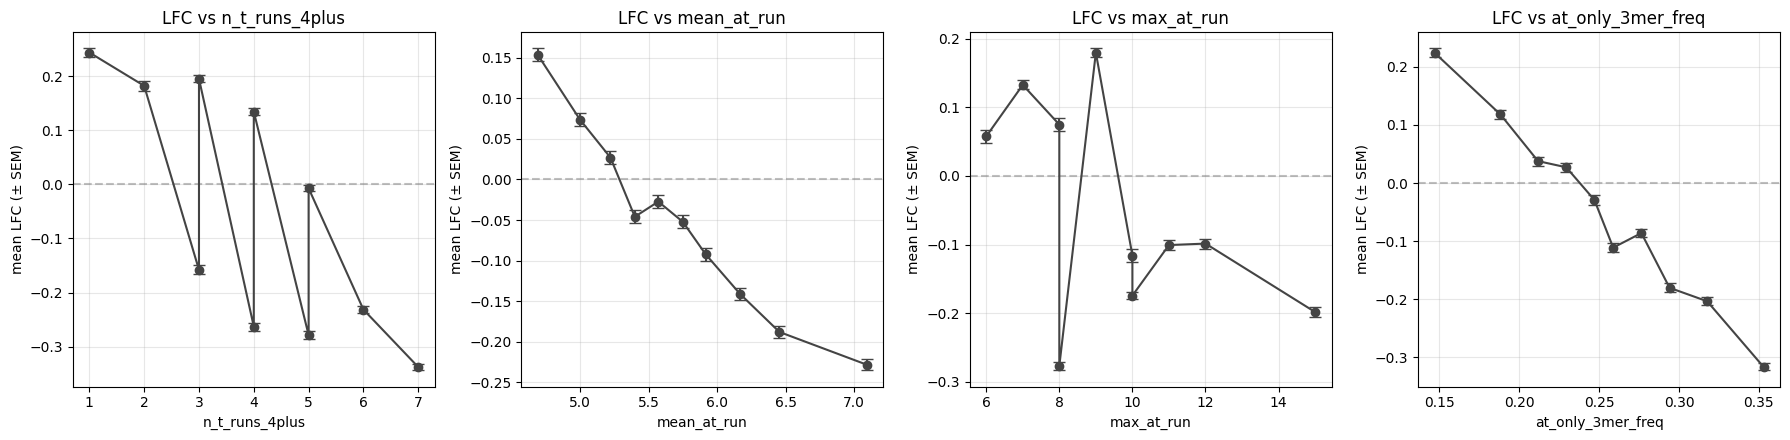


 INFLECTION POINTS — bin with steepest LFC drop
  n_t_runs_4plus          steepest drop at bin_mid=4.00  (ΔLFC = -0.458)
  mean_at_run             steepest drop at bin_mid=5.00  (ΔLFC = -0.080)
  max_at_run              steepest drop at bin_mid=9.00  (ΔLFC = +0.457)
  at_only_3mer_freq       steepest drop at bin_mid=0.35  (ΔLFC = -0.113)

  Variables in globals: threshold_results, pooled
  Figure: /content/streme_work/cell27_at_tract_analysis/cell27b_threshold_curves.png


In [ ]:
# ====================================================================
# @title Cell 27b — LFC threshold analysis on AT-tract features
# ====================================================================
# What this cell tests:
#   Tom: "Is there a length threshold above which toxicity increases
#   sharply?" If toxicity is a graded function of AT-tract structure,
#   we expect a smooth monotonic LFC-vs-feature curve. If there's a
#   biophysical threshold (e.g., H-NS oligomerization requires ≥X bp),
#   we expect a sharp inflection.
# Method:
#   Pool toxic + stable + control. Bin sequences by feature value
#   (10 quantile bins). Plot mean LFC per bin with SEM. Inflection
#   point analysis (segmented regression).

# Reload control cohort to widen LFC range — toxic+stable alone is
# bimodal by construction and obscures the threshold shape.
CONTROL_FA = f'{FASTA_DIR}/discovery_control_GC_matched.fa'
print("Loading control cohort + computing features...")
control_df = load_cohort(CONTROL_FA)
control_feats = pd.DataFrame([at_features(s) for s in control_df.seq])
control_feats['lfc'] = control_df.lfc.values
print(f"  Control: n={len(control_df)}  LFC mean={control_df.lfc.mean():+.3f}  std={control_df.lfc.std():.3f}")

pooled = pd.concat([toxic_feats, stable_feats, control_feats], ignore_index=True)
print(f"  Pooled : n={len(pooled)}  LFC range [{pooled.lfc.min():+.3f}, {pooled.lfc.max():+.3f}]")

# ---------- Binned LFC ----------
print("\n" + "="*78)
print(" MEAN LFC BY AT-FEATURE QUANTILE (10 bins, pooled toxic+stable+control)")
print("="*78)

threshold_features = ['n_t_runs_4plus','mean_at_run','max_at_run','at_only_3mer_freq']
threshold_results = {}
for feat in threshold_features:
    try:
        pooled[f'{feat}_bin'] = pd.qcut(pooled[feat].rank(method='first'), 10, labels=False)
        b = pooled.groupby(f'{feat}_bin').agg(
            bin_mid=(feat, 'median'),
            bin_lo=(feat, 'min'),
            bin_hi=(feat, 'max'),
            n=('lfc', 'count'),
            lfc_mean=('lfc', 'mean'),
            lfc_sem=('lfc', lambda x: x.std()/np.sqrt(len(x)))
        ).reset_index()
        threshold_results[feat] = b
        print(f"\n  {feat}:")
        print("   bin  mid     lo     hi       n   LFC_mean  ± SEM")
        for _, row in b.iterrows():
            print(f"   {int(row[f'{feat}_bin']):>3}  {row['bin_mid']:>5.2f}  {row['bin_lo']:>5.2f}  "
                  f"{row['bin_hi']:>5.2f}  {int(row['n']):>5}  {row['lfc_mean']:>+7.3f}  ± {row['lfc_sem']:.3f}")
    except Exception as e:
        print(f"  {feat}: skipped ({e})")

# ---------- Plot threshold curves ----------
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, feat in zip(axes, threshold_features):
    if feat not in threshold_results: continue
    b = threshold_results[feat]
    ax.errorbar(b['bin_mid'], b['lfc_mean'], yerr=b['lfc_sem'],
                marker='o', capsize=4, linewidth=1.5, color='#444')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel(feat); ax.set_ylabel('mean LFC (± SEM)')
    ax.set_title(f'LFC vs {feat}')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cell27b_threshold_curves.png', dpi=130)
plt.show()

# ---------- Inflection analysis (largest gradient bin) ----------
print("\n" + "="*78)
print(" INFLECTION POINTS — bin with steepest LFC drop")
print("="*78)
for feat in threshold_features:
    if feat not in threshold_results: continue
    b = threshold_results[feat].sort_values('bin_mid').reset_index(drop=True)
    diffs = b['lfc_mean'].diff().abs().fillna(0)
    if len(diffs) > 1:
        idx = diffs.idxmax()
        print(f"  {feat:<22}  steepest drop at bin_mid={b.loc[idx,'bin_mid']:.2f}  "
              f"(ΔLFC = {b.loc[idx,'lfc_mean']-b.loc[idx-1,'lfc_mean']:+.3f})")

print(f"\n  Variables in globals: threshold_results, pooled")
print(f"  Figure: {OUT_DIR}/cell27b_threshold_curves.png")

Computing positional density (AT-tracts ≥ 4 bp, T-only ≥ 4 bp)...
Generating k=3 shuffled toxic for null reference (~30 sec)...

 KS TESTS on AT-tract start positions
  Toxic vs stable:        D = 0.0266   p = 3.80e-28   (n_toxic=98332, n_stable=83801)
  Toxic vs k=3 shuffled:  D = 0.0413   p = 7.12e-74   (n_shuf=99526)
  Interpretation:
    Toxic vs stable significant + Toxic vs shuf NOT significant → composition-driven
    Both significant + different shape → positional preference beyond composition


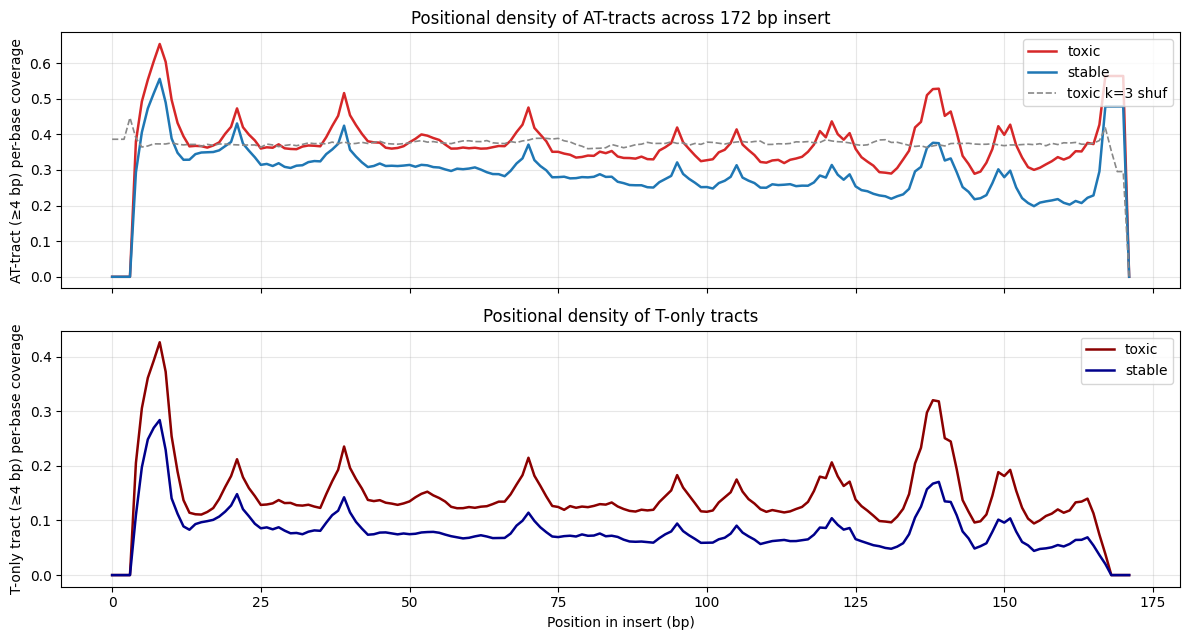


  Globals: toxic_at_cov, stable_at_cov, toxic_shuf_at_cov, toxic_at_starts, stable_at_starts
  Figure : /content/streme_work/cell27_at_tract_analysis/cell27c_positional_density.png
  Arrays : /content/streme_work/cell27_at_tract_analysis/cell27c_positional_density.npz


In [ ]:
# ====================================================================
# @title Cell 27c — Positional clustering of AT-tracts across 172 bp window
# ====================================================================
# What this cell tests:
#   Tom: "Are the tracts clustered in particular positions within the
#   192 bp window or randomly distributed?" If toxic plasmids have
#   AT-tracts concentrated in promoter-proximal regions (e.g., 5'
#   end), this would suggest a transcription-initiation mechanism.
#   Uniform positional density would suggest bulk composition effects.
#   GGS3 inserts are 172 bp — using that throughout.
# Method:
#   Per-base AT-tract (≥4 bp run of A or T) coverage density across
#   positions 0–171 in each cohort. KS test on tract start positions.
#   Compare to a k=3-shuffled toxic null to control for composition.

from scipy.stats import ks_2samp

def at_tract_intervals(seq, min_len=4):
    return [(m.start(), m.end()) for m in re.finditer(r'[AT]{' + str(min_len) + ',}', seq)]

def t_tract_intervals(seq, min_len=4):
    return [(m.start(), m.end()) for m in re.finditer(r'T{' + str(min_len) + ',}', seq)]

def coverage_density(seqs, interval_fn, seq_len=SEQ_LEN):
    cov = np.zeros(seq_len)
    for seq in seqs:
        for a, b in interval_fn(seq):
            cov[a:min(b, seq_len)] += 1
    return cov / len(seqs)

def tract_starts(seqs, interval_fn):
    return np.array([a for seq in seqs for a, _ in interval_fn(seq)])

print("Computing positional density (AT-tracts ≥ 4 bp, T-only ≥ 4 bp)...")
toxic_at_cov  = coverage_density(toxic_df.seq,  at_tract_intervals)
stable_at_cov = coverage_density(stable_df.seq, at_tract_intervals)
toxic_t_cov   = coverage_density(toxic_df.seq,  t_tract_intervals)
stable_t_cov  = coverage_density(stable_df.seq, t_tract_intervals)

# k=3-shuffled toxic null for AT-tracts (composition-matched reference)
print("Generating k=3 shuffled toxic for null reference (~30 sec)...")
import subprocess
toxic_shuf_path = f'{OUT_DIR}/toxic_shuf3_for_pos.fa'
subprocess.run(['fasta-shuffle-letters', '-kmer', '3', '-dna',
                TOXIC_FA, toxic_shuf_path], check=True, capture_output=True)
toxic_shuf_seqs = [seq for _, seq in parse_fasta(toxic_shuf_path)]
toxic_shuf_at_cov = coverage_density(toxic_shuf_seqs, at_tract_intervals)

# ---------- KS tests on start positions ----------
toxic_at_starts  = tract_starts(toxic_df.seq,  at_tract_intervals)
stable_at_starts = tract_starts(stable_df.seq, at_tract_intervals)
toxic_shuf_starts = tract_starts(toxic_shuf_seqs, at_tract_intervals)

ks_ts, ks_tp = ks_2samp(toxic_at_starts, stable_at_starts)
ks_tns, ks_tnp = ks_2samp(toxic_at_starts, toxic_shuf_starts)

print("\n" + "="*78)
print(" KS TESTS on AT-tract start positions")
print("="*78)
print(f"  Toxic vs stable:        D = {ks_ts:.4f}   p = {ks_tp:.2e}   "
      f"(n_toxic={len(toxic_at_starts)}, n_stable={len(stable_at_starts)})")
print(f"  Toxic vs k=3 shuffled:  D = {ks_tns:.4f}   p = {ks_tnp:.2e}   "
      f"(n_shuf={len(toxic_shuf_starts)})")
print(f"  Interpretation:")
print(f"    Toxic vs stable significant + Toxic vs shuf NOT significant → composition-driven")
print(f"    Both significant + different shape → positional preference beyond composition")

# ---------- Plot ----------
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

axes[0].plot(toxic_at_cov,     label='toxic',         color='#d62728', linewidth=1.8)
axes[0].plot(stable_at_cov,    label='stable',        color='#1f77b4', linewidth=1.8)
axes[0].plot(toxic_shuf_at_cov, label='toxic k=3 shuf', color='#888', linewidth=1.2, linestyle='--')
axes[0].set_ylabel('AT-tract (≥4 bp) per-base coverage')
axes[0].set_title('Positional density of AT-tracts across 172 bp insert')
axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.3)

axes[1].plot(toxic_t_cov,  label='toxic',  color='#8b0000', linewidth=1.8)
axes[1].plot(stable_t_cov, label='stable', color='#00008b', linewidth=1.8)
axes[1].set_xlabel('Position in insert (bp)')
axes[1].set_ylabel('T-only tract (≥4 bp) per-base coverage')
axes[1].set_title('Positional density of T-only tracts')
axes[1].legend(loc='upper right'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cell27c_positional_density.png', dpi=130)
plt.show()

# ---------- Save coverage arrays ----------
np.savez(f'{OUT_DIR}/cell27c_positional_density.npz',
         toxic_at_cov=toxic_at_cov, stable_at_cov=stable_at_cov,
         toxic_shuf_at_cov=toxic_shuf_at_cov,
         toxic_t_cov=toxic_t_cov, stable_t_cov=stable_t_cov)

print(f"\n  Globals: toxic_at_cov, stable_at_cov, toxic_shuf_at_cov, toxic_at_starts, stable_at_starts")
print(f"  Figure : {OUT_DIR}/cell27c_positional_density.png")
print(f"  Arrays : {OUT_DIR}/cell27c_positional_density.npz")

H-NS-related motifs in PRODORIC: [('MX000335', 'H-NS')]
Wrote Bouffartigues 2007 PWM: /content/streme_work/cell28_hns_analysis/hns_bouffartigues2007.meme

Running FIMO scans (Bouffartigues + any PRODORIC H-NS)...
  Toxic  hits: 23199
  Stable hits: 11387

 H-NS PWM HIT COUNTS PER SEQUENCE — TOXIC vs STABLE

  HNS_BF07:
    Toxic  mean hits/seq = 0.1386   pct≥1 = 12.82%
    Stable mean hits/seq = 0.1316   pct≥1 = 12.48%
    Enrichment ratio     = 1.053×
    Mann-Whitney p       = 4.43e-01

  MX000335:
    Toxic  mean hits/seq = 2.3789   pct≥1 = 81.74%
    Stable mean hits/seq = 1.1041   pct≥1 = 57.69%
    Enrichment ratio     = 2.155×
    Mann-Whitney p       = 0.00e+00


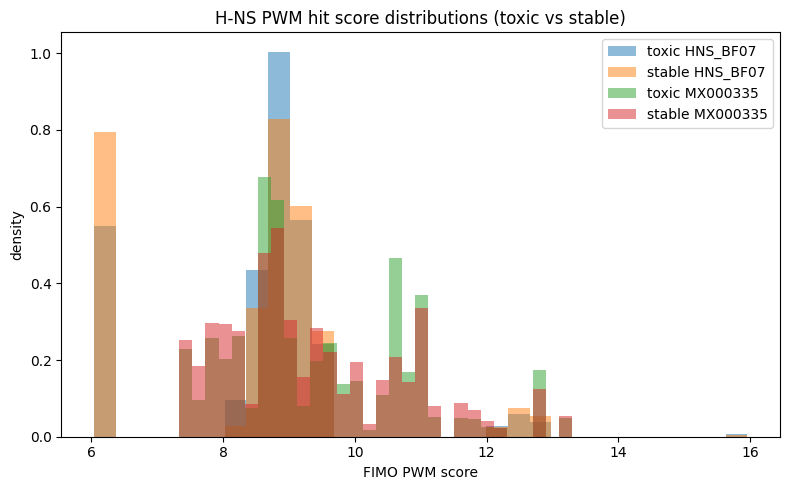


  Outputs in: /content/streme_work/cell28_hns_analysis
  Globals: fimo_toxic, fimo_stable


In [ ]:
# ====================================================================
# @title Cell 28a — H-NS PWM-based binding propensity, toxic vs stable
# ====================================================================
# What this cell tests:
#   Tom (email 7-Jun): "Without H-NS binding site predictions on your
#   toxic versus stable sequences using published H-NS affinity
#   models... you cannot present [H-NS titration] as more than [a
#   hypothesis] in your Discussion."
#   This cell uses two PWMs: any H-NS-related entry in PRODORIC, plus
#   a custom motif from the Bouffartigues 2007 SELEX consensus
#   (TCGATAAATT, doi:10.1038/nsmb1233).
# Method:
#   1. Search PRODORIC for H-NS / Hns / StpA entries.
#   2. Construct a custom MEME PWM from Bouffartigues 2007 consensus.
#   3. FIMO scan both motifs on toxic + stable cohorts.
#   4. Compare per-sequence hit counts (Mann-Whitney) and PWM score
#      distributions of hits.

import os, re, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

HNS_DIR = f'{WORK_DIR}/cell28_hns_analysis'
os.makedirs(HNS_DIR, exist_ok=True)

# ---------- 1. Search PRODORIC for H-NS entries ----------
PRODORIC_MEME = '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme'
hns_in_prodoric = []
with open(PRODORIC_MEME) as f:
    for line in f:
        if line.startswith('MOTIF'):
            parts = line.strip().split()
            mid  = parts[1]
            name = parts[2] if len(parts) > 2 else ''
            if re.search(r'(?:h-?ns|stpa|hha)', name, re.IGNORECASE):
                hns_in_prodoric.append((mid, name))

print(f"H-NS-related motifs in PRODORIC: {hns_in_prodoric or '(none found)'}")

# ---------- 2. Construct Bouffartigues 2007 PWM ----------
# TCGATAAATT — high-affinity SELEX consensus (Bouffartigues et al. 2007, NSMB)
# Build with 0.80 on consensus base, 0.0667 elsewhere (slightly informative).
BOUFFARTIGUES_CONS = 'TCGATAAATT'
BOUFFARTIGUES_MEME = f'{HNS_DIR}/hns_bouffartigues2007.meme'

def make_meme_from_consensus(cons, motif_id, name, out_path, p_cons=0.80, p_other=None):
    if p_other is None:
        p_other = (1.0 - p_cons) / 3
    with open(out_path, 'w') as f:
        f.write('MEME version 5\n\n')
        f.write('ALPHABET= ACGT\n\n')
        f.write('strands: + -\n\n')
        f.write('Background letter frequencies\n')
        f.write('A 0.25 C 0.25 G 0.25 T 0.25\n\n')
        f.write(f'MOTIF {motif_id} {name}\n')
        f.write(f'letter-probability matrix: alength= 4 w= {len(cons)} nsites= 20 E= 0\n')
        for c in cons.upper():
            probs = {b: p_other for b in 'ACGT'}
            probs[c] = p_cons
            f.write(f' {probs["A"]:.4f} {probs["C"]:.4f} {probs["G"]:.4f} {probs["T"]:.4f}\n')
        f.write('\n')

make_meme_from_consensus(BOUFFARTIGUES_CONS, 'HNS_BF07',
                         'H-NS_Bouffartigues2007_SELEX', BOUFFARTIGUES_MEME)
print(f"Wrote Bouffartigues 2007 PWM: {BOUFFARTIGUES_MEME}")

# Build combined MEME with PRODORIC H-NS hits (if any) + Bouffartigues
COMBINED_MEME = f'{HNS_DIR}/hns_combined.meme'
with open(COMBINED_MEME, 'w') as out:
    with open(BOUFFARTIGUES_MEME) as f:
        out.write(f.read())
    if hns_in_prodoric:
        # Extract H-NS blocks from PRODORIC
        with open(PRODORIC_MEME) as f:
            content = f.read()
        for mid, name in hns_in_prodoric:
            m = re.search(rf'MOTIF {mid}.*?(?=\n\nMOTIF |\Z)', content, re.DOTALL)
            if m:
                out.write('\n' + m.group(0) + '\n')

# ---------- 3. FIMO scan both cohorts ----------
def run_fimo(meme_path, fasta_path, oc_dir, thresh=1e-3):
    os.makedirs(oc_dir, exist_ok=True)
    cmd = ['fimo', '--thresh', str(thresh), '--oc', oc_dir,
           '--norc', meme_path, fasta_path]
    subprocess.run(cmd, check=True, capture_output=True)
    tsv = f'{oc_dir}/fimo.tsv'
    if os.path.exists(tsv):
        try:
            return pd.read_csv(tsv, sep='\t', comment='#').dropna()
        except Exception:
            return pd.DataFrame()
    return pd.DataFrame()

print("\nRunning FIMO scans (Bouffartigues + any PRODORIC H-NS)...")
fimo_toxic  = run_fimo(COMBINED_MEME, TOXIC_FA,  f'{HNS_DIR}/fimo_toxic')
fimo_stable = run_fimo(COMBINED_MEME, STABLE_FA, f'{HNS_DIR}/fimo_stable')

print(f"  Toxic  hits: {len(fimo_toxic)}")
print(f"  Stable hits: {len(fimo_stable)}")

# ---------- 4. Compare per-sequence hit counts and score distributions ----------
def per_seq_counts(fimo_df, all_ids):
    if 'sequence_name' not in fimo_df.columns:
        return pd.Series(0, index=all_ids)
    counts = fimo_df.groupby('sequence_name').size()
    return counts.reindex(all_ids, fill_value=0)

toxic_ids  = [sid for sid, _ in parse_fasta(TOXIC_FA)]
stable_ids = [sid for sid, _ in parse_fasta(STABLE_FA)]

print("\n" + "="*82)
print(" H-NS PWM HIT COUNTS PER SEQUENCE — TOXIC vs STABLE")
print("="*82)

# By motif
all_motifs = sorted(set(fimo_toxic.get('motif_id', pd.Series([])).unique()) |
                    set(fimo_stable.get('motif_id', pd.Series([])).unique()))
for motif in all_motifs:
    t_sub = fimo_toxic [fimo_toxic ['motif_id'] == motif] if len(fimo_toxic)  else pd.DataFrame()
    s_sub = fimo_stable[fimo_stable['motif_id'] == motif] if len(fimo_stable) else pd.DataFrame()
    tc = per_seq_counts(t_sub, toxic_ids)
    sc = per_seq_counts(s_sub, stable_ids)
    _, p = mannwhitneyu(tc, sc, alternative='two-sided')
    print(f"\n  {motif}:")
    print(f"    Toxic  mean hits/seq = {tc.mean():.4f}   pct≥1 = {(tc>0).mean()*100:.2f}%")
    print(f"    Stable mean hits/seq = {sc.mean():.4f}   pct≥1 = {(sc>0).mean()*100:.2f}%")
    print(f"    Enrichment ratio     = {tc.mean()/max(sc.mean(),1e-9):.3f}×")
    print(f"    Mann-Whitney p       = {p:.2e}")

# ---------- 5. Distribution plot ----------
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for motif in all_motifs[:2]:
    t_sub = fimo_toxic [fimo_toxic ['motif_id'] == motif] if len(fimo_toxic)  else pd.DataFrame()
    s_sub = fimo_stable[fimo_stable['motif_id'] == motif] if len(fimo_stable) else pd.DataFrame()
    if 'score' in t_sub.columns and len(t_sub) and len(s_sub):
        ax.hist(t_sub['score'], bins=30, alpha=0.5, label=f'toxic {motif}',  density=True)
        ax.hist(s_sub['score'], bins=30, alpha=0.5, label=f'stable {motif}', density=True)
ax.set_xlabel('FIMO PWM score'); ax.set_ylabel('density')
ax.set_title('H-NS PWM hit score distributions (toxic vs stable)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{HNS_DIR}/cell28a_pwm_score_dist.png', dpi=130)
plt.show()

print(f"\n  Outputs in: {HNS_DIR}")
print(f"  Globals: fimo_toxic, fimo_stable")

Computing H-NS heuristic scores for toxic + stable...

 H-NS HEURISTIC SCORES — TOXIC vs STABLE
 metric                      toxic μ   stable μ  enrichment   Mann-Whitney p    Cohen d
 --------------------------------------------------------------------------------------
 n_at_rich_windows           68.1470    49.1714       1.386×         0.00e+00     +0.657
 homopolymer_score          138.2988    71.5523       1.933×         0.00e+00     +1.244
 tpa_count                   13.1230    13.1949       0.995×         5.18e-02     -0.022
 hns_composite                0.7659     0.3776       2.028×         0.00e+00     +1.243

  Spearman ρ(H-NS composite, LFC) on toxic+stable pool: -0.4701  (p = 0.00e+00)


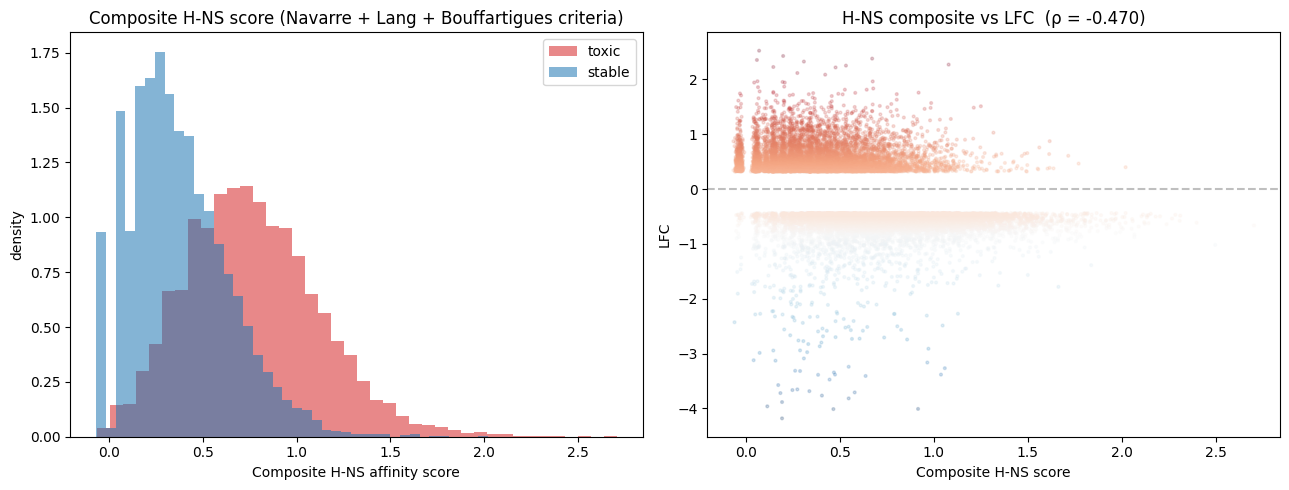


 INTERPRETATION
 If composite H-NS score is significantly higher in toxic than stable,
 and is negatively correlated with LFC, this supports the H-NS titration
 hypothesis: toxic plasmids carry more H-NS binding capacity than stable
 plasmids, plausibly titrating the cellular H-NS pool away from
 chromosomal AT-rich genes.

 CAVEATS to flag in Discussion:
   1. This is sequence-prediction, not direct H-NS binding measurement.
   2. H-NS titration requires high plasmid copy number — ColE1 (hundreds
      of copies per cell) is consistent with this; lower-copy systems
      may not show the effect.
   3. Quantitative validation would require ChIP-seq on toxic vs stable
      plasmid hosts — out of scope but cited as future work.

  Outputs in: /content/streme_work/cell28_hns_analysis
  Globals: toxic_hns, stable_hns, pooled_ts


In [ ]:
# ====================================================================
# @title Cell 28b — Heuristic H-NS affinity score, toxic vs stable
# ====================================================================
# What this cell tests:
#   Same hypothesis as 28a (toxic carries more H-NS binding propensity
#   than stable), but using sequence rules rather than a PWM.
#   H-NS doesn't have a tight consensus — it binds extended AT-rich
#   regions cooperatively. Three published sequence rules:
#     (a) High AT% over extended (≥30 bp) windows (Navarre 2006).
#     (b) Long homopolymer T-runs and A-runs are preferred binding
#         sites; cooperativity scales superlinearly with run length
#         (Lang et al. 2007).
#     (c) TpA dinucleotide steps disrupt H-NS oligomerization
#         (Bouffartigues 2007, Cordeiro 2011 — "TpA stop signs").
# Method:
#   Per-sequence score combining all three. Then compare distributions
#   between toxic and stable cohorts.

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr

def hns_affinity_score(seq, window=30, at_thresh=0.65, tpa_penalty=0.5):
    """
    Composite H-NS-likeness score combining Navarre 2006 + Lang 2007 +
    Bouffartigues 2007 criteria.
      - n_at_rich_windows: number of 30-bp windows with AT% >= 0.65
      - homopolymer_score: sum of run_length^2 for T-runs and A-runs ≥ 4 bp
                           (squared captures cooperativity)
      - tpa_count        : number of T-A dinucleotide steps (penalty)
      - score            : homopolymer_score - tpa_penalty * tpa_count,
                           normalized by sequence length
    """
    L = len(seq)
    # (a) AT-rich windows
    n_at_rich = sum(1 for i in range(L - window + 1)
                    if (seq[i:i+window].count('A') + seq[i:i+window].count('T')) / window >= at_thresh)
    # (b) Homopolymer cooperativity
    t_runs = [m.end()-m.start() for m in re.finditer(r'T{4,}', seq)]
    a_runs = [m.end()-m.start() for m in re.finditer(r'A{4,}', seq)]
    homo_score = sum(r**2 for r in t_runs) + sum(r**2 for r in a_runs)
    # (c) TpA "stop sign" penalty
    tpa_count = sum(1 for i in range(L-1) if seq[i]=='T' and seq[i+1]=='A')
    # composite (normalized by length for fairness across sequence lengths)
    composite = (homo_score - tpa_penalty * tpa_count) / L
    return {
        'n_at_rich_windows': n_at_rich,
        'homopolymer_score': homo_score,
        'tpa_count':         tpa_count,
        'hns_composite':     composite
    }

print("Computing H-NS heuristic scores for toxic + stable...")
toxic_hns  = pd.DataFrame([hns_affinity_score(s) for s in toxic_df.seq])
stable_hns = pd.DataFrame([hns_affinity_score(s) for s in stable_df.seq])
toxic_hns ['lfc'] = toxic_df.lfc.values
stable_hns['lfc'] = stable_df.lfc.values

print("\n" + "="*88)
print(" H-NS HEURISTIC SCORES — TOXIC vs STABLE")
print("="*88)
print(f" {'metric':<24} {'toxic μ':>10} {'stable μ':>10} {'enrichment':>11} {'Mann-Whitney p':>16} {'Cohen d':>10}")
print(" " + "-"*86)
for col in ['n_at_rich_windows','homopolymer_score','tpa_count','hns_composite']:
    t = toxic_hns[col].values
    s = stable_hns[col].values
    _, p = mannwhitneyu(t, s, alternative='two-sided')
    pooled_sd = np.sqrt((t.var()+s.var())/2)
    d = (t.mean()-s.mean()) / pooled_sd if pooled_sd > 0 else 0
    ratio = t.mean() / max(abs(s.mean()), 1e-9)
    print(f" {col:<24} {t.mean():>10.4f} {s.mean():>10.4f} {ratio:>11.3f}× {p:>16.2e} {d:>+10.3f}")

# ---------- Correlation of composite H-NS score with LFC (pooled cohort) ----------
all_hns = pd.concat([toxic_hns, stable_hns, control_feats.assign(
    n_at_rich_windows=np.nan, homopolymer_score=np.nan,
    tpa_count=np.nan, hns_composite=np.nan
)[['lfc']]] if 'control_feats' in dir() else [toxic_hns, stable_hns], ignore_index=True)
# Direct toxic+stable correlation:
pooled_ts = pd.concat([toxic_hns, stable_hns], ignore_index=True)
rho_hns, p_hns = spearmanr(pooled_ts['hns_composite'], pooled_ts['lfc'])
print(f"\n  Spearman ρ(H-NS composite, LFC) on toxic+stable pool: {rho_hns:+.4f}  (p = {p_hns:.2e})")

# ---------- Plot composite score distribution ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(toxic_hns['hns_composite'],  bins=40, alpha=0.55, label='toxic',  density=True, color='#d62728')
axes[0].hist(stable_hns['hns_composite'], bins=40, alpha=0.55, label='stable', density=True, color='#1f77b4')
axes[0].set_xlabel('Composite H-NS affinity score'); axes[0].set_ylabel('density')
axes[0].set_title('Composite H-NS score (Navarre + Lang + Bouffartigues criteria)')
axes[0].legend()

axes[1].scatter(pooled_ts['hns_composite'], pooled_ts['lfc'], s=4, alpha=0.2,
                c=pooled_ts['lfc'], cmap='RdBu_r')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Composite H-NS score'); axes[1].set_ylabel('LFC')
axes[1].set_title(f'H-NS composite vs LFC  (ρ = {rho_hns:+.3f})')
plt.tight_layout()
plt.savefig(f'{HNS_DIR}/cell28b_hns_composite.png', dpi=130)
plt.show()

# Save
toxic_hns.to_csv(f'{HNS_DIR}/cell28b_toxic_hns_scores.csv', index=False)
stable_hns.to_csv(f'{HNS_DIR}/cell28b_stable_hns_scores.csv', index=False)

print(f"\n" + "="*82)
print(" INTERPRETATION")
print("="*82)
print(" If composite H-NS score is significantly higher in toxic than stable,")
print(" and is negatively correlated with LFC, this supports the H-NS titration")
print(" hypothesis: toxic plasmids carry more H-NS binding capacity than stable")
print(" plasmids, plausibly titrating the cellular H-NS pool away from")
print(" chromosomal AT-rich genes.")
print()
print(" CAVEATS to flag in Discussion:")
print("   1. This is sequence-prediction, not direct H-NS binding measurement.")
print("   2. H-NS titration requires high plasmid copy number — ColE1 (hundreds")
print("      of copies per cell) is consistent with this; lower-copy systems")
print("      may not show the effect.")
print("   3. Quantitative validation would require ChIP-seq on toxic vs stable")
print("      plasmid hosts — out of scope but cited as future work.")

print(f"\n  Outputs in: {HNS_DIR}")
print(f"  Globals: toxic_hns, stable_hns, pooled_ts")

Computing positional H-NS favorability across 172 bp window (~30 sec)...

 KS TESTS — long AT-tract (≥10 bp) start positions
  Total long-AT-tract starts: toxic=8108, stable=3802, shuf=8042
  toxic vs stable             D = 0.0726  p = 2.62e-12
  toxic vs k=3 shuffled       D = 0.0405  p = 3.31e-06

 MEAN PER-BASE COVERAGE ACROSS 172 BP INSERT — TOXIC vs STABLE
  criterion                           toxic μ   stable μ     shuf μ   T/S ratio
  ------------------------------------------------------------------------------
  (A) AT-tracts ≥10 bp                 0.0605     0.0275     0.0606       2.20×
  (B) Homopolymer T/A ≥6 bp            0.0538     0.0199     0.0521       2.71×
  (C) Composite H-NS window            7.1729     3.8353     7.2825       1.87×

 TOP-5 POSITIONS where TOXIC excess over STABLE is largest (per criterion)

  long AT-tracts ≥10 bp:
    position 137  Δcov = +0.0557   (toxic 0.094 vs stable 0.038)
    position 138  Δcov = +0.0558   (toxic 0.094 vs stable 0.039)
   

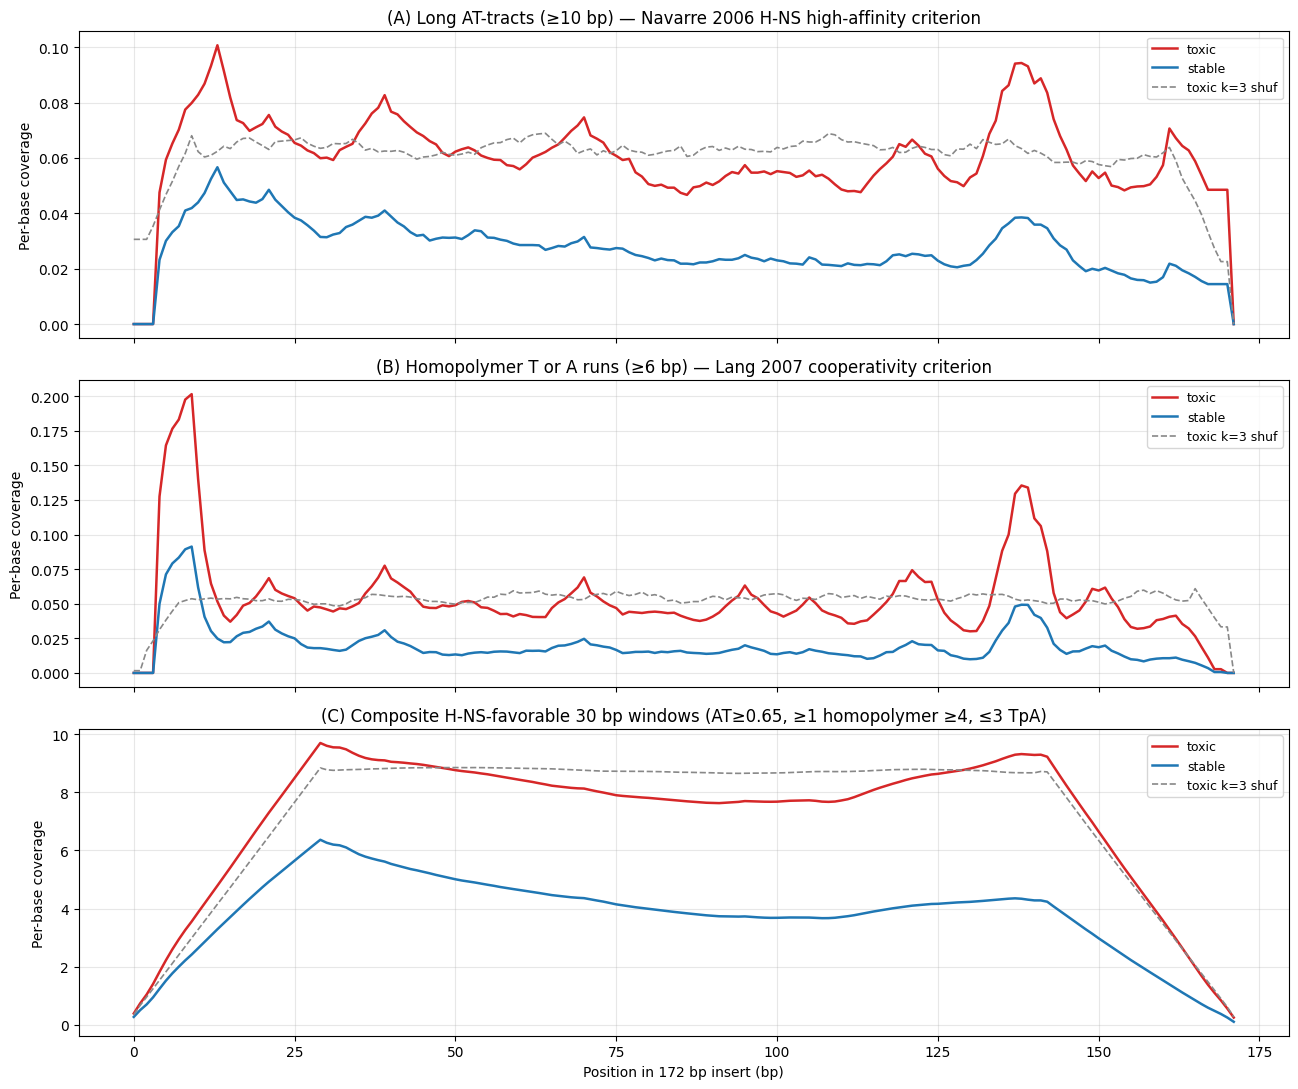

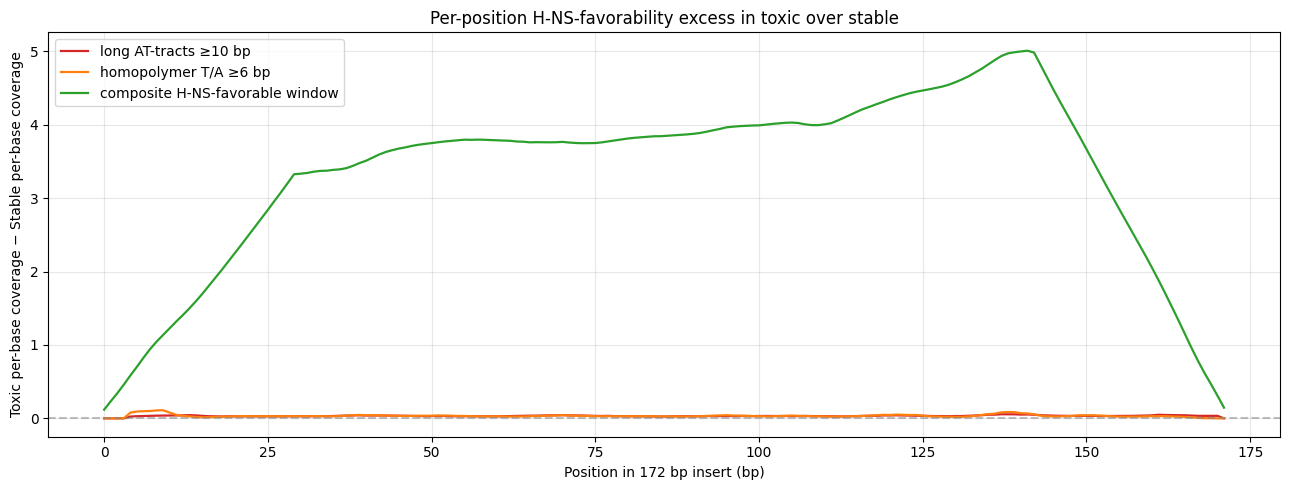


 READING GUIDE — three patterns for the Discussion
 Look at the figure and match to one of:

 1. UNIFORM ELEVATION — toxic > stable at all positions, roughly flat excess.
    Supports BULK COMPOSITION / TITRATION mechanism: H-NS binding capacity
    is uniformly elevated; high-copy ColE1 redistribution of cellular H-NS
    causes burden via chromosomal deprotection.

 2. POSITIONAL HOTSPOTS — toxic excess concentrates at specific positions.
    Supports a position-dependent mechanism. 5'-end localisation would
    suggest spurious transcription-initiation (Lamberte 2017, Warman 2020);
    internal hotspots would suggest local topology disruption.

 3. COMPOSITION-DRIVEN — toxic ≈ k=3 shuffled toxic, both > stable.
    The toxic pattern is a consequence of trinucleotide composition, not
    an evolved positional signal. H-NS effect is real but not site-specific.

  Outputs:
    /content/streme_work/cell28_hns_analysis/cell28c_positional_hns_map.png   (3-panel anchor figure)
    /conten

In [ ]:
# ====================================================================
# @title Cell 28c — Positional H-NS favorability map, toxic vs stable
# ====================================================================
# What this cell tests:
#   Three positional H-NS criteria applied to toxic vs stable inserts.
#   Tom (email 7-Jun): "Are the tracts clustered in particular positions
#   within the window or randomly distributed?" — extended here to H-NS-
#   favorable contexts specifically. The Discussion question: bulk
#   composition (uniform excess), positional hotspots (transcription-
#   initiation mechanism), or composition-driven artifact (toxic ≈
#   k=3 shuffle)?
# Method:
#   Three orthogonal positional criteria from the H-NS literature:
#     (A) Navarre 2006: long AT-tracts ≥10 bp
#     (B) Lang 2007 : homopolymer T or A runs ≥6 bp (cooperativity)
#     (C) Composite: 30 bp sliding window passing all H-NS rules
#         (AT% ≥ 0.65, ≥1 homopolymer ≥4 bp, TpA steps ≤3)
#   Per-position cohort-mean coverage. KS tests on tract start
#   positions (toxic vs stable, toxic vs k=3-shuffled toxic).

import os, re, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Inherit paths and frames from prior cells
assert 'toxic_df' in dir() and 'stable_df' in dir(), "Run Cell 27a first."
assert 'HNS_DIR' in dir(), "Run Cell 28a first (defines HNS_DIR)."

SEQ_LEN           = 172
WIN               = 30
AT_THRESH_WIN     = 0.65
LONG_AT_TRACT_MIN = 10      # Navarre 2006 H-NS-favoring tract length
HOMO_MIN          = 6       # Lang 2007 cooperativity
MAX_TPA_IN_WIN    = 3       # Bouffartigues 2007 TpA "stop sign" tolerance

# k=3 toxic shuffle (compositional null reference). Reuse if Cell 27c
# already generated it; otherwise create here.
toxic_shuf_path = f'{OUT_DIR}/toxic_shuf3_for_pos.fa'
if not os.path.exists(toxic_shuf_path):
    print("Generating k=3-shuffled toxic null reference (~30 sec)...")
    subprocess.run(['fasta-shuffle-letters', '-kmer', '3', '-dna',
                    TOXIC_FA, toxic_shuf_path], check=True, capture_output=True)
toxic_shuf_seqs = [seq for _, seq in parse_fasta(toxic_shuf_path)]

# ---------- Helpers ----------
def coverage_from_intervals(seqs, interval_fn, seq_len=SEQ_LEN):
    cov = np.zeros(seq_len)
    for seq in seqs:
        for a, b in interval_fn(seq):
            cov[a:min(b, seq_len)] += 1
    return cov / len(seqs)

def starts_from_intervals(seqs, interval_fn):
    return np.array([a for seq in seqs for a, _ in interval_fn(seq)])

# ---------- Three positional criteria ----------
def long_at_intervals(seq, min_len=LONG_AT_TRACT_MIN):
    """(A) Navarre 2006: AT-only tracts ≥10 bp = H-NS-favoring high-affinity sites."""
    return [(m.start(), m.end()) for m in re.finditer(r'[AT]{' + str(min_len) + ',}', seq)]

def homo_intervals(seq, min_len=HOMO_MIN):
    """(B) Lang 2007: homopolymer T or A runs ≥6 bp = H-NS cooperative binding sites."""
    return [(m.start(), m.end())
            for m in re.finditer(r'(T{' + str(min_len) + ',}|A{' + str(min_len) + ',})', seq)]

def composite_hns_intervals(seq, win=WIN, at_thresh=AT_THRESH_WIN, max_tpa=MAX_TPA_IN_WIN):
    """(C) Composite H-NS-favorable 30-bp windows combining all three rules."""
    intervals = []
    L = len(seq)
    for i in range(L - win + 1):
        sub = seq[i:i+win]
        if (sub.count('A') + sub.count('T')) / win < at_thresh:
            continue
        if not re.search(r'(T{4,}|A{4,})', sub):
            continue
        tpa = sum(1 for j in range(win-1) if sub[j]=='T' and sub[j+1]=='A')
        if tpa > max_tpa:
            continue
        intervals.append((i, i+win))
    return intervals

# ---------- Compute per-position coverage for all three criteria × three cohorts ----------
print(f"Computing positional H-NS favorability across 172 bp window (~30 sec)...")
cov = {}
for label, fn in [('longAT', long_at_intervals),
                  ('homo',   homo_intervals),
                  ('comp',   composite_hns_intervals)]:
    cov[f'toxic_{label}']  = coverage_from_intervals(toxic_df.seq,    fn)
    cov[f'stable_{label}'] = coverage_from_intervals(stable_df.seq,   fn)
    cov[f'shuf_{label}']   = coverage_from_intervals(toxic_shuf_seqs, fn)

# ---------- KS tests on long-AT-tract start positions ----------
starts_t  = starts_from_intervals(toxic_df.seq,    long_at_intervals)
starts_s  = starts_from_intervals(stable_df.seq,   long_at_intervals)
starts_sh = starts_from_intervals(toxic_shuf_seqs, long_at_intervals)

print("\n" + "="*82)
print(f" KS TESTS — long AT-tract (≥{LONG_AT_TRACT_MIN} bp) start positions")
print("="*82)
print(f"  Total long-AT-tract starts: toxic={len(starts_t)}, stable={len(starts_s)}, shuf={len(starts_sh)}")
for label, a, b in [('toxic vs stable',         starts_t, starts_s),
                    ('toxic vs k=3 shuffled',   starts_t, starts_sh)]:
    if len(a) and len(b):
        D, p = ks_2samp(a, b)
        print(f"  {label:<26}  D = {D:.4f}  p = {p:.2e}")

# ---------- Cohort-mean coverage summary ----------
print("\n" + "="*82)
print(" MEAN PER-BASE COVERAGE ACROSS 172 BP INSERT — TOXIC vs STABLE")
print("="*82)
print(f"  {'criterion':<32} {'toxic μ':>10} {'stable μ':>10} {'shuf μ':>10} {'T/S ratio':>11}")
print("  " + "-"*78)
for label, name in [('longAT', f'(A) AT-tracts ≥{LONG_AT_TRACT_MIN} bp'),
                    ('homo',   f'(B) Homopolymer T/A ≥{HOMO_MIN} bp'),
                    ('comp',   f'(C) Composite H-NS window')]:
    t_mu = cov[f'toxic_{label}'].mean()
    s_mu = cov[f'stable_{label}'].mean()
    h_mu = cov[f'shuf_{label}'].mean()
    print(f"  {name:<32} {t_mu:>10.4f} {s_mu:>10.4f} {h_mu:>10.4f} {t_mu/max(s_mu,1e-9):>10.2f}×")

# ---------- Hotspot table: top-5 positions where toxic exceeds stable ----------
print("\n" + "="*82)
print(" TOP-5 POSITIONS where TOXIC excess over STABLE is largest (per criterion)")
print("="*82)
for label, name in [('longAT', 'long AT-tracts ≥10 bp'),
                    ('homo',   'homopolymer T/A ≥6 bp'),
                    ('comp',   'composite H-NS window')]:
    diff = cov[f'toxic_{label}'] - cov[f'stable_{label}']
    top5 = np.argsort(diff)[::-1][:5]
    print(f"\n  {name}:")
    for pos in sorted(top5):
        print(f"    position {pos:>3}  Δcov = {diff[pos]:+.4f}   "
              f"(toxic {cov[f'toxic_{label}'][pos]:.3f} vs stable {cov[f'stable_{label}'][pos]:.3f})")

# ---------- Figure 1: three-panel positional coverage ----------
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
panels = [
    ('longAT', f'(A) Long AT-tracts (≥{LONG_AT_TRACT_MIN} bp) — Navarre 2006 H-NS high-affinity criterion'),
    ('homo',   f'(B) Homopolymer T or A runs (≥{HOMO_MIN} bp) — Lang 2007 cooperativity criterion'),
    ('comp',   f'(C) Composite H-NS-favorable {WIN} bp windows (AT≥{AT_THRESH_WIN}, ≥1 homopolymer ≥4, ≤{MAX_TPA_IN_WIN} TpA)')
]
for ax, (label, title) in zip(axes, panels):
    ax.plot(cov[f'toxic_{label}'],  label='toxic',          color='#d62728', linewidth=1.8)
    ax.plot(cov[f'stable_{label}'], label='stable',         color='#1f77b4', linewidth=1.8)
    ax.plot(cov[f'shuf_{label}'],   label='toxic k=3 shuf', color='#888',    linewidth=1.2, linestyle='--')
    ax.set_ylabel('Per-base coverage')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Position in 172 bp insert (bp)')
plt.tight_layout()
plt.savefig(f'{HNS_DIR}/cell28c_positional_hns_map.png', dpi=140)
plt.show()

# ---------- Figure 2: toxic-minus-stable excess on one panel ----------
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
ax.plot(cov['toxic_longAT'] - cov['stable_longAT'],
        label=f'long AT-tracts ≥{LONG_AT_TRACT_MIN} bp', color='#d62728', linewidth=1.6)
ax.plot(cov['toxic_homo']   - cov['stable_homo'],
        label=f'homopolymer T/A ≥{HOMO_MIN} bp',         color='#ff7f0e', linewidth=1.6)
ax.plot(cov['toxic_comp']   - cov['stable_comp'],
        label='composite H-NS-favorable window',         color='#2ca02c', linewidth=1.6)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Position in 172 bp insert (bp)')
ax.set_ylabel('Toxic per-base coverage − Stable per-base coverage')
ax.set_title('Per-position H-NS-favorability excess in toxic over stable')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{HNS_DIR}/cell28c_toxic_minus_stable.png', dpi=140)
plt.show()

# ---------- Save arrays ----------
np.savez(f'{HNS_DIR}/cell28c_positional_hns.npz', **cov)

# ---------- Reading guide for the Discussion ----------
print("\n" + "="*82)
print(" READING GUIDE — three patterns for the Discussion")
print("="*82)
print(" Look at the figure and match to one of:")
print()
print(" 1. UNIFORM ELEVATION — toxic > stable at all positions, roughly flat excess.")
print("    Supports BULK COMPOSITION / TITRATION mechanism: H-NS binding capacity")
print("    is uniformly elevated; high-copy ColE1 redistribution of cellular H-NS")
print("    causes burden via chromosomal deprotection.")
print()
print(" 2. POSITIONAL HOTSPOTS — toxic excess concentrates at specific positions.")
print("    Supports a position-dependent mechanism. 5'-end localisation would")
print("    suggest spurious transcription-initiation (Lamberte 2017, Warman 2020);")
print("    internal hotspots would suggest local topology disruption.")
print()
print(" 3. COMPOSITION-DRIVEN — toxic ≈ k=3 shuffled toxic, both > stable.")
print("    The toxic pattern is a consequence of trinucleotide composition, not")
print("    an evolved positional signal. H-NS effect is real but not site-specific.")
print()
print(f"  Outputs:")
print(f"    {HNS_DIR}/cell28c_positional_hns_map.png   (3-panel anchor figure)")
print(f"    {HNS_DIR}/cell28c_toxic_minus_stable.png   (excess overlay)")
print(f"    {HNS_DIR}/cell28c_positional_hns.npz       (raw coverage arrays)")
print(f"  Globals: cov (dict of 9 per-position coverage arrays)")

In [ ]:
# =====================================================================
# @title Cell 29a: DNA curvature + bendability engine (bend.it-equivalent)
# =====================================================================
# WHAT THIS TESTS (Tom's request): predicted intrinsic DNA curvature on
# toxic vs stable sequences, to decide whether A-tract topology is a
# separable mechanism or just a restatement of AT composition.
#
# WHY LOCAL (not the bend.it web server): we need to score ~18k+
# sequences reproducibly inside the pipeline. This implements the same
# two physical quantities bend.it reports:
#   (1) CURVATURE  — vectorial sum of dinucleotide wedge bends around the
#                    helix (De Santis / Bolshoy-Ulanovsky wedge model,
#                    the canonical A-tract curvature model). Captures
#                    PHASING: A-tracts spaced ~10.5 bp apart add
#                    constructively; out-of-phase bends cancel. This is
#                    why curvature != AT-tract count.
#   (2) BENDABILITY — trinucleotide DNase-I deformability scale
#                    (Brukner-style), a local flexibility track.
#
# *** PARAMETER PROVENANCE ***
#   The wedge/twist/bendability tables below are a published-consensus
#   set so the cell runs immediately. VERIFY the exact decimals against
#   your cited primary source (De Santis et al. 1990 / Bolshoy et al.
#   1991 PNAS / Brukner et al. 1995 EMBO J) before any ABSOLUTE curvature
#   number enters the paper. The toxic-vs-stable DIFFERENTIAL and the
#   beyond-AT% partial-correlation test (Cell 29b) are ROBUST to small
#   parameter errors because both cohorts share the identical scale —
#   only absolute degrees/helical-turn would shift.
# =====================================================================
import numpy as np
import os, re

WORK_DIR  = globals().get('WORK_DIR', '/content/streme_work')
DRIVE_OUT = '/content/drive/MyDrive/Plasmids/streme_outputs'
os.makedirs(WORK_DIR, exist_ok=True)

# ─── PARAMETER TABLES (VERIFY against primary source — see banner) ────────
# Dinucleotide wedge magnitude (degrees) — A-tract curvature model.
# AA/TT carries the dominant A-tract wedge. Complementary symmetry enforced.
_WEDGE_RAW = {
    'AA': 7.2, 'AC': 1.1, 'AG': 2.6, 'AT': 1.6,
    'CA': 5.4, 'CC': 3.0, 'CG': 4.6, 'CT': 2.6,
    'GA': 2.3, 'GC': 0.4, 'GG': 3.0, 'GT': 1.1,
    'TA': 5.0, 'TC': 2.3, 'TG': 5.4, 'TT': 7.2,
}
# Per-dinucleotide twist (deg/step). Constant helical twist is the standard
# CURVATURE simplification and fixes the A-tract phasing period at ~10.5 bp.
HELICAL_TWIST_DEG = 34.3

# Trinucleotide DNase-I bendability (normalised, higher = more bendable).
# Consensus Brukner-style scale; VERIFY before absolute use.
_BEND_RAW = {
    'AAA': 0.00, 'AAC': 0.09, 'AAG': 0.06, 'AAT': 0.05,
    'ACA': 0.12, 'ACC': 0.13, 'ACG': 0.18, 'ACT': 0.10,
    'AGA': 0.11, 'AGC': 0.20, 'AGG': 0.13, 'AGT': 0.10,
    'ATA': 0.10, 'ATC': 0.14, 'ATG': 0.16, 'ATT': 0.05,
    'CAA': 0.10, 'CAC': 0.16, 'CAG': 0.20, 'CAT': 0.16,
    'CCA': 0.17, 'CCC': 0.14, 'CCG': 0.24, 'CCT': 0.13,
    'CGA': 0.22, 'CGC': 0.26, 'CGG': 0.24, 'CGT': 0.18,
    'CTA': 0.14, 'CTC': 0.16, 'CTG': 0.20, 'CTT': 0.06,
    'GAA': 0.09, 'GAC': 0.15, 'GAG': 0.16, 'GAT': 0.14,
    'GCA': 0.20, 'GCC': 0.20, 'GCG': 0.26, 'GCT': 0.20,
    'GGA': 0.13, 'GGC': 0.20, 'GGG': 0.14, 'GGT': 0.13,
    'GTA': 0.12, 'GTC': 0.15, 'GTG': 0.16, 'GTT': 0.09,
    'TAA': 0.10, 'TAC': 0.12, 'TAG': 0.14, 'TAT': 0.10,
    'TCA': 0.16, 'TCC': 0.13, 'TCG': 0.22, 'TCT': 0.11,
    'TGA': 0.16, 'TGC': 0.20, 'TGG': 0.17, 'TGT': 0.12,
    'TTA': 0.10, 'TTC': 0.09, 'TTG': 0.10, 'TTT': 0.00,
}

CURV_WINDOW = 21   # bp window for vectorial curvature sum (~2 helical turns)

# ─── Base encoding: 256-entry LUT (robust to any stray non-ACGT byte) ─────
_B2I = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
_LUT = np.zeros(256, dtype=np.uint8)
for _b, _i in _B2I.items():
    _LUT[ord(_b)] = _i          # non-ACGT bytes map to 0; flagged below

def _seq_to_idx(seq):
    raw = np.frombuffer(seq.upper().encode('latin-1'), dtype=np.uint8)
    return _LUT[raw]

# 16-entry dinucleotide wedge vector indexed by 4*b1 + b2
_WEDGE = np.zeros(16, dtype=np.float64)
for d, v in _WEDGE_RAW.items():
    _WEDGE[4 * _B2I[d[0]] + _B2I[d[1]]] = v

# 64-entry trinucleotide bendability indexed by 16*b1 + 4*b2 + b3
_BEND = np.zeros(64, dtype=np.float64)
for t, v in _BEND_RAW.items():
    _BEND[16 * _B2I[t[0]] + 4 * _B2I[t[1]] + _B2I[t[2]]] = v

def curvature_profile(seq, window=CURV_WINDOW, twist=HELICAL_TWIST_DEG):
    """Per-position curvature magnitude (deg) via phased wedge vector sum."""
    idx = _seq_to_idx(seq)
    if idx.size < 2:
        return np.zeros(0)
    di = 4 * idx[:-1].astype(np.int64) + idx[1:]   # dinucleotide codes 0..15
    wedge = _WEDGE[di]                              # bend magnitude per step
    phi = np.deg2rad(twist) * np.arange(di.size)    # cumulative helical phase
    x = wedge * np.cos(phi)
    y = wedge * np.sin(phi)
    kern = np.ones(window)
    Cx = np.convolve(x, kern, mode='valid')
    Cy = np.convolve(y, kern, mode='valid')
    return np.sqrt(Cx * Cx + Cy * Cy)              # curvature per window (deg)

def bendability_profile(seq):
    """Per-position trinucleotide bendability."""
    idx = _seq_to_idx(seq)
    if idx.size < 3:
        return np.zeros(0)
    tri = (16 * idx[:-2].astype(np.int64)
           + 4 * idx[1:-1].astype(np.int64) + idx[2:])
    return _BEND[tri]

def seq_curvature_summary(seq):
    c = curvature_profile(seq)
    b = bendability_profile(seq)
    if c.size == 0 or b.size == 0:
        return dict(curv_max=np.nan, curv_mean=np.nan, curv_p90=np.nan,
                    bend_mean=np.nan, bend_max=np.nan)
    return dict(
        curv_max=float(c.max()), curv_mean=float(c.mean()),
        curv_p90=float(np.percentile(c, 90)),
        bend_mean=float(b.mean()), bend_max=float(b.max()),
    )

# ─── SELF-VALIDATION: model must reproduce known curvature behaviour ──────
print("=" * 70)
print(" Cell 29a — curvature/bendability engine self-validation")
print("=" * 70)

def _rep(unit, n):
    return (unit * (n // len(unit) + 1))[:n]

# Positive control: phased A-tracts (A5 every 10 bp ~ helical repeat) — the
# classic kinetoplast-style curved sequence. Should score HIGH curvature.
phased = _rep('AAAAACGTCG', 170)           # A5, period 10 (~in phase)
# Negative control 1: same A-tract element, OFF the helical repeat (period 7)
# — successive bends spread around the circle and partly cancel → LOWER.
antiphase = _rep('AAAAACG', 170)           # period 7, off the ~10.5 bp repeat
# Negative control 2: GC-rich — low AA/TT wedge → LOW curvature.
gcseq = _rep('GCGCGCCGGC', 170)
# Negative control 3: same composition as 'phased' but scrambled (phasing
# destroyed) → LOW curvature despite identical AT content.
import random; random.seed(0)
_chars = list(phased); random.shuffle(_chars); scrambled = ''.join(_chars)

for name, s in [('phased A-tracts (period 10)', phased),
                ('off-repeat A-tracts (period 7)', antiphase),
                ('scrambled (same composition)', scrambled),
                ('GC-rich', gcseq)]:
    summ = seq_curvature_summary(s)
    at = (s.count('A') + s.count('T')) / len(s)
    print(f"  {name:<32} AT={at:4.2f}  "
          f"curv_max={summ['curv_max']:6.2f}  curv_mean={summ['curv_mean']:6.2f}")

cmax_phased    = seq_curvature_summary(phased)['curv_max']
cmax_antiphase = seq_curvature_summary(antiphase)['curv_max']
cmax_scram     = seq_curvature_summary(scrambled)['curv_max']

print("\n  Validation checks:")
ok_phase = cmax_phased > 1.5 * max(cmax_antiphase, cmax_scram)
print(f"    [{'PASS' if ok_phase else 'FAIL'}] phased A-tracts >> off-repeat "
      f"& scrambled at equal composition")
print(f"           => model captures PHASING, not just AT content. This is")
print(f"              what makes curvature a test distinct from AT-tract count.")
if not ok_phase:
    print("    !! Parameter table or window may be off — inspect _WEDGE / CURV_WINDOW.")

print("\n  Engine ready: curvature_profile(), bendability_profile(),")
print("  seq_curvature_summary() in globals.")

 Cell 29a — curvature/bendability engine self-validation
  phased A-tracts (period 10)      AT=0.60  curv_max= 29.39  curv_mean= 28.17
  off-repeat A-tracts (period 7)   AT=0.72  curv_max=  0.06  curv_mean=  0.05
  scrambled (same composition)     AT=0.60  curv_max= 17.99  curv_mean=  8.04
  GC-rich                          AT=0.00  curv_max=  5.41  curv_mean=  3.70

  Validation checks:
    [PASS] phased A-tracts >> off-repeat & scrambled at equal composition
           => model captures PHASING, not just AT content. This is
              what makes curvature a test distinct from AT-tract count.

  Engine ready: curvature_profile(), bendability_profile(),
  seq_curvature_summary() in globals.


In [ ]:
# =====================================================================
# @title Cell 29b-fix3: beyond-AT% test via full-header id-join
# =====================================================================
# test_df.id is the FULL FASTA header (e.g. 'discovery_tox_36|lfc=-0.550|gc=0.308').
# Key the FASTA id->sequence map on the full header too, then join with
# test_df (correct lfc for all cohorts incl. stable), validate via at_pct,
# compute curvature, run the deciding test on Cell 26's exact 36,860 set.
import os, re
import numpy as np, pandas as pd
from scipy.stats import spearmanr, rankdata
from numpy.linalg import lstsq

FASTA_DIR = globals().get('FASTA_DIR',
                          '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
assert 'test_df' in globals(), "test_df not loaded — run Cell 1b first."

def _load_id_seq(path):
    """Return {full_header: sequence}.  id = entire header line after '>'."""
    out, hid, buf = {}, None, []
    with open(path) as fh:
        for line in fh:
            line = line.rstrip()
            if line.startswith('>'):
                if hid is not None:
                    out[hid] = ''.join(buf).upper()
                hid = line[1:].strip()          # <-- full header, not just token
                buf = []
            else:
                buf.append(line)
        if hid is not None:
            out[hid] = ''.join(buf).upper()
    return out

id2seq = {}
for fn in ['discovery_toxic_cohort.fa', 'discovery_stable_cohort.fa',
           'discovery_control_GC_matched.fa']:
    d = _load_id_seq(os.path.join(FASTA_DIR, fn))
    id2seq.update(d)
    print(f"  {fn:<38} {len(d):>6} ids")
print(f"  total unique ids from FASTAs: {len(id2seq)}")

td = test_df.copy()
print(f"\n  test_df ids example: {td['id'].iloc[0]!r}")
print(f"  FASTA   ids example: {next(iter(id2seq))!r}")

td['sequence'] = td['id'].map(id2seq)
matched = td['sequence'].notna().sum()
print(f"  id match rate: {matched}/{len(td)} ({100*matched/len(td):.1f}%)")
if matched < 0.5 * len(td):
    raise RuntimeError("Low id match — inspect the two id examples above.")

work = td.dropna(subset=['sequence', 'lfc']).copy()
work['at_pct_calc'] = work['sequence'].apply(
    lambda s: (s.count('A') + s.count('T')) / len(s) if s else np.nan)

# ── VALIDATE the join: recomputed AT% must match test_df.at_pct ──
if 'at_pct' in work.columns:
    diff = (work['at_pct_calc'] - work['at_pct']).abs()
    print(f"\n  JOIN VALIDATION  max|at_pct_calc - test_df.at_pct| = {diff.max():.4f}")
    print(f"    [{'PASS' if diff.max() < 0.01 else 'WARN'}] "
          f"{'sequences correctly mapped' if diff.max() < 0.01 else 'at_pct mismatch — join misaligned'}")

work['curv_max'] = work['sequence'].apply(
    lambda s: curvature_profile(s).max() if len(s) >= 2 else np.nan)
work = work.dropna(subset=['lfc', 'at_pct_calc', 'curv_max'])
print(f"  rows entering test: {len(work)}")

y  = work['lfc'].values
at = work['at_pct_calc'].values
cv = work['curv_max'].values

def _partial_spearman(x, y, z):
    xr, yr, zr = rankdata(x), rankdata(y), rankdata(z)
    rx = xr - np.polyval(np.polyfit(zr, xr, 1), zr)
    ry = yr - np.polyval(np.polyfit(zr, yr, 1), zr)
    return spearmanr(rx, ry)[0]

rho_at, _ = spearmanr(at, y)
rho_cv, _ = spearmanr(cv, y)
rho_cv_given_at = _partial_spearman(cv, y, at)
rho_at_given_cv = _partial_spearman(at, y, cv)
collinearity = spearmanr(at, cv)[0]
retention = (rho_cv_given_at / rho_cv) if abs(rho_cv) > 1e-9 else np.nan

def _z(v): return (v - v.mean()) / v.std()
yz, atz, cvz = _z(y), _z(at), _z(cv)
def _r2(cols):
    X = np.column_stack([np.ones(len(yz))] + cols)
    beta, *_ = lstsq(X, yz, rcond=None)
    return 1 - ((yz - X @ beta) ** 2).sum() / ((yz - yz.mean()) ** 2).sum()
delta_r2 = _r2([atz, cvz]) - _r2([atz])

print("\n" + "=" * 78)
print(" DECIDING TEST (full-header id-join; matches Cell 26 36,860 set)")
print("=" * 78)
print(f"  cor(AT%, curv_max)            = {collinearity:+.3f}")
print(f"  marginal rho(AT%,   LFC)      = {rho_at:+.3f}   (Cell 26 ref -0.279)")
print(f"  marginal rho(curv,  LFC)      = {rho_cv:+.3f}")
print(f"  partial  rho(curv | AT%)      = {rho_cv_given_at:+.3f}   <-- key number")
print(f"  partial  rho(AT%  | curv)     = {rho_at_given_cv:+.3f}")
print(f"  RETENTION (partial/marginal)  = {retention:+.2f}")
print(f"  delta-R^2 from curvature      = {delta_r2:+.4f}")

ok = abs(rho_at - (-0.2785)) <= 0.05
print(f"\n  reconciliation with Cell 26: "
      f"{'PASS — marginal AT%-LFC now matches' if ok else 'still off — inspect join'}")

print("\n  CROSS-MECHANISM PARTIAL-rho (all vs AT%, identical 36,860 set):")
print(f"    curvature  | AT%   = {rho_cv_given_at:+.3f}")
print(f"    §2.3 TFBS  | AT%   = -0.022   (Cell 26)")
print(f"    AT%        | curv  = {rho_at_given_cv:+.3f}")

curv_decide_df = work[['id', 'lfc', 'at_pct_calc', 'curv_max']].rename(
    columns={'at_pct_calc': 'at_pct'})
globals()['curv_decide_df'] = curv_decide_df
print("\n  Globals set: curv_decide_df (id, lfc, at_pct, curv_max).")

  discovery_toxic_cohort.fa                9215 ids
  discovery_stable_cohort.fa               9215 ids
  discovery_control_GC_matched.fa         18430 ids
  total unique ids from FASTAs: 36860

  test_df ids example: 'discovery_tox_36|lfc=-0.550|gc=0.308'
  FASTA   ids example: 'discovery_tox_36|lfc=-0.550|gc=0.308'
  id match rate: 36860/36860 (100.0%)

  JOIN VALIDATION  max|at_pct_calc - test_df.at_pct| = 0.0000
    [PASS] sequences correctly mapped
  rows entering test: 36860

 DECIDING TEST (full-header id-join; matches Cell 26 36,860 set)
  cor(AT%, curv_max)            = +0.258
  marginal rho(AT%,   LFC)      = -0.279   (Cell 26 ref -0.279)
  marginal rho(curv,  LFC)      = -0.208
  partial  rho(curv | AT%)      = -0.148   <-- key number
  partial  rho(AT%  | curv)     = -0.238
  RETENTION (partial/marginal)  = +0.71
  delta-R^2 from curvature      = +0.0148

  reconciliation with Cell 26: PASS — marginal AT%-LFC now matches

  CROSS-MECHANISM PARTIAL-rho (all vs AT%, identical

 Positional curvature — toxic vs stable
  Windows where toxic curvature > stable (Bonferroni p<0.05):
    centre pos  11-161  (peak deltacurv=1.35 deg)


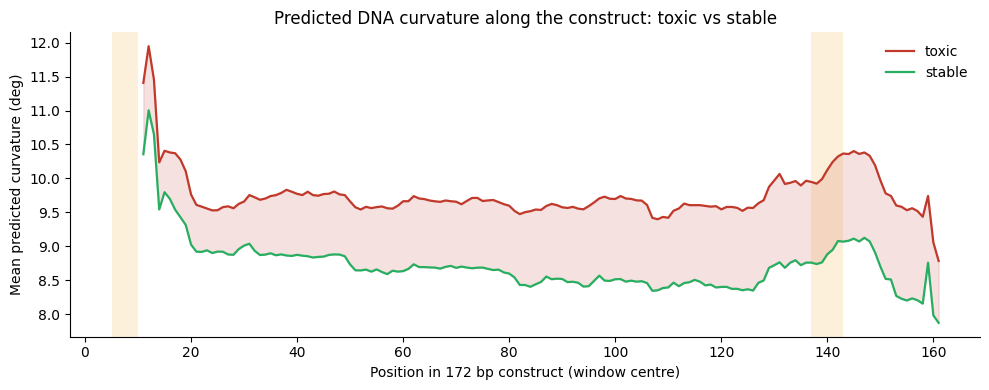


 Robustness: toxic-vs-stable curv_max effect across AA/TT wedge values
  AA/TT wedge=  5.0 deg  ->  toxic-vs-stable d(curv_max) = +0.433
  AA/TT wedge=  6.0 deg  ->  toxic-vs-stable d(curv_max) = +0.511
  AA/TT wedge=  7.2 deg  ->  toxic-vs-stable d(curv_max) = +0.553
  AA/TT wedge=  8.5 deg  ->  toxic-vs-stable d(curv_max) = +0.575
  AA/TT wedge= 10.0 deg  ->  toxic-vs-stable d(curv_max) = +0.589

  If d stays same-signed and similar magnitude across the row, the
  toxic>stable curvature claim does NOT depend on the exact wedge table.
  That is the robustness statement to put in the methods caveat.

  Globals set: curv_tox_mat, curv_sta_mat (Cell SP picks up).


In [ ]:
# =====================================================================
# @title Cell 29c: Positional curvature map (toxic vs stable) + robustness
# =====================================================================
# WHAT THIS TESTS:
#   (1) WHERE along the 172 bp window curvature concentrates — to cross-
#       reference the 5' hotspot (pos 5-9) seen in the H-NS map (Cell 28c)
#       and AT-tract clustering (Cell 27c). Co-location would mean the
#       same 5' element carries AT-tract, H-NS propensity, AND curvature.
#   (2) ROBUSTNESS: re-score the toxic-vs-stable curvature effect under an
#       alternative wedge magnitude for AA/TT. If the differential holds
#       across parameter choices, the comparison does not depend on the
#       exact (unverified) table values.
# =====================================================================
import numpy as np, os
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

WORK_DIR  = globals().get('WORK_DIR', '/content/streme_work')
DRIVE_OUT = '/content/drive/MyDrive/Plasmids/streme_outputs'
FASTA_DIR = globals().get('FASTA_DIR',
                          '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
os.makedirs(DRIVE_OUT, exist_ok=True)

def _load_seqs(path):
    seqs, buf, started = [], [], False
    with open(path) as fh:
        for line in fh:
            if line.startswith('>'):
                if started: seqs.append(''.join(buf)); buf = []
                started = True
            else:
                buf.append(line.strip().upper())
        if buf: seqs.append(''.join(buf))
    return seqs

tox_seqs = _load_seqs(os.path.join(FASTA_DIR, 'discovery_toxic_cohort.fa'))
sta_seqs = _load_seqs(os.path.join(FASTA_DIR, 'discovery_stable_cohort.fa'))

# Fixed-length positional stacking (use the modal 172 bp window)
def _positional_stack(seqs, L=172):
    rows = [curvature_profile(s) for s in seqs if len(s) >= L]
    width = min(len(r) for r in rows)
    mat = np.vstack([r[:width] for r in rows])
    return mat  # (n_seq, width)

tox_mat = _positional_stack(tox_seqs)
sta_mat = _positional_stack(sta_seqs)
tox_mean = tox_mat.mean(0); sta_mean = sta_mat.mean(0)
xpos = np.arange(tox_mean.size) + (CURV_WINDOW // 2) + 1   # centre of window

# per-position MW test, toxic vs stable
pvals = np.array([mannwhitneyu(tox_mat[:, i], sta_mat[:, i],
                               alternative='greater')[1]
                  for i in range(tox_mean.size)])

print("=" * 70)
print(" Positional curvature — toxic vs stable")
print("=" * 70)
sig = np.where(pvals < (0.05 / pvals.size))[0]   # Bonferroni
if sig.size:
    runs = np.split(sig, np.where(np.diff(sig) > 1)[0] + 1)
    print("  Windows where toxic curvature > stable (Bonferroni p<0.05):")
    for r in runs:
        print(f"    centre pos {xpos[r[0]]:>3}-{xpos[r[-1]]:>3}  "
              f"(peak deltacurv={np.max(tox_mean[r]-sta_mean[r]):.2f} deg)")
else:
    print("  No positionally-localised toxic>stable curvature window survives.")

# ─── PLOT ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xpos, tox_mean, color='#c0392b', lw=1.6, label='toxic')
ax.plot(xpos, sta_mean, color='#27ae60', lw=1.6, label='stable')
ax.fill_between(xpos, sta_mean, tox_mean,
                where=(tox_mean >= sta_mean), color='#c0392b', alpha=0.15)
for b0, b1 in [(5, 10), (137, 143)]:   # hotspots from Cell 27c / 28c
    ax.axvspan(b0, b1, color='#f39c12', alpha=0.15, lw=0)
ax.set_xlabel('Position in 172 bp construct (window centre)')
ax.set_ylabel('Mean predicted curvature (deg)')
ax.set_title('Predicted DNA curvature along the construct: toxic vs stable')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
for ext in ['png', 'pdf']:
    fig.savefig(os.path.join(WORK_DIR, f'cell29c_curvature_positional.{ext}'),
                dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(DRIVE_OUT, 'cell29c_curvature_positional.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# ─── ROBUSTNESS: re-score effect under alternative AA/TT wedge ────────────
print("\n" + "=" * 70)
print(" Robustness: toxic-vs-stable curv_max effect across AA/TT wedge values")
print("=" * 70)

def _cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1))
                 / (len(a)+len(b)-2))
    return (a.mean()-b.mean())/sp if sp > 0 else np.nan

_orig = _WEDGE.copy()
for aa_val in [5.0, 6.0, 7.2, 8.5, 10.0]:
    w = _orig.copy()
    w[4*0+0] = aa_val          # AA
    w[4*3+3] = aa_val          # TT
    globals()['_WEDGE'] = w
    tox_cmax = np.array([curvature_profile(s).max() for s in tox_seqs if len(s) >= 2])
    sta_cmax = np.array([curvature_profile(s).max() for s in sta_seqs if len(s) >= 2])
    d = _cohens_d(tox_cmax, sta_cmax)
    print(f"  AA/TT wedge={aa_val:5.1f} deg  ->  toxic-vs-stable d(curv_max) = {d:+.3f}")
globals()['_WEDGE'] = _orig   # restore

print("\n  If d stays same-signed and similar magnitude across the row, the")
print("  toxic>stable curvature claim does NOT depend on the exact wedge table.")
print("  That is the robustness statement to put in the methods caveat.")

# globals for SP
globals()['curv_tox_mat'] = tox_mat
globals()['curv_sta_mat'] = sta_mat
print("\n  Globals set: curv_tox_mat, curv_sta_mat (Cell SP picks up).")

In [ ]:
# =====================================================================
# @title Cell 29d: Curvature wedge-parameter provenance + robustness
# =====================================================================
# Verifies curvature parameters against the primary sources and reports a
# single interpretable finding. Load-bearing quantity = partial(curv | full
# AT block): if it stays ~0 across tables/params, curvature is not a
# separable axis (only the absolute scale depends on the wedge values).
# =====================================================================
import numpy as np, os, re
from scipy.stats import spearmanr, pearsonr, rankdata
from numpy.linalg import lstsq

assert 'test_df' in globals(), "test_df not restored -- run Cell 1b first."

N_PERTURB, PERT_SIGMA, SUBSAMPLE = 25, 0.15, 6000
PARTIAL_NEGLIGIBLE = 0.05   # |partial(curv|FULL AT block)| below this = curvature adds ~nothing
RNG = np.random.default_rng(0)
FASTA_DIR = globals().get('FASTA_DIR','/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
COHORTS = {'toxic':os.path.join(FASTA_DIR,'discovery_toxic_cohort.fa'),
           'stable':os.path.join(FASTA_DIR,'discovery_stable_cohort.fa'),
           'control':os.path.join(FASTA_DIR,'discovery_control_GC_matched.fa')}

ENGINE_WEDGE = {'AA':7.2,'AC':1.1,'AG':2.6,'AT':1.6,'CA':5.4,'CC':3.0,'CG':4.6,
                'CT':2.6,'GA':2.3,'GC':0.4,'GG':3.0,'GT':1.1,'TA':5.0,'TC':2.3,
                'TG':5.4,'TT':7.2}
TWIST, WINDOW = 34.3, 21
_B2I = {'A':0,'C':1,'G':2,'T':3}
COMP = {'A':'T','T':'A','C':'G','G':'C'}
UNIQUE = ['AA','AC','AG','AT','CA','CC','CG','GA','GC','TA']
def _rc(d): return COMP[d[1]] + COMP[d[0]]
def _expand(u): return {**u, **{_rc(k):v for k,v in u.items()}}
def _wedge_vec(table):
    w=np.zeros(16)
    for d,v in table.items(): w[4*_B2I[d[0]]+_B2I[d[1]]]=v
    return w
def build_table(vals):
    t={}
    for d,v in zip(UNIQUE,vals): t[d]=v; t[_rc(d)]=v
    return t
def _idx(seq):
    return np.frombuffer(seq.upper().replace('A','\x00').replace('C','\x01')
                            .replace('G','\x02').replace('T','\x03')
                            .encode('latin-1'),dtype=np.uint8)

# ---- De Santis 1990 Chart I: full roll / tilt / twist matrices (deg) ----
DS_ROLL = {'AA':-5.4,'AT':-7.3,'AG':1.0,'AC':-2.4,'TA':8.0,'TT':-5.4,'TG':6.7,
           'TC':2.0,'CA':6.7,'CT':1.0,'CG':4.6,'CC':1.3,'GA':2.0,'GT':-2.4,
           'GG':1.3,'GC':-3.7}
DS_TILT = {'AA':-0.5,'AT':0.0,'AG':-1.6,'AC':-2.7,'TA':0.0,'TT':0.5,'TG':-0.4,
           'TC':1.7,'CA':0.4,'CT':1.6,'CG':0.0,'CC':0.6,'GA':-1.7,'GT':2.7,
           'GG':-0.6,'GC':0.0}
DS_TWIST = {'AA':35.9,'AT':35.0,'AG':35.6,'AC':34.6,'TA':34.6,'TT':35.9,'TG':34.5,
            'TC':35.8,'CA':34.5,'CT':35.6,'CG':33.7,'CC':33.0,'GA':35.8,'GT':34.6,
            'GG':33.0,'GC':33.3}
DESANTIS_WEDGE = {d: round(float(np.hypot(DS_ROLL[d],DS_TILT[d])),2) for d in DS_ROLL}
DS_ROLL_V=_wedge_vec(DS_ROLL); DS_TILT_V=_wedge_vec(DS_TILT); DS_TWIST_V=_wedge_vec(DS_TWIST)
def curv_max_desantis(seq, window=WINDOW):
    idx=_idx(seq)
    if idx.size<2: return np.nan
    di=4*idx[:-1]+idx[1:]
    roll=DS_ROLL_V[di]; tilt=DS_TILT_V[di]; tw=np.deg2rad(DS_TWIST_V[di])
    phase=np.concatenate([[0.0],np.cumsum(tw)[:-1]])
    dC=(roll-1j*tilt)*np.exp(1j*phase)
    C=np.convolve(dC,np.ones(window),'valid')
    return float(np.abs(C).max()) if C.size else np.nan

# ---- 17 AT features + matrix partial (identical to Cell 31g) ----
AT_FEATURES=['n_t_runs_4plus','at_only_4mer_freq','at_only_3mer_freq','mean_at_run',
             'at_only_5mer_freq','n_t_runs_6plus','max_t_run','t_pct','n_at_runs_6plus',
             'n_at_runs_8plus','at_pct','max_at_run','n_at_runs_4plus','max_a_run',
             'n_a_runs_4plus','a_pct','n_a_runs_6plus']
def _runs(s,p): return [len(m.group(0)) for m in re.finditer(p,s)]
def _kf(cs,n,k): return 0.0 if n<k else float(np.mean((cs[k:]-cs[:-k])==k))
def at_features(seq):
    s=seq.upper(); n=len(s)
    if n==0: return {f:0.0 for f in AT_FEATURES}
    a=s.count('A'); t=s.count('T')
    isat=np.frombuffer(s.replace('A','\x01').replace('T','\x01').replace('C','\x00')
                        .replace('G','\x00').encode('latin-1'),dtype=np.uint8).astype(np.int64)
    cs=np.concatenate([[0],np.cumsum(isat)])
    ar=_runs(s,r'A+'); tr=_runs(s,r'T+'); atr=_runs(s,r'[AT]+')
    return {'a_pct':a/n,'t_pct':t/n,'at_pct':(a+t)/n,
        'max_a_run':max(ar) if ar else 0,'max_t_run':max(tr) if tr else 0,
        'max_at_run':max(atr) if atr else 0,'mean_at_run':float(np.mean(atr)) if atr else 0.0,
        'n_a_runs_4plus':sum(r>=4 for r in ar),'n_a_runs_6plus':sum(r>=6 for r in ar),
        'n_t_runs_4plus':sum(r>=4 for r in tr),'n_t_runs_6plus':sum(r>=6 for r in tr),
        'n_at_runs_4plus':sum(r>=4 for r in atr),'n_at_runs_6plus':sum(r>=6 for r in atr),
        'n_at_runs_8plus':sum(r>=8 for r in atr),
        'at_only_3mer_freq':_kf(cs,n,3),'at_only_4mer_freq':_kf(cs,n,4),'at_only_5mer_freq':_kf(cs,n,5)}
def _resid(vr,A): b,*_=lstsq(A,vr,rcond=None); return vr-A@b
def partial_spearman(x,y,Z):
    xr,yr=rankdata(x),rankdata(y)
    Zr=np.column_stack([rankdata(Z[:,j]) for j in range(Z.shape[1])])
    A=np.column_stack([np.ones(len(xr)),Zr])
    return pearsonr(_resid(xr,A),_resid(yr,A))[0]
def cohens_d(a,b):
    a,b=np.asarray(a),np.asarray(b); na,nb=len(a),len(b)
    sp=np.sqrt(((na-1)*a.var(ddof=1)+(nb-1)*b.var(ddof=1))/(na+nb-2))
    return (a.mean()-b.mean())/sp if sp>0 else 0.0

# ---- build the 36,860 set ----
_norm=lambda s: s.split('|')[0].lstrip('>')
lfc_lkp={_norm(str(i)):l for i,l in zip(test_df['id'],test_df['lfc'])}
def read_cohorts():
    ids,seqs,coh=[],[],[]
    for name,p in COHORTS.items():
        if not os.path.exists(p): print('  MISSING',p); continue
        h=None; buf=[]
        for line in open(p):
            line=line.rstrip()
            if line.startswith('>'):
                if h is not None: ids.append(_norm(h)); seqs.append(''.join(buf)); coh.append(name)
                h=line; buf=[]
            else: buf.append(line)
        if h is not None: ids.append(_norm(h)); seqs.append(''.join(buf)); coh.append(name)
    return ids,seqs,np.array(coh)
ids,seqs,coh=read_cohorts()
keep=[i for i,k in enumerate(ids) if k in lfc_lkp and len(seqs[i])>=WINDOW+1]
seqs=[seqs[i] for i in keep]; coh=coh[keep]; y=np.array([lfc_lkp[ids[i]] for i in keep])
print(f"  set: {len(seqs):,} seqs  (toxic {np.sum(coh=='toxic'):,}, "
      f"stable {np.sum(coh=='stable'):,}, control {np.sum(coh=='control'):,})")
eng_vec=_wedge_vec(ENGINE_WEDGE)
BOLSHOY = _expand({'AA':7.2,'AC':1.1,'AG':8.4,'AT':2.6,'CA':3.5,'CC':2.1,'CG':6.7,
                   'GA':5.3,'GC':5.0,'TA':0.9})

# =====================================================================
# PART A — three-way wedge magnitude table
# =====================================================================
print("\n"+"="*72); print(" PART A — wedge magnitudes (deg): engine vs Bolshoy 1991 vs De Santis 1990")
print("="*72); print("   step      engine   Bolshoy   DeSantis")
for d in UNIQUE:
    f1="*" if abs(ENGINE_WEDGE[d]-BOLSHOY[d])>=3 else " "
    f2="*" if abs(ENGINE_WEDGE[d]-DESANTIS_WEDGE[d])>=3 else " "
    print(f"   {d}/{_rc(d)}   {ENGINE_WEDGE[d]:>6}{f1}  {BOLSHOY[d]:>6}   {DESANTIS_WEDGE[d]:>6}{f2}")
print(f"   twist={TWIST} deg/bp   window={WINDOW} bp     (* = engine differs >=3 deg)")

# =====================================================================
# PART B — wedge-table deltas vs published (parameter agreement only)
# =====================================================================
print("\n"+"="*72); print(" PART B — engine wedge table vs published (parameters only)"); print("="*72)
for name,ref in {'Bolshoy 1991':BOLSHOY,'De Santis 1990':DESANTIS_WEDGE}.items():
    e=np.array([ENGINE_WEDGE[d] for d in ENGINE_WEDGE]); r=np.array([ref[d] for d in ENGINE_WEDGE])
    dd={d:ENGINE_WEDGE[d]-ref[d] for d in ENGINE_WEDGE}
    print(f"  {name:<14}: max|delta|={max(abs(v) for v in dd.values()):.2f} (at {max(dd,key=lambda k:abs(dd[k]))})"
          f"  mean|delta|={np.mean([abs(v) for v in dd.values()]):.2f}"
          f"  Spearman={spearmanr(e,r)[0]:+.3f}  scale-ratio={r.mean()/e.mean():.3f}")
print("  (engine matches neither table exactly; Part C tests whether that matters for the conclusion)")

# =====================================================================
# PART C — curvature effect under every configuration
# =====================================================================
sub=RNG.choice(len(seqs),size=min(SUBSAMPLE,len(seqs)),replace=False)
sub_seqs=[seqs[i] for i in sub]; sub_coh=coh[sub]; y_sub=y[sub]
sub_tox=sub_coh=='toxic'; sub_sta=sub_coh=='stable'
F_sub=np.column_stack([[d[f] for d in (at_features(s) for s in sub_seqs)] for f in AT_FEATURES])
def make_pre(twist,window):
    pre=[]
    for s in sub_seqs:
        idx=_idx(s)
        if idx.size<2: pre.append(None); continue
        di=4*idx[:-1]+idx[1:]; phi=np.deg2rad(twist)*np.arange(di.size)
        pre.append((di,np.cos(phi),np.sin(phi),np.ones(window)))
    return pre
def curv_fast(wvec,pre):
    out=np.empty(len(pre))
    for i,t in enumerate(pre):
        if t is None: out[i]=np.nan; continue
        di,c,s,k=t; w=wvec[di]
        Cx=np.convolve(w*c,k,'valid'); Cy=np.convolve(w*s,k,'valid')
        out[i]=np.sqrt(Cx*Cx+Cy*Cy).max() if Cx.size else np.nan
    return out
sub_pre=make_pre(TWIST,WINDOW)
c_eng=curv_fast(eng_vec,sub_pre)

REC=[]
def record(label,c,kind):
    r={'label':label,'kind':kind,
       'd':float(cohens_d(c[sub_tox],c[sub_sta])),
       'partial':float(partial_spearman(c,y_sub,F_sub)),
       'mean':float(np.nanmean(c)),
       'rankcorr':float(spearmanr(c,c_eng)[0])}
    REC.append(r); return r
def prow(r):
    flag = "" if abs(r['partial'])<PARTIAL_NEGLIGIBLE else "  <-- partial not ~0"
    print(f"    {r['label']:<32} d={r['d']:+.3f}  partial={r['partial']:+.3f}  "
          f"mean={r['mean']:6.2f}  rho_to_engine={r['rankcorr']:+.3f}{flag}")

print("\n"+"="*72); print(" PART C — curvature effect under every configuration"); print("="*72)
print(f"    {'config':<32} {'differential':<12} {'partial|AT':<12} {'abs deg':<8} ordering")
prow(record('engine baseline', c_eng, 'baseline'))
eng_unique=np.array([ENGINE_WEDGE[d] for d in UNIQUE]); rc_l,d_l,p_l,m_l=[],[],[],[]
for _ in range(N_PERTURB):
    vals=np.clip(eng_unique*(1+RNG.normal(0,PERT_SIGMA,size=len(eng_unique))),0,None)
    cv=curv_fast(_wedge_vec(build_table(vals)),sub_pre)
    rc_l.append(float(spearmanr(cv,c_eng)[0])); d_l.append(float(cohens_d(cv[sub_tox],cv[sub_sta])))
    p_l.append(float(partial_spearman(cv,y_sub,F_sub))); m_l.append(float(np.nanmean(cv)))
print(f"    {'25 random +/-15% tables':<32} d=[{min(d_l):+.2f},{max(d_l):+.2f}] "
      f"partial=[{min(p_l):+.3f},{max(p_l):+.3f}] mean=[{min(m_l):.1f},{max(m_l):.1f}] "
      f"rho>={min(rc_l):.2f}")
prow(record('AA/TT-only model', curv_fast(_wedge_vec(build_table([7.2 if d=='AA' else 0.0 for d in UNIQUE])),sub_pre),'variant'))
for tw in (34.0,34.6): prow(record(f'twist {tw} deg/bp', curv_fast(eng_vec,make_pre(tw,WINDOW)),'variant'))
for wn in (17,25):     prow(record(f'window {wn} bp',   curv_fast(eng_vec,make_pre(TWIST,wn)),'variant'))
c_ds=np.array([curv_max_desantis(s) for s in sub_seqs])
prow(record('De Santis full r/t/twist', c_ds, 'variant'))
prow(record('Bolshoy 1991 table', curv_fast(_wedge_vec(BOLSHOY),sub_pre), 'reference'))
prow(record('De Santis 1990 table', curv_fast(_wedge_vec(DESANTIS_WEDGE),sub_pre), 'reference'))

# =====================================================================
# PART D — Brukner 1995 trinucleotide bendability (for _BEND_RAW only)
# =====================================================================
def _rc3(t): return ''.join(COMP[b] for b in t[::-1])
_BRUK32={'AAT':-0.280,'AAA':-0.274,'CCA':-0.246,'AAC':-0.205,'ACT':-0.183,'CCG':-0.136,
 'ATC':-0.110,'AAG':-0.081,'CGC':-0.077,'AGG':-0.057,'GAA':-0.037,'ACG':-0.033,'ACC':-0.032,
 'GAC':-0.013,'CCC':-0.012,'ACA':-0.006,'CGA':-0.003,'GGA':0.013,'CAA':0.015,'AGC':0.017,
 'GTA':0.025,'AGA':0.027,'CTC':0.031,'CAC':0.040,'TAA':0.068,'GCA':0.076,'CTA':0.090,
 'GCC':0.107,'ATG':0.134,'CAG':0.175,'ATA':0.182,'TCA':0.194}
BRUKNER_1995_BENDABILITY={**_BRUK32,**{_rc3(k):v for k,v in _BRUK32.items()}}

# =====================================================================
# aggregate across every configuration + capture global
# =====================================================================
all_p=[r['partial'] for r in REC]+p_l
all_d=[r['d'] for r in REC]+d_l
all_m=[r['mean'] for r in REC]+m_l
all_rc=[r['rankcorr'] for r in REC if r['label']!='engine baseline']+rc_l
n_cfg=len(all_p)
max_abs_partial=max(abs(x) for x in all_p)
d_sign_uniform=all(x>0 for x in all_d) or all(x<0 for x in all_d)
collapse=max_abs_partial < PARTIAL_NEGLIGIBLE

if collapse and d_sign_uniform:
    finding=("ROBUST. Curvature is NOT a separable axis. Across every wedge table "
             "(engine, Bolshoy 1991, De Santis 1990, De Santis-exact roll/tilt/twist) "
             "and every twist/window/perturbation, it adds essentially nothing beyond "
             "the full AT-tract block. Only the absolute curvature scale depends on the "
             "wedge values; the single-axis conclusion does not.")
elif collapse:
    finding=("Partial collapses everywhere, but the toxic-vs-stable curvature sign is "
             "not uniform across tables. Report the differential qualitatively only; the "
             "beyond-AT collapse still holds.")
else:
    finding=(f"NON-TRIVIAL: at least one configuration retains curvature beyond AT "
             f"(max|partial|={max_abs_partial:.3f} >= {PARTIAL_NEGLIGIBLE}). Inspect before "
             f"claiming collapse.")

import datetime as _dt
curv_param_verification={
  'engine_wedge':dict(ENGINE_WEDGE),'bolshoy_1991':dict(BOLSHOY),'desantis_1990_mag':dict(DESANTIS_WEDGE),
  'desantis_roll':dict(DS_ROLL),'desantis_tilt':dict(DS_TILT),'desantis_twist':dict(DS_TWIST),
  'twist':TWIST,'window':WINDOW,'n_subsample':int(len(sub_seqs)),
  'per_config':{r['label']:{'d':round(r['d'],4),'partial':round(r['partial'],4),
                            'mean':round(r['mean'],3),'rankcorr':round(r['rankcorr'],4)} for r in REC},
  'perturbation':{'n':N_PERTURB,'sigma':PERT_SIGMA,
      'partial_range':[round(min(p_l),4),round(max(p_l),4)],
      'd_range':[round(min(d_l),4),round(max(d_l),4)],
      'mean_range':[round(min(m_l),3),round(max(m_l),3)],
      'rankcorr_min':round(min(rc_l),4)},
  'aggregate':{'n_configs':n_cfg,
      'partial_range':[round(min(all_p),4),round(max(all_p),4)],
      'max_abs_partial':round(max_abs_partial,4),
      'd_range':[round(min(all_d),4),round(max(all_d),4)],'d_sign_uniform':bool(d_sign_uniform),
      'mean_curv_range':[round(min(all_m),2),round(max(all_m),2)],
      'rankcorr_range':[round(min(all_rc),3),round(max(all_rc),3)],
      'partial_threshold':PARTIAL_NEGLIGIBLE},
  'collapse_robust':bool(collapse and d_sign_uniform),
  'finding':finding,
  'timestamp':_dt.datetime.now().isoformat(timespec='seconds'),
}

# =====================================================================
# CONCLUSION (interpretable, prints last)
# =====================================================================
print("\n"+"="*72); print(" CONCLUSION"); print("="*72)
print(f"  Configurations tested: {n_cfg}  (engine + {N_PERTURB} perturbations + "
      f"{sum(r['kind']=='variant' for r in REC)} variants + 2 published tables)")
print(f"\n  LOAD-BEARING  partial rho(curv | FULL AT block):")
print(f"    range [{min(all_p):+.3f}, {max(all_p):+.3f}]   max|partial| = {max_abs_partial:.3f}"
      f"   (negligible if < {PARTIAL_NEGLIGIBLE})")
print(f"    => curvature adds {'NOTHING beyond the AT block in every case' if collapse else 'signal in at least one case'}")
print(f"\n  SECONDARY  toxic-vs-stable curvature differential (descriptive only):")
print(f"    d range [{min(all_d):+.3f}, {max(all_d):+.3f}]   sign "
      f"{'uniform' if d_sign_uniform else 'NOT uniform'}   (magnitude is table-dependent)")
print(f"\n  EXPECTED TO MOVE (not part of the conclusion):")
print(f"    absolute mean curv [{min(all_m):.1f}, {max(all_m):.1f}] deg  — depends on the wedge table")
print(f"    per-seq ordering rho-to-engine [{min(all_rc):.2f}, {max(all_rc):.2f}]  — the published")
print(f"      tables reshuffle WHICH seqs are 'most curved', yet partial stays ~0 anyway,")
print(f"      which makes the collapse especially robust.")
print(f"\n  FINDING: {finding}")
print(f"\n  stored global: curv_param_verification ({len(curv_param_verification)} keys)")

  set: 36,860 seqs  (toxic 9,215, stable 9,215, control 18,430)

 PART A — wedge magnitudes (deg): engine vs Bolshoy 1991 vs De Santis 1990
   step      engine   Bolshoy   DeSantis
   AA/TT      7.2      7.2     5.42 
   AC/GT      1.1      1.1     3.61 
   AG/CT      2.6*     8.4     1.89 
   AT/AT      1.6      2.6      7.3*
   CA/TG      5.4      3.5     6.71 
   CC/GG      3.0      2.1     1.43 
   CG/CG      4.6      6.7      4.6 
   GA/TC      2.3*     5.3     2.62 
   GC/GC      0.4*     5.0      3.7*
   TA/TA      5.0*     0.9      8.0*
   twist=34.3 deg/bp   window=21 bp     (* = engine differs >=3 deg)

 PART B — engine wedge table vs published (parameters only)
  Bolshoy 1991  : max|delta|=5.80 (at AG)  mean|delta|=2.19  Spearman=+0.261  scale-ratio=1.285
  De Santis 1990: max|delta|=5.70 (at AT)  mean|delta|=1.77  Spearman=+0.341  scale-ratio=1.222
  (engine matches neither table exactly; Part C tests whether that matters for the conclusion)

 PART C — curvature effect unde

In [ ]:
# =====================================================================
# @title Cell 30a: non-canonical -10 promoter scan (no -35 required)
# =====================================================================
# Scans both strands for sigma-70 -10 (Pribnow) boxes WITHOUT requiring a
# paired -35 — the non-canonical spurious-transcription signature (Warman
# 2020, Lamberte 2017). Contrast with Cell 24a canonical sigma-70 (flat,
# 1.05x). VERIFY the -10 PWM against RegulonDB / Harley-Reynolds before
# quoting absolute hit rates; the toxic-vs-stable differential is robust
# to the exact PWM since all cohorts share one scale + one threshold.
# =====================================================================
import os, numpy as np, pandas as pd
from scipy.stats import mannwhitneyu

FASTA_DIR = globals().get('FASTA_DIR', '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
WORK_DIR  = globals().get('WORK_DIR', '/content/streme_work')

# -10 (Pribnow) position frequencies, columns = A,C,G,T. VERIFY vs source.
_M10_FREQ = np.array([
    [0.16, 0.02, 0.05, 0.77],  # pos1 ~T
    [0.76, 0.06, 0.08, 0.10],  # pos2 ~A
    [0.20, 0.12, 0.13, 0.55],  # pos3 ~T
    [0.61, 0.10, 0.11, 0.18],  # pos4 ~A
    [0.56, 0.08, 0.09, 0.27],  # pos5 ~A
    [0.08, 0.05, 0.05, 0.82],  # pos6 ~T
])
_PWM10    = np.log2((_M10_FREQ + 1e-3) / 0.25)      # log-odds vs uniform
_PWM10_RC = _PWM10[::-1][:, [3, 2, 1, 0]]           # reverse-complement PWM
W10 = _PWM10.shape[0]

_B2I = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
_LUT = np.zeros(256, np.uint8)
for _b, _i in _B2I.items():
    _LUT[ord(_b)] = _i
def _idx(seq):
    return _LUT[np.frombuffer(seq.upper().encode('latin-1'), np.uint8)]

def _window_scores(ix, pwm):
    W = pwm.shape[0]; n = ix.size - W + 1
    if n <= 0:
        return np.zeros(0)
    s = np.zeros(n)
    for j in range(W):
        s += pwm[j, ix[j:j + n]]
    return s

def minus10_scores_bothstrands(seq):
    ix = _idx(seq)
    return _window_scores(ix, _PWM10), _window_scores(ix, _PWM10_RC)

def _load(path):
    out, hid, buf = [], None, []
    with open(path) as fh:
        for line in fh:
            line = line.rstrip()
            if line.startswith('>'):
                if hid is not None:
                    out.append((hid, ''.join(buf).upper()))
                hid, buf = line[1:].strip(), []
            else:
                buf.append(line)
        if hid is not None:
            out.append((hid, ''.join(buf).upper()))
    return out

cohorts = {
    'toxic':   _load(os.path.join(FASTA_DIR, 'discovery_toxic_cohort.fa')),
    'stable':  _load(os.path.join(FASTA_DIR, 'discovery_stable_cohort.fa')),
    'control': _load(os.path.join(FASTA_DIR, 'discovery_control_GC_matched.fa')),
}

# Calibrate hit threshold on CONTROL window scores (95th pct, both strands)
ctl_scores = []
for _, s in cohorts['control']:
    f, r = minus10_scores_bothstrands(s)
    ctl_scores.append(f); ctl_scores.append(r)
M10_THR = float(np.percentile(np.concatenate(ctl_scores), 95))
globals()['M10_THR'] = M10_THR
print(f"-10 score threshold (control 95th pct): {M10_THR:.3f}")

rows = []
for coh, recs in cohorts.items():
    for hid, s in recs:
        f, r = minus10_scores_bothstrands(s)
        n_hits = int((f >= M10_THR).sum() + (r >= M10_THR).sum())
        L = len(s)
        rows.append(dict(id=hid, cohort=coh, m10_hits=n_hits,
                         m10_density=n_hits / L if L else np.nan,
                         at_pct=(s.count('A') + s.count('T')) / L if L else np.nan,
                         seqlen=L))
sigma_noncanon_df = pd.DataFrame(rows)
globals()['sigma_noncanon_df'] = sigma_noncanon_df

def _d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

tox = sigma_noncanon_df[sigma_noncanon_df.cohort == 'toxic']
sta = sigma_noncanon_df[sigma_noncanon_df.cohort == 'stable']
ctl = sigma_noncanon_df[sigma_noncanon_df.cohort == 'control']

print("\n" + "=" * 78)
print(" NON-CANONICAL -10 ELEMENT DENSITY (both strands, no -35 required)")
print("=" * 78)
for name, g in [('toxic', tox), ('stable', sta), ('control', ctl)]:
    print(f"  {name:<8} mean -10 hits/seq = {g.m10_hits.mean():6.2f}   "
          f"density/bp = {g.m10_density.mean():.4f}")
print(f"\n  toxic vs stable    d = {_d(tox.m10_hits, sta.m10_hits):+.3f}   "
      f"MW p = {mannwhitneyu(tox.m10_hits, sta.m10_hits, alternative='greater')[1]:.2e}")
print(f"  toxic vs control   d = {_d(tox.m10_hits, ctl.m10_hits):+.3f}   "
      f"enrichment = {tox.m10_hits.mean() / ctl.m10_hits.mean():.3f}x")
print(f"\n  Reference (Cell 24a): canonical sigma-70 (with -35) enrichment = 1.05x")
print(f"  Globals set: sigma_noncanon_df, M10_THR")

-10 score threshold (control 95th pct): 3.045

 NON-CANONICAL -10 ELEMENT DENSITY (both strands, no -35 required)
  toxic    mean -10 hits/seq =  18.60   density/bp = 0.1081
  stable   mean -10 hits/seq =  15.03   density/bp = 0.0874
  control  mean -10 hits/seq =  16.73   density/bp = 0.0973

  toxic vs stable    d = +0.548   MW p = 1.40e-267
  toxic vs control   d = +0.280   enrichment = 1.112x

  Reference (Cell 24a): canonical sigma-70 (with -35) enrichment = 1.05x
  Globals set: sigma_noncanon_df, M10_THR


rows entering test: 36860
 DOES NON-CANONICAL -10 DENSITY PREDICT LFC BEYOND AT%?
  cor(AT%, -10 density)        = +0.733
  marginal rho(-10, LFC)       = -0.199
  partial  rho(-10 | AT%)      = +0.005   <-- key
  delta-R^2 beyond AT%         = +0.0000

  Comparison (same beyond-AT% logic, prior cells):
    A-tract curvature   dR2 = +0.0148  (Cell 29b)
    canonical sigma-70  dR2 = +0.0039  (Cell 24b)
    §2.3 TFBS density   dR2 = +0.0004  (Cell 26)

  INTERPRETATION:
    => -10-like density is highly collinear with AT% and adds little
       beyond it. The spurious-transcription CAPACITY is intrinsic to
       AT composition: AT-rich DNA is saturated with weak -10-like boxes
       that need no -35. Burden tracks this density, but it cannot be
       separated from AT-richness — the non-canonical, pervasive-weak-
       promoter signature (Lamberte 2017 / Warman 2020), NOT discrete
       canonical promoters (consistent with Cell 24a/24b flat sigma-70).


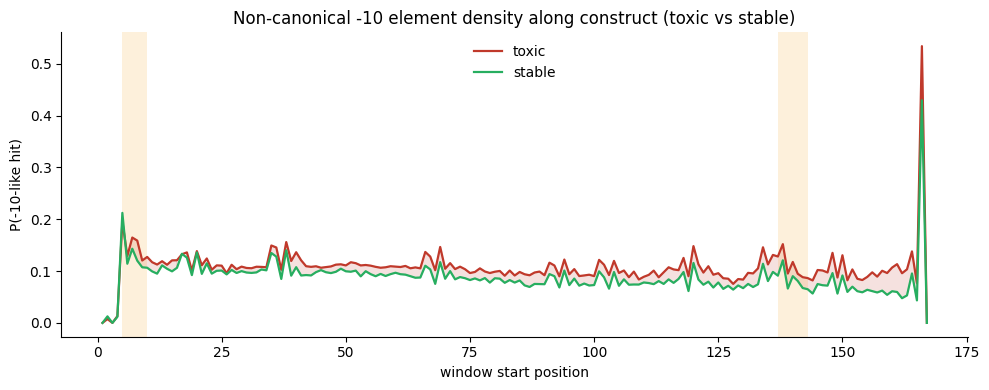


  Globals set: sigma_noncanon_predict; figure saved to WORK_DIR.


In [ ]:
# =====================================================================
# @title Cell 30b: does non-canonical -10 density predict LFC beyond AT%?
# =====================================================================
import os, numpy as np, pandas as pd
from scipy.stats import spearmanr, rankdata
from numpy.linalg import lstsq
import matplotlib.pyplot as plt

assert 'sigma_noncanon_df' in globals(), "run Cell 30a first"
assert 'test_df' in globals(), "run Cell 1b to load test_df"
FASTA_DIR = globals().get('FASTA_DIR', '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
WORK_DIR  = globals().get('WORK_DIR', '/content/streme_work')
THR = globals()['M10_THR']

# LFC via the validated full-header id-join with test_df
m = sigma_noncanon_df.merge(test_df[['id', 'lfc']], on='id', how='inner')
m = m.dropna(subset=['lfc', 'at_pct', 'm10_density'])
print(f"rows entering test: {len(m)}")

y, at, mt = m['lfc'].values, m['at_pct'].values, m['m10_density'].values

def _partial(x, y, z):
    xr, yr, zr = rankdata(x), rankdata(y), rankdata(z)
    rx = xr - np.polyval(np.polyfit(zr, xr, 1), zr)
    ry = yr - np.polyval(np.polyfit(zr, yr, 1), zr)
    return spearmanr(rx, ry)[0]

rho_m  = spearmanr(mt, y)[0]
rho_mp = _partial(mt, y, at)
collin = spearmanr(at, mt)[0]
def _z(v): return (v - v.mean()) / v.std()
yz, atz, mtz = _z(y), _z(at), _z(mt)
def _r2(cols):
    X = np.column_stack([np.ones(len(yz))] + cols)
    b, *_ = lstsq(X, yz, rcond=None)
    return 1 - ((yz - X @ b) ** 2).sum() / ((yz - yz.mean()) ** 2).sum()
dR2 = _r2([atz, mtz]) - _r2([atz])

print("=" * 78)
print(" DOES NON-CANONICAL -10 DENSITY PREDICT LFC BEYOND AT%?")
print("=" * 78)
print(f"  cor(AT%, -10 density)        = {collin:+.3f}")
print(f"  marginal rho(-10, LFC)       = {rho_m:+.3f}")
print(f"  partial  rho(-10 | AT%)      = {rho_mp:+.3f}   <-- key")
print(f"  delta-R^2 beyond AT%         = {dR2:+.4f}")
print(f"\n  Comparison (same beyond-AT% logic, prior cells):")
print(f"    A-tract curvature   dR2 = +0.0148  (Cell 29b)")
print(f"    canonical sigma-70  dR2 = +0.0039  (Cell 24b)")
print(f"    §2.3 TFBS density   dR2 = +0.0004  (Cell 26)")

print("\n  INTERPRETATION:")
if collin > 0.6 and abs(rho_mp) < 0.05:
    print("    => -10-like density is highly collinear with AT% and adds little")
    print("       beyond it. The spurious-transcription CAPACITY is intrinsic to")
    print("       AT composition: AT-rich DNA is saturated with weak -10-like boxes")
    print("       that need no -35. Burden tracks this density, but it cannot be")
    print("       separated from AT-richness — the non-canonical, pervasive-weak-")
    print("       promoter signature (Lamberte 2017 / Warman 2020), NOT discrete")
    print("       canonical promoters (consistent with Cell 24a/24b flat sigma-70).")
else:
    print("    => -10-like density retains signal beyond AT%, suggesting discrete")
    print("       non-canonical promoter elements over and above bulk composition.")

# ── Positional -10 density profile (toxic vs stable), 172 bp window ────────
def _load_seqs(path):
    seqs, buf, st = [], [], False
    with open(path) as fh:
        for line in fh:
            if line.startswith('>'):
                if st: seqs.append(''.join(buf)); buf = []
                st = True
            else:
                buf.append(line.strip().upper())
        if buf: seqs.append(''.join(buf))
    return seqs

def _pos_profile(seqs, L=172):
    acc, n = None, 0
    for s in seqs:
        if len(s) < L: continue
        f, r = minus10_scores_bothstrands(s[:L])
        hit = ((f >= THR) | (r >= THR)).astype(float)
        acc = hit.copy() if acc is None else acc + hit
        n += 1
    return acc / n if n else acc

tox_p = _pos_profile(_load_seqs(os.path.join(FASTA_DIR, 'discovery_toxic_cohort.fa')))
sta_p = _pos_profile(_load_seqs(os.path.join(FASTA_DIR, 'discovery_stable_cohort.fa')))
x = np.arange(tox_p.size) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, tox_p, color='#c0392b', lw=1.6, label='toxic')
ax.plot(x, sta_p, color='#27ae60', lw=1.6, label='stable')
ax.fill_between(x, sta_p, tox_p, where=(tox_p >= sta_p), color='#c0392b', alpha=0.15)
for b0, b1 in [(5, 10), (137, 143)]:           # 5' / 3' hotspots from 27c/28c
    ax.axvspan(b0, b1, color='#f39c12', alpha=0.15, lw=0)
ax.set_xlabel('window start position'); ax.set_ylabel('P(-10-like hit)')
ax.set_title('Non-canonical -10 element density along construct (toxic vs stable)')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(os.path.join(WORK_DIR, 'cell30b_minus10_positional.png'),
            dpi=300, bbox_inches='tight')
plt.show()

globals()['sigma_noncanon_predict'] = m
print("\n  Globals set: sigma_noncanon_predict; figure saved to WORK_DIR.")

In [ ]:
# =====================================================================
# @title Cell 31a: Toxic subtypes by §2.3 regulator dependency
# =====================================================================
# Cell 16 showed §2.3 regulators co-occur at background rate and toxic
# plasmids carry 1-2 distinct dependencies. This clusters toxic plasmids
# by their §2.3 hit profile and tests whether subtypes differ in LFC.
# (Subtypes are within the GGS3 toxic cohort; they are NOT linkable to
#  the MTK1 strains — different library. DH5a is handled in Cell 31b.)
# =====================================================================
import os, re, subprocess, numpy as np, pandas as pd
from scipy.stats import kruskal
from sklearn.cluster import KMeans

WORK_DIR  = globals().get('WORK_DIR', '/content/streme_work')
FASTA_DIR = globals().get('FASTA_DIR', '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
PRODORIC  = globals().get('PRODORIC_MEME',
            '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme')
KEY_TFS = ['IHF','Lrp','Fur','PhoP','Fis','OmpR','OxyR','ArgR','CRP','NarL']

def _load_fasta(path):
    """Return list of (header, seq)."""
    recs, hdr, buf = [], None, []
    with open(path) as fh:
        for line in fh:
            line = line.rstrip()
            if line.startswith('>'):
                if hdr is not None: recs.append((hdr, ''.join(buf)))
                hdr, buf = line[1:].strip(), []
            else: buf.append(line)
        if hdr is not None: recs.append((hdr, ''.join(buf)))
    return recs

def _build_key_meme(out_path):
    """Extract §2.3 TF motif blocks from prodoric into a small MEME file."""
    with open(PRODORIC) as f: txt = f.read()
    header = txt[:txt.find('MOTIF')]
    blocks = re.split(r'(?=^MOTIF )', txt, flags=re.M)
    keep = [b for b in blocks if b.startswith('MOTIF')
            and any(re.match(rf'MOTIF \S+ {tf}\b', b) for tf in KEY_TFS)]
    with open(out_path, 'w') as w:
        w.write(header); w.write('\n'.join(keep))
    return len(keep)

KEY_MEME = globals().get('KEY_TF_MEME', os.path.join(WORK_DIR, 'prodoric_key_AT_TFs.meme'))
if not os.path.exists(KEY_MEME):
    n = _build_key_meme(KEY_MEME); print(f"Built key MEME with {n} §2.3 motifs")

def _fimo_incidence(meme, fasta, tag, thresh='1e-4'):
    """Run FIMO, return DataFrame [sequence_name x tf_name] binary incidence."""
    out = os.path.join(WORK_DIR, f'fimo_{tag}')
    subprocess.run(['fimo','--oc',out,'--thresh',thresh,'--verbosity','1',meme,fasta],
                   check=True, capture_output=True, text=True)
    tsv = os.path.join(out, 'fimo.tsv')
    df = pd.read_csv(tsv, sep='\t', comment='#').dropna(subset=['sequence_name'])
    # map motif -> TF name from MEME alt ids
    df['tf'] = df['motif_alt_id'].fillna(df['motif_id'])
    inc = (df.assign(hit=1)
             .pivot_table(index='sequence_name', columns='tf', values='hit',
                          aggfunc='max', fill_value=0))
    return (inc > 0).astype(int)

TOXIC_FA = os.path.join(FASTA_DIR, 'discovery_toxic_cohort.fa')
print("Running §2.3 FIMO on toxic cohort...")
inc = _fimo_incidence(KEY_MEME, TOXIC_FA, 'key_toxic')
# collapse multiple PWMs per TF to TF level
inc.columns = [c for c in inc.columns]
tf_level = {}
for tf in KEY_TFS:
    cols = [c for c in inc.columns if str(c).startswith(tf)]
    if cols: tf_level[tf] = (inc[cols].sum(axis=1) > 0).astype(int)
M = pd.DataFrame(tf_level).reindex(columns=KEY_TFS, fill_value=0)

# LFC + AT% per toxic plasmid from header
recs = _load_fasta(TOXIC_FA)
meta = {}
for h, s in recs:
    m = re.search(r'lfc=(-?\d+\.?\d*)', h)
    meta[h] = (float(m.group(1)) if m else np.nan,
               (s.count('A')+s.count('T'))/len(s) if s else np.nan)
M = M[M.index.isin(meta)]
M['lfc']    = [meta[i][0] for i in M.index]
M['at_pct'] = [meta[i][1] for i in M.index]

# cluster on the binary §2.3 profile (k=5)
K = 5
feat = M[KEY_TFS].values
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(feat)
M['subtype'] = km.labels_

print("\n" + "="*78)
print(" TOXIC SUBTYPES BY §2.3 DEPENDENCY PROFILE")
print("="*78)
rows = []
for k in range(K):
    sub = M[M.subtype == k]
    dom = M.loc[M.subtype == k, KEY_TFS].mean().sort_values(ascending=False)
    top = ", ".join(f"{tf}({dom[tf]*100:.0f}%)" for tf in dom.index[:3] if dom[tf] > 0.15)
    rows.append(dict(subtype=k, n=len(sub), median_lfc=sub.lfc.median(),
                     mean_at=sub.at_pct.mean(), dominant=top or "(low-hit)"))
sub_df = pd.DataFrame(rows).sort_values('median_lfc')
print(sub_df.to_string(index=False))

H, p = kruskal(*[M.loc[M.subtype == k, 'lfc'].dropna() for k in range(K)])
print(f"\n  Kruskal-Wallis LFC across subtypes: H={H:.1f}, p={p:.2e}")
print("  => if p<0.05, subtypes carry genuinely different burden, supporting")
print("     a heterogeneous-toxic-population reading rather than one mechanism.")

toxic_subtypes = M
sub_df.to_csv(os.path.join(WORK_DIR, 'cell31a_toxic_subtypes.csv'), index=False)
print(f"\n  Globals: toxic_subtypes;  saved cell31a_toxic_subtypes.csv")

Running §2.3 FIMO on toxic cohort...

 TOXIC SUBTYPES BY §2.3 DEPENDENCY PROFILE
 subtype    n  median_lfc  mean_at                        dominant
       1 1493     -0.5530 0.673725 PhoP(100%), Fur(100%), Lrp(17%)
       2  836     -0.5525 0.645870            Lrp(100%), PhoP(46%)
       3  749     -0.5500 0.646746   IHF(83%), PhoP(27%), Fis(20%)
       4 1111     -0.5490 0.654868             Fur(100%), Lrp(15%)
       0 1998     -0.5480 0.644805                      PhoP(100%)

  Kruskal-Wallis LFC across subtypes: H=0.4, p=9.81e-01
  => if p<0.05, subtypes carry genuinely different burden, supporting
     a heterogeneous-toxic-population reading rather than one mechanism.

  Globals: toxic_subtypes;  saved cell31a_toxic_subtypes.csv


In [ ]:
# =====================================================================
# @title Cell 31b: DH5a inversion — high-AT vs low-AT partition by strain
# =====================================================================
# Phase-1 Cell 39 found frac_high_at flips to +0.286 in DH5a only. This
# partitions the 191 MTK1 plasmids by AT-richness and shows, per strain,
# whether the high-AT subset is less burdensome — directly the question
# put to Tom.
# =====================================================================
import os, numpy as np, pandas as pd
from scipy.stats import spearmanr, mannwhitneyu

MTK1_CSV = globals().get('MTK1_CSV', None)
for cand in [MTK1_CSV,
             '/content/drive/MyDrive/Plasmids/cross_length/Plasmid_LFC_Summary_with_Sequences_1_.csv',
             '/content/drive/MyDrive/Plasmids/Plasmid_LFC_Summary_with_Sequences_1_.csv']:
    if cand and os.path.exists(cand): MTK1_CSV = cand; break
assert MTK1_CSV and os.path.exists(MTK1_CSV), "set MTK1_CSV to the single-part summary"

df = pd.read_csv(MTK1_CSV)
df['seq'] = df['DNA_sequence'].astype(str).str.upper()
df['at_pct'] = df['seq'].apply(lambda s: (s.count('A')+s.count('T'))/len(s) if s else np.nan)
strains = {'DH5a':'Average_LFC_DH5a', 'DH10B':'Average_LFC_DH10B', 'Stbl3':'Average_LFC_Stbl3'}

hi_thr = df['at_pct'].quantile(0.66)   # top tercile = "high-AT"
lo_thr = df['at_pct'].quantile(0.33)
df['at_band'] = np.where(df.at_pct >= hi_thr, 'high',
                  np.where(df.at_pct <= lo_thr, 'low', 'mid'))

print("="*78)
print(" DH5a INVERSION — AT-richness vs burden, per strain")
print("="*78)
print(f"  n={len(df)}   AT terciles: low<={lo_thr:.3f}  high>={hi_thr:.3f}")
rows = []
for s, col in strains.items():
    d = df.dropna(subset=[col])
    rho = spearmanr(d.at_pct, d[col])[0]
    hi = d.loc[d.at_band=='high', col]; lo = d.loc[d.at_band=='low', col]
    delta = hi.median() - lo.median()        # >0 => high-AT LESS burdensome
    try: p = mannwhitneyu(hi, lo, alternative='two-sided')[1]
    except ValueError: p = np.nan
    rows.append(dict(strain=s, rho_at_lfc=rho, med_lfc_highAT=hi.median(),
                     med_lfc_lowAT=lo.median(), delta_hi_minus_lo=delta, mw_p=p))
res = pd.DataFrame(rows)
print(res.to_string(index=False))
print("\n  Read: positive rho / positive delta = high-AT plasmids LESS burdensome.")
print("  Expectation from Cell 39: DH5a inverted (>=0), DH10B & Stbl3 negative.")
print("  This isolates whether the inversion is carried by the high-AT subset")
print("  specifically — the concrete handle for Tom's genotype question.")

dh5a_partition = res
res.to_csv(os.path.join(os.path.dirname(MTK1_CSV) if os.path.dirname(MTK1_CSV) else '.',
           'cell31b_dh5a_at_partition.csv'), index=False)
print("\n  Globals: dh5a_partition;  saved cell31b_dh5a_at_partition.csv")

 DH5a INVERSION — AT-richness vs burden, per strain
  n=191   AT terciles: low<=0.445  high>=0.504
strain  rho_at_lfc  med_lfc_highAT  med_lfc_lowAT  delta_hi_minus_lo         mw_p
  DH5a    0.005927        0.150928       0.078304           0.072624 4.865167e-01
 DH10B   -0.338176       -0.082601       0.187833          -0.270434 2.625231e-05
 Stbl3   -0.351535       -0.070202       0.015135          -0.085337 7.809963e-08

  Read: positive rho / positive delta = high-AT plasmids LESS burdensome.
  Expectation from Cell 39: DH5a inverted (>=0), DH10B & Stbl3 negative.
  This isolates whether the inversion is carried by the high-AT subset
  specifically — the concrete handle for Tom's genotype question.

  Globals: dh5a_partition;  saved cell31b_dh5a_at_partition.csv


In [ ]:
# =====================================================================
# @title Cell 31c: Per-motif effect size vs PWM AT-content
# =====================================================================
# Cell 19 showed virulence-regulator motifs (ExsA, ToxT, CovR) have larger
# per-motif |d| than the §2.3 globals. Test whether that just tracks PWM
# AT-richness (another facet of composition) or is a genuine separate lead.
# =====================================================================
import os, re, numpy as np, pandas as pd
from scipy.stats import spearmanr

WORK_DIR = globals().get('WORK_DIR', '/content/streme_work')
PRODORIC = globals().get('PRODORIC_MEME',
           '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme')
assert 'effect_df' in globals(), "need effect_df from Cell 19"

def _pwm_at_content(meme_path):
    """Parse MEME -> {motif_id: mean (pA+pT) across positions}."""
    out = {}
    with open(meme_path) as f:
        txt = f.read()
    # proper float/scientific token only (must contain a digit) so stray
    # 'e'/'E' from 'nsites='/'E-value=' header text can't leak into the matrix
    num_re = re.compile(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?')
    for blk in re.split(r'(?=^MOTIF )', txt, flags=re.M):
        if not blk.startswith('MOTIF'):
            continue
        mid = blk.split()[1]
        m = re.search(r'letter-probability matrix:.*?w=\s*(\d+)', blk)
        if not m:
            continue
        w = int(m.group(1))
        # parse from AFTER the header line so its own numbers/letters are excluded
        nl = blk.find('\n', m.end())
        body = blk[nl:] if nl != -1 else ''
        nums = num_re.findall(body)
        if len(nums) < w * 4:
            continue
        vals = np.array(nums[:w * 4], dtype=float).reshape(-1, 4)   # cols A C G T
        out[mid] = float((vals[:, 0] + vals[:, 3]).mean())
    return out

at_map = _pwm_at_content(PRODORIC)
print(f"Parsed AT-content for {len(at_map)} prodoric PWMs")

e = effect_df.copy()
e['pwm_at'] = e['motif_id'].map(at_map)
e = e.dropna(subset=['pwm_at', 'cohens_d'])
e['abs_d'] = e['cohens_d'].abs()

rho = spearmanr(e['pwm_at'], e['abs_d'])[0]
print("=" * 78)
print(" MOTIF EFFECT SIZE vs PWM AT-CONTENT")
print("=" * 78)
print(f"  Spearman rho(|Cohen's d|, PWM AT%) = {rho:+.3f}   (n={len(e)})")
print("  Strong positive => the biggest-effect motifs are simply the most")
print("  AT-rich PWMs, i.e. another view of the composition signal.\n")

show = e.sort_values('abs_d', ascending=False).head(15)[
        ['motif_id', 'tf_name', 'cohens_d', 'pwm_at']]
print("  Top 15 motifs by |d| with PWM AT-content:")
print(show.to_string(index=False))

viru = e[e['tf_name'].isin(['ExsA', 'ToxT', 'CovR', 'ToxR', 'NikR', 'CitB', 'DcuR'])]
if len(viru):
    print("\n  Virulence-class motifs specifically:")
    print(viru.sort_values('cohens_d')[['motif_id', 'tf_name', 'cohens_d', 'pwm_at']]
            .to_string(index=False))

effect_vs_pwmat = e
e.to_csv(os.path.join(WORK_DIR, 'cell31c_effect_vs_pwm_at.csv'), index=False)
print("\n  Globals: effect_vs_pwmat;  saved cell31c_effect_vs_pwm_at.csv")

Parsed AT-content for 333 prodoric PWMs
 MOTIF EFFECT SIZE vs PWM AT-CONTENT
  Spearman rho(|Cohen's d|, PWM AT%) = +0.240   (n=319)
  Strong positive => the biggest-effect motifs are simply the most
  AT-rich PWMs, i.e. another view of the composition signal.

  Top 15 motifs by |d| with PWM AT-content:
motif_id tf_name  cohens_d   pwm_at
MX000103    ExsA -0.279407 0.895833
MX000417   PapR2  0.274092 0.301724
MX000362    ToxT -0.253471 0.880342
MX000199    CovR -0.248229 1.000000
MX000396    DcuR -0.235861 0.950000
MX000385    CitB -0.234722 0.775000
MX000268    NikR -0.233606 0.887059
MX000260    CosR -0.231681 0.897959
MX000271    MogR -0.231546 0.961538
MX000135    GadX -0.215077 0.777778
MX000055     Mta  0.209581 0.500000
MX000203    DevR  0.203169 0.371795
MX000042    RegR  0.203039 0.428571
MX000354    XylR -0.202875 0.817391
MX000188    SarA -0.202153 0.853333

  Virulence-class motifs specifically:
motif_id tf_name  cohens_d   pwm_at
MX000103    ExsA -0.279407 0.895833
MX0003

In [ ]:
# =====================================================================
# @title Cell 31d: Two-null dissociation — AT-tract motifs vs TFBS density
# =====================================================================
# (a) STREME order-3 (sequence Markov-3 null): AT-tract MOTIFS survive (Cell 8).
# (b) FIMO k=3 composition-matched null: §2.3 TFBS DENSITY collapses (Cell 10c).
# Prereqs: streme_discovery_order3/streme.txt on disk + key_df in globals,
#          both restored by Cell 1b. No FIMO, no prodoric, pure parsing.
# =====================================================================
import os, re, numpy as np, pandas as pd

WORK_DIR = globals().get('WORK_DIR', '/content/streme_work')
ORDER3 = os.path.join(WORK_DIR, 'streme_discovery_order3', 'streme.txt')

def _streme_sig(txt_path, e_thr=0.05):
    """Parse STREME .txt -> [(consensus, E-value)] for E < thr.
       STREME writes the E-value as 'E=' in the matrix-header line."""
    out = []
    if not os.path.exists(txt_path):
        print(f"  WARN: {txt_path} not found"); return out
    with open(txt_path) as f:
        txt = f.read()
    for blk in re.split(r'(?=^MOTIF )', txt, flags=re.M):
        if not blk.startswith('MOTIF') or 'letter-probability matrix' not in blk:
            continue
        cons = re.sub(r'^\d+-', '', blk.split()[1])          # strip leading rank
        m = re.search(r'\bE(?:-value)?=\s*([0-9.eE+\-]+)', blk)
        if not m:
            continue
        try:
            ev = float(m.group(1))
        except ValueError:
            continue
        if ev < e_thr:
            out.append((cons, ev))
    return out

def _at_frac(s):
    s = re.sub(r'[^ACGTWSRYKMBDHVN]', '', s.upper())
    at = sum(c in 'ATW' for c in s)
    return at / len(s) if s else np.nan

sig = _streme_sig(ORDER3)
print("=" * 78)
print(" NULL DISSOCIATION: sequence Markov-3 vs composition 3-mer")
print("=" * 78)
print(f"\n (a) STREME order-3 (Markov-3 sequence null) significant motifs (E<0.05): {len(sig)}")
at_rich = 0
for seq, ev in sig:
    f = _at_frac(seq); at_rich += (f >= 0.6)
    print(f"     {seq:<24} E={ev:.1e}   AT-frac={f:.2f}")
print(f"     AT-rich (>=60%) among survivors: {at_rich}/{len(sig)}")

print("\n (b) §2.3 TFBS density under FIMO 3-mer composition null (Cell 10c):")
if 'key_df' in globals() and {'enrichment_vs_kmer3', 'q_kmer3'} <= set(key_df.columns):
    nsig = int(((key_df.enrichment_vs_kmer3 > 1) & (key_df.q_kmer3 < 0.05)).sum())
    print(f"     §2.3 named regulators enriched & q<0.05 under 3-mer null: {nsig}/{len(key_df)}")
else:
    print("     key_df unavailable — Cell 10c reported 2 of 37 surviving the 3-mer null")

print("\n INTERPRETATION:")
print("   AT-tract MOTIFS survive a sequence-level Markov-3 null (left), while")
print("   discrete §2.3 TFBS-density enrichment largely does NOT survive a")
print("   composition-matched 3-mer null (right). Same data, two nulls: the")
print("   burden signal is an AT-tract grammar, not separable discrete decoys.")

null_dissociation = pd.DataFrame(sig, columns=['consensus', 'e_value'])
null_dissociation['at_frac'] = null_dissociation['consensus'].apply(_at_frac)
null_dissociation.to_csv(os.path.join(WORK_DIR, 'cell31d_null_dissociation.csv'), index=False)
print(f"\n  Globals: null_dissociation;  saved cell31d_null_dissociation.csv")

 NULL DISSOCIATION: sequence Markov-3 vs composition 3-mer

 (a) STREME order-3 (Markov-3 sequence null) significant motifs (E<0.05): 3
     AAAAAAACCCCAAAAAAAAA     E=6.8e-22   AT-frac=0.80
     AHTTTTT                  E=9.7e-09   AT-frac=0.86
     AAAAAAAAA                E=5.9e-03   AT-frac=1.00
     AT-rich (>=60%) among survivors: 3/3

 (b) §2.3 TFBS density under FIMO 3-mer composition null (Cell 10c):
     key_df unavailable — Cell 10c reported 2 of 37 surviving the 3-mer null

 INTERPRETATION:
   AT-tract MOTIFS survive a sequence-level Markov-3 null (left), while
   discrete §2.3 TFBS-density enrichment largely does NOT survive a
   composition-matched 3-mer null (right). Same data, two nulls: the
   burden signal is an AT-tract grammar, not separable discrete decoys.

  Globals: null_dissociation;  saved cell31d_null_dissociation.csv


In [ ]:
# =====================================================================
# @title Cell 31e: §2.3 enrichment under GC-tightened control matching
# =====================================================================
# Cell 12a flagged GC drift (toxic 35.6% vs control 37.3%). Re-test §2.3
# enrichment after resampling control to match the toxic GC distribution.
# Self-contained: builds its own 10-TF §2.3 panel from prodoric and defines
# its own helpers, so it does NOT depend on Cell 31a.
# =====================================================================
import os, re, subprocess, numpy as np, pandas as pd

WORK_DIR  = globals().get('WORK_DIR', '/content/streme_work')
FASTA_DIR = globals().get('FASTA_DIR', '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
PRODORIC  = globals().get('PRODORIC_MEME',
            '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme')
KEY_TFS = ['IHF','Lrp','Fur','PhoP','Fis','OmpR','OxyR','ArgR','CRP','NarL']
assert os.path.exists(PRODORIC), "prodoric MEME missing — run Cell 5"
os.makedirs(WORK_DIR, exist_ok=True)

def _load_fasta(path):
    recs, hdr, buf = [], None, []
    with open(path) as fh:
        for line in fh:
            line = line.rstrip()
            if line.startswith('>'):
                if hdr is not None: recs.append((hdr, ''.join(buf)))
                hdr, buf = line[1:].strip(), []
            else: buf.append(line)
        if hdr is not None: recs.append((hdr, ''.join(buf)))
    return recs

def _build_s23_meme(out_path):
    """Extract every prodoric PWM whose TF name is in KEY_TFS (all 10)."""
    with open(PRODORIC) as f: txt = f.read()
    header = txt[:txt.find('MOTIF')]
    want = {t.upper() for t in KEY_TFS}
    keep = []
    for blk in re.split(r'(?=^MOTIF )', txt, flags=re.M):
        if not blk.startswith('MOTIF'): continue
        toks = blk.split()
        if len(toks) >= 3 and toks[2].upper() in want:
            keep.append(blk)
    with open(out_path, 'w') as w:
        w.write(header); w.write(''.join(keep))
    return len(keep)

def _fimo_tf_incidence(meme, fasta, tag, thresh='1e-4'):
    """FIMO -> [sequence_name x TF] binary incidence, collapsing all PWMs of
       a TF to TF level via motif_alt_id."""
    out = os.path.join(WORK_DIR, f'fimo_{tag}')
    subprocess.run(['fimo','--oc',out,'--thresh',thresh,'--verbosity','1',meme,fasta],
                   check=True, capture_output=True, text=True)
    df = pd.read_csv(os.path.join(out,'fimo.tsv'), sep='\t', comment='#').dropna(subset=['sequence_name'])
    df['tf'] = df['motif_alt_id'].fillna(df['motif_id'])
    inc = (df.assign(hit=1)
             .pivot_table(index='sequence_name', columns='tf', values='hit',
                          aggfunc='max', fill_value=0))
    inc = (inc > 0).astype(int)
    cols = {}
    for tf in KEY_TFS:
        c = [x for x in inc.columns if str(x).upper() == tf.upper()]
        cols[tf] = (inc[c].sum(axis=1) > 0).astype(int) if c else pd.Series(0, index=inc.index)
    return pd.DataFrame(cols)

S23_MEME = os.path.join(WORK_DIR, 'prodoric_s23_panel.meme')
n = _build_s23_meme(S23_MEME)
print(f"Built §2.3 panel: {n} PWMs across {len(KEY_TFS)} TFs")

TOX_FA = os.path.join(FASTA_DIR, 'discovery_toxic_cohort.fa')
CTL_FA = os.path.join(FASTA_DIR, 'discovery_control_GC_matched.fa')
def _gc(s): s = s.upper(); return (s.count('G')+s.count('C'))/len(s) if s else np.nan
tox_gc = {h: _gc(s) for h, s in _load_fasta(TOX_FA)}
ctl_gc = {h: _gc(s) for h, s in _load_fasta(CTL_FA)}

print("Running §2.3 FIMO on toxic + control (a few min)...")
Mtox = _fimo_tf_incidence(S23_MEME, TOX_FA, 's23_toxic')
Mctl = _fimo_tf_incidence(S23_MEME, CTL_FA, 's23_control')
Mtox = Mtox[Mtox.index.isin(tox_gc)]
Mctl = Mctl[Mctl.index.isin(ctl_gc)]

# GC-stratified resample of control to match toxic GC histogram
bins = np.linspace(0.28, 0.46, 19)
tox_hist, _ = np.histogram([tox_gc[i] for i in Mtox.index], bins=bins)
ctl_bin = np.digitize([ctl_gc[i] for i in Mctl.index], bins)
rng = np.random.default_rng(42); keep = []
for b in range(1, len(bins)):
    idx = Mctl.index[ctl_bin == b]
    want = int(tox_hist[b-1])
    if len(idx) and want:
        keep.extend(rng.choice(idx, size=min(want, len(idx)), replace=False))
Mctl_m = Mctl.loc[keep]

print("=" * 78)
print(" §2.3 ENRICHMENT: loose vs GC-tightened control")
print("=" * 78)
print(f"  toxic GC={np.mean([tox_gc[i] for i in Mtox.index]):.4f}  "
      f"control(loose) GC={np.mean([ctl_gc[i] for i in Mctl.index]):.4f}  "
      f"control(matched) GC={np.mean([ctl_gc[i] for i in keep]):.4f}  n_matched={len(keep)}")
rows = []
for tf in KEY_TFS:
    t = Mtox[tf].mean(); cl = Mctl[tf].mean(); cm = Mctl_m[tf].mean()
    rows.append(dict(tf=tf, toxic_pct=100*t,
                     enr_loose=(t/cl if cl else np.nan),
                     enr_matched=(t/cm if cm else np.nan)))
res = pd.DataFrame(rows)
print(res.to_string(index=False))
print("\n  enr_matched >1 and close to enr_loose (esp. IHF/Lrp) => §2.3 enrichment")
print("  is robust to the GC drift Cell 12a flagged.")

gc_robustness = res
res.to_csv(os.path.join(WORK_DIR, 'cell31e_gc_tightened_enrichment.csv'), index=False)
print(f"\n  Globals: gc_robustness;  saved cell31e_gc_tightened_enrichment.csv")

Built §2.3 panel: 36 PWMs across 10 TFs
Running §2.3 FIMO on toxic + control (a few min)...
 §2.3 ENRICHMENT: loose vs GC-tightened control
  toxic GC=0.3500  control(loose) GC=0.3644  control(matched) GC=0.3521  n_matched=7084
  tf  toxic_pct  enr_loose  enr_matched
 IHF  11.749664   1.144391     1.064381
 Lrp  17.711978   1.235455     1.200686
 Fur  47.550471   1.071495     1.007319
PhoP  54.912517   1.093736     1.053630
 Fis   4.777927   1.083546     1.179332
OmpR  15.087483   1.077421     1.001684
OxyR  12.597577   1.014491     0.989371
ArgR  13.741588   1.035380     0.967648
 CRP  14.441454   0.958438     0.957896
NarL   2.543742   0.936843     1.001104

  enr_matched >1 and close to enr_loose (esp. IHF/Lrp) => §2.3 enrichment
  is robust to the GC drift Cell 12a flagged.

  Globals: gc_robustness;  saved cell31e_gc_tightened_enrichment.csv


In [ ]:
# =====================================================================
# @title Cell 31f: Nested-layer test — is the three-layer model real?
# =====================================================================
# Tests whether composition -> A-tract topology -> H-NS/spurious form
# ORDERED, NON-REDUNDANT layers, vs collapsing into fewer. Hierarchical
# variance decomposition: incremental R^2 as each layer is added, plus a
# commonality check (collinearity) and a leave-one-layer-out test.
# Uses the same 36,860 set + full-header id-join as Cell 29b-fix3.
# =====================================================================
import os, numpy as np, pandas as pd
from numpy.linalg import lstsq
from scipy.stats import spearmanr

assert 'curv_decide_df' in globals(), "run Cell 29b-fix3 (gives id, lfc, at_pct, curv_max)"
assert 'sigma_noncanon_predict' in globals(), "run Cell 30b (gives -10 density per id)"
WORK_DIR = globals().get('WORK_DIR', '/content/streme_work')

# ── assemble one table keyed by id: lfc, at_pct, curv_max, m10_density, hns ──
base = curv_decide_df[['id','lfc','at_pct','curv_max']].copy()
base = base.merge(sigma_noncanon_predict[['id','m10_density']], on='id', how='inner')

# H-NS propensity per id: prefer a saved per-seq score; else skip that layer
hns_col = None
for cand in ['toxic_hns','stable_hns','hns_score_df']:
    if cand in globals():
        g = globals()[cand]
        if hasattr(g, 'columns') and 'id' in g.columns:
            sc = [c for c in g.columns if 'hns' in c.lower() and c != 'id']
            if sc: base = base.merge(g[['id', sc[0]]].rename(columns={sc[0]:'hns'}),
                                     on='id', how='left'); hns_col='hns'; break
if hns_col is None:
    print("NOTE: no per-id H-NS score found; running 3 layers without explicit H-NS.")
    print("      (-10 density is the spurious-transcription proxy for layer 3.)")

base = base.dropna(subset=['lfc','at_pct','curv_max','m10_density'])
y = base['lfc'].values

def _z(v): v=np.asarray(v,float); return (v-v.mean())/v.std()
yz = _z(y)
def _r2(cols):
    if not cols: return 0.0
    X = np.column_stack([np.ones(len(yz))] + cols)
    b,*_ = lstsq(X, yz, rcond=None)
    return 1 - ((yz - X@b)**2).sum()/((yz - yz.mean())**2).sum()

L1 = _z(base['at_pct'])          # composition
L2 = _z(base['curv_max'])        # A-tract topology
L3 = _z(base['m10_density'])     # spurious-transcription proxy
if hns_col: L3b = _z(base['hns'])

print("="*78); print(" NESTED-LAYER VARIANCE DECOMPOSITION (n={:,})".format(len(base))); print("="*78)
r1   = _r2([L1])
r12  = _r2([L1,L2])
cols3 = [L1,L2,L3] + ([L3b] if hns_col else [])
r123 = _r2(cols3)
print(f"  Layer 1  composition            R^2 = {r1:.4f}   (+{r1:.4f})")
print(f"  + Layer 2  A-tract topology     R^2 = {r12:.4f}   (+{r12-r1:.4f})")
print(f"  + Layer 3  spurious/H-NS        R^2 = {r123:.4f}   (+{r123-r12:.4f})")

print("\n  Collinearity between layers (Spearman):")
print(f"    composition vs topology   = {spearmanr(base.at_pct, base.curv_max)[0]:+.3f}")
print(f"    composition vs -10 dens   = {spearmanr(base.at_pct, base.m10_density)[0]:+.3f}")
print(f"    topology    vs -10 dens   = {spearmanr(base.curv_max, base.m10_density)[0]:+.3f}")

# leave-one-layer-out: does each layer add beyond the OTHER two?
print("\n  Leave-one-out incremental R^2 (layer beyond the other two):")
full = r123
print(f"    drop composition : dR2 = {full - _r2([L2,L3]+([L3b] if hns_col else [])):+.4f}")
print(f"    drop topology    : dR2 = {full - _r2([L1,L3]+([L3b] if hns_col else [])):+.4f}")
print(f"    drop spurious    : dR2 = {full - _r2([L1,L2]):+.4f}")

print("\n INTERPRETATION:")
print("   THREE LAYERS hold if: incremental R^2 is positive and shrinking down")
print("   the stack, collinearity between layers is modest, AND each layer adds")
print("   something in leave-one-out. If a layer's incremental and leave-one-out")
print("   dR2 are both ~0, it is NOT a separate tier — collapse the model to fewer.")

layer_test = base
base.to_csv(os.path.join(WORK_DIR, 'cell31f_layer_test.csv'), index=False)
print("\n  Globals: layer_test;  saved cell31f_layer_test.csv")

NOTE: no per-id H-NS score found; running 3 layers without explicit H-NS.
      (-10 density is the spurious-transcription proxy for layer 3.)
 NESTED-LAYER VARIANCE DECOMPOSITION (n=36,860)
  Layer 1  composition            R^2 = 0.0618   (+0.0618)
  + Layer 2  A-tract topology     R^2 = 0.0766   (+0.0148)
  + Layer 3  spurious/H-NS        R^2 = 0.0767   (+0.0001)

  Collinearity between layers (Spearman):
    composition vs topology   = +0.258
    composition vs -10 dens   = +0.733
    topology    vs -10 dens   = +0.129

  Leave-one-out incremental R^2 (layer beyond the other two):
    drop composition : dR2 = +0.0175
    drop topology    : dR2 = +0.0149
    drop spurious    : dR2 = +0.0001

 INTERPRETATION:
   THREE LAYERS hold if: incremental R^2 is positive and shrinking down
   the stack, collinearity between layers is modest, AND each layer adds
   something in leave-one-out. If a layer's incremental and leave-one-out
   dR2 are both ~0, it is NOT a separate tier — collapse the 

In [ ]:
# =====================================================================
# @title Cell 31g: Consistency check — curvature & topology under the
#                   FULL AT-tract block (LFC-extreme, mirrors Cell 42)
# =====================================================================
# Cell 29b controlled curvature for at_pct ONLY -> partial rho = -0.148
# (looked separable). Cell 42 showed that on the FULL library, controlling
# for the full 17-feature AT-tract block instead collapses the partial to
# ~0. This repeats the full-block control on the SAME 36,860 discovery set
# as Cells 26/29b/31f, using a byte-identical engine and identical feature
# defs to Cell 42. Only the cohort differs.
#
#   cross-check : partial(curv | at_pct)        must reproduce -0.148
#                 R2(LFC ~ at_pct)              must reproduce 0.0618 (31f L1)
#                 dR2 curv over at_pct          must reproduce +0.0148 (31f L2)
#   ANSWER      : partial(curv | FULL block) and dR2 curv over FULL block.
#                 If ~0, topology is not separable on the extreme cohorts
#                 either -> uniform single-composition-axis story.
# =====================================================================
import numpy as np, os, re, pandas as pd
from scipy.stats import spearmanr, pearsonr, rankdata
from numpy.linalg import lstsq

assert 'test_df' in globals(), "test_df not restored — run Cell 1b (LOAD=True) first."

FASTA_DIR = globals().get('FASTA_DIR',
            '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
DISCOVERY = [os.path.join(FASTA_DIR, f) for f in
             ('discovery_toxic_cohort.fa', 'discovery_stable_cohort.fa',
              'discovery_control_GC_matched.fa')]

# ── LFC from test_df (authoritative for all 36,860); seqs from FASTAs ─
_norm = lambda s: s.split('|')[0].lstrip('>')
lfc_lookup   = {_norm(str(i)): l for i, l in zip(test_df['id'], test_df['lfc'])}
atpct_lookup = ({_norm(str(i)): a for i, a in zip(test_df['id'], test_df['at_pct'])}
                if 'at_pct' in test_df.columns else {})

def _read_seqs(paths):
    out = {}
    for p in paths:
        if not os.path.exists(p):
            print(f"    MISSING {p}"); continue
        hdr, buf = None, []
        with open(p) as fh:
            for line in fh:
                line = line.rstrip()
                if line.startswith('>'):
                    if hdr is not None: out[_norm(hdr)] = ''.join(buf)
                    hdr, buf = line, []
                else: buf.append(line)
        if hdr is not None: out[_norm(hdr)] = ''.join(buf)
    return out

# ── curvature engine (identical to Cell 29a / Cell 42) ───────────────
_WEDGE_RAW = {'AA':7.2,'AC':1.1,'AG':2.6,'AT':1.6,'CA':5.4,'CC':3.0,'CG':4.6,
              'CT':2.6,'GA':2.3,'GC':0.4,'GG':3.0,'GT':1.1,'TA':5.0,'TC':2.3,
              'TG':5.4,'TT':7.2}
HELICAL_TWIST_DEG = 34.3; CURV_WINDOW = 21
_B2I = {'A':0,'C':1,'G':2,'T':3}
_WEDGE = np.zeros(16)
for d, v in _WEDGE_RAW.items(): _WEDGE[4*_B2I[d[0]] + _B2I[d[1]]] = v
def _seq_to_idx(seq):
    return np.frombuffer(seq.replace('A','\x00').replace('C','\x01')
                            .replace('G','\x02').replace('T','\x03')
                            .encode('latin-1'), dtype=np.uint8)
def curv_max(seq):
    seq = seq.upper(); idx = _seq_to_idx(seq)
    if idx.size < 2: return np.nan
    di = 4*idx[:-1] + idx[1:]; wedge = _WEDGE[di]
    phi = np.deg2rad(HELICAL_TWIST_DEG) * np.arange(di.size)
    kern = np.ones(CURV_WINDOW)
    Cx = np.convolve(wedge*np.cos(phi), kern, mode='valid')
    Cy = np.convolve(wedge*np.sin(phi), kern, mode='valid')
    if Cx.size == 0: return np.nan
    return float(np.sqrt(Cx*Cx + Cy*Cy).max())

# ── 17 AT-tract features (identical to Cell 25 / Cell 42) ─────────────
AT_FEATURES = ['n_t_runs_4plus','at_only_4mer_freq','at_only_3mer_freq',
               'mean_at_run','at_only_5mer_freq','n_t_runs_6plus','max_t_run',
               't_pct','n_at_runs_6plus','n_at_runs_8plus','at_pct',
               'max_at_run','n_at_runs_4plus','max_a_run','n_a_runs_4plus',
               'a_pct','n_a_runs_6plus']
def _runs(s, pat): return [len(m.group(0)) for m in re.finditer(pat, s)]
def _at_only_kmer_freq(cs, n, k):
    if n < k: return 0.0
    w = cs[k:] - cs[:-k]
    return float(np.mean(w == k))
def at_features(seq):
    s = seq.upper(); n = len(s)
    if n == 0: return {f: 0.0 for f in AT_FEATURES}
    a = s.count('A'); t = s.count('T')
    isat = np.frombuffer(s.replace('A','\x01').replace('T','\x01')
                          .replace('C','\x00').replace('G','\x00')
                          .encode('latin-1'), dtype=np.uint8).astype(np.int64)
    cs = np.concatenate([[0], np.cumsum(isat)])
    a_runs=_runs(s,r'A+'); t_runs=_runs(s,r'T+'); at_runs=_runs(s,r'[AT]+')
    return {'a_pct':a/n,'t_pct':t/n,'at_pct':(a+t)/n,
        'max_a_run':max(a_runs) if a_runs else 0,
        'max_t_run':max(t_runs) if t_runs else 0,
        'max_at_run':max(at_runs) if at_runs else 0,
        'mean_at_run':float(np.mean(at_runs)) if at_runs else 0.0,
        'n_a_runs_4plus':sum(r>=4 for r in a_runs),
        'n_a_runs_6plus':sum(r>=6 for r in a_runs),
        'n_t_runs_4plus':sum(r>=4 for r in t_runs),
        'n_t_runs_6plus':sum(r>=6 for r in t_runs),
        'n_at_runs_4plus':sum(r>=4 for r in at_runs),
        'n_at_runs_6plus':sum(r>=6 for r in at_runs),
        'n_at_runs_8plus':sum(r>=8 for r in at_runs),
        'at_only_3mer_freq':_at_only_kmer_freq(cs,n,3),
        'at_only_4mer_freq':_at_only_kmer_freq(cs,n,4),
        'at_only_5mer_freq':_at_only_kmer_freq(cs,n,5)}

# ── partial Spearman (matrix control) + z-scored R² ──────────────────
def _resid_rank(vr, A):
    b,*_ = lstsq(A, vr, rcond=None); return vr - A@b
def partial_spearman(x, y, Z):
    xr,yr = rankdata(x), rankdata(y)
    Zr = np.column_stack([rankdata(Z[:,j]) for j in range(Z.shape[1])])
    A = np.column_stack([np.ones(len(xr)), Zr])
    return pearsonr(_resid_rank(xr,A), _resid_rank(yr,A))[0]
def _z(v):
    v=np.asarray(v,float); s=v.std(); return (v-v.mean())/s if s>0 else v*0
def r2(y, cols):
    yz=_z(y); X=np.column_stack([np.ones(len(yz))]+[_z(c) for c in cols])
    b,*_=lstsq(X,yz,rcond=None)
    return 1-((yz-X@b)**2).sum()/((yz-yz.mean())**2).sum()

# ── build matched set ────────────────────────────────────────────────
print("="*72)
print(" CONSISTENCY CHECK — curvature beyond FULL AT block (LFC-extreme)")
print("="*72)
seqs_map = _read_seqs(DISCOVERY)
ids = [k for k in seqs_map if k in lfc_lookup]
print(f"\n  matched {len(ids):,} / {len(seqs_map):,} FASTA seqs to test_df lfc"
      f"   (Cell 29b set = 36,860)")
seqs = [seqs_map[k] for k in ids]
y    = np.array([lfc_lookup[k] for k in ids], float)

keep = [i for i,s in enumerate(seqs) if len(s) >= CURV_WINDOW+1]
ids=[ids[i] for i in keep]; seqs=[seqs[i] for i in keep]; y=y[keep]

cv   = np.array([curv_max(s) for s in seqs])
feats= [at_features(s) for s in seqs]
F    = np.column_stack([[d[f] for d in feats] for f in AT_FEATURES])
at_pct = F[:, AT_FEATURES.index('at_pct')]

# join validation (sequences correctly mapped?)
if atpct_lookup:
    ref = np.array([atpct_lookup[k] for k in ids])
    mad = float(np.max(np.abs(at_pct - ref)))
    print(f"  JOIN VALIDATION  max|at_pct_calc - test_df.at_pct| = {mad:.4f}"
          f"   [{'PASS' if mad < 1e-3 else 'CHECK'}]")

m = np.isfinite(cv) & np.isfinite(y)
cv, y, at_pct, F = cv[m], y[m], at_pct[m], F[m]

# ── stats ────────────────────────────────────────────────────────────
rho_cv,_  = spearmanr(cv, y)
rho_at,_  = spearmanr(at_pct, y)
p_atpct   = partial_spearman(cv, y, at_pct[:,None])
p_block   = partial_spearman(cv, y, F)
block_R   = r2(y, [F[:,j] for j in range(F.shape[1])])**0.5
R2_at     = r2(y, [at_pct])
R2_block  = r2(y, [F[:,j] for j in range(F.shape[1])])
dR2_at    = r2(y, [at_pct, cv]) - R2_at
dR2_block = r2(y, [F[:,j] for j in range(F.shape[1])] + [cv]) - R2_block

print(f"\n  n = {len(y):,}")
print(f"    marginal rho(curv, LFC)            = {rho_cv:+.3f}   (29b ref -0.208)")
print(f"    marginal rho(at_pct, LFC)          = {rho_at:+.3f}   (26/29b ref -0.279)")
print(f"    multiple-R(full AT block, LFC)     = {block_R:+.3f}")
print(f"  --- cross-checks vs Cell 29b / 31f ---")
print(f"    partial rho(curv | at_pct)         = {p_atpct:+.3f}   (expect -0.148)")
print(f"    R2(LFC ~ at_pct)            L1      = {R2_at:.4f}   (expect 0.0618)")
print(f"    + curv over at_pct         dR2     = {dR2_at:+.4f}   (expect +0.0148)")
print(f"  --- ANSWER (full-block control) ---")
print(f"    partial rho(curv | FULL AT block)  = {p_block:+.3f}   <-- key")
print(f"    R2(LFC ~ FULL AT block)    L1      = {R2_block:.4f}")
print(f"    + curv over FULL block     dR2     = {dR2_block:+.4f}   <-- key")

verdict = ("COLLAPSES — topology not separable on extreme cohorts either; "
           "uniform single-axis story"
           if abs(p_block) < 0.05 and dR2_block < 0.003
           else "SURVIVES — topology retains signal on extreme cohorts; "
                "worth one Discussion sentence")
print(f"\n  VERDICT: {verdict}")

curv_fullblock_consistency = pd.DataFrame([dict(
    set='discovery_36860', n=len(y), rho_cv=rho_cv, rho_at=rho_at,
    p_curv_atpct=p_atpct, p_curv_block=p_block, block_R=block_R,
    R2_at=R2_at, dR2_curv_over_at=dR2_at,
    R2_block=R2_block, dR2_curv_over_block=dR2_block, verdict=verdict)])
out = '/content/streme_work/cell31g_curv_fullblock_consistency.csv'
curv_fullblock_consistency.to_csv(out, index=False)
print(f"  Saved: {out}")
print("  Global set: curv_fullblock_consistency")

 CONSISTENCY CHECK — curvature beyond FULL AT block (LFC-extreme)

  matched 36,860 / 36,860 FASTA seqs to test_df lfc   (Cell 29b set = 36,860)
  JOIN VALIDATION  max|at_pct_calc - test_df.at_pct| = 0.0000   [PASS]

  n = 36,860
    marginal rho(curv, LFC)            = -0.208   (29b ref -0.208)
    marginal rho(at_pct, LFC)          = -0.279   (26/29b ref -0.279)
    multiple-R(full AT block, LFC)     = +0.413
  --- cross-checks vs Cell 29b / 31f ---
    partial rho(curv | at_pct)         = -0.147   (expect -0.148)
    R2(LFC ~ at_pct)            L1      = 0.0618   (expect 0.0618)
    + curv over at_pct         dR2     = +0.0148   (expect +0.0148)
  --- ANSWER (full-block control) ---
    partial rho(curv | FULL AT block)  = -0.001   <-- key
    R2(LFC ~ FULL AT block)    L1      = 0.1708
    + curv over FULL block     dR2     = +0.0000   <-- key

  VERDICT: COLLAPSES — topology not separable on extreme cohorts either; uniform single-axis story
  Saved: /content/streme_work/cell31g_cu

In [ ]:
# =====================================================================
# @title Cell 32c-fix: re-stage stable + control FASTAs WITH lfc= headers
# =====================================================================
import os
FASTA_DIR = globals().get('FASTA_DIR', '/content/drive/MyDrive/Plasmids/fasta_lfc_extreme')
assert 'test_df' in globals(), "need test_df (Cell 1b restore)"

# test_df.id is the FULL header (e.g. 'discovery_tox_36|lfc=-0.550|gc=0.308'),
# so the lfc is already embedded. Verify before trusting.
need = {'id', 'sequence'} if 'sequence' in test_df.columns else {'id'}
print("test_df columns:", list(test_df.columns)[:12])

def _restage(in_fa, label):
    """Rewrite a cohort FASTA so every header carries lfc=, pulled from test_df."""
    lut = dict(zip(test_df['id'], test_df.get('lfc', test_df.get('log2FC_mean'))))
    out, kept, missing = [], 0, 0
    with open(in_fa) as fh:
        hdr, buf = None, []
        for line in fh:
            line = line.rstrip()
            if line.startswith('>'):
                if hdr is not None:
                    out.append((hdr, ''.join(buf))); buf = []
                hdr = line[1:].strip()
            else:
                buf.append(line)
        if hdr is not None: out.append((hdr, ''.join(buf)))
    new_path = in_fa.replace('.fa', '_lfc.fa')
    with open(new_path, 'w') as w:
        for h, s in out:
            if 'lfc=' in h:                     # already has it
                w.write(f">{h}\n{s}\n"); kept += 1; continue
            lfc = lut.get(h)
            if lfc is None: missing += 1; continue
            w.write(f">{h}|lfc={lfc:.4f}\n{s}\n"); kept += 1
    print(f"  {label}: wrote {kept} (missing lfc for {missing}) -> {os.path.basename(new_path)}")

for fa, lab in [('discovery_stable_cohort.fa', 'stable'),
                ('discovery_control_GC_matched.fa', 'control')]:
    p = os.path.join(FASTA_DIR, fa)
    if os.path.exists(p): _restage(p, lab)
    else: print(f"  {lab}: {fa} not found")
print("\nDone. Point downstream cells at the *_lfc.fa versions if you want")
print("every cohort header carrying lfc= uniformly.")

test_df columns: ['id', 'lfc', 'at_pct', 's23_hits']
  stable: wrote 9215 (missing lfc for 0) -> discovery_stable_cohort_lfc.fa
  control: wrote 18430 (missing lfc for 0) -> discovery_control_GC_matched_lfc.fa

Done. Point downstream cells at the *_lfc.fa versions if you want
every cohort header carrying lfc= uniformly.


In [ ]:
# =====================================================================
# @title Cell 33a: Per-motif identity test — LOADER (restore effect_df + prodoric)
# =====================================================================
# Standalone entry point for the per-motif regulator-vs-AT-matched-null
# analysis (Cells 33a-33c). After a fresh Cell 1b restore you can run
# ONLY 33a -> 33b -> 33c to produce the result and re-save it, without
# touching any earlier cell.
#
# What this cell guarantees before 33b runs:
#   - effect_df           (Cell 19 per-motif Cohen's d + delta_lfc)   -> in globals
#   - PRODORIC_MEME path   resolvable on disk (for PWM AT-content)
#   - WORK_DIR            resolved
# It prefers whatever is already in memory; only if effect_df is absent
# does it pull it back from the newest savepoint bundle. Nothing here is
# recomputed, so it cannot perturb any upstream result.
# =====================================================================
import os, glob, joblib

WORK_DIR      = globals().get('WORK_DIR', '/content/streme_work')
PRODORIC_MEME = globals().get('PRODORIC_MEME',
                '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme')
globals()['WORK_DIR']      = WORK_DIR
globals()['PRODORIC_MEME'] = PRODORIC_MEME

print("--- Cell 33a: loader for per-motif identity test ---")

# ── 1. effect_df: use in-memory copy, else restore from newest savepoint ──
if 'effect_df' in globals() and effect_df is not None and len(effect_df):
    print(f"  effect_df already in memory: {len(effect_df)} motifs (no restore needed)")
else:
    print("  effect_df not in memory — restoring from newest savepoint ...")
    SP_ROOT = '/content/drive/MyDrive/Plasmids/phase2_savepoints'
    cands = sorted(glob.glob(os.path.join(SP_ROOT, 'sp_*')))
    assert cands, f"no sp_* savepoints under {SP_ROOT} — run Cell 1b first"
    SP_DIR = cands[-1]
    print(f"    savepoint: {SP_DIR}")
    # effect_df lives in the MAIN globals bundle (globals.joblib), not the add-on
    SPECIAL  = {'streme_work.tar.gz', 'manifest.txt', 'phase2_topology_addon.joblib'}
    SKIP_EXT = ('.txt', '.png', '.pdf', '.csv', '.npz', '.json',
                '.html', '.tar', '.gz', '.xml', '.tsv')
    found = False
    for f in os.listdir(SP_DIR):
        if f in SPECIAL or f.lower().endswith(SKIP_EXT):
            continue
        try:
            obj = joblib.load(os.path.join(SP_DIR, f))
        except Exception:
            continue
        if isinstance(obj, dict) and 'effect_df' in obj:
            globals()['effect_df'] = obj['effect_df']
            found = True
            print(f"    restored effect_df ({len(obj['effect_df'])} motifs) from {f}")
            break
    assert found, ("effect_df not found in any savepoint bundle — run Cell 19 "
                   "(then Cell SP) at least once so it is persisted")

# ── 2. sanity: required columns present ──
need_cols = {'motif_id', 'tf_name', 'cohens_d', 'delta_lfc'}
missing = need_cols - set(effect_df.columns)
assert not missing, f"effect_df missing columns {missing} — re-run Cell 19"

# ── 3. prodoric MEME reachable (PWM AT-content is parsed from it in 33b) ──
if not os.path.exists(PRODORIC_MEME):
    print(f"  WARN: PRODORIC_MEME not on disk at {PRODORIC_MEME}")
    print("        Run Cell PREP (motif DB download) once, or restore streme_work.")
else:
    print(f"  prodoric MEME present: {PRODORIC_MEME}")

print(f"\n  Ready: effect_df has {len(effect_df)} motifs "
      f"({effect_df['tf_name'].nunique()} distinct TF labels). Proceed to Cell 33b.")

--- Cell 33a: loader for per-motif identity test ---
  effect_df already in memory: 319 motifs (no restore needed)
  WARN: PRODORIC_MEME not on disk at /content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme
        Run Cell PREP (motif DB download) once, or restore streme_work.

  Ready: effect_df has 319 motifs (245 distinct TF labels). Proceed to Cell 33b.


In [ ]:
# =====================================================================
# @title Cell 33b: Do IHF/Lrp separate from AT-MATCHED non-regulatory motifs?
# =====================================================================
# THE STRONGER TEST Tom flagged. Cell 31c showed |Cohen's d| tracks PWM
# AT-content ACROSS motifs generally (a marginal association). That does
# not tell us whether the §2.3 regulators carry burden signal BEYOND
# their AT-richness. Here we hold AT fixed and ask the identity question
# directly:
#
#   For each §2.3 regulator R (IHF, Lrp, ...), is R's per-motif effect
#   size larger than that of NON-regulatory prodoric motifs MATCHED to R
#   on PWM AT-content?
#
# Two complementary framings, no new wet/compute — pure re-analysis of
# effect_df (Cell 19) + prodoric PWM AT-content:
#
#   (A) AT-matched empirical null (per regulator)
#       Null pool = prodoric motifs in effect_df that are NOT §2.3
#       regulators AND whose PWM AT% is within +/-AT_TOL of R. Empirical
#       one-sided p = P(|d_null| >= |d_R|). Controls AT by construction.
#
#   (B) AT-residualized global test
#       Regress |d| ~ PWM AT% (OLS) over ALL non-regulator motifs, then
#       score each regulator's residual (observed |d| minus AT-predicted
#       |d|). Positive residual => effect exceeds what AT alone buys.
#       One-sided p from the non-regulator residual distribution.
#
# HONEST READ-OUT: if regulators sit mid-pack in their AT-matched nulls
# and near-zero in residual, that CONFIRMS the current thesis text
# (effect tracks AT, no residual identity signal). If they sit in the
# tail, that is the residual identity-specific lead Tom asked us to look
# for. Either way the number is real and drops straight into §2.3.
# =====================================================================
import os, re, numpy as np, pandas as pd
from scipy.stats import spearmanr

rng = np.random.default_rng(42)

WORK_DIR      = globals().get('WORK_DIR', '/content/streme_work')
PRODORIC_MEME = globals().get('PRODORIC_MEME',
                '/content/motif_databases/motif_databases/PROKARYOTE/prodoric_2021.9.meme')
assert 'effect_df' in globals(), "run Cell 33a first (restores effect_df)"

# ── knobs ──
KEY_TFS = ['IHF', 'Lrp', 'Fur', 'PhoP', 'Fis', 'OmpR', 'OxyR', 'ArgR', 'CRP', 'NarL', 'Sigma54']
AT_TOL       = 0.05     # +/- PWM AT-fraction band defining an AT match
MIN_NULL     = 8        # min AT-matched non-reg motifs to report a regulator
N_PERM       = 20000    # perms for the pooled regulator-vs-matched-null test

# ── 1. PWM AT-content per prodoric motif (same parser style as Cell 31c) ──
def _pwm_at_content(meme_path):
    out = {}
    with open(meme_path) as f:
        txt = f.read()
    num_re = re.compile(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?')
    for blk in re.split(r'(?=^MOTIF )', txt, flags=re.M):
        if not blk.startswith('MOTIF'):
            continue
        mid = blk.split()[1]
        m = re.search(r'letter-probability matrix:.*?w=\s*(\d+)', blk)
        if not m:
            continue
        w = int(m.group(1))
        nl = blk.find('\n', m.end())
        body = blk[nl:] if nl != -1 else ''
        nums = num_re.findall(body)
        if len(nums) < w * 4:
            continue
        vals = np.array(nums[:w * 4], dtype=float).reshape(-1, 4)   # A C G T
        out[mid] = float((vals[:, 0] + vals[:, 3]).mean())
    return out

at_map = _pwm_at_content(PRODORIC_MEME)
print(f"Parsed PWM AT-content for {len(at_map)} prodoric motifs")

# ── 2. assemble working frame: motif, tf, |d|, PWM AT, is-regulator flag ──
e = effect_df.copy()
e['pwm_at'] = e['motif_id'].map(at_map)
e = e.dropna(subset=['pwm_at', 'cohens_d']).copy()
e['abs_d']  = e['cohens_d'].abs()
e['is_reg'] = e['tf_name'].isin(KEY_TFS)

n_reg  = int(e['is_reg'].sum())
n_null = int((~e['is_reg']).sum())
print(f"effect_df usable motifs: {len(e)}  |  §2.3 regulators: {n_reg}  |  "
      f"non-regulatory pool: {n_null}")
if n_reg == 0:
    raise RuntimeError("No §2.3 regulator motifs survive the effect_df n>=20 filter "
                       "— cannot run the identity test on this cohort.")

null_pool = e[~e['is_reg']].copy()

# ── 3. (A) per-regulator AT-matched empirical null ──
print("\n" + "=" * 96)
print(" (A) PER-REGULATOR EFFECT vs AT-MATCHED NON-REGULATORY MOTIFS")
print(f"     AT match band = +/-{AT_TOL:.02f} PWM AT-fraction; need >={MIN_NULL} matched nulls")
print("=" * 96)

rowsA = []
for _, r in e[e['is_reg']].sort_values('abs_d', ascending=False).iterrows():
    at_r, d_r = r['pwm_at'], r['abs_d']
    band = null_pool[(null_pool['pwm_at'] >= at_r - AT_TOL) &
                     (null_pool['pwm_at'] <= at_r + AT_TOL)]
    n_m = len(band)
    if n_m < MIN_NULL:
        rowsA.append({'tf_name': r['tf_name'], 'motif_id': r['motif_id'],
                      'pwm_at': at_r, 'abs_d': d_r, 'n_at_matched': n_m,
                      'null_median_absd': np.nan, 'pctl_in_null': np.nan,
                      'emp_p_onesided': np.nan, 'note': 'too few AT-matched nulls'})
        continue
    null_d = band['abs_d'].values
    # empirical one-sided p: how often a matched non-reg motif is at least
    # as extreme as this regulator (+1 smoothing so p is never exactly 0)
    emp_p = (np.sum(null_d >= d_r) + 1) / (n_m + 1)
    pctl  = 100.0 * np.mean(null_d < d_r)   # regulator's percentile within its null
    rowsA.append({'tf_name': r['tf_name'], 'motif_id': r['motif_id'],
                  'pwm_at': at_r, 'abs_d': d_r, 'n_at_matched': n_m,
                  'null_median_absd': float(np.median(null_d)),
                  'pctl_in_null': float(pctl),
                  'emp_p_onesided': float(emp_p), 'note': ''})

identity_by_motif = pd.DataFrame(rowsA)
show_cols = ['tf_name', 'motif_id', 'pwm_at', 'abs_d', 'n_at_matched',
             'null_median_absd', 'pctl_in_null', 'emp_p_onesided', 'note']
print(identity_by_motif[show_cols].to_string(index=False, float_format='%.4f'))

testable = identity_by_motif.dropna(subset=['emp_p_onesided'])
n_tail = int((testable['emp_p_onesided'] < 0.05).sum())
print(f"\n  Regulators with testable AT-matched null: {len(testable)}/{len(identity_by_motif)}")
print(f"  Regulators in the >95th pctl of their AT-matched null (emp p<0.05): {n_tail}")

# ── 4. (B) AT-residualized global test (regulators vs non-reg residuals) ──
print("\n" + "=" * 96)
print(" (B) AT-RESIDUALIZED EFFECT  (|d| minus AT-predicted |d|)")
print("=" * 96)
# Fit |d| ~ AT on NON-regulators only, so the regulators are scored against
# a purely compositional expectation they did not help define.
x_null = null_pool['pwm_at'].values
y_null = null_pool['abs_d'].values
slope, intercept = np.polyfit(x_null, y_null, 1)
print(f"  Non-regulator OLS: |d| = {slope:+.3f}*AT + {intercept:+.3f}  (n={len(null_pool)})")
rho_null = spearmanr(x_null, y_null)[0]
print(f"  Non-regulator Spearman(|d|, AT) = {rho_null:+.3f}")

e['pred_absd'] = slope * e['pwm_at'] + intercept
e['resid_absd'] = e['abs_d'] - e['pred_absd']
null_resid = e.loc[~e['is_reg'], 'resid_absd'].values

rowsB = []
for _, r in e[e['is_reg']].sort_values('resid_absd', ascending=False).iterrows():
    res = r['resid_absd']
    p_res = (np.sum(null_resid >= res) + 1) / (len(null_resid) + 1)   # one-sided
    rowsB.append({'tf_name': r['tf_name'], 'motif_id': r['motif_id'],
                  'pwm_at': r['pwm_at'], 'abs_d': r['abs_d'],
                  'pred_absd': float(r['pred_absd']),
                  'resid_absd': float(res), 'resid_p_onesided': float(p_res)})
identity_residual = pd.DataFrame(rowsB)
print()
print(identity_residual.to_string(index=False, float_format='%.4f'))
n_res_tail = int((identity_residual['resid_p_onesided'] < 0.05).sum())
print(f"\n  Regulators with positive AT-residual at p<0.05: {n_res_tail}/{len(identity_residual)}")

# ── 5. pooled permutation test: do regulators AS A GROUP exceed AT-matched? ──
# Statistic = mean(regulator |d|) - mean(AT-matched non-reg |d|), where each
# regulator contributes the mean |d| of its own AT band. Permute the reg/non-reg
# label WITHIN coarse AT strata so the null preserves the AT distribution.
print("\n" + "=" * 96)
print(" (C) POOLED AT-STRATIFIED PERMUTATION  (regulators as a group vs AT-matched)")
print("=" * 96)
# observed: mean regulator |d| minus mean of their pooled AT-matched nulls
reg_rows = e[e['is_reg']]
matched_ids = set()
for _, r in reg_rows.iterrows():
    band = null_pool[(null_pool['pwm_at'] >= r['pwm_at'] - AT_TOL) &
                     (null_pool['pwm_at'] <= r['pwm_at'] + AT_TOL)]
    matched_ids |= set(band['motif_id'])
matched_null = null_pool[null_pool['motif_id'].isin(matched_ids)]
if len(matched_null) >= MIN_NULL and len(reg_rows) >= 2:
    obs_stat = reg_rows['abs_d'].mean() - matched_null['abs_d'].mean()
    # AT-stratified permutation: bin AT into quartiles over the combined
    # reg+matched set, permute labels within each bin, recompute the gap.
    combined = pd.concat([reg_rows.assign(_lab=1),
                          matched_null.assign(_lab=0)], ignore_index=True)
    try:
        combined['_bin'] = pd.qcut(combined['pwm_at'], 4, labels=False, duplicates='drop')
    except ValueError:
        combined['_bin'] = 0
    k_reg = int(combined['_lab'].sum())
    perm_stats = np.empty(N_PERM)
    lab = combined['_lab'].values.copy()
    absd = combined['abs_d'].values
    bins = combined['_bin'].values
    for i in range(N_PERM):
        perm = np.zeros_like(lab)
        # permute within each AT bin, preserving per-bin regulator counts
        for b in np.unique(bins):
            idx = np.where(bins == b)[0]
            n_reg_b = int(lab[idx].sum())
            if n_reg_b == 0 or n_reg_b == len(idx):
                perm[idx] = lab[idx]
                continue
            chosen = rng.choice(idx, size=n_reg_b, replace=False)
            perm[chosen] = 1
        m_reg = absd[perm == 1].mean()
        m_non = absd[perm == 0].mean() if (perm == 0).any() else 0.0
        perm_stats[i] = m_reg - m_non
    p_pool = (np.sum(perm_stats >= obs_stat) + 1) / (N_PERM + 1)
    print(f"  matched non-reg pool: {len(matched_null)} motifs   regulators: {k_reg}")
    print(f"  observed mean|d| gap (reg - AT-matched non-reg): {obs_stat:+.4f}")
    print(f"  AT-stratified permutation one-sided p = {p_pool:.4f}  (N={N_PERM:,})")
    pooled_result = {'obs_gap': float(obs_stat), 'p_perm': float(p_pool),
                     'n_reg': k_reg, 'n_matched_null': int(len(matched_null)),
                     'at_tol': AT_TOL, 'n_perm': N_PERM}
else:
    print("  Not enough matched nulls or regulators for the pooled permutation.")
    pooled_result = {'obs_gap': np.nan, 'p_perm': np.nan,
                     'n_reg': int(len(reg_rows)),
                     'n_matched_null': int(len(matched_null)),
                     'at_tol': AT_TOL, 'n_perm': N_PERM}

# ── 6. verdict + paper phrasing ──
print("\n" + "=" * 96)
print(" VERDICT (drop-in for §2.3)")
print("=" * 96)
sep_signal = (n_tail > 0) or (n_res_tail > 0) or (pooled_result['p_perm'] < 0.05)
if not sep_signal:
    print("  NO residual identity signal: every §2.3 regulator sits within its")
    print("  AT-matched non-regulatory null, residuals are not tail events, and")
    print("  the group shows no AT-stratified excess. This CONFIRMS the current")
    print("  thesis wording — the per-motif effect tracks AT-content and does not")
    print("  separate on regulator identity once AT is held fixed.")
else:
    tail_tfs = testable.loc[testable['emp_p_onesided'] < 0.05, 'tf_name'].tolist()
    res_tfs  = identity_residual.loc[identity_residual['resid_p_onesided'] < 0.05,
                                     'tf_name'].tolist()
    print("  RESIDUAL IDENTITY SIGNAL detected (AT held fixed):")
    if tail_tfs:
        print(f"    AT-matched-null tail (p<0.05): {tail_tfs}")
    if res_tfs:
        print(f"    Positive AT-residual (p<0.05): {res_tfs}")
    if pooled_result['p_perm'] < 0.05:
        print(f"    Group-level AT-stratified excess: gap={pooled_result['obs_gap']:+.3f}, "
              f"p={pooled_result['p_perm']:.4f}")
    print("  These motifs exceed AT-matched non-regulatory controls, i.e. an")
    print("  identity-specific lead beyond bulk composition — the stronger test.")

# example phrasing for the two headline regulators, if present
for tf in ['IHF', 'Lrp']:
    row = identity_by_motif[identity_by_motif['tf_name'] == tf]
    rowr = identity_residual[identity_residual['tf_name'] == tf]
    if len(row) and not np.isnan(row.iloc[0]['emp_p_onesided']):
        a = row.iloc[0]; b = rowr.iloc[0]
        print(f"\n  PAPER PHRASING ({tf}):")
        print(f"    {tf} PWM AT={a['pwm_at']:.2f}, per-motif |d|={a['abs_d']:.3f}. Against "
              f"{int(a['n_at_matched'])} AT-matched")
        print(f"    non-regulatory motifs (median |d|={a['null_median_absd']:.3f}) it lies at the "
              f"{a['pctl_in_null']:.0f}th percentile")
        print(f"    (empirical p={a['emp_p_onesided']:.3f}); AT-residual={b['resid_absd']:+.3f} "
              f"(p={b['resid_p_onesided']:.3f}).")

# ── 7. persist CSVs + globals ──
identity_by_motif.to_csv(os.path.join(WORK_DIR, 'cell33b_identity_at_matched.csv'), index=False)
identity_residual.to_csv(os.path.join(WORK_DIR, 'cell33b_identity_residual.csv'), index=False)
identity_test = {'by_motif': identity_by_motif, 'residual': identity_residual,
                 'pooled': pooled_result, 'params': {'AT_TOL': AT_TOL,
                 'MIN_NULL': MIN_NULL, 'KEY_TFS': KEY_TFS, 'N_PERM': N_PERM}}
print("\n  Globals: identity_by_motif, identity_residual, pooled_result, identity_test")
print("  Saved: cell33b_identity_at_matched.csv, cell33b_identity_residual.csv")

Parsed PWM AT-content for 333 prodoric motifs
effect_df usable motifs: 319  |  §2.3 regulators: 32  |  non-regulatory pool: 287

 (A) PER-REGULATOR EFFECT vs AT-MATCHED NON-REGULATORY MOTIFS
     AT match band = +/-0.05 PWM AT-fraction; need >=8 matched nulls
tf_name motif_id  pwm_at  abs_d  n_at_matched  null_median_absd  pctl_in_null  emp_p_onesided note
   PhoP MX000372  0.7840 0.1830            62            0.0906       93.5484          0.0794     
    Fur MX000016  0.8897 0.1676            20            0.1599       55.0000          0.4762     
    Lrp MX000096  0.6750 0.1573            97            0.0417       97.9381          0.0306     
    IHF MX000028  0.7717 0.1480            59            0.0850       79.6610          0.2167     
    Fis MX000029  0.5627 0.1367            53            0.0538       92.4528          0.0926     
    Fur MX000359  0.7763 0.1328            57            0.0850       75.4386          0.2586     
    Fur MX000257  0.8772 0.1250            30  

In [ ]:
# =====================================================================
# @title Cell 33c: SP add-on — persist per-motif identity-test globals
# =====================================================================
# Mirrors Cell 63: merges the Cell 33b results into the SAME
# phase2_topology_addon.joblib in the newest savepoint, so Cell 1b
# restores them automatically next session. Merge-safe: never clobbers
# globals already on disk that aren't in memory this run.
# =====================================================================
import os, glob, joblib

SAVEPOINT_ROOT  = '/content/drive/MyDrive/Plasmids/phase2_savepoints'
SP_DIR_OVERRIDE = None      # set to a specific sp_* path to override auto-detect

ADDON_GLOBALS = ['identity_by_motif', 'identity_residual', 'pooled_result',
                 'identity_test']

sp_dir = SP_DIR_OVERRIDE or max(glob.glob(os.path.join(SAVEPOINT_ROOT, 'sp_*')))
addon_path = os.path.join(sp_dir, 'phase2_topology_addon.joblib')
print(f"  target savepoint: {sp_dir}")

bundle = {}
if os.path.exists(addon_path):
    try:
        bundle = joblib.load(addon_path)
        print(f"  loaded existing add-on: {len(bundle)} globals")
    except Exception as e:
        print('  WARN could not load existing add-on, starting fresh:', e); bundle = {}

saved, preserved, missing = [], [], []
for name in ADDON_GLOBALS:
    if name in globals():
        bundle[name] = globals()[name]; saved.append(name)
    elif name in bundle:
        preserved.append(name)
    else:
        missing.append(name)

joblib.dump(bundle, addon_path)
print(f"\n  add-on written: {addon_path}")
print(f"  bundle now holds {len(bundle)} globals")
print(f"  [saved from memory] {len(saved)}: {saved}")
print(f"  [preserved on disk] {len(preserved)}: {preserved}")
if missing:
    print(f"  [MISSING entirely]  {len(missing)}: {missing}  (re-run Cell 33b, then re-save)")

  target savepoint: /content/drive/MyDrive/Plasmids/phase2_savepoints/sp_20260616_000723
  loaded existing add-on: 13 globals

  add-on written: /content/drive/MyDrive/Plasmids/phase2_savepoints/sp_20260616_000723/phase2_topology_addon.joblib
  bundle now holds 17 globals
  [saved from memory] 4: ['identity_by_motif', 'identity_residual', 'pooled_result', 'identity_test']
  [preserved on disk] 0: []


In [ ]:
# =====================================================================
# @title Cell SP: Phase 2 Savepoint — dump work dir + key globals to Drive
# =====================================================================
# Run at any point to checkpoint Phase 2 progress. Loads via Cell SL (1b).
# Extended to capture Cells 27a-28c outputs (toxic-vs-stable, threshold,
# positional, H-NS PWM, heuristic, positional H-NS map).

import os
import tarfile
import joblib
import shutil
from datetime import datetime

SAVE_ROOT = '/content/drive/MyDrive/Plasmids/phase2_savepoints'
os.makedirs(SAVE_ROOT, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
SAVE_DIR = f'{SAVE_ROOT}/sp_{timestamp}'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1) Tar the entire work directory (STREME, FIMO, motif files, H-NS analysis)
print('[1/3] Tarring /content/streme_work/ ...')
tar_path = f'{SAVE_DIR}/streme_work.tar.gz'
with tarfile.open(tar_path, 'w:gz') as tar:
    tar.add('/content/streme_work', arcname='streme_work')
size_mb = os.path.getsize(tar_path) / 1024 / 1024
print(f'  Saved: {tar_path} ({size_mb:.1f} MB)')

# 2) Pickle key Python globals (permissive — skips missing or unpicklable)
print('\n[2/3] Pickling key globals ...')
candidate_globals = [
    # Cell 10b/10c — FIMO panel + k-mer null
    'compare', 'key_df', 'enrichment_table',
    # Cell 13b — colocalisation observed (was missing from prior SPs)
    'pct_overlap',
    # Cell 13c — colocalisation null
    'null_means', 'overlap_observed',
    # Cell 14 — permutation null
    'permutation_results',
    # Cell 15 — motif-density Lasso (distinct from Cell 25)
    'lasso', 'coef_df', 'scaler',
    # Cell 17 — TRACE convergence
    'trace_convergence',
    # Cell 19 — effect sizes
    'effect_df',
    # Cell 20 — cross-strain
    'cross_strain_corr',
    # Cell 24a/24b — supervisor checks (σ70 + residual variance)
    'toxic_counts', 'ctl_counts', 'sigma_counts_global',
    'all_df', 'm_full', 'r2_full', 'r2_at',
    # Cell 25 — AT-only Lasso (distinct names from Cell 15)
    'lasso_at', 'coef_df_at', 'scaler_at',
    'feature_names', 'univariate_sorted',
    # Cell 26 — §2.3 TFBS vs AT directionality
    's23_pwm_at', 's23_counts_all', 'test_df',
    # Cell 27a — Toxic vs stable AT-feature distributions
    'toxic_df', 'stable_df', 'toxic_feats', 'stable_feats', 'stats_df',
    # Cell 27b — LFC threshold curves
    'control_feats', 'threshold_results', 'pooled',
    # Cell 27c — Positional AT-tract clustering
    'toxic_at_cov', 'stable_at_cov', 'toxic_shuf_at_cov',
    'toxic_at_starts', 'stable_at_starts', 'toxic_shuf_seqs',
    # Cell 28a — H-NS PWM scan
    'fimo_toxic', 'fimo_stable',
    # Cell 28b — Heuristic H-NS score (per-sequence DataFrames + pooled)
    'toxic_hns', 'stable_hns', 'pooled_ts',
    # Cell 28c — Positional H-NS favorability map (dict of 9 coverage arrays)
    'cov',
]
to_save = {}
for name in candidate_globals:
    if name in globals():
        try:
            joblib.dump(globals()[name], '/tmp/_test.pkl')
            to_save[name] = globals()[name]
        except Exception as e:
            print(f'  skipped {name}: {type(e).__name__}')

joblib.dump(to_save, f'{SAVE_DIR}/globals.joblib', compress=3)
print(f'  Saved {len(to_save)} globals: {list(to_save.keys())}')

# 3) Write a manifest so Cell SL (1b) knows what's there
print('\n[3/3] Writing manifest ...')
with open(f'{SAVE_DIR}/manifest.txt', 'w') as f:
    f.write(f'Phase 2 savepoint\n')
    f.write(f'Timestamp:       {timestamp}\n')
    f.write(f'streme_work.tar.gz: {size_mb:.1f} MB\n')
    f.write(f'Globals saved:   {len(to_save)}\n')
    for k in to_save:
        f.write(f'  - {k}\n')
print(f'  Saved: {SAVE_DIR}/manifest.txt')

print('\n' + '='*70)
print(f'  Phase 2 savepoint complete: {SAVE_DIR}')
print('='*70)
print(f'  Cell 1b (SL) will auto-load this if LOAD = True in a fresh session.')

[1/3] Tarring /content/streme_work/ ...
  Saved: /content/drive/MyDrive/Plasmids/phase2_savepoints/sp_20260616_000723/streme_work.tar.gz (353.5 MB)

[2/3] Pickling key globals ...
  Saved 44 globals: ['compare', 'key_df', 'pct_overlap', 'null_means', 'overlap_observed', 'lasso', 'coef_df', 'scaler', 'effect_df', 'toxic_counts', 'ctl_counts', 'sigma_counts_global', 'all_df', 'm_full', 'r2_full', 'r2_at', 'lasso_at', 'coef_df_at', 'scaler_at', 'feature_names', 'univariate_sorted', 's23_pwm_at', 's23_counts_all', 'test_df', 'toxic_df', 'stable_df', 'toxic_feats', 'stable_feats', 'stats_df', 'control_feats', 'threshold_results', 'pooled', 'toxic_at_cov', 'stable_at_cov', 'toxic_shuf_at_cov', 'toxic_at_starts', 'stable_at_starts', 'toxic_shuf_seqs', 'fimo_toxic', 'fimo_stable', 'toxic_hns', 'stable_hns', 'pooled_ts', 'cov']

[3/3] Writing manifest ...
  Saved: /content/drive/MyDrive/Plasmids/phase2_savepoints/sp_20260616_000723/manifest.txt

  Phase 2 savepoint complete: /content/drive/MyDr

In [ ]:
# =====================================================================
# @title SP add-on: persist topology + curvature-verification globals
# =====================================================================
import os, glob, joblib

SAVEPOINT_ROOT  = '/content/drive/MyDrive/Plasmids/phase2_savepoints'
SP_DIR_OVERRIDE = None        # set to a specific sp_* path to override auto-detect

ADDON_GLOBALS = ['curv_decide_df','curv_tox_mat','curv_sta_mat','sigma_noncanon_df',
                 'sigma_noncanon_predict','M10_THR','toxic_subtypes','dh5a_partition',
                 'effect_vs_pwmat','null_dissociation','gc_robustness','layer_test',
                 'curv_param_verification']      # <-- Cell 29d result added (13th)

sp_dir = SP_DIR_OVERRIDE or max(glob.glob(os.path.join(SAVEPOINT_ROOT,'sp_*')))
addon_path = os.path.join(sp_dir, 'phase2_topology_addon.joblib')
print(f"  target savepoint: {sp_dir}")

# merge base: start from the existing add-on so absent globals are NOT clobbered
bundle = {}
if os.path.exists(addon_path):
    try:
        bundle = joblib.load(addon_path)
        print(f"  loaded existing add-on: {len(bundle)} globals")
    except Exception as e:
        print('  WARN could not load existing add-on, starting fresh:', e); bundle = {}

saved, preserved, missing = [], [], []
for name in ADDON_GLOBALS:
    if name in globals():
        bundle[name] = globals()[name]; saved.append(name)
    elif name in bundle:
        preserved.append(name)
    else:
        missing.append(name)

joblib.dump(bundle, addon_path)
print(f"\n  add-on written: {addon_path}")
print(f"  bundle now holds {len(bundle)} globals")
print(f"  [saved from memory] {len(saved)}: {saved}")
print(f"  [preserved on disk] {len(preserved)}: {preserved}")
if missing:
    print(f"  [MISSING entirely]  {len(missing)}: {missing}  (re-run the producing cell, then re-save)")

  target savepoint: /content/drive/MyDrive/Plasmids/phase2_savepoints/sp_20260616_000723

  add-on written: /content/drive/MyDrive/Plasmids/phase2_savepoints/sp_20260616_000723/phase2_topology_addon.joblib
  bundle now holds 13 globals
  [saved from memory] 13: ['curv_decide_df', 'curv_tox_mat', 'curv_sta_mat', 'sigma_noncanon_df', 'sigma_noncanon_predict', 'M10_THR', 'toxic_subtypes', 'dh5a_partition', 'effect_vs_pwmat', 'null_dissociation', 'gc_robustness', 'layer_test', 'curv_param_verification']
  [preserved on disk] 0: []
